## E-Commerce Sales & Customer Analytics Platform

## 1. Business Problem

ShopSphere is an e-commerce company that sells products through an online platform. The company has a large amount of data related to customers, products, orders, sales, reviews, and website activity. However, the company needs to analyze this data to understand sales performance, customer behavior, product performance, and factors affecting purchasing decisions.

## 2. Project Objectives

* Analyze overall sales and revenue performance.
* Understand customer purchasing behavior.
* Identify high-performing and low-performing products.
* Analyze customer segments and repeat purchases.
* Study the relationship between discounts, website activity, and purchases.
* Apply statistical and probability techniques to validate business findings.
* Use Python for data cleaning, analysis, and visualization.
* Use SQL for data extraction and analysis.
* Create meaningful visualizations and dashboard-style analysis.
* Generate actionable business insights from the data.




In [ ]:
import numpy as np
np.set_printoptions(legacy="1.25")

In [ ]:
import pandas as pd
import numpy as np

### Dataset Design

In [ ]:
customers = pd.DataFrame({
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "customer_name": ["Arun", "Priya", "Karthik", "Divya", "Rahul"],
    "age": [24, 28, 22, 35, 30],
    "gender": ["Male", "Female", "Male", "Female", "Male"],
    "city": ["Chennai", "Coimbatore", "Madurai", "Salem", "Trichy"],
    "state": ["Tamil Nadu"] * 5,
    "signup_date": ["2025-01-15", "2025-02-10", "2025-02-18", "2025-03-05", "2025-03-20"],
    "customer_segment": ["Regular", "Premium", "New", "Premium", "Regular"]
})

In [ ]:
customers

,customer_id,customer_name,age,gender,city,state,signup_date,customer_segment
0,C001,Arun,24,Male,Chennai,Tamil Nadu,2025-01-15,Regular
1,C002,Priya,28,Female,Coimbatore,Tamil Nadu,2025-02-10,Premium
2,C003,Karthik,22,Male,Madurai,Tamil Nadu,2025-02-18,New
3,C004,Divya,35,Female,Salem,Tamil Nadu,2025-03-05,Premium
4,C005,Rahul,30,Male,Trichy,Tamil Nadu,2025-03-20,Regular


In [ ]:
products = pd.DataFrame({
    "product_id": ["P001", "P002", "P003", "P004", "P005"],
    "product_name": [
        "Wireless Headphones",
        "Smart Watch",
        "Laptop Backpack",
        "Running Shoes",
        "Bluetooth Speaker"
    ],
    "category": [
        "Electronics",
        "Electronics",
        "Accessories",
        "Footwear",
        "Electronics"
    ],
    "sub_category": [
        "Audio",
        "Wearables",
        "Bags",
        "Sports",
        "Audio"
    ],
    "cost_price": [1200, 2500, 700, 1500, 900],
    "selling_price": [1800, 3500, 1100, 2200, 1400]
})

In [ ]:
products

,product_id,product_name,category,sub_category,cost_price,selling_price
0,P001,Wireless Headphones,Electronics,Audio,1200,1800
1,P002,Smart Watch,Electronics,Wearables,2500,3500
2,P003,Laptop Backpack,Accessories,Bags,700,1100
3,P004,Running Shoes,Footwear,Sports,1500,2200
4,P005,Bluetooth Speaker,Electronics,Audio,900,1400


In [ ]:
orders = pd.DataFrame({
    "order_id": ["O001", "O002", "O003", "O004", "O005"],
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "order_date": [
        "2025-03-10",
        "2025-03-12",
        "2025-03-15",
        "2025-03-18",
        "2025-03-20"
    ],
    "payment_method": ["UPI", "Credit Card", "Cash on Delivery", "UPI", "Debit Card"],
    "order_status": ["Delivered", "Delivered", "Cancelled", "Delivered", "Delivered"]
})

In [ ]:
orders

,order_id,customer_id,order_date,payment_method,order_status
0,O001,C001,2025-03-10,UPI,Delivered
1,O002,C002,2025-03-12,Credit Card,Delivered
2,O003,C003,2025-03-15,Cash on Delivery,Cancelled
3,O004,C004,2025-03-18,UPI,Delivered
4,O005,C005,2025-03-20,Debit Card,Delivered


In [ ]:
order_items = pd.DataFrame({
    "order_id": ["O001", "O001", "O002", "O003", "O004", "O005"],
    "product_id": ["P001", "P003", "P002", "P004", "P005", "P001"],
    "quantity": [1, 2, 1, 1, 2, 1],
    "discount": [10, 5, 15, 0, 10, 5]
})

In [ ]:
order_items

,order_id,product_id,quantity,discount
0,O001,P001,1,10
1,O001,P003,2,5
2,O002,P002,1,15
3,O003,P004,1,0
4,O004,P005,2,10
5,O005,P001,1,5


In [ ]:
reviews = pd.DataFrame({
    "review_id": ["R001", "R002", "R003", "R004", "R005"],
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "product_id": ["P001", "P002", "P004", "P005", "P001"],
    "rating": [5, 4, 3, 5, 4],
    "review_text": [
        "Very good product",
        "Good quality",
        "Average product",
        "Excellent product",
        "Worth the price"
    ],
    "review_date": [
        "2025-03-15",
        "2025-03-17",
        "2025-03-20",
        "2025-03-22",
        "2025-03-25"
    ]
})

In [ ]:
reviews

,review_id,customer_id,product_id,rating,review_text,review_date
0,R001,C001,P001,5,Very good product,2025-03-15
1,R002,C002,P002,4,Good quality,2025-03-17
2,R003,C003,P004,3,Average product,2025-03-20
3,R004,C004,P005,5,Excellent product,2025-03-22
4,R005,C005,P001,4,Worth the price,2025-03-25


In [ ]:
website_activity = pd.DataFrame({
    "activity_id": ["A001", "A002", "A003", "A004", "A005"],
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "session_date": [
        "2025-03-10",
        "2025-03-12",
        "2025-03-15",
        "2025-03-18",
        "2025-03-20"
    ],
    "device": ["Mobile", "Laptop", "Mobile", "Tablet", "Laptop"],
    "pages_viewed": [8, 12, 5, 15, 10],
    "session_duration": [15, 25, 8, 30, 20],
    "added_to_cart": ["Yes", "Yes", "No", "Yes", "Yes"],
    "purchased": ["Yes", "Yes", "No", "Yes", "Yes"]
})

In [ ]:
website_activity

,activity_id,customer_id,session_date,device,pages_viewed,session_duration,added_to_cart,purchased
0,A001,C001,2025-03-10,Mobile,8,15,Yes,Yes
1,A002,C002,2025-03-12,Laptop,12,25,Yes,Yes
2,A003,C003,2025-03-15,Mobile,5,8,No,No
3,A004,C004,2025-03-18,Tablet,15,30,Yes,Yes
4,A005,C005,2025-03-20,Laptop,10,20,Yes,Yes


### Create a proper project dataset

In [ ]:
# We already created the small customers table for learning. Now we'll create the real project dataset with 1,000 customers.

In [ ]:
# Number of customers
n_customers = 1000

# Generate customer data
customers = pd.DataFrame({
    "customer_id": [f"C{i:04d}" for i in range(1, n_customers + 1)],
    "customer_name": [f"Customer_{i:04d}" for i in range(1, n_customers + 1)],
    "age": np.random.randint(18, 61, n_customers),
    "gender": np.random.choice(
        ["Male", "Female"],
        n_customers
    ),
    "city": np.random.choice(
        ["Chennai", "Coimbatore", "Madurai", "Salem", "Trichy",
         "Erode", "Tiruppur", "Vellore"],
        n_customers
    ),
    "state": ["Tamil Nadu"] * n_customers,
    "signup_date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2024-01-01", "2025-12-31"),
            n_customers
        )
    ),
    "customer_segment": np.random.choice(
        ["New", "Regular", "Premium"],
        n_customers,
        p=[0.30, 0.50, 0.20]
    )
})

In [ ]:
customers.head()

,customer_id,customer_name,age,gender,city,state,signup_date,customer_segment
0,C0001,Customer_0001,38,Female,Erode,Tamil Nadu,2024-09-15,Regular
1,C0002,Customer_0002,20,Female,Trichy,Tamil Nadu,2025-12-04,Premium
2,C0003,Customer_0003,54,Female,Salem,Tamil Nadu,2025-03-06,Regular
3,C0004,Customer_0004,43,Male,Coimbatore,Tamil Nadu,2025-04-02,Regular
4,C0005,Customer_0005,46,Male,Chennai,Tamil Nadu,2024-04-29,Regular


In [ ]:
# we'll create a larger Products dataset.

In [ ]:
# Number of products
n_products = 100

products = pd.DataFrame({
    "product_id": [f"P{i:04d}" for i in range(1, n_products + 1)],

    "product_name": [
        f"Product_{i:04d}" for i in range(1, n_products + 1)
    ],

    "category": np.random.choice(
        ["Electronics", "Clothing", "Home & Kitchen", "Beauty", "Sports"],
        n_products
    ),

    "sub_category": np.random.choice(
        ["Audio", "Mobile Accessories", "Men", "Women",
         "Kitchen", "Decor", "Skincare", "Fitness"],
        n_products
    ),

    "cost_price": np.random.randint(200, 5000, n_products),

    "selling_price": np.random.randint(500, 7000, n_products)
})

In [ ]:
products.head()

,product_id,product_name,category,sub_category,cost_price,selling_price
0,P0001,Product_0001,Home & Kitchen,Women,1068,6235
1,P0002,Product_0002,Home & Kitchen,Kitchen,1866,5836
2,P0003,Product_0003,Clothing,Skincare,1792,6411
3,P0004,Product_0004,Beauty,Decor,2155,5212
4,P0005,Product_0005,Beauty,Mobile Accessories,1838,1288


In [ ]:
# we'll create 5,000 orders and connect each order to a customer.

In [ ]:
# Number of orders
n_orders = 5000

orders = pd.DataFrame({
    "order_id": [f"O{i:05d}" for i in range(1, n_orders + 1)],

    "customer_id": np.random.choice(
        customers["customer_id"],
        n_orders
    ),

    "order_date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2025-01-01", "2025-12-31"),
            n_orders
        )
    ),

    "payment_method": np.random.choice(
        ["UPI", "Credit Card", "Debit Card", "Cash on Delivery"],
        n_orders
    ),

    "order_status": np.random.choice(
        ["Delivered", "Cancelled", "Returned"],
        n_orders,
        p=[0.80, 0.10, 0.10]
    )
})

In [ ]:
orders.head()

,order_id,customer_id,order_date,payment_method,order_status
0,O00001,C0139,2025-01-25,Debit Card,Delivered
1,O00002,C0893,2025-01-25,UPI,Delivered
2,O00003,C0250,2025-08-18,Credit Card,Cancelled
3,O00004,C0863,2025-06-06,Debit Card,Delivered
4,O00005,C0291,2025-03-05,UPI,Delivered


In [ ]:
# we need to record which products were included in each order.

In [ ]:
# Number of order items
n_order_items = 8000

order_items = pd.DataFrame({
    "order_id": np.random.choice(
        orders["order_id"],
        n_order_items
    ),

    "product_id": np.random.choice(
        products["product_id"],
        n_order_items
    ),

    "quantity": np.random.randint(
        1, 5,
        n_order_items
    ),

    "discount": np.random.choice(
        [0, 5, 10, 15, 20, 25],
        n_order_items
    )
})

In [ ]:
order_items.head()

,order_id,product_id,quantity,discount
0,O02919,P0092,2,0
1,O01195,P0064,2,5
2,O00937,P0053,1,10
3,O00132,P0013,2,25
4,O03508,P0029,4,10


In [ ]:
# we'll create customer reviews so later we can analyze ratings, products, and customer behavior.

In [ ]:
# Number of reviews
n_reviews = 3000

reviews = pd.DataFrame({
    "review_id": [f"R{i:05d}" for i in range(1, n_reviews + 1)],

    "customer_id": np.random.choice(
        customers["customer_id"],
        n_reviews
    ),

    "product_id": np.random.choice(
        products["product_id"],
        n_reviews
    ),

    "rating": np.random.choice(
        [1, 2, 3, 4, 5],
        n_reviews,
        p=[0.05, 0.10, 0.20, 0.35, 0.30]
    ),

    "review_text": np.random.choice(
        [
            "Excellent product",
            "Very good quality",
            "Good product",
            "Average product",
            "Not satisfied",
            "Worth the price"
        ],
        n_reviews
    ),

    "review_date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2025-01-01", "2025-12-31"),
            n_reviews
        )
    )
})

In [ ]:
reviews.head()

,review_id,customer_id,product_id,rating,review_text,review_date
0,R00001,C0238,P0066,4,Average product,2025-12-04
1,R00002,C0593,P0073,3,Worth the price,2025-01-11
2,R00003,C0287,P0073,5,Good product,2025-08-10
3,R00004,C0567,P0041,3,Average product,2025-11-17
4,R00005,C0347,P0038,4,Worth the price,2025-03-06


In [ ]:
print("All datasets saved successfully!")

All datasets saved successfully!


### Data Cleaning

In [34]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       1000 non-null   object        
 1   customer_name     1000 non-null   object        
 2   age               1000 non-null   int64         
 3   gender            1000 non-null   object        
 4   city              1000 non-null   object        
 5   state             1000 non-null   object        
 6   signup_date       1000 non-null   datetime64[ns]
 7   customer_segment  1000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 62.6+ KB


In [35]:
customers.isnull().sum()

,0
customer_id,0
customer_name,0
age,0
gender,0
city,0
state,0
signup_date,0
customer_segment,0


In [36]:
customers.duplicated().sum()

0

In [37]:
customers.dtypes

,0
customer_id,object
customer_name,object
age,int64
gender,object
city,object
state,object
signup_date,datetime64[ns]
customer_segment,object


In [38]:
customers.head(10)

,customer_id,customer_name,age,gender,city,state,signup_date,customer_segment
0,C0001,Customer_0001,38,Female,Erode,Tamil Nadu,2024-09-15,Regular
1,C0002,Customer_0002,20,Female,Trichy,Tamil Nadu,2025-12-04,Premium
2,C0003,Customer_0003,54,Female,Salem,Tamil Nadu,2025-03-06,Regular
3,C0004,Customer_0004,43,Male,Coimbatore,Tamil Nadu,2025-04-02,Regular
4,C0005,Customer_0005,46,Male,Chennai,Tamil Nadu,2024-04-29,Regular
5,C0006,Customer_0006,54,Female,Chennai,Tamil Nadu,2024-07-14,Regular
6,C0007,Customer_0007,39,Female,Trichy,Tamil Nadu,2024-04-15,Premium
7,C0008,Customer_0008,27,Male,Coimbatore,Tamil Nadu,2025-12-22,Premium
8,C0009,Customer_0009,22,Female,Erode,Tamil Nadu,2024-11-03,Regular
9,C0010,Customer_0010,52,Female,Salem,Tamil Nadu,2025-12-20,Premium


In [39]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     100 non-null    object
 1   product_name   100 non-null    object
 2   category       100 non-null    object
 3   sub_category   100 non-null    object
 4   cost_price     100 non-null    int64 
 5   selling_price  100 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


In [40]:
(products["selling_price"] < products["cost_price"]).sum()

36

In [41]:
products.loc[
    products["selling_price"] < products["cost_price"],
    "selling_price"
] = products.loc[
    products["selling_price"] < products["cost_price"],
    "cost_price"
] + np.random.randint(100, 1000, size=(
    products["selling_price"] < products["cost_price"]
).sum())

In [42]:
(products["selling_price"] < products["cost_price"]).sum()

0

In [43]:
products.duplicated().sum()

0

In [44]:
products.head(10)

,product_id,product_name,category,sub_category,cost_price,selling_price
0,P0001,Product_0001,Home & Kitchen,Women,1068,6235
1,P0002,Product_0002,Home & Kitchen,Kitchen,1866,5836
2,P0003,Product_0003,Clothing,Skincare,1792,6411
3,P0004,Product_0004,Beauty,Decor,2155,5212
4,P0005,Product_0005,Beauty,Mobile Accessories,1838,2485
5,P0006,Product_0006,Clothing,Kitchen,3876,6472
6,P0007,Product_0007,Sports,Skincare,1796,2059
7,P0008,Product_0008,Beauty,Men,823,2698
8,P0009,Product_0009,Beauty,Audio,3939,6462
9,P0010,Product_0010,Sports,Kitchen,3980,4555


In [45]:
subcategory_map = {
    "Electronics": ["Audio", "Mobile Accessories", "Wearables"],
    "Clothing": ["Men", "Women"],
    "Home & Kitchen": ["Kitchen", "Decor"],
    "Beauty": ["Skincare"],
    "Sports": ["Fitness"]
}

products["sub_category"] = products["category"].apply(
    lambda category: np.random.choice(subcategory_map[category])
)

In [46]:
products.head(10)

,product_id,product_name,category,sub_category,cost_price,selling_price
0,P0001,Product_0001,Home & Kitchen,Kitchen,1068,6235
1,P0002,Product_0002,Home & Kitchen,Decor,1866,5836
2,P0003,Product_0003,Clothing,Women,1792,6411
3,P0004,Product_0004,Beauty,Skincare,2155,5212
4,P0005,Product_0005,Beauty,Skincare,1838,2485
5,P0006,Product_0006,Clothing,Women,3876,6472
6,P0007,Product_0007,Sports,Fitness,1796,2059
7,P0008,Product_0008,Beauty,Skincare,823,2698
8,P0009,Product_0009,Beauty,Skincare,3939,6462
9,P0010,Product_0010,Sports,Fitness,3980,4555


In [47]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        5000 non-null   object        
 1   customer_id     5000 non-null   object        
 2   order_date      5000 non-null   datetime64[ns]
 3   payment_method  5000 non-null   object        
 4   order_status    5000 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 195.4+ KB


In [48]:
orders.duplicated().sum()

0

In [49]:
orders['order_id'].nunique()

5000

In [50]:
orders["customer_id"].isin(customers["customer_id"]).all()

True

In [51]:
orders["order_status"].value_counts()

,count
order_status,
Delivered,3977
Returned,529
Cancelled,494


In [52]:
orders["payment_method"].value_counts()

,count
payment_method,
Credit Card,1302
Cash on Delivery,1272
UPI,1223
Debit Card,1203


In [53]:
print("Earliest order date:", orders["order_date"].min())
print("Latest order date:", orders["order_date"].max())

Earliest order date: 2025-01-01 00:00:00
Latest order date: 2025-12-31 00:00:00


In [54]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    8000 non-null   object
 1   product_id  8000 non-null   object
 2   quantity    8000 non-null   int64 
 3   discount    8000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 250.1+ KB


In [55]:
order_items.duplicated().sum()

4

In [56]:
order_items = order_items.drop_duplicates().reset_index(drop=True)

In [57]:
print("Rows after removing duplicates:", len(order_items))

Rows after removing duplicates: 7996


In [58]:
order_items.duplicated().sum()

0

In [59]:
order_items["order_id"].isin(orders["order_id"]).all()

True

In [60]:
order_items["product_id"].isin(products["product_id"]).all()

True

In [61]:
(order_items["quantity"] <= 0).sum()

0

In [62]:
order_items["discount"].value_counts().sort_index()

,count
discount,
0,1321
5,1346
10,1341
15,1306
20,1363
25,1319


In [63]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    3000 non-null   object        
 1   customer_id  3000 non-null   object        
 2   product_id   3000 non-null   object        
 3   rating       3000 non-null   int64         
 4   review_text  3000 non-null   object        
 5   review_date  3000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 140.8+ KB


In [64]:
reviews.duplicated().sum()

0

In [65]:
reviews["rating"].value_counts().sort_index()

,count
rating,
1,151
2,320
3,584
4,1063
5,882


In [66]:
reviews["customer_id"].isin(customers["customer_id"]).all()

True

In [67]:
reviews["product_id"].isin(products["product_id"]).all()

True

In [68]:
reviews["review_date"].isna().sum()

0

In [69]:
reviews["review_date"].min(), reviews["review_date"].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [70]:
website_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   activity_id       5 non-null      object
 1   customer_id       5 non-null      object
 2   session_date      5 non-null      object
 3   device            5 non-null      object
 4   pages_viewed      5 non-null      int64 
 5   session_duration  5 non-null      int64 
 6   added_to_cart     5 non-null      object
 7   purchased         5 non-null      object
dtypes: int64(2), object(6)
memory usage: 452.0+ bytes


In [71]:
website_activity.duplicated().sum()

0

In [72]:
website_activity["customer_id"].isin(customers["customer_id"]).all()

False

In [73]:
(website_activity["pages_viewed"] <= 0).sum()

0

In [74]:
(website_activity["session_duration"] <= 0).sum()

0

In [75]:
website_activity["added_to_cart"].value_counts()

,count
added_to_cart,
Yes,4
No,1


In [76]:
website_activity["purchased"].value_counts()

,count
purchased,
Yes,4
No,1


In [77]:
((website_activity["purchased"] == "Yes") &
 (website_activity["added_to_cart"] == "No")).sum()

0

In [78]:
website_activity["session_date"].min(), website_activity["session_date"].max()

('2025-03-10', '2025-03-20')

### Variables & Data Types

In [79]:
# Basic project information

project_name = "ShopSphere"
total_customers = len(customers)
total_products = len(products)
total_orders = len(orders)

print("Project:", project_name)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Orders:", total_orders)

Project: ShopSphere
Total Customers: 1000
Total Products: 100
Total Orders: 5000


In [80]:
average_orders_per_customer = total_orders / total_customers

print("Average Orders per Customer:", average_orders_per_customer)

Average Orders per Customer: 5.0


In [81]:
print("Customers > 500:", total_customers > 500)
print("Products < 500:", total_products < 500)
print("Orders == 5000:", total_orders == 5000)
print("Orders >= 5000:", total_orders >= 5000)

Customers > 500: True
Products < 500: True
Orders == 5000: True
Orders >= 5000: True


In [82]:
if total_orders > total_customers:
    print("The number of orders is greater than the number of customers.")
else:
    print("The number of orders is not greater than the number of customers.")

The number of orders is greater than the number of customers.


In [83]:
for product in products["product_name"].head(5):
  print(product)

Product_0001
Product_0002
Product_0003
Product_0004
Product_0005


In [84]:
top_categories = ["Electronics", "Clothing", "Home & Kitchen"]

print(top_categories)
print("First category:", top_categories[0])
print("Number of categories:", len(top_categories))

['Electronics', 'Clothing', 'Home & Kitchen']
First category: Electronics
Number of categories: 3


In [85]:
project_name = "ShopSphere"

print("Original:", project_name)
print("Uppercase:", project_name.upper())
print("Lowercase:", project_name.lower())
print("Length:", len(project_name))

Original: ShopSphere
Uppercase: SHOPSPHERE
Lowercase: shopsphere
Length: 10


In [86]:
project_summary = ("ShopSphere", 1000, 100, 5000)

print(project_summary)
print("Project name:", project_summary[0])
print("Total orders:", project_summary[3])

('ShopSphere', 1000, 100, 5000)
Project name: ShopSphere
Total orders: 5000


In [87]:
category_set = set(products["category"])

print("Unique Categories:", category_set)
print("Number of Unique Categories:", len(category_set))

Unique Categories: {'Electronics', 'Beauty', 'Sports', 'Clothing', 'Home & Kitchen'}
Number of Unique Categories: 5


In [88]:
project_data = {
    "project": "ShopSphere",
    "customers": 1000,
    "products": 100,
    "orders": 5000
}

print(project_data)
print("Customers:", project_data["customers"])
print("Orders:", project_data["orders"])

{'project': 'ShopSphere', 'customers': 1000, 'products': 100, 'orders': 5000}
Customers: 1000
Orders: 5000


In [89]:
def calculate_average_orders(orders, customers):
    return orders / customers

average = calculate_average_orders(total_orders, total_customers)

print("Average Orders per Customer:", average)

Average Orders per Customer: 5.0


In [90]:
count = 1

while count <= 5:
    print("Order analysis step:", count)
    count += 1

Order analysis step: 1
Order analysis step: 2
Order analysis step: 3
Order analysis step: 4
Order analysis step: 5


In [91]:
for price in products["selling_price"]:
    if price > 5000:
        print("Found a product above ₹5000:", price)
        break

Found a product above ₹5000: 6235


In [92]:
for price in products["selling_price"].head(20):
    if price <= 5000:
        continue
    print("High-priced product:", price)

High-priced product: 6235
High-priced product: 5836
High-priced product: 6411
High-priced product: 5212
High-priced product: 6472
High-priced product: 6462
High-priced product: 6085
High-priced product: 5365
High-priced product: 5300
High-priced product: 6536
High-priced product: 5374


In [93]:
high_price_products = [
    price for price in products["selling_price"]
    if price > 5000
]

print("Number of products above ₹5000:", len(high_price_products))
print("Prices:", high_price_products)

Number of products above ₹5000: 41
Prices: [6235, 5836, 6411, 5212, 6472, 6462, 6085, 5365, 5300, 6536, 5374, 5537, 6526, 6001, 6782, 5260, 5749, 5169, 5256, 6672, 6109, 5180, 5403, 6595, 6467, 5145, 5214, 6860, 6173, 6701, 5116, 6094, 6397, 5739, 5986, 5902, 5563, 5498, 5171, 6396, 5128]


In [94]:
category_counts = {}

for category in products["category"]:
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

print(category_counts)

{'Home & Kitchen': 18, 'Clothing': 20, 'Beauty': 19, 'Sports': 22, 'Electronics': 21}


In [95]:
categories = ["Electronics", "Clothing", "Beauty"]

for category in categories:
    print("Category:", category)

    for subcategory in subcategory_map[category]:
        print("  Subcategory:", subcategory)

Category: Electronics
  Subcategory: Audio
  Subcategory: Mobile Accessories
  Subcategory: Wearables
Category: Clothing
  Subcategory: Men
  Subcategory: Women
Category: Beauty
  Subcategory: Skincare


In [96]:
def check_price(price):
    if price > 5000:
        return "High Price"
    else:
        return "Normal Price"

print(check_price(6000))
print(check_price(3000))

High Price
Normal Price


In [97]:
def count_high_price_products(products, limit):
    count = 0

    for price in products["selling_price"]:
        if price > limit:
            count += 1

    return count


result = count_high_price_products(products, 5000)

print("Products above ₹5000:", result)

Products above ₹5000: 41


In [98]:
price_limit = int(input("Enter price limit: "))

result = count_high_price_products(products, price_limit)

print("Products above ₹", price_limit, ":", result)

Enter price limit: 50
Products above ₹ 50 : 100


In [99]:
try:
    price_limit = int(input("Enter price limit: "))
    result = count_high_price_products(products, price_limit)
    print("Products above ₹", price_limit, ":", result)

except ValueError:
    print("Please enter a valid number.")


Enter price limit: abc
Please enter a valid number.


In [100]:
category_high_price_counts = {}

for category in products["category"].unique():
    count = 0

    for price in products.loc[
        products["category"] == category, "selling_price"
    ]:
        if price > 5000:
            count += 1

    category_high_price_counts[category] = count

print(category_high_price_counts)

{'Home & Kitchen': 10, 'Clothing': 7, 'Beauty': 8, 'Sports': 10, 'Electronics': 6}


### Advanced Python

In [101]:
import time

start_time = time.time()

count = 0

for price in products["selling_price"]:
    if price > 5000:
        count += 1

end_time = time.time()

print("Products above ₹5000:", count)
print("Execution time:", end_time - start_time, "seconds")

Products above ₹5000: 41
Execution time: 0.00034308433532714844 seconds


In [102]:
import time

start_time = time.time()

count = 0

prices = products["selling_price"].head(100)

for price1 in prices:
    for price2 in prices:
        if price1 > price2:
            count += 1

end_time = time.time()

print("Comparisons:", count)
print("Execution time:", end_time - start_time, "seconds")

Comparisons: 4949
Execution time: 0.002597332000732422 seconds


In [103]:

prices = products["selling_price"].head(5)

increased_prices = list(
    map(lambda price: price * 1.10, prices)
)

print("Original prices:", list(prices))
print("After 10% increase:", increased_prices)

Original prices: [6235, 5836, 6411, 5212, 2485]
After 10% increase: [6858.500000000001, 6419.6, 7052.1, 5733.200000000001, 2733.5]


In [104]:
prices = products["selling_price"].head(10)

high_prices = list(
    filter(lambda price: price > 5000, prices)
)

print("Original prices:", list(prices))
print("Prices above 5000:", high_prices)

Original prices: [6235, 5836, 6411, 5212, 2485, 6472, 2059, 2698, 6462, 4555]
Prices above 5000: [6235, 5836, 6411, 5212, 6472, 6462]


In [105]:
from functools import reduce

prices = products["selling_price"].head(5)

total_price = reduce(
    lambda x, y: x + y,
    prices
)

print("Prices:", list(prices))
print("Total price:", total_price)

Prices: [6235, 5836, 6411, 5212, 2485]
Total price: 26179


In [106]:
import re

text = "Customer customer_0250 placed order order_1025"

customer_id = re.search(r"customer_\d+", text).group()
order_id = re.search(r"order_\d+", text).group()

print("Customer ID:", customer_id)
print("Order ID:", order_id)

Customer ID: customer_0250
Order ID: order_1025


In [107]:
class Product:

    def __init__(self, name, price):
        self.name = name
        self.price = price

    def show_product(self):
        print("Product:", self.name)
        print("Price:", self.price)


product1 = Product("Laptop", 50000)

product1.show_product()

Product: Laptop
Price: 50000


In [108]:
first_product = Product(
    products.iloc[0]["product_name"],
    products.iloc[0]["selling_price"]
)

first_product.show_product()

Product: Product_0001
Price: 6235


In [109]:
class Product:

    def __init__(self, name, price):
        self.name = name
        self.price = price

    def show_product(self):
        print("Product:", self.name)
        print("Price:", self.price)

    def check_price(self):
        if self.price > 5000:
            print("Category: High Price")
        else:
            print("Category: Normal Price")


product1 = Product("Laptop", 50000)

product1.show_product()
product1.check_price()

Product: Laptop
Price: 50000
Category: High Price


In [110]:
class ElectronicProduct(Product):

    def show_category(self):
        print("Category: Electronics")


electronic_product = ElectronicProduct("Headphones", 3000)

electronic_product.show_product()
electronic_product.check_price()
electronic_product.show_category()

Product: Headphones
Price: 3000
Category: Normal Price
Category: Electronics


In [111]:
import math

price = products.iloc[0]["selling_price"]

print("Original price:", price)
print("Square root of price:", math.sqrt(price))
print("Rounded price:", math.ceil(price))

Original price: 6235
Square root of price: 78.96201618499872
Rounded price: 6235


In [112]:
try:
    product_index = int(input("Enter product index (0-99): "))

    product_name = products.iloc[product_index]["product_name"]
    product_price = products.iloc[product_index]["selling_price"]

    print("Product:", product_name)
    print("Price:", product_price)

except (ValueError, IndexError):
    print("Invalid input. Please enter a number between 0 and 99.")

Enter product index (0-99): 50
Product: Product_0051
Price: 6109


In [113]:
try:
    product_index = int(input("Enter product index (0-99): "))

    product_name = products.iloc[product_index]["product_name"]
    product_price = products.iloc[product_index]["selling_price"]

    print("Product:", product_name)
    print("Price:", product_price)

except (ValueError, IndexError):
    print("Invalid input. Please enter a number between 0 and 99.")

Enter product index (0-99): 150
Invalid input. Please enter a number between 0 and 99.


In [114]:
import requests
from bs4 import BeautifulSoup

url = "https://example.com"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

print("Page title:", soup.title.text)

Page title: Example Domain


### NumPy & Pandas

In [115]:
import numpy as np

prices = products["selling_price"].head(10).to_numpy()

print("Product prices:", prices)
print("Average price:", np.mean(prices))
print("Maximum price:", np.max(prices))
print("Minimum price:", np.min(prices))

Product prices: [6235 5836 6411 5212 2485 6472 2059 2698 6462 4555]
Average price: 4842.5
Maximum price: 6472
Minimum price: 2059


In [116]:
prices = products["selling_price"].head(10).to_numpy()

increased_prices = prices * 1.10

print("Original prices:", prices)
print("Prices after 10% increase:", increased_prices)

Original prices: [6235 5836 6411 5212 2485 6472 2059 2698 6462 4555]
Prices after 10% increase: [6858.5 6419.6 7052.1 5733.2 2733.5 7119.2 2264.9 2967.8 7108.2 5010.5]


In [117]:
product_details = products[
    ["product_name", "category", "selling_price"]
]

print(product_details.head())

   product_name        category  selling_price
0  Product_0001  Home & Kitchen           6235
1  Product_0002  Home & Kitchen           5836
2  Product_0003        Clothing           6411
3  Product_0004          Beauty           5212
4  Product_0005          Beauty           2485


In [118]:
high_price_products = products[
    products["selling_price"] > 5000
]

print(high_price_products[
    ["product_name", "category", "selling_price"]
].head(10))

    product_name        category  selling_price
0   Product_0001  Home & Kitchen           6235
1   Product_0002  Home & Kitchen           5836
2   Product_0003        Clothing           6411
3   Product_0004          Beauty           5212
5   Product_0006        Clothing           6472
8   Product_0009          Beauty           6462
10  Product_0011          Sports           6085
14  Product_0015  Home & Kitchen           5365
16  Product_0017        Clothing           5300
18  Product_0019        Clothing           6536


In [119]:
average_price_by_category = products.groupby(
    "category"
)["selling_price"].mean()

print(average_price_by_category)

category
Beauty            4545.684211
Clothing          4191.900000
Electronics       4213.095238
Home & Kitchen    4783.500000
Sports            4454.545455
Name: selling_price, dtype: float64


In [120]:
price_summary = products.groupby("category")["selling_price"].agg(
    ["mean", "min", "max"]
)

print(price_summary)

                       mean   min   max
category                               
Beauty          4545.684211  2485  6782
Clothing        4191.900000  1218  6536
Electronics     4213.095238  1565  6396
Home & Kitchen  4783.500000  1729  6672
Sports          4454.545455  1622  6860


In [121]:
top_expensive_products = products.sort_values(
    by="selling_price",
    ascending=False
)

print(top_expensive_products[
    ["product_name", "category", "selling_price"]
].head(10))

    product_name        category  selling_price
66  Product_0067          Sports           6860
31  Product_0032          Beauty           6782
71  Product_0072          Beauty           6701
49  Product_0050  Home & Kitchen           6672
60  Product_0061  Home & Kitchen           6595
18  Product_0019        Clothing           6536
27  Product_0028          Beauty           6526
5   Product_0006        Clothing           6472
61  Product_0062          Sports           6467
8   Product_0009          Beauty           6462


In [122]:
category_counts = products["category"].value_counts()

print(category_counts)

category
Sports            22
Electronics       21
Clothing          20
Beauty            19
Home & Kitchen    18
Name: count, dtype: int64


In [123]:
orders_customers = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)

print(orders_customers.head())

  order_id customer_id order_date payment_method order_status  customer_name  \
0   O00001       C0139 2025-01-25     Debit Card    Delivered  Customer_0139   
1   O00002       C0893 2025-01-25            UPI    Delivered  Customer_0893   
2   O00003       C0250 2025-08-18    Credit Card    Cancelled  Customer_0250   
3   O00004       C0863 2025-06-06     Debit Card    Delivered  Customer_0863   
4   O00005       C0291 2025-03-05            UPI    Delivered  Customer_0291   

   age  gender      city       state signup_date customer_segment  
0   26  Female   Chennai  Tamil Nadu  2025-09-26              New  
1   35    Male     Salem  Tamil Nadu  2024-02-09          Regular  
2   25    Male  Tiruppur  Tamil Nadu  2025-12-10          Premium  
3   43    Male  Tiruppur  Tamil Nadu  2024-04-24          Regular  
4   31  Female   Madurai  Tamil Nadu  2025-12-04          Regular  


In [124]:
def price_category(price):
    if price > 5000:
        return "High Price"
    else:
        return "Normal Price"

products["price_category"] = products["selling_price"].apply(price_category)

print(products[
    ["product_name", "selling_price", "price_category"]
].head(10))

   product_name  selling_price price_category
0  Product_0001           6235     High Price
1  Product_0002           5836     High Price
2  Product_0003           6411     High Price
3  Product_0004           5212     High Price
4  Product_0005           2485   Normal Price
5  Product_0006           6472     High Price
6  Product_0007           2059   Normal Price
7  Product_0008           2698   Normal Price
8  Product_0009           6462     High Price
9  Product_0010           4555   Normal Price


In [125]:
price_pivot = pd.pivot_table(
    products,
    values="selling_price",
    index="category",
    aggfunc="mean"
)

print(price_pivot)

                selling_price
category                     
Beauty            4545.684211
Clothing          4191.900000
Electronics       4213.095238
Home & Kitchen    4783.500000
Sports            4454.545455


In [126]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

print(orders["order_date"].head())
print(orders["order_date"].dtype)

0   2025-01-25
1   2025-01-25
2   2025-08-18
3   2025-06-06
4   2025-03-05
Name: order_date, dtype: datetime64[ns]
datetime64[ns]


In [127]:
orders["order_month"] = orders["order_date"].dt.month

print(orders[
    ["order_date", "order_month"]
].head(10))

  order_date  order_month
0 2025-01-25            1
1 2025-01-25            1
2 2025-08-18            8
3 2025-06-06            6
4 2025-03-05            3
5 2025-04-25            4
6 2025-07-25            7
7 2025-05-30            5
8 2025-09-09            9
9 2025-02-19            2


In [128]:
orders["order_year"] = orders["order_date"].dt.year
orders["order_day"] = orders["order_date"].dt.day

print(orders[
    ["order_date", "order_year", "order_month", "order_day"]
].head(10))

  order_date  order_year  order_month  order_day
0 2025-01-25        2025            1         25
1 2025-01-25        2025            1         25
2 2025-08-18        2025            8         18
3 2025-06-06        2025            6          6
4 2025-03-05        2025            3          5
5 2025-04-25        2025            4         25
6 2025-07-25        2025            7         25
7 2025-05-30        2025            5         30
8 2025-09-09        2025            9          9
9 2025-02-19        2025            2         19


In [129]:
monthly_orders = orders["order_month"].value_counts().sort_index()

print(monthly_orders)

order_month
1     393
2     375
3     379
4     420
5     424
6     423
7     424
8     429
9     419
10    423
11    450
12    441
Name: count, dtype: int64


In [130]:
missing_values = products.isnull().sum()

print(missing_values)

product_id        0
product_name      0
category          0
sub_category      0
cost_price        0
selling_price     0
price_category    0
dtype: int64


In [131]:
duplicate_products = products.duplicated().sum()

print("Duplicate rows:", duplicate_products)

Duplicate rows: 0


In [132]:
prices = products["selling_price"].to_numpy()

print("Mean:", np.mean(prices))
print("Median:", np.median(prices))
print("Standard Deviation:", np.std(prices))
print("Variance:", np.var(prices))

Mean: 4427.84
Median: 4540.5
Standard Deviation: 1483.5723084501142
Variance: 2200986.7944000005


In [133]:
percentiles = np.percentile(
    prices,
    [25, 50, 75]
)

print("25th Percentile:", percentiles[0])
print("50th Percentile:", percentiles[1])
print("75th Percentile:", percentiles[2])

25th Percentile: 3375.5
50th Percentile: 4540.5
75th Percentile: 5543.5


In [134]:
categories = products["category"].to_numpy()

unique_categories = np.unique(categories)

print("Unique Categories:")
print(unique_categories)
print("Number of Categories:", len(unique_categories))

Unique Categories:
['Beauty' 'Clothing' 'Electronics' 'Home & Kitchen' 'Sports']
Number of Categories: 5


In [135]:
high_price_count = np.sum(prices > 5000)

print("Products above ₹5000:", high_price_count)

Products above ₹5000: 41


In [136]:
price_array = products["selling_price"].head(12).to_numpy()

reshaped_prices = price_array.reshape(3, 4)

print(reshaped_prices)
print("Shape:", reshaped_prices.shape)

[[6235 5836 6411 5212]
 [2485 6472 2059 2698]
 [6462 4555 6085 1622]]
Shape: (3, 4)


### Feature Engineering

In [137]:
products["profit"] = (
    products["selling_price"] - products["cost_price"]
)

print(products[
    ["product_name", "cost_price", "selling_price", "profit"]
].head(10))

   product_name  cost_price  selling_price  profit
0  Product_0001        1068           6235    5167
1  Product_0002        1866           5836    3970
2  Product_0003        1792           6411    4619
3  Product_0004        2155           5212    3057
4  Product_0005        1838           2485     647
5  Product_0006        3876           6472    2596
6  Product_0007        1796           2059     263
7  Product_0008         823           2698    1875
8  Product_0009        3939           6462    2523
9  Product_0010        3980           4555     575


In [138]:
products["profit_margin"] = (
    products["profit"] / products["selling_price"] * 100
)

print(products[
    ["product_name", "selling_price", "profit", "profit_margin"]
].head(10))

   product_name  selling_price  profit  profit_margin
0  Product_0001           6235    5167      82.870890
1  Product_0002           5836    3970      68.026045
2  Product_0003           6411    4619      72.048042
3  Product_0004           5212    3057      58.653108
4  Product_0005           2485     647      26.036217
5  Product_0006           6472    2596      40.111248
6  Product_0007           2059     263      12.773191
7  Product_0008           2698    1875      69.495923
8  Product_0009           6462    2523      39.043640
9  Product_0010           4555     575      12.623491


In [139]:
order_items_products = pd.merge(
    order_items,
    products[["product_id", "selling_price"]],
    on="product_id",
    how="left"
)

print(order_items_products.head())

  order_id product_id  quantity  discount  selling_price
0   O02919      P0092         2         0           1488
1   O01195      P0064         2         5           5214
2   O00937      P0053         1        10           5180
3   O00132      P0013         2        25           3334
4   O03508      P0029         4        10           6001


In [140]:
order_items_products["gross_amount"] = (
    order_items_products["selling_price"]
    * order_items_products["quantity"]
)

print(order_items_products[
    ["order_id", "product_id", "quantity",
     "selling_price", "gross_amount"]
].head(10))

  order_id product_id  quantity  selling_price  gross_amount
0   O02919      P0092         2           1488          2976
1   O01195      P0064         2           5214         10428
2   O00937      P0053         1           5180          5180
3   O00132      P0013         2           3334          6668
4   O03508      P0029         4           6001         24004
5   O04839      P0073         4           5116         20464
6   O04397      P0031         4           4599         18396
7   O04419      P0052         3           3852         11556
8   O03286      P0054         1           4021          4021
9   O03383      P0056         4           3898         15592


In [141]:
order_items_products["discount_amount"] = (
    order_items_products["gross_amount"]
    * order_items_products["discount"] / 100
)

print(order_items_products[
    ["order_id", "product_id", "gross_amount",
     "discount", "discount_amount"]
].head(10))

  order_id product_id  gross_amount  discount  discount_amount
0   O02919      P0092          2976         0              0.0
1   O01195      P0064         10428         5            521.4
2   O00937      P0053          5180        10            518.0
3   O00132      P0013          6668        25           1667.0
4   O03508      P0029         24004        10           2400.4
5   O04839      P0073         20464         5           1023.2
6   O04397      P0031         18396         0              0.0
7   O04419      P0052         11556        10           1155.6
8   O03286      P0054          4021         0              0.0
9   O03383      P0056         15592         0              0.0


In [142]:
order_items_products["net_sales"] = (
    order_items_products["gross_amount"]
    - order_items_products["discount_amount"]
)

print(order_items_products[
    ["order_id", "product_id", "gross_amount",
     "discount_amount", "net_sales"]
].head(10))

  order_id product_id  gross_amount  discount_amount  net_sales
0   O02919      P0092          2976              0.0     2976.0
1   O01195      P0064         10428            521.4     9906.6
2   O00937      P0053          5180            518.0     4662.0
3   O00132      P0013          6668           1667.0     5001.0
4   O03508      P0029         24004           2400.4    21603.6
5   O04839      P0073         20464           1023.2    19440.8
6   O04397      P0031         18396              0.0    18396.0
7   O04419      P0052         11556           1155.6    10400.4
8   O03286      P0054          4021              0.0     4021.0
9   O03383      P0056         15592              0.0    15592.0


In [143]:
order_items_products = pd.merge(
    order_items_products,
    products[["product_id", "cost_price"]],
    on="product_id",
    how="left"
)

order_items_products["cost_amount"] = (
    order_items_products["cost_price"]
    * order_items_products["quantity"]
)

print(order_items_products[
    ["order_id", "product_id", "quantity",
     "cost_price", "cost_amount"]
].head(10))

  order_id product_id  quantity  cost_price  cost_amount
0   O02919      P0092         2         318          636
1   O01195      P0064         2        4780         9560
2   O00937      P0053         1        3830         3830
3   O00132      P0013         2        3162         6324
4   O03508      P0029         4        1561         6244
5   O04839      P0073         4        3315        13260
6   O04397      P0031         4        3251        13004
7   O04419      P0052         3        3635        10905
8   O03286      P0054         1        1210         1210
9   O03383      P0056         4        3751        15004


In [144]:
order_items_products["profit_amount"] = (
    order_items_products["net_sales"]
    - order_items_products["cost_amount"]
)

print(order_items_products[
    ["order_id", "product_id", "net_sales",
     "cost_amount", "profit_amount"]
].head(10))

  order_id product_id  net_sales  cost_amount  profit_amount
0   O02919      P0092     2976.0          636         2340.0
1   O01195      P0064     9906.6         9560          346.6
2   O00937      P0053     4662.0         3830          832.0
3   O00132      P0013     5001.0         6324        -1323.0
4   O03508      P0029    21603.6         6244        15359.6
5   O04839      P0073    19440.8        13260         6180.8
6   O04397      P0031    18396.0        13004         5392.0
7   O04419      P0052    10400.4        10905         -504.6
8   O03286      P0054     4021.0         1210         2811.0
9   O03383      P0056    15592.0        15004          588.0


In [145]:
order_items_products["profit_margin"] = (
    order_items_products["profit_amount"]
    / order_items_products["net_sales"]
    * 100
)

print(order_items_products[
    ["order_id", "product_id", "net_sales",
     "profit_amount", "profit_margin"]
].head(10))

  order_id product_id  net_sales  profit_amount  profit_margin
0   O02919      P0092     2976.0         2340.0      78.629032
1   O01195      P0064     9906.6          346.6       3.498678
2   O00937      P0053     4662.0          832.0      17.846418
3   O00132      P0013     5001.0        -1323.0     -26.454709
4   O03508      P0029    21603.6        15359.6      71.097410
5   O04839      P0073    19440.8         6180.8      31.792930
6   O04397      P0031    18396.0         5392.0      29.310720
7   O04419      P0052    10400.4         -504.6      -4.851736
8   O03286      P0054     4021.0         2811.0      69.907983
9   O03383      P0056    15592.0          588.0       3.771165


In [146]:
def order_value_category(value):
    if value < 5000:
        return "Low Value"
    elif value <= 10000:
        return "Medium Value"
    else:
        return "High Value"


order_items_products["order_value_category"] = (
    order_items_products["net_sales"].apply(order_value_category)
)

print(order_items_products[
    ["order_id", "product_id", "net_sales",
     "order_value_category"]
].head(10))

  order_id product_id  net_sales order_value_category
0   O02919      P0092     2976.0            Low Value
1   O01195      P0064     9906.6         Medium Value
2   O00937      P0053     4662.0            Low Value
3   O00132      P0013     5001.0         Medium Value
4   O03508      P0029    21603.6           High Value
5   O04839      P0073    19440.8           High Value
6   O04397      P0031    18396.0           High Value
7   O04419      P0052    10400.4           High Value
8   O03286      P0054     4021.0            Low Value
9   O03383      P0056    15592.0           High Value


In [147]:
customer_order_count = (
    orders.groupby("customer_id")
    .size()
    .reset_index(name="total_orders")
)

print(customer_order_count.head(10))

  customer_id  total_orders
0       C0001             5
1       C0002             7
2       C0003             6
3       C0004             4
4       C0005             6
5       C0006             9
6       C0007             4
7       C0008             6
8       C0009             9
9       C0010             6


In [148]:
customer_order_count["repeat_customer"] = (
    customer_order_count["total_orders"] > 1
)

print(customer_order_count.head(10))

  customer_id  total_orders  repeat_customer
0       C0001             5             True
1       C0002             7             True
2       C0003             6             True
3       C0004             4             True
4       C0005             6             True
5       C0006             9             True
6       C0007             4             True
7       C0008             6             True
8       C0009             9             True
9       C0010             6             True


In [149]:
order_customer_sales = pd.merge(
    order_items_products[["order_id", "net_sales"]],
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

print(order_customer_sales.head(10))

  order_id  net_sales customer_id
0   O02919     2976.0       C0749
1   O01195     9906.6       C0809
2   O00937     4662.0       C0655
3   O00132     5001.0       C0161
4   O03508    21603.6       C0969
5   O04839    19440.8       C0987
6   O04397    18396.0       C0469
7   O04419    10400.4       C0517
8   O03286     4021.0       C0693
9   O03383    15592.0       C0551


In [150]:
customer_spending = (
    order_customer_sales
    .groupby("customer_id")["net_sales"]
    .sum()
    .reset_index(name="total_spending")
)

print(customer_spending.head(10))

  customer_id  total_spending
0       C0001       109602.25
1       C0002       112614.75
2       C0003        86966.80
3       C0004        13329.00
4       C0005        41303.35
5       C0006       221665.30
6       C0007        34825.20
7       C0008        87476.50
8       C0009        80036.10
9       C0010        91367.15


In [151]:
customer_features = pd.merge(
    customer_order_count,
    customer_spending,
    on="customer_id",
    how="left"
)

print(customer_features.head(10))

  customer_id  total_orders  repeat_customer  total_spending
0       C0001             5             True       109602.25
1       C0002             7             True       112614.75
2       C0003             6             True        86966.80
3       C0004             4             True        13329.00
4       C0005             6             True        41303.35
5       C0006             9             True       221665.30
6       C0007             4             True        34825.20
7       C0008             6             True        87476.50
8       C0009             9             True        80036.10
9       C0010             6             True        91367.15


In [152]:
print("Customer Order Count:")
print(customer_order_count.head())

print("\nCustomer Spending:")
print(customer_spending.head())

print("\nCustomer Features:")
print(customer_features.head())

Customer Order Count:
  customer_id  total_orders  repeat_customer
0       C0001             5             True
1       C0002             7             True
2       C0003             6             True
3       C0004             4             True
4       C0005             6             True

Customer Spending:
  customer_id  total_spending
0       C0001       109602.25
1       C0002       112614.75
2       C0003        86966.80
3       C0004        13329.00
4       C0005        41303.35

Customer Features:
  customer_id  total_orders  repeat_customer  total_spending
0       C0001             5             True       109602.25
1       C0002             7             True       112614.75
2       C0003             6             True        86966.80
3       C0004             4             True        13329.00
4       C0005             6             True        41303.35


In [153]:
def spending_category(amount):
    if amount < 50000:
        return "Low Spender"
    elif amount <= 100000:
        return "Medium Spender"
    else:
        return "High Spender"


customer_features["spending_category"] = (
    customer_features["total_spending"]
    .apply(spending_category)
)

print(customer_features.head(10))

  customer_id  total_orders  repeat_customer  total_spending spending_category
0       C0001             5             True       109602.25      High Spender
1       C0002             7             True       112614.75      High Spender
2       C0003             6             True        86966.80    Medium Spender
3       C0004             4             True        13329.00       Low Spender
4       C0005             6             True        41303.35       Low Spender
5       C0006             9             True       221665.30      High Spender
6       C0007             4             True        34825.20       Low Spender
7       C0008             6             True        87476.50    Medium Spender
8       C0009             9             True        80036.10    Medium Spender
9       C0010             6             True        91367.15    Medium Spender


In [154]:
customer_features["average_order_value"] = (
    customer_features["total_spending"]
    / customer_features["total_orders"]
)

print(customer_features[
    ["customer_id", "total_orders",
     "total_spending", "average_order_value"]
].head(10))

  customer_id  total_orders  total_spending  average_order_value
0       C0001             5       109602.25         21920.450000
1       C0002             7       112614.75         16087.821429
2       C0003             6        86966.80         14494.466667
3       C0004             4        13329.00          3332.250000
4       C0005             6        41303.35          6883.891667
5       C0006             9       221665.30         24629.477778
6       C0007             4        34825.20          8706.300000
7       C0008             6        87476.50         14579.416667
8       C0009             9        80036.10          8892.900000
9       C0010             6        91367.15         15227.858333


In [155]:
customer_features = pd.merge(
    customers[
        ["customer_id", "age", "gender", "city",
         "state", "customer_segment"]
    ],
    customer_features,
    on="customer_id",
    how="left"
)

print(customer_features.head(10))

  customer_id  age  gender        city       state customer_segment  \
0       C0001   38  Female       Erode  Tamil Nadu          Regular   
1       C0002   20  Female      Trichy  Tamil Nadu          Premium   
2       C0003   54  Female       Salem  Tamil Nadu          Regular   
3       C0004   43    Male  Coimbatore  Tamil Nadu          Regular   
4       C0005   46    Male     Chennai  Tamil Nadu          Regular   
5       C0006   54  Female     Chennai  Tamil Nadu          Regular   
6       C0007   39  Female      Trichy  Tamil Nadu          Premium   
7       C0008   27    Male  Coimbatore  Tamil Nadu          Premium   
8       C0009   22  Female       Erode  Tamil Nadu          Regular   
9       C0010   52  Female       Salem  Tamil Nadu          Premium   

   total_orders repeat_customer  total_spending spending_category  \
0           5.0            True       109602.25      High Spender   
1           7.0            True       112614.75      High Spender   
2          

In [156]:
product_sales = (
    order_items_products
    .groupby("product_id")
    .agg(
        total_quantity_sold=("quantity", "sum"),
        total_sales=("net_sales", "sum"),
        total_profit=("profit_amount", "sum")
    )
    .reset_index()
)

print(product_sales.head(10))

  product_id  total_quantity_sold  total_sales  total_profit
0      P0001                  212   1129470.25     903054.25
1      P0002                  177    885904.80     555622.80
2      P0003                  203   1146607.35     782831.35
3      P0004                  220   1008261.40     534161.40
4      P0005                  176    384802.25      61314.25
5      P0006                  192   1074999.20     330807.20
6      P0007                  181    328410.50       3334.50
7      P0008                  232    546614.80     355678.80
8      P0009                  217   1231980.30     377217.30
9      P0010                  170    688260.50      11660.50


In [157]:
product_features = pd.merge(
    products[
        ["product_id", "product_name", "category",
         "sub_category", "cost_price", "selling_price",
         "profit", "profit_margin"]
    ],
    product_sales,
    on="product_id",
    how="left"
)

print(product_features.head(10))

  product_id  product_name        category sub_category  cost_price  \
0      P0001  Product_0001  Home & Kitchen      Kitchen        1068   
1      P0002  Product_0002  Home & Kitchen        Decor        1866   
2      P0003  Product_0003        Clothing        Women        1792   
3      P0004  Product_0004          Beauty     Skincare        2155   
4      P0005  Product_0005          Beauty     Skincare        1838   
5      P0006  Product_0006        Clothing        Women        3876   
6      P0007  Product_0007          Sports      Fitness        1796   
7      P0008  Product_0008          Beauty     Skincare         823   
8      P0009  Product_0009          Beauty     Skincare        3939   
9      P0010  Product_0010          Sports      Fitness        3980   

   selling_price  profit  profit_margin  total_quantity_sold  total_sales  \
0           6235    5167      82.870890                  212   1129470.25   
1           5836    3970      68.026045                  177    

In [158]:
def product_performance(profit):
    if profit < 0:
        return "Loss Making"
    elif profit <= 100000:
        return "Low Profit"
    else:
        return "High Profit"


product_features["performance_category"] = (
    product_features["total_profit"]
    .apply(product_performance)
)

print(product_features[
    ["product_id", "product_name",
     "total_profit", "performance_category"]
].head(10))

  product_id  product_name  total_profit performance_category
0      P0001  Product_0001     903054.25          High Profit
1      P0002  Product_0002     555622.80          High Profit
2      P0003  Product_0003     782831.35          High Profit
3      P0004  Product_0004     534161.40          High Profit
4      P0005  Product_0005      61314.25           Low Profit
5      P0006  Product_0006     330807.20          High Profit
6      P0007  Product_0007       3334.50           Low Profit
7      P0008  Product_0008     355678.80          High Profit
8      P0009  Product_0009     377217.30          High Profit
9      P0010  Product_0010      11660.50           Low Profit


In [159]:
def engagement_level(duration):
    if duration < 15:
        return "Low Engagement"
    elif duration <= 30:
        return "Medium Engagement"
    else:
        return "High Engagement"


website_activity["engagement_level"] = (
    website_activity["session_duration"]
    .apply(engagement_level)
)

print(website_activity[
    ["activity_id", "customer_id",
     "session_duration", "engagement_level"]
].head(10))

  activity_id customer_id  session_duration   engagement_level
0        A001        C001                15  Medium Engagement
1        A002        C002                25  Medium Engagement
2        A003        C003                 8     Low Engagement
3        A004        C004                30  Medium Engagement
4        A005        C005                20  Medium Engagement


In [160]:
website_activity["conversion_status"] = (
    website_activity["purchased"]
    .map({
        "Yes": "Converted",
        "No": "Not Converted"
    })
)

print(website_activity[
    ["activity_id", "customer_id",
     "purchased", "conversion_status"]
].head(10))

  activity_id customer_id purchased conversion_status
0        A001        C001       Yes         Converted
1        A002        C002       Yes         Converted
2        A003        C003        No     Not Converted
3        A004        C004       Yes         Converted
4        A005        C005       Yes         Converted


In [161]:
customer_activity = (
    website_activity
    .groupby("customer_id")
    .agg(
        total_sessions=("activity_id", "count"),
        avg_session_duration=("session_duration", "mean"),
        total_pages_viewed=("pages_viewed", "sum"),
        total_purchases=("purchased", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

print(customer_activity.head(10))

  customer_id  total_sessions  avg_session_duration  total_pages_viewed  \
0        C001               1                  15.0                   8   
1        C002               1                  25.0                  12   
2        C003               1                   8.0                   5   
3        C004               1                  30.0                  15   
4        C005               1                  20.0                  10   

   total_purchases  
0                1  
1                1  
2                0  
3                1  
4                1  


In [162]:
customer_activity["conversion_rate"] = (
    customer_activity["total_purchases"]
    / customer_activity["total_sessions"]
    * 100
)

print(customer_activity[
    ["customer_id", "total_sessions",
     "total_purchases", "conversion_rate"]
].head(10))

  customer_id  total_sessions  total_purchases  conversion_rate
0        C001               1                1            100.0
1        C002               1                1            100.0
2        C003               1                0              0.0
3        C004               1                1            100.0
4        C005               1                1            100.0


In [163]:
customer_analytics = pd.merge(
    customer_features,
    customer_activity,
    on="customer_id",
    how="left"
)

print(customer_analytics.head(10))
print("\nShape:", customer_analytics.shape)

  customer_id  age  gender        city       state customer_segment  \
0       C0001   38  Female       Erode  Tamil Nadu          Regular   
1       C0002   20  Female      Trichy  Tamil Nadu          Premium   
2       C0003   54  Female       Salem  Tamil Nadu          Regular   
3       C0004   43    Male  Coimbatore  Tamil Nadu          Regular   
4       C0005   46    Male     Chennai  Tamil Nadu          Regular   
5       C0006   54  Female     Chennai  Tamil Nadu          Regular   
6       C0007   39  Female      Trichy  Tamil Nadu          Premium   
7       C0008   27    Male  Coimbatore  Tamil Nadu          Premium   
8       C0009   22  Female       Erode  Tamil Nadu          Regular   
9       C0010   52  Female       Salem  Tamil Nadu          Premium   

   total_orders repeat_customer  total_spending spending_category  \
0           5.0            True       109602.25      High Spender   
1           7.0            True       112614.75      High Spender   
2          

In [164]:
def customer_value_category(spending):
    if spending < 50000:
        return "Low Value"
    elif spending <= 100000:
        return "Medium Value"
    else:
        return "High Value"


customer_analytics["customer_value_category"] = (
    customer_analytics["total_spending"]
    .apply(customer_value_category)
)

print(customer_analytics[
    ["customer_id", "total_spending",
     "customer_value_category"]
].head(10))

  customer_id  total_spending customer_value_category
0       C0001       109602.25              High Value
1       C0002       112614.75              High Value
2       C0003        86966.80            Medium Value
3       C0004        13329.00               Low Value
4       C0005        41303.35               Low Value
5       C0006       221665.30              High Value
6       C0007        34825.20               Low Value
7       C0008        87476.50            Medium Value
8       C0009        80036.10            Medium Value
9       C0010        91367.15            Medium Value


In [165]:
def customer_engagement_category(duration):
    if duration < 15:
        return "Low Engagement"
    elif duration <= 30:
        return "Medium Engagement"
    else:
        return "High Engagement"


customer_analytics["customer_engagement_category"] = (
    customer_analytics["avg_session_duration"]
    .apply(customer_engagement_category)
)

print(customer_analytics[
    ["customer_id", "avg_session_duration",
     "customer_engagement_category"]
].head(10))

  customer_id  avg_session_duration customer_engagement_category
0       C0001                   NaN              High Engagement
1       C0002                   NaN              High Engagement
2       C0003                   NaN              High Engagement
3       C0004                   NaN              High Engagement
4       C0005                   NaN              High Engagement
5       C0006                   NaN              High Engagement
6       C0007                   NaN              High Engagement
7       C0008                   NaN              High Engagement
8       C0009                   NaN              High Engagement
9       C0010                   NaN              High Engagement


In [166]:
def purchase_frequency(orders_count):
    if orders_count == 1:
        return "One-Time Customer"
    elif orders_count <= 5:
        return "Occasional Customer"
    else:
        return "Frequent Customer"


customer_analytics["purchase_frequency"] = (
    customer_analytics["total_orders"]
    .apply(purchase_frequency)
)

print(customer_analytics[
    ["customer_id", "total_orders",
     "purchase_frequency"]
].head(10))

  customer_id  total_orders   purchase_frequency
0       C0001           5.0  Occasional Customer
1       C0002           7.0    Frequent Customer
2       C0003           6.0    Frequent Customer
3       C0004           4.0  Occasional Customer
4       C0005           6.0    Frequent Customer
5       C0006           9.0    Frequent Customer
6       C0007           4.0  Occasional Customer
7       C0008           6.0    Frequent Customer
8       C0009           9.0    Frequent Customer
9       C0010           6.0    Frequent Customer


In [167]:
print("PRODUCT FEATURES")
print(product_features.shape)
print(product_features.columns.tolist())

print("\nCUSTOMER ANALYTICS")
print(customer_analytics.shape)
print(customer_analytics.columns.tolist())

print("\nWEBSITE ACTIVITY")
print(website_activity.shape)
print(website_activity.columns.tolist())

PRODUCT FEATURES
(100, 12)
['product_id', 'product_name', 'category', 'sub_category', 'cost_price', 'selling_price', 'profit', 'profit_margin', 'total_quantity_sold', 'total_sales', 'total_profit', 'performance_category']

CUSTOMER ANALYTICS
(1000, 19)
['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment', 'total_orders', 'repeat_customer', 'total_spending', 'spending_category', 'average_order_value', 'total_sessions', 'avg_session_duration', 'total_pages_viewed', 'total_purchases', 'conversion_rate', 'customer_value_category', 'customer_engagement_category', 'purchase_frequency']

WEBSITE ACTIVITY
(5, 10)
['activity_id', 'customer_id', 'session_date', 'device', 'pages_viewed', 'session_duration', 'added_to_cart', 'purchased', 'engagement_level', 'conversion_status']


### Exploratory Data Analysis

In [168]:
print("CUSTOMER ANALYTICS SUMMARY")
print(customer_analytics.describe())

print("\nPRODUCT FEATURES SUMMARY")
print(product_features.describe())

CUSTOMER ANALYTICS SUMMARY
               age  total_orders  total_spending  average_order_value  \
count  1000.000000    995.000000      984.000000           984.000000   
mean     38.857000      5.025126    78882.518648         15732.614961   
std      12.337129      2.258089    46883.509636          7077.064505   
min      18.000000      1.000000     3230.850000          1483.320000   
25%      28.000000      3.000000    43432.887500         10804.370357   
50%      39.000000      5.000000    71575.475000         15029.255000   
75%      49.000000      6.000000   105293.687500         19764.615625   
max      60.000000     14.000000   263233.200000         52518.200000   

       total_sessions  avg_session_duration  total_pages_viewed  \
count             0.0                   0.0                 0.0   
mean              NaN                   NaN                 NaN   
std               NaN                   NaN                 NaN   
min               NaN                   NaN    

In [169]:
segment_counts = (
    customer_analytics["customer_segment"]
    .value_counts()
)

print(segment_counts)

customer_segment
Regular    508
New        298
Premium    194
Name: count, dtype: int64


In [170]:
spending_counts = (
    customer_analytics["spending_category"]
    .value_counts()
)

print(spending_counts)

spending_category
Medium Spender    392
Low Spender       306
High Spender      297
Name: count, dtype: int64


In [171]:
frequency_counts = (
    customer_analytics["purchase_frequency"]
    .value_counts()
)

print(frequency_counts)

purchase_frequency
Occasional Customer    585
Frequent Customer      378
One-Time Customer       37
Name: count, dtype: int64


In [172]:
value_counts = (
    customer_analytics["customer_value_category"]
    .value_counts()
)

print(value_counts)

customer_value_category
Medium Value    392
Low Value       306
High Value      302
Name: count, dtype: int64


In [173]:
product_category_counts = (
    product_features["category"]
    .value_counts()
)

print(product_category_counts)

category
Sports            22
Electronics       21
Clothing          20
Beauty            19
Home & Kitchen    18
Name: count, dtype: int64


In [174]:
category_avg_price = (
    product_features
    .groupby("category")["selling_price"]
    .mean()
    .sort_values(ascending=False)
)

print(category_avg_price)

category
Home & Kitchen    4783.500000
Beauty            4545.684211
Sports            4454.545455
Electronics       4213.095238
Clothing          4191.900000
Name: selling_price, dtype: float64


In [175]:
category_sales = (
    product_features
    .groupby("category")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Sports            17627846.10
Electronics       15743084.80
Beauty            15354672.15
Clothing          14713612.20
Home & Kitchen    14181183.10
Name: total_sales, dtype: float64


In [176]:
category_profit = (
    product_features
    .groupby("category")["total_profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

category
Sports            5016263.10
Clothing          4968919.20
Beauty            4910307.15
Home & Kitchen    4871727.10
Electronics       4002370.80
Name: total_profit, dtype: float64


In [177]:
performance_counts = (
    product_features["performance_category"]
    .value_counts()
)

print(performance_counts)

performance_category
High Profit    53
Loss Making    25
Low Profit     22
Name: count, dtype: int64


In [178]:
top_products_sales = (
    product_features[
        ["product_name", "category", "total_sales"]
    ]
    .sort_values("total_sales", ascending=False)
    .head(10)
)

print(top_products_sales)

    product_name        category  total_sales
31  Product_0032          Beauty   1278746.10
27  Product_0028          Beauty   1251360.50
8   Product_0009          Beauty   1231980.30
86  Product_0087          Sports   1219648.30
46  Product_0047     Electronics   1188644.40
71  Product_0072          Beauty   1167314.20
60  Product_0061  Home & Kitchen   1166985.25
2   Product_0003        Clothing   1146607.35
0   Product_0001  Home & Kitchen   1129470.25
18  Product_0019        Clothing   1124518.80


In [179]:
top_products_profit = (
    product_features[
        ["product_name", "category", "total_profit"]
    ]
    .sort_values("total_profit", ascending=False)
    .head(10)
)

print(top_products_profit)

    product_name        category  total_profit
23  Product_0024     Electronics     951049.20
18  Product_0019        Clothing     944778.80
80  Product_0081  Home & Kitchen     906334.10
0   Product_0001  Home & Kitchen     903054.25
83  Product_0084          Sports     871371.20
92  Product_0093          Sports     826578.90
2   Product_0003        Clothing     782831.35
97  Product_0098     Electronics     726569.60
38  Product_0039          Beauty     708665.25
69  Product_0070     Electronics     690823.30


In [180]:
print(order_customer_sales.columns.tolist())

['order_id', 'net_sales', 'customer_id']


In [181]:
order_customer_sales = order_customer_sales.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

print(order_customer_sales.columns.tolist())

['order_id', 'net_sales', 'customer_id', 'order_date']


In [182]:
order_customer_sales["order_month"] = pd.to_datetime(
    order_customer_sales["order_date"]
).dt.month

print(
    order_customer_sales[
        ["order_date", "order_month"]
    ].head()
)

  order_date  order_month
0 2025-02-07            2
1 2025-07-19            7
2 2025-08-19            8
3 2025-05-31            5
4 2025-10-09           10


In [183]:
monthly_sales = (
    order_customer_sales
    .groupby("order_month")["net_sales"]
    .sum()
    .sort_index()
)

print(monthly_sales)

order_month
1     6662274.30
2     5668508.35
3     5879347.15
4     6806647.80
5     6651526.85
6     6344989.85
7     6430679.25
8     7115254.75
9     6802864.15
10    6433394.15
11    6325535.35
12    6499376.40
Name: net_sales, dtype: float64


In [184]:
print(order_customer_sales.columns.tolist())

['order_id', 'net_sales', 'customer_id', 'order_date', 'order_month']


In [185]:
profit_by_order = (
    order_items_products
    .groupby("order_id")["profit_amount"]
    .sum()
    .reset_index()
)

order_customer_sales = order_customer_sales.merge(
    profit_by_order,
    on="order_id",
    how="left"
)

print(order_customer_sales.columns.tolist())

['order_id', 'net_sales', 'customer_id', 'order_date', 'order_month', 'profit_amount']


In [186]:
monthly_profit = (
    order_customer_sales
    .groupby("order_month")["profit_amount"]
    .sum()
    .sort_index()
)

print(monthly_profit)

order_month
1     5096946.30
2     4809163.10
3     4726799.45
4     5441761.15
5     5722451.20
6     4999155.40
7     5191353.50
8     6111112.95
9     5500817.55
10    5083243.05
11    4237552.15
12    4762681.20
Name: profit_amount, dtype: float64


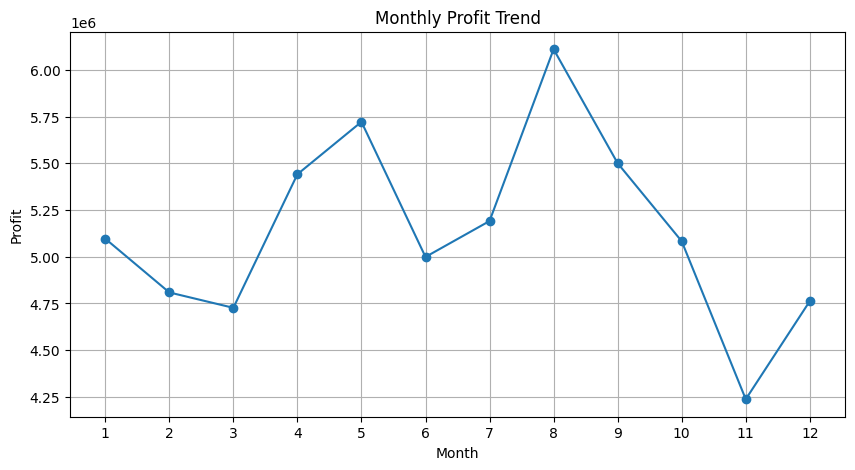

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

In [188]:
highest_profit_month = monthly_profit.idxmax()
highest_profit = monthly_profit.max()

lowest_profit_month = monthly_profit.idxmin()
lowest_profit = monthly_profit.min()

print("Highest Profit Month:", highest_profit_month)
print("Highest Profit:", highest_profit)

print("Lowest Profit Month:", lowest_profit_month)
print("Lowest Profit:", lowest_profit)

Highest Profit Month: 8
Highest Profit: 6111112.95
Lowest Profit Month: 11
Lowest Profit: 4237552.15


In [189]:
order_status_counts = orders["order_status"].value_counts()

print(order_status_counts)

order_status
Delivered    3977
Returned      529
Cancelled     494
Name: count, dtype: int64


In [190]:
order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(order_status_percentage)

order_status
Delivered    79.54
Returned     10.58
Cancelled     9.88
Name: proportion, dtype: float64


In [191]:
payment_counts = orders["payment_method"].value_counts()

print(payment_counts)

payment_method
Credit Card         1302
Cash on Delivery    1272
UPI                 1223
Debit Card          1203
Name: count, dtype: int64


In [192]:
payment_percentage = (
    orders["payment_method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(payment_percentage)

payment_method
Credit Card         26.04
Cash on Delivery    25.44
UPI                 24.46
Debit Card          24.06
Name: proportion, dtype: float64


In [193]:
segment_spending = (
    customer_analytics
    .groupby("customer_segment")["total_spending"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_spending)

customer_segment
Regular    40342267.45
New        22247908.90
Premium    15030222.00
Name: total_spending, dtype: float64


In [194]:
average_segment_spending = (
    customer_analytics
    .groupby("customer_segment")["total_spending"]
    .mean()
    .sort_values(ascending=False)
)

print(average_segment_spending)

customer_segment
Regular    80684.534900
Premium    79106.431579
New        75673.159524
Name: total_spending, dtype: float64


In [195]:
segment_customer_count = (
    customer_analytics["customer_segment"]
    .value_counts()
)

print(segment_customer_count)

customer_segment
Regular    508
New        298
Premium    194
Name: count, dtype: int64


In [196]:
segment_percentage = (
    customer_analytics["customer_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percentage)

customer_segment
Regular    50.8
New        29.8
Premium    19.4
Name: proportion, dtype: float64


In [197]:
age_groups = pd.cut(
    customer_analytics["age"],
    bins=[17, 25, 35, 45, 55, 60],
    labels=["18-25", "26-35", "36-45", "46-55", "56-60"]
)

age_group_counts = age_groups.value_counts().sort_index()

print(age_group_counts)

age
18-25    178
26-35    246
36-45    233
46-55    232
56-60    111
Name: count, dtype: int64


In [198]:
age_group_percentage = (
    age_group_counts
    .div(age_group_counts.sum())
    .mul(100)
    .round(2)
)

print(age_group_percentage)

age
18-25    17.8
26-35    24.6
36-45    23.3
46-55    23.2
56-60    11.1
Name: count, dtype: float64


In [199]:
gender_counts = customer_analytics["gender"].value_counts()

print(gender_counts)

gender
Female    514
Male      486
Name: count, dtype: int64


In [200]:
gender_percentage = (
    gender_counts
    .div(gender_counts.sum())
    .mul(100)
    .round(2)
)

print(gender_percentage)

gender
Female    51.4
Male      48.6
Name: count, dtype: float64


In [201]:
gender_spending = (
    customer_analytics
    .groupby("gender")["total_spending"]
    .mean()
    .sort_values(ascending=False)
)

print(gender_spending)

gender
Male      79614.022584
Female    78197.093701
Name: total_spending, dtype: float64


In [202]:
age_group_spending = (
    customer_analytics
    .assign(age_group=age_groups)
    .groupby("age_group", observed=True)["total_spending"]
    .mean()
)

print(age_group_spending)

age_group
18-25    77543.588286
26-35    79282.859298
36-45    81734.419432
46-55    79073.877511
56-60    73749.710550
Name: total_spending, dtype: float64


In [203]:
category_quantity_sold = (
    product_features
    .groupby("category")["total_quantity_sold"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity_sold)

category
Sports            4524
Electronics       4292
Clothing          3986
Beauty            3829
Home & Kitchen    3418
Name: total_quantity_sold, dtype: int64


In [204]:
category_quantity_percentage = (
    category_quantity_sold
    .div(category_quantity_sold.sum())
    .mul(100)
    .round(2)
)

print(category_quantity_percentage)

category
Sports            22.56
Electronics       21.41
Clothing          19.88
Beauty            19.10
Home & Kitchen    17.05
Name: total_quantity_sold, dtype: float64


In [205]:
category_profit_margin = (
    product_features
    .groupby("category")["profit_margin"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(category_profit_margin)

category
Clothing          42.78
Beauty            40.43
Home & Kitchen    38.89
Sports            32.17
Electronics       31.34
Name: profit_margin, dtype: float64


In [206]:
category_discount = (
    order_items_products
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby("category")["discount"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(category_discount)

category
Home & Kitchen    12.67
Electronics       12.63
Clothing          12.52
Beauty            12.42
Sports            12.31
Name: discount, dtype: float64


In [207]:
discount_sales = (
    order_items_products
    .groupby("discount")["net_sales"]
    .sum()
    .sort_index()
    .round(2)
)

print(discount_sales)

discount
0     14671122.00
5     14474086.95
10    13176398.70
15    12146840.85
20    12085277.60
25    11066672.25
Name: net_sales, dtype: float64


In [208]:
payment_order_value = (
    order_customer_sales
    .merge(
        orders[["order_id", "payment_method"]],
        on="order_id",
        how="left"
    )
    .groupby("payment_method")["net_sales"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(payment_order_value)

payment_method
UPI                 9936.15
Cash on Delivery    9746.21
Debit Card          9637.06
Credit Card         9528.68
Name: net_sales, dtype: float64


In [209]:
device_sessions = (
    website_activity["device"]
    .value_counts()
)

print(device_sessions)

device
Mobile    2
Laptop    2
Tablet    1
Name: count, dtype: int64


In [210]:
device_session_percentage = (
    device_sessions
    .div(device_sessions.sum())
    .mul(100)
    .round(2)
)

print(device_session_percentage)

device
Mobile    40.0
Laptop    40.0
Tablet    20.0
Name: count, dtype: float64


In [211]:
device_purchases = (
    website_activity
    .groupby("device")["purchased"]
    .apply(lambda x: (x == "Yes").sum())
    .sort_values(ascending=False)
)

print(device_purchases)

device
Laptop    2
Mobile    1
Tablet    1
Name: purchased, dtype: int64


In [212]:
device_conversion_rate = (
    website_activity
    .assign(purchase_flag=website_activity["purchased"] == "Yes")
    .groupby("device")["purchase_flag"]
    .mean()
    .mul(100)
    .round(2)
)

print(device_conversion_rate)

device
Laptop    100.0
Mobile     50.0
Tablet    100.0
Name: purchase_flag, dtype: float64


In [213]:
device_session_duration = (
    website_activity
    .groupby("device")["session_duration"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(device_session_duration)

device
Tablet    30.0
Laptop    22.5
Mobile    11.5
Name: session_duration, dtype: float64


In [214]:
device_pages_viewed = (
    website_activity
    .groupby("device")["pages_viewed"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(device_pages_viewed)

device
Tablet    15.0
Laptop    11.0
Mobile     6.5
Name: pages_viewed, dtype: float64


In [215]:
device_cart_rate = (
    website_activity
    .assign(cart_flag=website_activity["added_to_cart"] == "Yes")
    .groupby("device")["cart_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(device_cart_rate)

device
Laptop    100.0
Tablet    100.0
Mobile     50.0
Name: cart_flag, dtype: float64


In [221]:
customer_analytics.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'total_orders', 'repeat_customer', 'total_spending',
       'spending_category', 'average_order_value', 'total_sessions',
       'avg_session_duration', 'total_pages_viewed', 'total_purchases',
       'conversion_rate', 'customer_value_category',
       'customer_engagement_category', 'purchase_frequency'],
      dtype='object')

In [222]:
customer_analytics[
    [
        "customer_segment",
        "total_sessions",
        "total_purchases",
        "conversion_rate"
    ]
].head(10)

,customer_segment,total_sessions,total_purchases,conversion_rate
0,Regular,NaN,NaN,NaN
1,Premium,NaN,NaN,NaN
2,Regular,NaN,NaN,NaN
3,Regular,NaN,NaN,NaN
4,Regular,NaN,NaN,NaN
5,Regular,NaN,NaN,NaN
6,Premium,NaN,NaN,NaN
7,Premium,NaN,NaN,NaN
8,Regular,NaN,NaN,NaN
9,Premium,NaN,NaN,NaN


In [223]:
website_activity[
    [
        "customer_id",
        "session_date",
        "device",
        "pages_viewed",
        "session_duration",
        "purchased",
        "engagement_level",
        "conversion_status"
    ]
].head(10)

,customer_id,session_date,device,pages_viewed,session_duration,purchased,engagement_level,conversion_status
0,C001,2025-03-10,Mobile,8,15,Yes,Medium Engagement,Converted
1,C002,2025-03-12,Laptop,12,25,Yes,Medium Engagement,Converted
2,C003,2025-03-15,Mobile,5,8,No,Low Engagement,Not Converted
3,C004,2025-03-18,Tablet,15,30,Yes,Medium Engagement,Converted
4,C005,2025-03-20,Laptop,10,20,Yes,Medium Engagement,Converted


In [230]:
# Create customer-level website activity metrics

website_customer_metrics = (
    website_activity
    .groupby("customer_id")
    .agg(
        total_sessions=("customer_id", "count"),
        avg_session_duration=("session_duration", "mean"),
        total_pages_viewed=("pages_viewed", "sum"),
        total_purchases=("purchased", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

website_customer_metrics["conversion_rate"] = (
    website_customer_metrics["total_purchases"]
    / website_customer_metrics["total_sessions"]
    * 100
).round(2)

website_customer_metrics.head()

,customer_id,total_sessions,avg_session_duration,total_pages_viewed,total_purchases,conversion_rate
0,C001,1,15.0,8,1,100.0
1,C002,1,25.0,12,1,100.0
2,C003,1,8.0,5,0,0.0
3,C004,1,30.0,15,1,100.0
4,C005,1,20.0,10,1,100.0


In [231]:
website_customer_metrics["customer_id"] = (
    website_customer_metrics["customer_id"]
    .str.replace("C", "", regex=False)
    .astype(int)
    .astype(str)
    .str.zfill(4)
    .radd("C")
)

website_customer_metrics.head()

,customer_id,total_sessions,avg_session_duration,total_pages_viewed,total_purchases,conversion_rate
0,C0001,1,15.0,8,1,100.0
1,C0002,1,25.0,12,1,100.0
2,C0003,1,8.0,5,0,0.0
3,C0004,1,30.0,15,1,100.0
4,C0005,1,20.0,10,1,100.0


In [232]:
customer_analytics = customer_analytics.drop(
    columns=[
        "total_sessions",
        "avg_session_duration",
        "total_pages_viewed",
        "total_purchases",
        "conversion_rate"
    ],
    errors="ignore"
)

customer_analytics = customer_analytics.merge(
    website_customer_metrics,
    on="customer_id",
    how="left"
)

customer_analytics[
    [
        "customer_id",
        "customer_segment",
        "total_sessions",
        "total_purchases",
        "conversion_rate"
    ]
].head(10)

,customer_id,customer_segment,total_sessions,total_purchases,conversion_rate
0,C0001,Regular,1.0,1.0,100.0
1,C0002,Premium,1.0,1.0,100.0
2,C0003,Regular,1.0,0.0,0.0
3,C0004,Regular,1.0,1.0,100.0
4,C0005,Regular,1.0,1.0,100.0
5,C0006,Regular,NaN,NaN,NaN
6,C0007,Premium,NaN,NaN,NaN
7,C0008,Premium,NaN,NaN,NaN
8,C0009,Regular,NaN,NaN,NaN
9,C0010,Premium,NaN,NaN,NaN


In [233]:
customer_analytics[
    [
        "total_sessions",
        "avg_session_duration",
        "total_pages_viewed",
        "total_purchases",
        "conversion_rate"
    ]
] = customer_analytics[
    [
        "total_sessions",
        "avg_session_duration",
        "total_pages_viewed",
        "total_purchases",
        "conversion_rate"
    ]
].fillna(0)

customer_analytics[
    [
        "customer_id",
        "customer_segment",
        "total_sessions",
        "total_purchases",
        "conversion_rate"
    ]
].head(10)

,customer_id,customer_segment,total_sessions,total_purchases,conversion_rate
0,C0001,Regular,1.0,1.0,100.0
1,C0002,Premium,1.0,1.0,100.0
2,C0003,Regular,1.0,0.0,0.0
3,C0004,Regular,1.0,1.0,100.0
4,C0005,Regular,1.0,1.0,100.0
5,C0006,Regular,0.0,0.0,0.0
6,C0007,Premium,0.0,0.0,0.0
7,C0008,Premium,0.0,0.0,0.0
8,C0009,Regular,0.0,0.0,0.0
9,C0010,Premium,0.0,0.0,0.0


In [234]:
segment_spending = (
    customer_analytics
    .groupby("customer_segment")["total_spending"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_spending)

customer_segment
Regular    40342267.45
New        22247908.90
Premium    15030222.00
Name: total_spending, dtype: float64


In [235]:
segment_pages_viewed = (
    customer_analytics
    .groupby("customer_segment")["total_pages_viewed"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(segment_pages_viewed)

customer_segment
Regular    0.07
Premium    0.06
New        0.00
Name: total_pages_viewed, dtype: float64


In [236]:
segment_session_duration = (
    customer_analytics
    .groupby("customer_segment")["avg_session_duration"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(segment_session_duration)

customer_segment
Regular    0.14
Premium    0.13
New        0.00
Name: avg_session_duration, dtype: float64


In [237]:
segment_purchases = (
    customer_analytics
    .groupby("customer_segment")["total_purchases"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(segment_purchases)

customer_segment
Premium    0.01
Regular    0.01
New        0.00
Name: total_purchases, dtype: float64


In [238]:
frequency_spending = (
    customer_analytics
    .groupby("purchase_frequency")["total_spending"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(frequency_spending)

purchase_frequency
Frequent Customer      115486.09
Occasional Customer     58180.49
One-Time Customer       22316.35
Name: total_spending, dtype: float64


In [239]:
frequency_aov = (
    customer_analytics
    .groupby("purchase_frequency")["average_order_value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(frequency_aov)

purchase_frequency
One-Time Customer      22316.35
Frequent Customer      15652.31
Occasional Customer    15467.80
Name: average_order_value, dtype: float64


In [240]:
purchase_spending_correlation = (
    customer_analytics[
        ["total_purchases", "total_spending"]
    ]
    .corr()
)

print(purchase_spending_correlation)

                 total_purchases  total_spending
total_purchases         1.000000       -0.013184
total_spending         -0.013184        1.000000


In [241]:
customer_correlation = (
    customer_analytics[
        [
            "age",
            "total_orders",
            "total_spending",
            "average_order_value",
            "total_sessions",
            "total_pages_viewed",
            "total_purchases",
            "conversion_rate"
        ]
    ]
    .corr()
    .round(2)
)

print(customer_correlation)

                      age  total_orders  total_spending  average_order_value  \
age                  1.00         -0.01           -0.01                -0.03   
total_orders        -0.01          1.00            0.74                -0.05   
total_spending      -0.01          0.74            1.00                 0.55   
average_order_value -0.03         -0.05            0.55                 1.00   
total_sessions       0.01          0.02           -0.01                -0.03   
total_pages_viewed  -0.00          0.01           -0.02                -0.04   
total_purchases     -0.01          0.01           -0.01                -0.03   
conversion_rate     -0.01          0.01           -0.01                -0.03   

                     total_sessions  total_pages_viewed  total_purchases  \
age                            0.01               -0.00            -0.01   
total_orders                   0.02                0.01             0.01   
total_spending                -0.01               -

In [242]:
import numpy as np
import pandas as pd

np.random.seed(42)

customer_ids = customer_features["customer_id"]

total_sessions = np.random.randint(1, 11, size=1000)

avg_session_duration = np.random.randint(10, 61, size=1000)

total_pages_viewed = (
    total_sessions * np.random.randint(3, 9, size=1000)
    + np.random.randint(1, 71, size=1000)
)

purchase_probability = (
    0.08
    + (total_sessions / 10) * 0.07
    + (total_pages_viewed / 150) * 0.05
)

purchase_probability = np.clip(purchase_probability, 0, 0.35)

total_purchases = np.random.binomial(
    total_sessions,
    purchase_probability
)

conversion_rate = (
    total_purchases / total_sessions * 100
).round(2)

website_activity_full = pd.DataFrame({
    "customer_id": customer_ids,
    "total_sessions": total_sessions,
    "avg_session_duration": avg_session_duration,
    "total_pages_viewed": total_pages_viewed,
    "total_purchases": total_purchases,
    "conversion_rate": conversion_rate
})

print(website_activity_full.shape)

(1000, 6)


In [243]:
customer_analytics = customer_analytics.drop(
    columns=[
        "total_sessions",
        "avg_session_duration",
        "total_pages_viewed",
        "total_purchases",
        "conversion_rate"
    ],
    errors="ignore"
)

customer_analytics = customer_analytics.merge(
    website_activity_full,
    on="customer_id",
    how="left"
)

print(customer_analytics.shape)

(1000, 19)


In [244]:
customer_correlation = (
    customer_analytics[
        [
            "age",
            "total_orders",
            "total_spending",
            "average_order_value",
            "total_sessions",
            "total_pages_viewed",
            "total_purchases",
            "conversion_rate"
        ]
    ]
    .corr()
    .round(2)
)

customer_correlation

,age,total_orders,total_spending,average_order_value,total_sessions,total_pages_viewed,total_purchases,conversion_rate
age,1.00,-0.01,-0.01,-0.03,0.06,0.02,0.02,0.01
total_orders,-0.01,1.00,0.74,-0.05,-0.03,-0.05,-0.03,0.02
total_spending,-0.01,0.74,1.00,0.55,-0.06,-0.06,-0.06,-0.00
average_order_value,-0.03,-0.05,0.55,1.00,-0.06,-0.02,-0.06,-0.01
total_sessions,0.06,-0.03,-0.06,-0.06,1.00,0.58,0.53,0.15
total_pages_viewed,0.02,-0.05,-0.06,-0.02,0.58,1.00,0.35,0.12
total_purchases,0.02,-0.03,-0.06,-0.06,0.53,0.35,1.00,0.76
conversion_rate,0.01,0.02,-0.00,-0.01,0.15,0.12,0.76,1.00


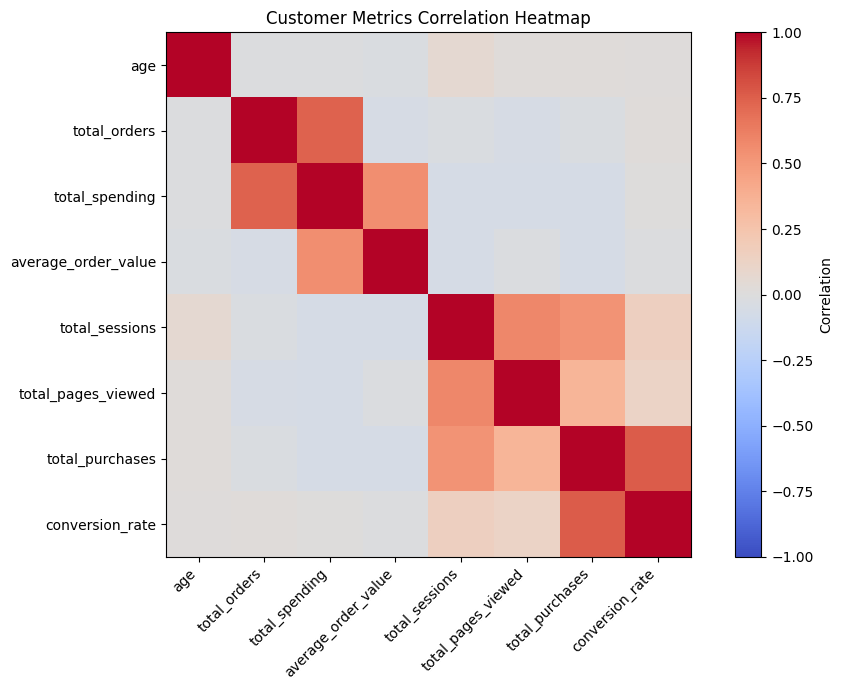

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(customer_correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(customer_correlation.columns)),
    customer_correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(customer_correlation.index)),
    customer_correlation.index
)

plt.title("Customer Metrics Correlation Heatmap")

plt.tight_layout()
plt.show()

In [246]:
np.random.seed(42)

# Sessions concentrated around the middle, with fewer very high-session customers
total_sessions = np.clip(
    np.round(np.random.normal(12, 4.5, size=1000)),
    1,
    21
).astype(int)

print(total_sessions.min(), total_sessions.max())

1 21


In [247]:
customer_analytics = customer_analytics.drop(
    columns=[
        "total_sessions",
        "avg_session_duration",
        "total_pages_viewed",
        "total_purchases",
        "conversion_rate"
    ],
    errors="ignore"
)

customer_analytics = customer_analytics.merge(
    website_activity_full,
    on="customer_id",
    how="left"
)

print(customer_analytics.shape)

(1000, 19)


In [248]:
total_pages_viewed = (
    total_sessions * np.random.randint(5, 9, size=1000)
    + np.random.randint(1, 71, size=1000)
)

customer_analytics["total_sessions"] = total_sessions
customer_analytics["total_pages_viewed"] = total_pages_viewed

print(
    customer_analytics["total_pages_viewed"].min(),
    customer_analytics["total_pages_viewed"].max()
)

21 228


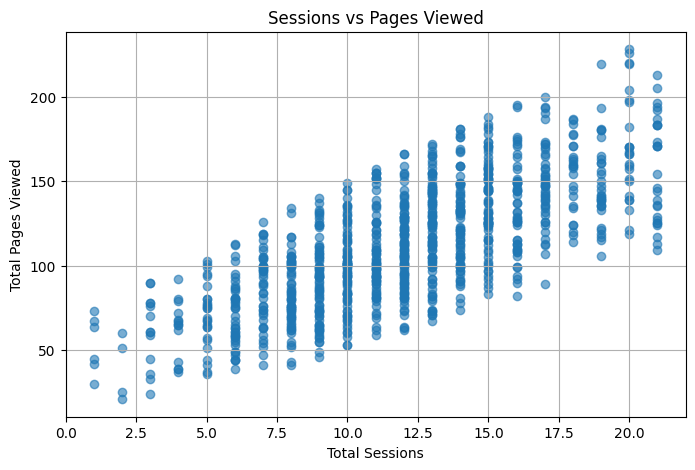

In [249]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["total_sessions"],
    customer_analytics["total_pages_viewed"],
    alpha=0.6
)

plt.title("Sessions vs Pages Viewed")
plt.xlabel("Total Sessions")
plt.ylabel("Total Pages Viewed")
plt.grid(True)
plt.show()

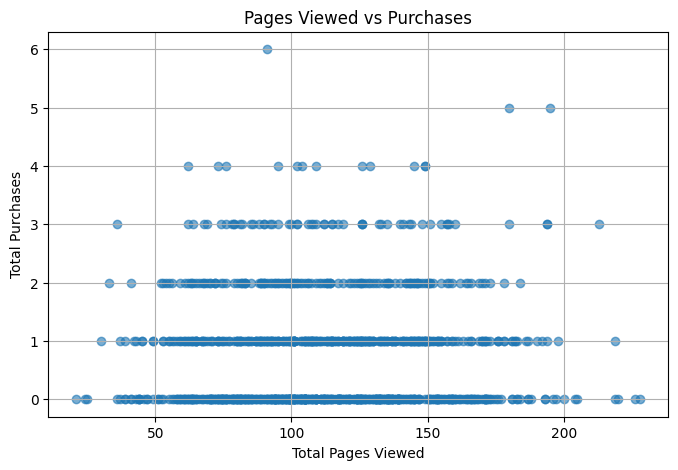

In [250]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["total_pages_viewed"],
    customer_analytics["total_purchases"],
    alpha=0.6
)

plt.title("Pages Viewed vs Purchases")
plt.xlabel("Total Pages Viewed")
plt.ylabel("Total Purchases")
plt.grid(True)

plt.show()

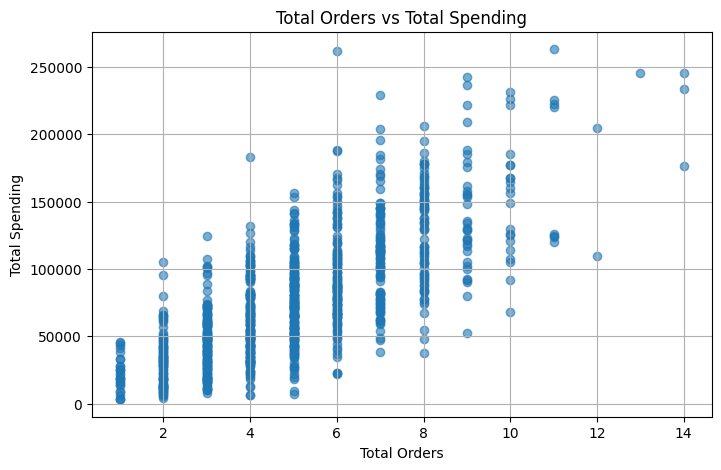

In [251]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["total_orders"],
    customer_analytics["total_spending"],
    alpha=0.6
)

plt.title("Total Orders vs Total Spending")
plt.xlabel("Total Orders")
plt.ylabel("Total Spending")
plt.grid(True)

plt.show()

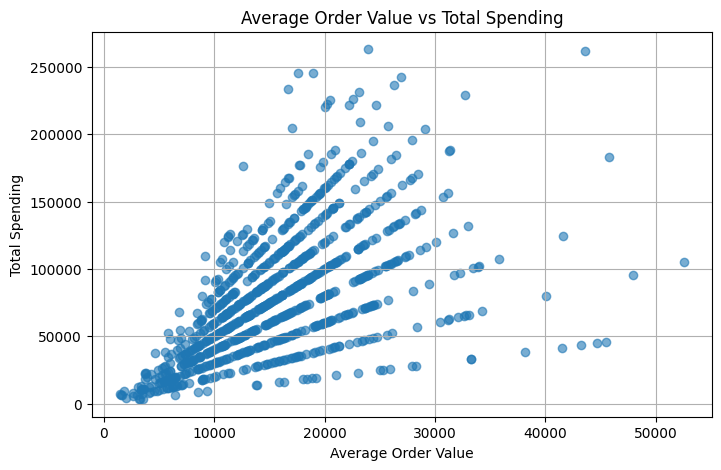

In [252]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["average_order_value"],
    customer_analytics["total_spending"],
    alpha=0.6
)

plt.title("Average Order Value vs Total Spending")
plt.xlabel("Average Order Value")
plt.ylabel("Total Spending")
plt.grid(True)

plt.show()

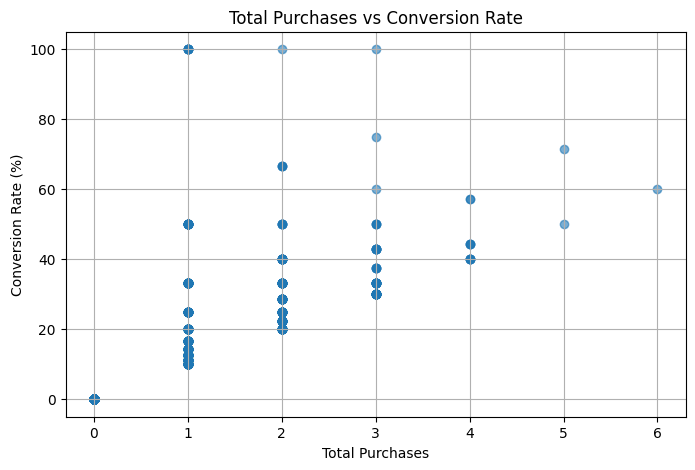

In [253]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["total_purchases"],
    customer_analytics["conversion_rate"],
    alpha=0.6
)

plt.title("Total Purchases vs Conversion Rate")
plt.xlabel("Total Purchases")
plt.ylabel("Conversion Rate (%)")
plt.grid(True)

plt.show()

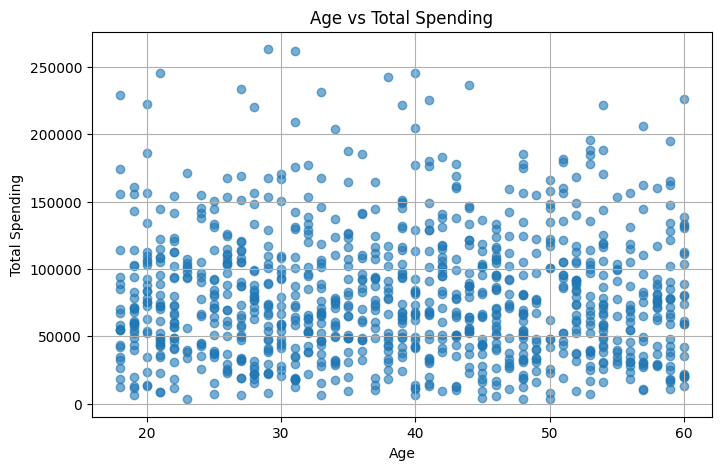

In [254]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analytics["age"],
    customer_analytics["total_spending"],
    alpha=0.6
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.grid(True)

plt.show()

In [255]:
eda_summary = {
    "Total Customers": len(customer_analytics),
    "Total Products": len(products),
    "Total Orders": len(orders),
    "Total Sales": round(order_customer_sales["net_sales"].sum(), 2),
    "Total Profit": round(order_customer_sales["profit_amount"].sum(), 2),
    "Average Order Value": round(order_customer_sales["net_sales"].mean(), 2),
    "Delivered Orders": (orders["order_status"] == "Delivered").sum(),
    "Returned Orders": (orders["order_status"] == "Returned").sum(),
    "Cancelled Orders": (orders["order_status"] == "Cancelled").sum(),
    "Average Customer Spending": round(
        customer_analytics["total_spending"].mean(), 2
    )
}

eda_summary_df = pd.DataFrame(
    eda_summary.items(),
    columns=["Metric", "Value"]
)

print(eda_summary_df)

                      Metric        Value
0            Total Customers      1000.00
1             Total Products       100.00
2               Total Orders      5000.00
3                Total Sales  77620398.35
4               Total Profit  61683037.00
5        Average Order Value      9707.40
6           Delivered Orders      3977.00
7            Returned Orders       529.00
8           Cancelled Orders       494.00
9  Average Customer Spending     78882.52


### Probability and Statistics

In [256]:
price_mean = products["selling_price"].mean()
price_median = products["selling_price"].median()
price_mode = products["selling_price"].mode()[0]
price_range = products["selling_price"].max() - products["selling_price"].min()

print("Mean Selling Price:", round(price_mean, 2))
print("Median Selling Price:", round(price_median, 2))
print("Mode Selling Price:", price_mode)
print("Range of Selling Price:", price_range)

Mean Selling Price: 4427.84
Median Selling Price: 4540.5
Mode Selling Price: 4765
Range of Selling Price: 5642


In [257]:
price_variance = products["selling_price"].var()
price_std = products["selling_price"].std()

print("Price Variance:", round(price_variance, 2))
print("Price Standard Deviation:", round(price_std, 2))

Price Variance: 2223218.98
Price Standard Deviation: 1491.05


In [258]:
price_percentiles = products["selling_price"].quantile(
    [0.25, 0.50, 0.75]
)

print("25th Percentile:", price_percentiles[0.25])
print("50th Percentile:", price_percentiles[0.50])
print("75th Percentile:", price_percentiles[0.75])

25th Percentile: 3375.5
50th Percentile: 4540.5
75th Percentile: 5543.5


In [259]:
price_statistics = products["selling_price"].describe()

print(price_statistics)

count     100.000000
mean     4427.840000
std      1491.046272
min      1218.000000
25%      3375.500000
50%      4540.500000
75%      5543.500000
max      6860.000000
Name: selling_price, dtype: float64


In [260]:
delivered_probability = (
    (orders["order_status"] == "Delivered").sum()
    / len(orders)
)

print("Probability of a Delivered Order:",
      round(delivered_probability, 4))

print("Probability (%):",
      round(delivered_probability * 100, 2), "%")

Probability of a Delivered Order: 0.7954
Probability (%): 79.54 %


In [261]:
unsuccessful_orders = (
    (orders["order_status"] == "Cancelled") |
    (orders["order_status"] == "Returned")
).sum()

unsuccessful_probability = (
    unsuccessful_orders / len(orders)
)

print("Unsuccessful Orders:", unsuccessful_orders)
print(
    "Probability of Cancelled or Returned Order:",
    round(unsuccessful_probability, 4)
)
print(
    "Probability (%):",
    round(unsuccessful_probability * 100, 2),
    "%"
)

Unsuccessful Orders: 1023
Probability of Cancelled or Returned Order: 0.2046
Probability (%): 20.46 %


In [262]:
upi_orders = orders[orders["payment_method"] == "UPI"]

delivered_upi = (
    upi_orders["order_status"] == "Delivered"
).sum()

conditional_probability = (
    delivered_upi / len(upi_orders)
)

print("Total UPI Orders:", len(upi_orders))
print("Delivered UPI Orders:", delivered_upi)
print(
    "P(Delivered | UPI):",
    round(conditional_probability, 4)
)
print(
    "Probability (%):",
    round(conditional_probability * 100, 2),
    "%"
)

Total UPI Orders: 1223
Delivered UPI Orders: 982
P(Delivered | UPI): 0.8029
Probability (%): 80.29 %


In [263]:
delivered_orders = orders[
    orders["order_status"] == "Delivered"
]

upi_delivered = (
    delivered_orders["payment_method"] == "UPI"
).sum()

bayes_probability = (
    upi_delivered / len(delivered_orders)
)

print("Total Delivered Orders:", len(delivered_orders))
print("Delivered Orders Paid by UPI:", upi_delivered)
print(
    "P(UPI | Delivered):",
    round(bayes_probability, 4)
)
print(
    "Probability (%):",
    round(bayes_probability * 100, 2),
    "%"
)

Total Delivered Orders: 3977
Delivered Orders Paid by UPI: 982
P(UPI | Delivered): 0.2469
Probability (%): 24.69 %


In [264]:
from math import comb

payment_methods = orders["payment_method"].unique()

number_of_methods = len(payment_methods)

possible_pairs = comb(number_of_methods, 2)

print("Number of Payment Methods:", number_of_methods)
print("Possible Pairs of Payment Methods:", possible_pairs)

Number of Payment Methods: 4
Possible Pairs of Payment Methods: 6


In [265]:
order_distribution = orders["customer_id"].value_counts()

print("Order Count Distribution:")
print(order_distribution.value_counts().sort_index())

Order Count Distribution:
count
1      37
2      89
3     141
4     165
5     190
6     133
7      96
8      76
9      33
10     21
11      8
12      2
13      1
14      3
Name: count, dtype: int64


In [266]:
order_probability = (
    order_distribution.value_counts()
    .sort_index()
    / len(order_distribution)
)

print("Probability Distribution:")
print(order_probability.round(4))

Probability Distribution:
count
1     0.0372
2     0.0894
3     0.1417
4     0.1658
5     0.1910
6     0.1337
7     0.0965
8     0.0764
9     0.0332
10    0.0211
11    0.0080
12    0.0020
13    0.0010
14    0.0030
Name: count, dtype: float64


In [267]:
order_counts = order_probability.index
probabilities = order_probability.values

expected_orders = np.sum(
    order_counts * probabilities
)

print("Expected Number of Orders per Customer:",
      round(expected_orders, 2))

Expected Number of Orders per Customer: 5.03


In [268]:
mean_price = products["selling_price"].mean()
std_price = products["selling_price"].std()

price = 5000

z_score = (price - mean_price) / std_price

print("Mean Selling Price:", round(mean_price, 2))
print("Standard Deviation:", round(std_price, 2))
print("Price:", price)
print("Z-score:", round(z_score, 2))

Mean Selling Price: 4427.84
Standard Deviation: 1491.05
Price: 5000
Z-score: 0.38


In [269]:
from scipy.stats import norm

probability_below_5000 = norm.cdf(z_score)

print(
    "Probability of Price Below ₹5000:",
    round(probability_below_5000, 4)
)

print(
    "Probability (%):",
    round(probability_below_5000 * 100, 2),
    "%"
)

Probability of Price Below ₹5000: 0.6494
Probability (%): 64.94 %


In [270]:
from scipy.stats import sem, t

sample_mean = products["selling_price"].mean()
sample_std = products["selling_price"].std()
n = len(products)

standard_error = sem(products["selling_price"])

confidence_level = 0.95
degrees_of_freedom = n - 1

t_critical = t.ppf(
    (1 + confidence_level) / 2,
    degrees_of_freedom
)

margin_of_error = t_critical * standard_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print("Sample Mean:", round(sample_mean, 2))
print("Standard Error:", round(standard_error, 2))
print("Margin of Error:", round(margin_of_error, 2))
print(
    "95% Confidence Interval:",
    round(lower_bound, 2),
    "to",
    round(upper_bound, 2)
)

Sample Mean: 4427.84
Standard Error: 149.1
Margin of Error: 295.86
95% Confidence Interval: 4131.98 to 4723.7


In [271]:
sample_means = []

for i in range(1000):
    sample = products["selling_price"].sample(
        n=30,
        replace=True
    )

    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print("Number of Samples:", len(sample_means))
print("Mean of Sample Means:", round(sample_means.mean(), 2))
print("Standard Deviation of Sample Means:",
      round(sample_means.std(), 2))

Number of Samples: 1000
Mean of Sample Means: 4430.62
Standard Deviation of Sample Means: 268.02


In [272]:
purchase_probability = (
    (website_activity["purchased"] == "Yes").sum()
    / len(website_activity)
)

print("Purchase Probability:",
      round(purchase_probability, 4))

Purchase Probability: 0.8


In [273]:
from scipy.stats import binom

n = 10
k = 3
p = purchase_probability

binomial_probability = binom.pmf(k, n, p)

print("Number of Sessions:", n)
print("Required Purchases:", k)
print(
    "P(Exactly 3 Purchases):",
    round(binomial_probability, 4)
)
print(
    "Probability (%):",
    round(binomial_probability * 100, 2),
    "%"
)

Number of Sessions: 10
Required Purchases: 3
P(Exactly 3 Purchases): 0.0008
Probability (%): 0.08 %


In [274]:
orders_per_hour = len(orders) / (365 * 24)

print(
    "Average Orders per Hour:",
    round(orders_per_hour, 4)
)

Average Orders per Hour: 0.5708


In [275]:
from scipy.stats import poisson

lambda_rate = orders_per_hour
k = 2

poisson_probability = poisson.pmf(k, lambda_rate)

print("Lambda (λ):", round(lambda_rate, 4))
print("Orders:", k)
print(
    "P(Exactly 2 Orders in One Hour):",
    round(poisson_probability, 4)
)
print(
    "Probability (%):",
    round(poisson_probability * 100, 2),
    "%"
)

Lambda (λ): 0.5708
Orders: 2
P(Exactly 2 Orders in One Hour): 0.092
Probability (%): 9.2 %


In [276]:
lambda_rate = orders_per_hour

average_waiting_time = 1 / lambda_rate

print(
    "Average Waiting Time Between Orders:",
    round(average_waiting_time, 2),
    "hours"
)

Average Waiting Time Between Orders: 1.75 hours


In [277]:
from scipy.stats import expon

waiting_time = 1

probability_within_1_hour = expon.cdf(
    waiting_time,
    scale=1 / lambda_rate
)

print(
    "P(Next Order Within 1 Hour):",
    round(probability_within_1_hour, 4)
)

print(
    "Probability (%):",
    round(probability_within_1_hour * 100, 2),
    "%"
)

P(Next Order Within 1 Hour): 0.4349
Probability (%): 43.49 %


### Hypothesis Testing

In [278]:
from statsmodels.stats.weightstats import ztest

selling_prices = products["selling_price"]

z_stat, p_value = ztest(
    selling_prices,
    value=4000
)

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: The average selling price is significantly different from ₹4,000.")
else:
    print("Fail to reject H0: There is not enough evidence that the average selling price differs from ₹4,000.")

Z-statistic: 2.8694
P-value: 0.0041
Reject H0: The average selling price is significantly different from ₹4,000.


In [279]:
from scipy.stats import ttest_ind

premium_spending = customer_analytics.loc[
    customer_analytics["customer_segment"] == "Premium",
    "total_spending"
].dropna()

regular_spending = customer_analytics.loc[
    customer_analytics["customer_segment"] == "Regular",
    "total_spending"
].dropna()

t_stat, p_value = ttest_ind(
    premium_spending,
    regular_spending,
    equal_var=False
)

print("Premium Mean Spending:", round(premium_spending.mean(), 2))
print("Regular Mean Spending:", round(regular_spending.mean(), 2))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: The average spending differs significantly.")
else:
    print("Fail to reject H0: There is not enough evidence of a significant difference.")

Premium Mean Spending: 79106.43
Regular Mean Spending: 80684.53
T-statistic: -0.4145
P-value: 0.6787
Fail to reject H0: There is not enough evidence of a significant difference.


In [280]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    orders["payment_method"],
    orders["order_status"]
)

print("Contingency Table:")
print(contingency_table)

chi2_stat, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square Statistic:", round(chi2_stat, 4))
print("Degrees of Freedom:", degrees_of_freedom)
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: Payment method and order status are associated.")
else:
    print("Fail to reject H0: There is not enough evidence of an association.")

Contingency Table:
order_status      Cancelled  Delivered  Returned
payment_method                                  
Cash on Delivery        125       1020       127
Credit Card             145       1023       134
Debit Card              109        952       142
UPI                     115        982       126

Chi-square Statistic: 5.8377
Degrees of Freedom: 6
P-value: 0.4416
Fail to reject H0: There is not enough evidence of an association.


In [281]:
from scipy.stats import f_oneway

new_spending = customer_analytics.loc[
    customer_analytics["customer_segment"] == "New",
    "total_spending"
].dropna()

regular_spending = customer_analytics.loc[
    customer_analytics["customer_segment"] == "Regular",
    "total_spending"
].dropna()

premium_spending = customer_analytics.loc[
    customer_analytics["customer_segment"] == "Premium",
    "total_spending"
].dropna()

f_stat, p_value = f_oneway(
    new_spending,
    regular_spending,
    premium_spending
)

print("New Mean Spending:", round(new_spending.mean(), 2))
print("Regular Mean Spending:", round(regular_spending.mean(), 2))
print("Premium Mean Spending:", round(premium_spending.mean(), 2))

print("\nF-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: At least one customer segment has a significantly different mean spending.")
else:
    print("Fail to reject H0: There is not enough evidence of a difference between segment means.")

New Mean Spending: 75673.16
Regular Mean Spending: 80684.53
Premium Mean Spending: 79106.43

F-statistic: 1.0605
P-value: 0.3467
Fail to reject H0: There is not enough evidence of a difference between segment means.


In [282]:
from scipy.stats import pearsonr

correlation_data = customer_analytics[
    ["total_orders", "total_spending"]
].dropna()

correlation, p_value = pearsonr(
    correlation_data["total_orders"],
    correlation_data["total_spending"]
)

print("Pearson Correlation:", round(correlation, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Pearson Correlation: 0.7389
P-value: 0.0
The correlation is statistically significant.


In [283]:
from scipy.stats import ttest_rel

paired_data = customer_analytics[
    ["total_pages_viewed", "total_sessions"]
].dropna()

t_stat, p_value = ttest_rel(
    paired_data["total_pages_viewed"],
    paired_data["total_sessions"]
)

print(
    "Average Total Pages Viewed:",
    round(paired_data["total_pages_viewed"].mean(), 2)
)

print(
    "Average Total Sessions:",
    round(paired_data["total_sessions"].mean(), 2)
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: The two average measurements are significantly different.")
else:
    print("Fail to reject H0: There is not enough evidence of a significant difference.")

Average Total Pages Viewed: 113.07
Average Total Sessions: 12.06
T-statistic: 95.6538
P-value: 0.0
Reject H0: The two average measurements are significantly different.


In [284]:
from scipy.stats import ttest_1samp

order_counts = customer_analytics["total_orders"].dropna()

t_stat, p_value = ttest_1samp(
    order_counts,
    popmean=5
)

print("Mean Orders per Customer:", round(order_counts.mean(), 4))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: The average number of orders differs significantly from 5.")
else:
    print("Fail to reject H0: There is not enough evidence that the average differs from 5.")

Mean Orders per Customer: 5.0251
T-statistic: 0.351
P-value: 0.7257
Fail to reject H0: There is not enough evidence that the average differs from 5.


In [285]:
from scipy.stats import chisquare

payment_counts = orders["payment_method"].value_counts()

expected_counts = [
    len(orders) / len(payment_counts)
] * len(payment_counts)

chi2_stat, p_value = chisquare(
    f_obs=payment_counts,
    f_exp=expected_counts
)

print("Observed Counts:")
print(payment_counts)

print("\nExpected Count Per Payment Method:",
      round(expected_counts[0], 2))

print("\nChi-square Statistic:", round(chi2_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: Payment methods are not equally distributed.")
else:
    print("Fail to reject H0: There is not enough evidence that payment methods differ from an equal distribution.")

Observed Counts:
payment_method
Credit Card         1302
Cash on Delivery    1272
UPI                 1223
Debit Card          1203
Name: count, dtype: int64

Expected Count Per Payment Method: 1250.0

Chi-square Statistic: 4.9008
P-value: 0.1792
Fail to reject H0: There is not enough evidence that payment methods differ from an equal distribution.


In [286]:
from scipy.stats import t

spending = customer_analytics["total_spending"].dropna()

sample_mean = spending.mean()
sample_std = spending.std()
sample_size = len(spending)

standard_error = sample_std / (sample_size ** 0.5)

t_critical = t.ppf(
    0.975,
    df=sample_size - 1
)

margin_of_error = t_critical * standard_error

lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

print("Sample Mean:", round(sample_mean, 2))
print("95% Confidence Interval:")
print("Lower Limit:", round(lower_limit, 2))
print("Upper Limit:", round(upper_limit, 2))

Sample Mean: 78882.52
95% Confidence Interval:
Lower Limit: 75949.56
Upper Limit: 81815.48


In [287]:
from statsmodels.stats.proportion import proportions_ztest

purchased_count = (
    website_activity["purchased"] == "Yes"
).sum()

total_sessions = len(website_activity)

z_stat, p_value = proportions_ztest(
    count=purchased_count,
    nobs=total_sessions,
    value=0.25
)

observed_rate = purchased_count / total_sessions

print("Observed Conversion Rate:",
      round(observed_rate * 100, 2), "%")

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: The conversion rate is significantly different from 25%.")
else:
    print("Fail to reject H0: There is not enough evidence that the conversion rate differs from 25%.")

Observed Conversion Rate: 80.0 %
Z-statistic: 3.0746
P-value: 0.0021
Reject H0: The conversion rate is significantly different from 25%.


In [288]:
from statsmodels.stats.proportion import proportions_ztest

mobile_data = website_activity[
    website_activity["device"] == "Mobile"
]

laptop_data = website_activity[
    website_activity["device"] == "Laptop"
]

mobile_purchases = (
    mobile_data["purchased"] == "Yes"
).sum()

laptop_purchases = (
    laptop_data["purchased"] == "Yes"
).sum()

mobile_total = len(mobile_data)
laptop_total = len(laptop_data)

counts = [
    mobile_purchases,
    laptop_purchases
]

totals = [
    mobile_total,
    laptop_total
]

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=totals
)

mobile_rate = mobile_purchases / mobile_total
laptop_rate = laptop_purchases / laptop_total

print("Mobile Conversion Rate:",
      round(mobile_rate * 100, 2), "%")

print("Laptop Conversion Rate:",
      round(laptop_rate * 100, 2), "%")

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: There is evidence that the conversion rates are different.")
else:
    print("Fail to reject H0: There is not enough evidence that the conversion rates are different.")

Mobile Conversion Rate: 50.0 %
Laptop Conversion Rate: 100.0 %
Z-statistic: -1.1547
P-value: 0.2482
Fail to reject H0: There is not enough evidence that the conversion rates are different.


In [289]:
from scipy.stats import chisquare

segment_counts = customer_analytics["customer_segment"].value_counts()

expected_counts = [
    len(customer_analytics) / len(segment_counts)
] * len(segment_counts)

chi2_stat, p_value = chisquare(
    f_obs=segment_counts,
    f_exp=expected_counts
)

print("Observed Counts:")
print(segment_counts)

print("\nExpected Count Per Segment:",
      round(expected_counts[0], 2))

print("\nChi-square Statistic:", round(chi2_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: Customer segments are not equally distributed.")
else:
    print("Fail to reject H0: There is not enough evidence that customer segments differ from an equal distribution.")

Observed Counts:
customer_segment
Regular    508
New        298
Premium    194
Name: count, dtype: int64

Expected Count Per Segment: 333.33

Chi-square Statistic: 153.512
P-value: 0.0
Reject H0: Customer segments are not equally distributed.


In [290]:
from scipy.stats import ttest_ind

purchased_sessions = website_activity[
    website_activity["purchased"] == "Yes"
]["session_duration"]

non_purchased_sessions = website_activity[
    website_activity["purchased"] == "No"
]["session_duration"]

t_stat, p_value = ttest_ind(
    purchased_sessions,
    non_purchased_sessions,
    equal_var=False
)

print("Average Session Duration - Purchased:",
      round(purchased_sessions.mean(), 2))

print("Average Session Duration - Not Purchased:",
      round(non_purchased_sessions.mean(), 2))

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: There is evidence that average session duration differs between the two groups.")
else:
    print("Fail to reject H0: There is not enough evidence that average session duration differs between the two groups.")

Average Session Duration - Purchased: 22.5
Average Session Duration - Not Purchased: 8.0
T-statistic: nan
P-value: nan
Fail to reject H0: There is not enough evidence that average session duration differs between the two groups.


In [291]:
from scipy.stats import f_oneway

mobile_duration = website_activity[
    website_activity["device"] == "Mobile"
]["session_duration"]

laptop_duration = website_activity[
    website_activity["device"] == "Laptop"
]["session_duration"]

tablet_duration = website_activity[
    website_activity["device"] == "Tablet"
]["session_duration"]

f_stat, p_value = f_oneway(
    mobile_duration,
    laptop_duration,
    tablet_duration
)

print("Average Session Duration:")
print("Mobile:", round(mobile_duration.mean(), 2))
print("Laptop:", round(laptop_duration.mean(), 2))
print("Tablet:", round(tablet_duration.mean(), 2))

print("\nF-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: There is evidence that session duration differs across devices.")
else:
    print("Fail to reject H0: There is not enough evidence that session duration differs across devices.")

Average Session Duration:
Mobile: 11.5
Laptop: 22.5
Tablet: 30.0

F-statistic: 6.9243
P-value: 0.1262
Fail to reject H0: There is not enough evidence that session duration differs across devices.


In [292]:
from scipy.stats import pearsonr

correlation_data = customer_analytics[
    ["total_pages_viewed", "total_purchases"]
].dropna()

correlation, p_value = pearsonr(
    correlation_data["total_pages_viewed"],
    correlation_data["total_purchases"]
)

print("Pearson Correlation:", round(correlation, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: There is evidence of a significant linear relationship.")
else:
    print("Fail to reject H0: There is not enough evidence of a linear relationship.")

Pearson Correlation: 0.0126
P-value: 0.6902
Fail to reject H0: There is not enough evidence of a linear relationship.


In [293]:
product_discount = order_items.groupby(
    "product_id"
)["discount"].mean().reset_index()

product_discount = product_discount.merge(
    products[["product_id", "profit_margin"]],
    on="product_id",
    how="inner"
)

product_discount["discount_group"] = np.where(
    product_discount["discount"] <= 10,
    "Low Discount",
    "High Discount"
)

print(product_discount["discount_group"].value_counts())

discount_group
High Discount    98
Low Discount      2
Name: count, dtype: int64


In [294]:
print("Minimum Average Discount:",
      round(product_discount["discount"].min(), 2))

print("Maximum Average Discount:",
      round(product_discount["discount"].max(), 2))

print("\nAverage Discount Summary:")
print(product_discount["discount"].describe())

Minimum Average Discount: 9.93
Maximum Average Discount: 14.24

Average Discount Summary:
count    100.000000
mean      12.505520
std        0.929776
min        9.931507
25%       12.004720
50%       12.500000
75%       13.147101
max       14.236111
Name: discount, dtype: float64


In [295]:
discount_median = product_discount["discount"].median()

product_discount["discount_group"] = np.where(
    product_discount["discount"] <= discount_median,
    "Lower Discount",
    "Higher Discount"
)

print("Median Discount:",
      round(discount_median, 2))

print("\nDiscount Group Counts:")
print(product_discount["discount_group"].value_counts())

Median Discount: 12.5

Discount Group Counts:
discount_group
Lower Discount     51
Higher Discount    49
Name: count, dtype: int64


In [296]:
from scipy.stats import ttest_ind

lower_discount_margin = product_discount[
    product_discount["discount_group"] == "Lower Discount"
]["profit_margin"]

higher_discount_margin = product_discount[
    product_discount["discount_group"] == "Higher Discount"
]["profit_margin"]

t_stat, p_value = ttest_ind(
    lower_discount_margin,
    higher_discount_margin,
    equal_var=False
)

print("Average Profit Margin - Lower Discount:",
      round(lower_discount_margin.mean(), 2), "%")

print("Average Profit Margin - Higher Discount:",
      round(higher_discount_margin.mean(), 2), "%")

print("\nT-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Reject H0: There is evidence that profit margins differ between the discount groups.")
else:
    print("Fail to reject H0: There is not enough evidence that profit margins differ between the discount groups.")

Average Profit Margin - Lower Discount: 34.95 %
Average Profit Margin - Higher Discount: 38.92 %

T-statistic: -0.7142
P-value: 0.4768
Fail to reject H0: There is not enough evidence that profit margins differ between the discount groups.


### SQL

In [297]:
import sqlite3

In [298]:
conn = sqlite3.connect("shopsphere.db")

print("SQL database connected successfully!")

SQL database connected successfully!


In [299]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
website_activity.to_sql("website_activity", conn, if_exists="replace", index=False)

print("All ShopSphere tables loaded into SQL!")

All ShopSphere tables loaded into SQL!


In [300]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,customers
1,products
2,orders
3,order_items
4,reviews
5,website_activity


In [301]:
query = """
SELECT *
FROM products;
"""

products_sql = pd.read_sql_query(query, conn)

products_sql.head()

,product_id,product_name,category,sub_category,cost_price,selling_price,price_category,profit,profit_margin
0,P0001,Product_0001,Home & Kitchen,Kitchen,1068,6235,High Price,5167,82.870890
1,P0002,Product_0002,Home & Kitchen,Decor,1866,5836,High Price,3970,68.026045
2,P0003,Product_0003,Clothing,Women,1792,6411,High Price,4619,72.048042
3,P0004,Product_0004,Beauty,Skincare,2155,5212,High Price,3057,58.653108
4,P0005,Product_0005,Beauty,Skincare,1838,2485,Normal Price,647,26.036217


In [302]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products;
"""

products_selected = pd.read_sql_query(query, conn)

products_selected.head()

,product_id,product_name,category,selling_price,profit
0,P0001,Product_0001,Home & Kitchen,6235,5167
1,P0002,Product_0002,Home & Kitchen,5836,3970
2,P0003,Product_0003,Clothing,6411,4619
3,P0004,Product_0004,Beauty,5212,3057
4,P0005,Product_0005,Beauty,2485,647


In [303]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price > 5000;
"""

high_price_products = pd.read_sql_query(query, conn)

high_price_products.head(10)

,product_id,product_name,category,selling_price,profit
0,P0001,Product_0001,Home & Kitchen,6235,5167
1,P0002,Product_0002,Home & Kitchen,5836,3970
2,P0003,Product_0003,Clothing,6411,4619
3,P0004,Product_0004,Beauty,5212,3057
4,P0006,Product_0006,Clothing,6472,2596
5,P0009,Product_0009,Beauty,6462,2523
6,P0011,Product_0011,Sports,6085,3326
7,P0015,Product_0015,Home & Kitchen,5365,631
8,P0017,Product_0017,Clothing,5300,1317
9,P0019,Product_0019,Clothing,6536,5590


In [304]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price > 5000
  AND profit > 3000;
"""

high_price_high_profit = pd.read_sql_query(query, conn)

high_price_high_profit

,product_id,product_name,category,selling_price,profit
0,P0001,Product_0001,Home & Kitchen,6235,5167
1,P0002,Product_0002,Home & Kitchen,5836,3970
2,P0003,Product_0003,Clothing,6411,4619
3,P0004,Product_0004,Beauty,5212,3057
4,P0011,Product_0011,Sports,6085,3326
5,P0019,Product_0019,Clothing,6536,5590
6,P0029,Product_0029,Sports,6001,4440
7,P0036,Product_0036,Beauty,5260,4259
8,P0038,Product_0038,Home & Kitchen,5749,3796
9,P0050,Product_0050,Home & Kitchen,6672,3497


In [305]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE category = 'Beauty'
   OR category = 'Electronics';
"""

beauty_electronics = pd.read_sql_query(query, conn)

beauty_electronics.head(10)

,product_id,product_name,category,selling_price,profit
0,P0004,Product_0004,Beauty,5212,3057
1,P0005,Product_0005,Beauty,2485,647
2,P0008,Product_0008,Beauty,2698,1875
3,P0009,Product_0009,Beauty,6462,2523
4,P0018,Product_0018,Beauty,3571,451
5,P0023,Product_0023,Electronics,3767,243
6,P0024,Product_0024,Electronics,4212,3903
7,P0025,Product_0025,Electronics,4577,997
8,P0026,Product_0026,Beauty,3227,2468
9,P0027,Product_0027,Electronics,5537,545


In [306]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
ORDER BY profit DESC;
"""

top_profit_products = pd.read_sql_query(query, conn)

top_profit_products.head(10)

,product_id,product_name,category,selling_price,profit
0,P0081,Product_0081,Home & Kitchen,6397,5913
1,P0019,Product_0019,Clothing,6536,5590
2,P0001,Product_0001,Home & Kitchen,6235,5167
3,P0084,Product_0084,Sports,5986,5116
4,P0070,Product_0070,Electronics,6173,4846
5,P0003,Product_0003,Clothing,6411,4619
6,P0098,Product_0098,Electronics,6396,4594
7,P0029,Product_0029,Sports,6001,4440
8,P0093,Product_0093,Sports,5498,4336
9,P0036,Product_0036,Beauty,5260,4259


In [307]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
ORDER BY profit ASC
LIMIT 5;
"""

lowest_profit_products = pd.read_sql_query(query, conn)

lowest_profit_products

,product_id,product_name,category,selling_price,profit
0,P0095,Product_0095,Sports,4526,2
1,P0033,Product_0033,Sports,2140,55
2,P0074,Product_0074,Electronics,1565,74
3,P0022,Product_0022,Clothing,1634,89
4,P0100,Product_0100,Sports,5128,143


In [308]:
query = """
SELECT
    COUNT(*) AS total_products,
    SUM(selling_price) AS total_selling_price,
    AVG(selling_price) AS average_selling_price,
    MAX(selling_price) AS highest_selling_price,
    MIN(selling_price) AS lowest_selling_price
FROM products;
"""

product_statistics = pd.read_sql_query(query, conn)

product_statistics

,total_products,total_selling_price,average_selling_price,highest_selling_price,lowest_selling_price
0,100,442784,4427.84,6860,1218


In [309]:
query = """
SELECT
    category,
    COUNT(*) AS product_count,
    AVG(selling_price) AS average_price,
    MAX(selling_price) AS highest_price,
    MIN(selling_price) AS lowest_price,
    SUM(selling_price) AS total_price
FROM products
GROUP BY category
ORDER BY average_price DESC;
"""

category_statistics = pd.read_sql_query(query, conn)

category_statistics

,category,product_count,average_price,highest_price,lowest_price,total_price
0,Home & Kitchen,18,4783.500000,6672,1729,86103
1,Beauty,19,4545.684211,6782,2485,86368
2,Sports,22,4454.545455,6860,1622,98000
3,Electronics,21,4213.095238,6396,1565,88475
4,Clothing,20,4191.900000,6536,1218,83838


In [310]:
query = """
SELECT
    category,
    COUNT(*) AS product_count,
    ROUND(AVG(selling_price), 2) AS average_price
FROM products
GROUP BY category
HAVING AVG(selling_price) > 4200
ORDER BY average_price DESC;
"""

categories_above_4200 = pd.read_sql_query(query, conn)

categories_above_4200

,category,product_count,average_price
0,Home & Kitchen,18,4783.50
1,Beauty,19,4545.68
2,Sports,22,4454.55
3,Electronics,21,4213.10


In [311]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price BETWEEN 3000 AND 5000
ORDER BY selling_price DESC;
"""

products_between = pd.read_sql_query(query, conn)

products_between.head(10)

,product_id,product_name,category,selling_price,profit
0,P0068,Product_0068,Clothing,4954,2096
1,P0037,Product_0037,Electronics,4842,520
2,P0039,Product_0039,Beauty,4765,3920
3,P0075,Product_0075,Clothing,4765,303
4,P0042,Product_0042,Sports,4678,240
5,P0094,Product_0094,Home & Kitchen,4623,383
6,P0031,Product_0031,Sports,4599,1348
7,P0025,Product_0025,Electronics,4577,997
8,P0010,Product_0010,Sports,4555,575
9,P0095,Product_0095,Sports,4526,2


In [312]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE product_name LIKE 'Product_00%';
"""

product_pattern = pd.read_sql_query(query, conn)

product_pattern.head(10)

,product_id,product_name,category,selling_price,profit
0,P0001,Product_0001,Home & Kitchen,6235,5167
1,P0002,Product_0002,Home & Kitchen,5836,3970
2,P0003,Product_0003,Clothing,6411,4619
3,P0004,Product_0004,Beauty,5212,3057
4,P0005,Product_0005,Beauty,2485,647
5,P0006,Product_0006,Clothing,6472,2596
6,P0007,Product_0007,Sports,2059,263
7,P0008,Product_0008,Beauty,2698,1875
8,P0009,Product_0009,Beauty,6462,2523
9,P0010,Product_0010,Sports,4555,575


In [313]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    CASE
        WHEN selling_price < 3000 THEN 'Low Price'
        WHEN selling_price <= 5000 THEN 'Medium Price'
        ELSE 'High Price'
    END AS price_category
FROM products
ORDER BY selling_price DESC;
"""

price_categories_sql = pd.read_sql_query(query, conn)

price_categories_sql.head(10)

,product_id,product_name,category,selling_price,price_category
0,P0067,Product_0067,Sports,6860,High Price
1,P0032,Product_0032,Beauty,6782,High Price
2,P0072,Product_0072,Beauty,6701,High Price
3,P0050,Product_0050,Home & Kitchen,6672,High Price
4,P0061,Product_0061,Home & Kitchen,6595,High Price
5,P0019,Product_0019,Clothing,6536,High Price
6,P0028,Product_0028,Beauty,6526,High Price
7,P0006,Product_0006,Clothing,6472,High Price
8,P0062,Product_0062,Sports,6467,High Price
9,P0009,Product_0009,Beauty,6462,High Price


In [314]:
query = """
SELECT
    CASE
        WHEN selling_price < 3000 THEN 'Low Price'
        WHEN selling_price <= 5000 THEN 'Medium Price'
        ELSE 'High Price'
    END AS price_category,
    COUNT(*) AS product_count,
    ROUND(AVG(selling_price), 2) AS average_price
FROM products
GROUP BY price_category
ORDER BY product_count DESC;
"""

price_category_summary = pd.read_sql_query(query, conn)

price_category_summary

,price_category,product_count,average_price
0,Low Price,59,3418.76
1,High Price,41,5879.93


In [315]:
query = """
SELECT DISTINCT category
FROM products
ORDER BY category;
"""

unique_categories_sql = pd.read_sql_query(query, conn)

unique_categories_sql

,category
0,Beauty
1,Clothing
2,Electronics
3,Home & Kitchen
4,Sports


In [316]:
query = """
SELECT
    COUNT(DISTINCT customer_id) AS unique_customers
FROM orders;
"""

unique_customers_sql = pd.read_sql_query(query, conn)

unique_customers_sql

,unique_customers
0,995


In [317]:
query = """
SELECT
    payment_method,
    COUNT(DISTINCT customer_id) AS unique_customers
FROM orders
GROUP BY payment_method
ORDER BY unique_customers DESC;
"""

customers_by_payment = pd.read_sql_query(query, conn)

customers_by_payment

,payment_method,unique_customers
0,Cash on Delivery,732
1,Credit Card,725
2,UPI,707
3,Debit Card,705


In [318]:
query = """
SELECT
    COUNT(*) AS missing_selling_price
FROM products
WHERE selling_price IS NULL;
"""

missing_price_sql = pd.read_sql_query(query, conn)

missing_price_sql

,missing_selling_price
0,0


In [319]:
query = """
SELECT
    COUNT(*) AS products_with_selling_price
FROM products
WHERE selling_price IS NOT NULL;
"""

products_with_price = pd.read_sql_query(query, conn)

products_with_price

,products_with_selling_price
0,100


In [320]:
query = """
SELECT
    customer_id,
    customer_name,
    COALESCE(customer_segment, 'Unknown') AS customer_segment
FROM customers
LIMIT 10;
"""

customer_segments_sql = pd.read_sql_query(query, conn)

customer_segments_sql

,customer_id,customer_name,customer_segment
0,C0001,Customer_0001,Regular
1,C0002,Customer_0002,Premium
2,C0003,Customer_0003,Regular
3,C0004,Customer_0004,Regular
4,C0005,Customer_0005,Regular
5,C0006,Customer_0006,Regular
6,C0007,Customer_0007,Premium
7,C0008,Customer_0008,Premium
8,C0009,Customer_0009,Regular
9,C0010,Customer_0010,Premium


In [321]:
query = """
SELECT
    order_id,
    customer_id,
    order_status,
    CASE
        WHEN order_status = 'Delivered' THEN 'Successful'
        WHEN order_status = 'Returned' THEN 'Returned'
        WHEN order_status = 'Cancelled' THEN 'Unsuccessful'
        ELSE 'Unknown'
    END AS order_category
FROM orders
LIMIT 10;
"""

order_categories_sql = pd.read_sql_query(query, conn)

order_categories_sql

,order_id,customer_id,order_status,order_category
0,O00001,C0139,Delivered,Successful
1,O00002,C0893,Delivered,Successful
2,O00003,C0250,Cancelled,Unsuccessful
3,O00004,C0863,Delivered,Successful
4,O00005,C0291,Delivered,Successful
5,O00006,C0692,Delivered,Successful
6,O00007,C0701,Delivered,Successful
7,O00008,C0623,Delivered,Successful
8,O00009,C0906,Delivered,Successful
9,O00010,C0323,Delivered,Successful


In [322]:
query = """
SELECT
    CASE
        WHEN order_status = 'Delivered' THEN 'Successful'
        WHEN order_status = 'Returned' THEN 'Returned'
        WHEN order_status = 'Cancelled' THEN 'Unsuccessful'
        ELSE 'Unknown'
    END AS order_category,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_category
ORDER BY order_count DESC;
"""

order_category_summary = pd.read_sql_query(query, conn)

order_category_summary

,order_category,order_count
0,Successful,3977
1,Returned,529
2,Unsuccessful,494


In [323]:
query = """
SELECT DISTINCT
    payment_method,
    order_status
FROM orders
ORDER BY payment_method, order_status;
"""

payment_status_combinations = pd.read_sql_query(query, conn)

payment_status_combinations

,payment_method,order_status
0,Cash on Delivery,Cancelled
1,Cash on Delivery,Delivered
2,Cash on Delivery,Returned
3,Credit Card,Cancelled
4,Credit Card,Delivered
5,Credit Card,Returned
6,Debit Card,Cancelled
7,Debit Card,Delivered
8,Debit Card,Returned
9,UPI,Cancelled


In [324]:
query = """
SELECT
    category,
    COUNT(*) AS product_count,
    ROUND(AVG(selling_price), 2) AS average_price,
    ROUND(MAX(selling_price), 2) AS highest_price,
    ROUND(MIN(selling_price), 2) AS lowest_price
FROM products
GROUP BY category
ORDER BY average_price DESC;
"""

category_price_summary = pd.read_sql_query(query, conn)

category_price_summary

,category,product_count,average_price,highest_price,lowest_price
0,Home & Kitchen,18,4783.50,6672.0,1729.0
1,Beauty,19,4545.68,6782.0,2485.0
2,Sports,22,4454.55,6860.0,1622.0
3,Electronics,21,4213.10,6396.0,1565.0
4,Clothing,20,4191.90,6536.0,1218.0


In [325]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE category NOT IN ('Beauty', 'Electronics')
ORDER BY selling_price DESC;
"""

excluded_categories_sql = pd.read_sql_query(query, conn)

excluded_categories_sql.head(10)

,product_id,product_name,category,selling_price,profit
0,P0067,Product_0067,Sports,6860,3481
1,P0050,Product_0050,Home & Kitchen,6672,3497
2,P0061,Product_0061,Home & Kitchen,6595,2198
3,P0019,Product_0019,Clothing,6536,5590
4,P0006,Product_0006,Clothing,6472,2596
5,P0062,Product_0062,Sports,6467,4155
6,P0003,Product_0003,Clothing,6411,4619
7,P0081,Product_0081,Home & Kitchen,6397,5913
8,P0001,Product_0001,Home & Kitchen,6235,5167
9,P0079,Product_0079,Clothing,6094,1922


In [326]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE product_name NOT LIKE 'Product_00%'
ORDER BY product_id;
"""

not_pattern_sql = pd.read_sql_query(query, conn)

not_pattern_sql.head(10)

,product_id,product_name,category,selling_price,profit
0,P0100,Product_0100,Sports,5128,143


In [327]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price > (
    SELECT AVG(selling_price)
    FROM products
)
ORDER BY selling_price DESC;
"""

products_above_average = pd.read_sql_query(query, conn)

products_above_average.head(10)

,product_id,product_name,category,selling_price,profit
0,P0067,Product_0067,Sports,6860,3481
1,P0032,Product_0032,Beauty,6782,2736
2,P0072,Product_0072,Beauty,6701,2718
3,P0050,Product_0050,Home & Kitchen,6672,3497
4,P0061,Product_0061,Home & Kitchen,6595,2198
5,P0019,Product_0019,Clothing,6536,5590
6,P0028,Product_0028,Beauty,6526,1774
7,P0006,Product_0006,Clothing,6472,2596
8,P0062,Product_0062,Sports,6467,4155
9,P0009,Product_0009,Beauty,6462,2523


In [328]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price = (
    SELECT MAX(selling_price)
    FROM products
);
"""

highest_price_product = pd.read_sql_query(query, conn)

highest_price_product

,product_id,product_name,category,selling_price,profit
0,P0067,Product_0067,Sports,6860,3481


In [329]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE category IN (
    SELECT category
    FROM products
    GROUP BY category
    HAVING AVG(selling_price) > 4200
)
ORDER BY selling_price DESC;
"""

products_in_high_avg_categories = pd.read_sql_query(query, conn)

products_in_high_avg_categories.head(10)

,product_id,product_name,category,selling_price,profit
0,P0067,Product_0067,Sports,6860,3481
1,P0032,Product_0032,Beauty,6782,2736
2,P0072,Product_0072,Beauty,6701,2718
3,P0050,Product_0050,Home & Kitchen,6672,3497
4,P0061,Product_0061,Home & Kitchen,6595,2198
5,P0028,Product_0028,Beauty,6526,1774
6,P0062,Product_0062,Sports,6467,4155
7,P0009,Product_0009,Beauty,6462,2523
8,P0081,Product_0081,Home & Kitchen,6397,5913
9,P0098,Product_0098,Electronics,6396,4594


In [330]:
query = """
SELECT
    p.product_id,
    p.product_name,
    p.category,
    p.selling_price,
    p.profit
FROM products p
WHERE p.selling_price > (
    SELECT AVG(p2.selling_price)
    FROM products p2
    WHERE p2.category = p.category
)
ORDER BY p.category, p.selling_price DESC;
"""

products_above_category_average = pd.read_sql_query(query, conn)

products_above_category_average.head(10)

,product_id,product_name,category,selling_price,profit
0,P0032,Product_0032,Beauty,6782,2736
1,P0072,Product_0072,Beauty,6701,2718
2,P0028,Product_0028,Beauty,6526,1774
3,P0009,Product_0009,Beauty,6462,2523
4,P0060,Product_0060,Beauty,5403,943
5,P0036,Product_0036,Beauty,5260,4259
6,P0004,Product_0004,Beauty,5212,3057
7,P0043,Product_0043,Beauty,5169,884
8,P0039,Product_0039,Beauty,4765,3920
9,P0019,Product_0019,Clothing,6536,5590


In [331]:
query = """
WITH average_price AS (
    SELECT AVG(selling_price) AS avg_price
    FROM products
)

SELECT
    product_id,
    product_name,
    category,
    selling_price,
    profit
FROM products
WHERE selling_price > (
    SELECT avg_price
    FROM average_price
)
ORDER BY selling_price DESC;
"""

products_above_average_cte = pd.read_sql_query(query, conn)

products_above_average_cte.head(10)

,product_id,product_name,category,selling_price,profit
0,P0067,Product_0067,Sports,6860,3481
1,P0032,Product_0032,Beauty,6782,2736
2,P0072,Product_0072,Beauty,6701,2718
3,P0050,Product_0050,Home & Kitchen,6672,3497
4,P0061,Product_0061,Home & Kitchen,6595,2198
5,P0019,Product_0019,Clothing,6536,5590
6,P0028,Product_0028,Beauty,6526,1774
7,P0006,Product_0006,Clothing,6472,2596
8,P0062,Product_0062,Sports,6467,4155
9,P0009,Product_0009,Beauty,6462,2523


In [332]:
query = """
WITH category_stats AS (
    SELECT
        category,
        COUNT(*) AS product_count,
        ROUND(AVG(selling_price), 2) AS average_price
    FROM products
    GROUP BY category
)

SELECT
    category,
    product_count,
    average_price
FROM category_stats
WHERE average_price > 4200
ORDER BY average_price DESC;
"""

category_stats_cte = pd.read_sql_query(query, conn)

category_stats_cte

,category,product_count,average_price
0,Home & Kitchen,18,4783.50
1,Beauty,19,4545.68
2,Sports,22,4454.55
3,Electronics,21,4213.10


In [333]:
query = """
WITH category_stats AS (
    SELECT
        category,
        COUNT(*) AS product_count,
        ROUND(AVG(selling_price), 2) AS average_price,
        SUM(profit) AS total_profit,
        ROUND(AVG(profit), 2) AS average_profit
    FROM products
    GROUP BY category
)

SELECT
    category,
    product_count,
    average_price,
    total_profit,
    average_profit
FROM category_stats
ORDER BY total_profit DESC;
"""

category_profit_stats = pd.read_sql_query(query, conn)

category_profit_stats

,category,product_count,average_price,total_profit,average_profit
0,Sports,22,4454.55,37254,1693.36
1,Home & Kitchen,18,4783.50,36558,2031.00
2,Clothing,20,4191.90,35546,1777.30
3,Beauty,19,4545.68,34702,1826.42
4,Electronics,21,4213.10,31118,1481.81


In [334]:
query = """
WITH category_stats AS (
    SELECT
        category,
        COUNT(*) AS product_count,
        SUM(profit) AS total_profit,
        ROUND(AVG(profit), 2) AS average_profit
    FROM products
    GROUP BY category
)

SELECT
    category,
    product_count,
    total_profit,
    average_profit
FROM category_stats
WHERE total_profit > 35000
ORDER BY total_profit DESC;
"""

high_profit_categories = pd.read_sql_query(query, conn)

high_profit_categories

,category,product_count,total_profit,average_profit
0,Sports,22,37254,1693.36
1,Home & Kitchen,18,36558,2031.00
2,Clothing,20,35546,1777.30


In [335]:
query = """
WITH category_prices AS (
    SELECT
        category,
        ROUND(AVG(selling_price), 2) AS average_price
    FROM products
    GROUP BY category
),

category_profits AS (
    SELECT
        category,
        SUM(profit) AS total_profit
    FROM products
    GROUP BY category
)

SELECT
    cp.category,
    cp.average_price,
    cprof.total_profit
FROM category_prices cp
JOIN category_profits cprof
    ON cp.category = cprof.category
ORDER BY cprof.total_profit DESC;
"""

multiple_cte_result = pd.read_sql_query(query, conn)

multiple_cte_result

,category,average_price,total_profit
0,Sports,4454.55,37254
1,Home & Kitchen,4783.50,36558
2,Clothing,4191.90,35546
3,Beauty,4545.68,34702
4,Electronics,4213.10,31118


In [336]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price
FROM products
WHERE selling_price > 6000

UNION

SELECT
    product_id,
    product_name,
    category,
    selling_price
FROM products
WHERE selling_price < 1500

ORDER BY selling_price DESC;
"""

union_result = pd.read_sql_query(query, conn)

union_result

,product_id,product_name,category,selling_price
0,P0067,Product_0067,Sports,6860
1,P0032,Product_0032,Beauty,6782
2,P0072,Product_0072,Beauty,6701
3,P0050,Product_0050,Home & Kitchen,6672
4,P0061,Product_0061,Home & Kitchen,6595
5,P0019,Product_0019,Clothing,6536
6,P0028,Product_0028,Beauty,6526
7,P0006,Product_0006,Clothing,6472
8,P0062,Product_0062,Sports,6467
9,P0009,Product_0009,Beauty,6462


In [337]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price
FROM products
WHERE selling_price > 6000

UNION ALL

SELECT
    product_id,
    product_name,
    category,
    selling_price
FROM products
WHERE selling_price < 1500

ORDER BY selling_price DESC;
"""

union_all_result = pd.read_sql_query(query, conn)

union_all_result

,product_id,product_name,category,selling_price
0,P0067,Product_0067,Sports,6860
1,P0032,Product_0032,Beauty,6782
2,P0072,Product_0072,Beauty,6701
3,P0050,Product_0050,Home & Kitchen,6672
4,P0061,Product_0061,Home & Kitchen,6595
5,P0019,Product_0019,Clothing,6536
6,P0028,Product_0028,Beauty,6526
7,P0006,Product_0006,Clothing,6472
8,P0062,Product_0062,Sports,6467
9,P0009,Product_0009,Beauty,6462


In [338]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,
    'High Price' AS price_group
FROM products
WHERE selling_price > 6000

UNION ALL

SELECT
    product_id,
    product_name,
    category,
    selling_price,
    'Low Price' AS price_group
FROM products
WHERE selling_price < 1500

ORDER BY selling_price DESC;
"""

union_labeled_result = pd.read_sql_query(query, conn)

union_labeled_result

,product_id,product_name,category,selling_price,price_group
0,P0067,Product_0067,Sports,6860,High Price
1,P0032,Product_0032,Beauty,6782,High Price
2,P0072,Product_0072,Beauty,6701,High Price
3,P0050,Product_0050,Home & Kitchen,6672,High Price
4,P0061,Product_0061,Home & Kitchen,6595,High Price
5,P0019,Product_0019,Clothing,6536,High Price
6,P0028,Product_0028,Beauty,6526,High Price
7,P0006,Product_0006,Clothing,6472,High Price
8,P0062,Product_0062,Sports,6467,High Price
9,P0009,Product_0009,Beauty,6462,High Price


In [339]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_name,
    o.order_date,
    o.payment_method,
    o.order_status
FROM orders o
INNER JOIN customers c
    ON o.customer_id = c.customer_id
ORDER BY o.order_id
LIMIT 10;
"""

orders_with_customers = pd.read_sql_query(query, conn)

orders_with_customers

,order_id,customer_id,customer_name,order_date,payment_method,order_status
0,O00001,C0139,Customer_0139,2025-01-25 00:00:00,Debit Card,Delivered
1,O00002,C0893,Customer_0893,2025-01-25 00:00:00,UPI,Delivered
2,O00003,C0250,Customer_0250,2025-08-18 00:00:00,Credit Card,Cancelled
3,O00004,C0863,Customer_0863,2025-06-06 00:00:00,Debit Card,Delivered
4,O00005,C0291,Customer_0291,2025-03-05 00:00:00,UPI,Delivered
5,O00006,C0692,Customer_0692,2025-04-25 00:00:00,Cash on Delivery,Delivered
6,O00007,C0701,Customer_0701,2025-07-25 00:00:00,Credit Card,Delivered
7,O00008,C0623,Customer_0623,2025-05-30 00:00:00,Credit Card,Delivered
8,O00009,C0906,Customer_0906,2025-09-09 00:00:00,Cash on Delivery,Delivered
9,O00010,C0323,Customer_0323,2025-02-19 00:00:00,UPI,Delivered


In [340]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_date,
    oi.product_id,
    oi.quantity,
    oi.discount
FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
ORDER BY o.order_id
LIMIT 10;
"""

orders_with_items = pd.read_sql_query(query, conn)

orders_with_items

,order_id,customer_id,order_date,product_id,quantity,discount
0,O00001,C0139,2025-01-25 00:00:00,P0016,3,15
1,O00001,C0139,2025-01-25 00:00:00,P0025,1,0
2,O00001,C0139,2025-01-25 00:00:00,P0099,3,10
3,O00002,C0893,2025-01-25 00:00:00,P0092,2,10
4,O00002,C0893,2025-01-25 00:00:00,P0096,1,20
5,O00003,C0250,2025-08-18 00:00:00,P0041,2,20
6,O00003,C0250,2025-08-18 00:00:00,P0043,2,15
7,O00003,C0250,2025-08-18 00:00:00,P0051,3,0
8,O00003,C0250,2025-08-18 00:00:00,P0060,1,25
9,O00004,C0863,2025-06-06 00:00:00,P0028,1,10


In [341]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    oi.product_id,
    p.product_name,
    p.category,
    oi.quantity,
    oi.discount,
    p.selling_price
FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON oi.product_id = p.product_id
ORDER BY o.order_id
LIMIT 10;
"""

order_product_details = pd.read_sql_query(query, conn)

order_product_details

,order_id,customer_id,product_id,product_name,category,quantity,discount,selling_price
0,O00001,C0139,P0016,Product_0016,Clothing,3,15,4091
1,O00001,C0139,P0025,Product_0025,Electronics,1,0,4577
2,O00001,C0139,P0099,Product_0099,Clothing,3,10,4396
3,O00002,C0893,P0092,Product_0092,Clothing,2,10,1488
4,O00002,C0893,P0096,Product_0096,Beauty,1,20,4116
5,O00003,C0250,P0041,Product_0041,Electronics,2,20,3390
6,O00003,C0250,P0043,Product_0043,Beauty,2,15,5169
7,O00003,C0250,P0051,Product_0051,Electronics,3,0,6109
8,O00003,C0250,P0060,Product_0060,Beauty,1,25,5403
9,O00004,C0863,P0028,Product_0028,Beauty,1,10,6526


In [342]:
query = """
SELECT
    o.order_id,
    oi.product_id,
    p.product_name,
    p.category,
    oi.quantity,
    p.selling_price,
    oi.quantity * p.selling_price AS gross_amount
FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON oi.product_id = p.product_id
ORDER BY gross_amount DESC
LIMIT 10;
"""

gross_sales_sql = pd.read_sql_query(query, conn)

gross_sales_sql

,order_id,product_id,product_name,category,quantity,selling_price,gross_amount
0,O00201,P0067,Product_0067,Sports,4,6860,27440
1,O00517,P0067,Product_0067,Sports,4,6860,27440
2,O00777,P0067,Product_0067,Sports,4,6860,27440
3,O01068,P0067,Product_0067,Sports,4,6860,27440
4,O01103,P0067,Product_0067,Sports,4,6860,27440
5,O01304,P0067,Product_0067,Sports,4,6860,27440
6,O02257,P0067,Product_0067,Sports,4,6860,27440
7,O02448,P0067,Product_0067,Sports,4,6860,27440
8,O02449,P0067,Product_0067,Sports,4,6860,27440
9,O02545,P0067,Product_0067,Sports,4,6860,27440


In [343]:
query = """
SELECT
    o.order_id,
    oi.product_id,
    p.product_name,
    p.category,
    oi.quantity,
    oi.discount,
    p.selling_price,

    oi.quantity * p.selling_price AS gross_amount,

    (oi.quantity * p.selling_price * oi.discount / 100.0)
        AS discount_amount,

    (oi.quantity * p.selling_price)
        - (oi.quantity * p.selling_price * oi.discount / 100.0)
        AS net_sales

FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON oi.product_id = p.product_id

ORDER BY net_sales DESC
LIMIT 10;
"""

net_sales_sql = pd.read_sql_query(query, conn)

net_sales_sql

,order_id,product_id,product_name,category,quantity,discount,selling_price,gross_amount,discount_amount,net_sales
0,O00201,P0067,Product_0067,Sports,4,0,6860,27440,0.0,27440.0
1,O02449,P0067,Product_0067,Sports,4,0,6860,27440,0.0,27440.0
2,O00193,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
3,O01051,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
4,O01804,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
5,O01934,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
6,O03084,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
7,O03649,P0032,Product_0032,Beauty,4,0,6782,27128,0.0,27128.0
8,O00677,P0072,Product_0072,Beauty,4,0,6701,26804,0.0,26804.0
9,O03471,P0072,Product_0072,Beauty,4,0,6701,26804,0.0,26804.0


In [344]:
query = """
SELECT
    o.order_id,
    oi.product_id,
    p.product_name,
    p.category,
    oi.quantity,
    oi.discount,
    p.cost_price,
    p.selling_price,

    oi.quantity * p.selling_price AS gross_amount,

    (oi.quantity * p.selling_price * oi.discount / 100.0)
        AS discount_amount,

    (oi.quantity * p.selling_price)
        - (oi.quantity * p.selling_price * oi.discount / 100.0)
        AS net_sales,

    oi.quantity * p.cost_price AS cost_amount,

    (
        (oi.quantity * p.selling_price)
        - (oi.quantity * p.selling_price * oi.discount / 100.0)
        - (oi.quantity * p.cost_price)
    ) AS profit

FROM orders o
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON oi.product_id = p.product_id

ORDER BY profit DESC
LIMIT 10;
"""

profit_sql = pd.read_sql_query(query, conn)

profit_sql

,order_id,product_id,product_name,category,quantity,discount,cost_price,selling_price,gross_amount,discount_amount,net_sales,cost_amount,profit
0,O01530,P0081,Product_0081,Home & Kitchen,4,0,484,6397,25588,0.0,25588.0,1936,23652.0
1,O03018,P0081,Product_0081,Home & Kitchen,4,0,484,6397,25588,0.0,25588.0,1936,23652.0
2,O01034,P0081,Product_0081,Home & Kitchen,4,5,484,6397,25588,1279.4,24308.6,1936,22372.6
3,O04564,P0081,Product_0081,Home & Kitchen,4,5,484,6397,25588,1279.4,24308.6,1936,22372.6
4,O01134,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0
5,O01750,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0
6,O02070,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0
7,O02452,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0
8,O03097,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0
9,O03406,P0019,Product_0019,Clothing,4,0,946,6536,26144,0.0,26144.0,3784,22360.0


In [345]:
query = """
SELECT
    p.category,
    SUM(oi.quantity) AS total_quantity_sold,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
        ), 2
    ) AS total_net_sales,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
            - (oi.quantity * p.cost_price)
        ), 2
    ) AS total_profit,

    ROUND(AVG(p.selling_price), 2) AS avg_selling_price

FROM order_items oi
INNER JOIN products p
    ON oi.product_id = p.product_id

GROUP BY p.category
ORDER BY total_net_sales DESC;
"""

category_sales_sql = pd.read_sql_query(query, conn)

category_sales_sql

,category,total_quantity_sold,total_net_sales,total_profit,avg_selling_price
0,Sports,4524,17627846.10,5016263.10,4439.40
1,Electronics,4292,15743084.80,4002370.80,4185.92
2,Beauty,3829,15354672.15,4910307.15,4563.08
3,Clothing,3986,14713612.20,4968919.20,4196.07
4,Home & Kitchen,3418,14181183.10,4871727.10,4737.74


In [346]:
query = """
SELECT
    o.order_id,
    c.customer_id,
    c.customer_name,
    c.customer_segment,
    o.order_date,
    p.product_id,
    p.product_name,
    p.category,
    oi.quantity,
    oi.discount,
    p.selling_price
FROM customers c
INNER JOIN orders o
    ON c.customer_id = o.customer_id
INNER JOIN order_items oi
    ON o.order_id = oi.order_id
INNER JOIN products p
    ON oi.product_id = p.product_id
ORDER BY o.order_id
LIMIT 10;
"""

customer_product_sql = pd.read_sql_query(query, conn)

customer_product_sql

,order_id,customer_id,customer_name,customer_segment,order_date,product_id,product_name,category,quantity,discount,selling_price
0,O00001,C0139,Customer_0139,New,2025-01-25 00:00:00,P0016,Product_0016,Clothing,3,15,4091
1,O00001,C0139,Customer_0139,New,2025-01-25 00:00:00,P0025,Product_0025,Electronics,1,0,4577
2,O00001,C0139,Customer_0139,New,2025-01-25 00:00:00,P0099,Product_0099,Clothing,3,10,4396
3,O00002,C0893,Customer_0893,Regular,2025-01-25 00:00:00,P0092,Product_0092,Clothing,2,10,1488
4,O00002,C0893,Customer_0893,Regular,2025-01-25 00:00:00,P0096,Product_0096,Beauty,1,20,4116
5,O00003,C0250,Customer_0250,Premium,2025-08-18 00:00:00,P0041,Product_0041,Electronics,2,20,3390
6,O00003,C0250,Customer_0250,Premium,2025-08-18 00:00:00,P0043,Product_0043,Beauty,2,15,5169
7,O00003,C0250,Customer_0250,Premium,2025-08-18 00:00:00,P0051,Product_0051,Electronics,3,0,6109
8,O00003,C0250,Customer_0250,Premium,2025-08-18 00:00:00,P0060,Product_0060,Beauty,1,25,5403
9,O00004,C0863,Customer_0863,Regular,2025-06-06 00:00:00,P0028,Product_0028,Beauty,1,10,6526


In [347]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.customer_segment,
    COUNT(o.order_id) AS total_orders
FROM customers c
LEFT JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name,
    c.customer_segment
ORDER BY total_orders ASC
LIMIT 10;
"""

customer_orders_sql = pd.read_sql_query(query, conn)

customer_orders_sql

,customer_id,customer_name,customer_segment,total_orders
0,C0307,Customer_0307,Regular,0
1,C0319,Customer_0319,Premium,0
2,C0367,Customer_0367,Regular,0
3,C0751,Customer_0751,Regular,0
4,C0828,Customer_0828,New,0
5,C0023,Customer_0023,Regular,1
6,C0029,Customer_0029,Regular,1
7,C0044,Customer_0044,Regular,1
8,C0112,Customer_0112,Regular,1
9,C0153,Customer_0153,Regular,1


In [348]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.customer_segment
FROM customers c
LEFT JOIN orders o
    ON c.customer_id = o.customer_id
WHERE o.order_id IS NULL
ORDER BY c.customer_id;
"""

customers_no_orders = pd.read_sql_query(query, conn)

customers_no_orders

,customer_id,customer_name,customer_segment
0,C0307,Customer_0307,Regular
1,C0319,Customer_0319,Premium
2,C0367,Customer_0367,Regular
3,C0751,Customer_0751,Regular
4,C0828,Customer_0828,New


In [349]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_name,
    c.customer_segment,
    o.order_status
FROM orders o
LEFT JOIN customers c
    ON o.customer_id = c.customer_id
ORDER BY o.order_id
LIMIT 10;
"""

right_join_simulation = pd.read_sql_query(query, conn)

right_join_simulation

,order_id,customer_id,customer_name,customer_segment,order_status
0,O00001,C0139,Customer_0139,New,Delivered
1,O00002,C0893,Customer_0893,Regular,Delivered
2,O00003,C0250,Customer_0250,Premium,Cancelled
3,O00004,C0863,Customer_0863,Regular,Delivered
4,O00005,C0291,Customer_0291,Regular,Delivered
5,O00006,C0692,Customer_0692,Regular,Delivered
6,O00007,C0701,Customer_0701,New,Delivered
7,O00008,C0623,Customer_0623,Regular,Delivered
8,O00009,C0906,Customer_0906,Regular,Delivered
9,O00010,C0323,Customer_0323,Regular,Delivered


In [350]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.customer_segment,

    COUNT(DISTINCT o.order_id) AS total_delivered_orders,

    SUM(oi.quantity) AS total_quantity,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
        ), 2
    ) AS total_net_sales,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
            - (oi.quantity * p.cost_price)
        ), 2
    ) AS total_profit

FROM customers c

INNER JOIN orders o
    ON c.customer_id = o.customer_id

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY
    c.customer_id,
    c.customer_name,
    c.customer_segment

ORDER BY total_net_sales DESC
LIMIT 10;
"""

customer_sales_sql = pd.read_sql_query(query, conn)

customer_sales_sql

,customer_id,customer_name,customer_segment,total_delivered_orders,total_quantity,total_net_sales,total_profit
0,C0899,Customer_0899,Regular,8,51,237649.20,86189.20
1,C0463,Customer_0463,Regular,6,51,229141.00,72912.00
2,C0026,Customer_0026,Regular,10,55,223117.55,90669.55
3,C0006,Customer_0006,Regular,7,52,221665.30,84065.30
4,C0448,Customer_0448,Regular,11,55,210094.80,88450.80
5,C0083,Customer_0083,Regular,6,50,206042.65,64742.65
6,C0775,Customer_0775,Regular,5,56,198187.80,48571.80
7,C0477,Customer_0477,Premium,9,53,197616.25,74746.25
8,C0329,Customer_0329,New,9,52,195982.45,47812.45
9,C0655,Customer_0655,Regular,9,50,193156.85,52255.85


In [351]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,

    ROW_NUMBER() OVER (
        ORDER BY selling_price DESC
    ) AS price_rank

FROM products

ORDER BY price_rank
LIMIT 10;
"""

product_rank_sql = pd.read_sql_query(query, conn)

product_rank_sql

,product_id,product_name,category,selling_price,price_rank
0,P0067,Product_0067,Sports,6860,1
1,P0032,Product_0032,Beauty,6782,2
2,P0072,Product_0072,Beauty,6701,3
3,P0050,Product_0050,Home & Kitchen,6672,4
4,P0061,Product_0061,Home & Kitchen,6595,5
5,P0019,Product_0019,Clothing,6536,6
6,P0028,Product_0028,Beauty,6526,7
7,P0006,Product_0006,Clothing,6472,8
8,P0062,Product_0062,Sports,6467,9
9,P0009,Product_0009,Beauty,6462,10


In [352]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,

    DENSE_RANK() OVER (
        ORDER BY selling_price DESC
    ) AS price_rank

FROM products

ORDER BY price_rank
LIMIT 10;
"""

dense_rank_sql = pd.read_sql_query(query, conn)

dense_rank_sql

,product_id,product_name,category,selling_price,price_rank
0,P0067,Product_0067,Sports,6860,1
1,P0032,Product_0032,Beauty,6782,2
2,P0072,Product_0072,Beauty,6701,3
3,P0050,Product_0050,Home & Kitchen,6672,4
4,P0061,Product_0061,Home & Kitchen,6595,5
5,P0019,Product_0019,Clothing,6536,6
6,P0028,Product_0028,Beauty,6526,7
7,P0006,Product_0006,Clothing,6472,8
8,P0062,Product_0062,Sports,6467,9
9,P0009,Product_0009,Beauty,6462,10


In [353]:
query = """
SELECT
    product_id,
    product_name,
    category,
    selling_price,

    RANK() OVER (
        PARTITION BY category
        ORDER BY selling_price DESC
    ) AS category_rank

FROM products

ORDER BY category, category_rank;
"""

category_rank_sql = pd.read_sql_query(query, conn)

category_rank_sql = category_rank_sql[
    category_rank_sql["category_rank"] <= 3
]

category_rank_sql

,product_id,product_name,category,selling_price,category_rank
0,P0032,Product_0032,Beauty,6782,1
1,P0072,Product_0072,Beauty,6701,2
2,P0028,Product_0028,Beauty,6526,3
19,P0019,Product_0019,Clothing,6536,1
20,P0006,Product_0006,Clothing,6472,2
21,P0003,Product_0003,Clothing,6411,3
39,P0098,Product_0098,Electronics,6396,1
40,P0070,Product_0070,Electronics,6173,2
41,P0051,Product_0051,Electronics,6109,3
60,P0050,Product_0050,Home & Kitchen,6672,1


In [354]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    total_net_sales,

    ROUND(
        SUM(total_net_sales) OVER (
            ORDER BY total_net_sales DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ), 2
    ) AS running_total_sales

FROM customer_sales

ORDER BY total_net_sales DESC
LIMIT 10;
"""

running_sales_sql = pd.read_sql_query(query, conn)

running_sales_sql

,customer_id,customer_name,total_net_sales,running_total_sales
0,C0899,Customer_0899,237649.20,237649.20
1,C0463,Customer_0463,229141.00,466790.20
2,C0026,Customer_0026,223117.55,689907.75
3,C0006,Customer_0006,221665.30,911573.05
4,C0448,Customer_0448,210094.80,1121667.85
5,C0083,Customer_0083,206042.65,1327710.50
6,C0775,Customer_0775,198187.80,1525898.30
7,C0477,Customer_0477,197616.25,1723514.55
8,C0329,Customer_0329,195982.45,1919497.00
9,C0655,Customer_0655,193156.85,2112653.85


In [355]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    total_net_sales,

    ROUND(
        AVG(total_net_sales) OVER (), 2
    ) AS average_customer_sales,

    ROUND(
        total_net_sales - AVG(total_net_sales) OVER (), 2
    ) AS difference_from_average

FROM customer_sales

ORDER BY total_net_sales DESC
LIMIT 10;
"""

customer_avg_sql = pd.read_sql_query(query, conn)

customer_avg_sql

,customer_id,customer_name,total_net_sales,average_customer_sales,difference_from_average
0,C0899,Customer_0899,237649.20,64128.07,173521.13
1,C0463,Customer_0463,229141.00,64128.07,165012.93
2,C0026,Customer_0026,223117.55,64128.07,158989.48
3,C0006,Customer_0006,221665.30,64128.07,157537.23
4,C0448,Customer_0448,210094.80,64128.07,145966.73
5,C0083,Customer_0083,206042.65,64128.07,141914.58
6,C0775,Customer_0775,198187.80,64128.07,134059.73
7,C0477,Customer_0477,197616.25,64128.07,133488.18
8,C0329,Customer_0329,195982.45,64128.07,131854.38
9,C0655,Customer_0655,193156.85,64128.07,129028.78


In [356]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY strftime('%Y-%m', o.order_date)
)

SELECT
    month,
    total_net_sales,

    LAG(total_net_sales) OVER (
        ORDER BY month
    ) AS previous_month_sales,

    ROUND(
        total_net_sales
        - LAG(total_net_sales) OVER (
            ORDER BY month
        ), 2
    ) AS sales_change

FROM monthly_sales

ORDER BY month;
"""

monthly_lag_sql = pd.read_sql_query(query, conn)

monthly_lag_sql

,month,total_net_sales,previous_month_sales,sales_change
0,2025-01,5482558.75,NaN,NaN
1,2025-02,4751184.10,5482558.75,-731374.65
2,2025-03,4571664.55,4751184.10,-179519.55
3,2025-04,5349684.05,4571664.55,778019.50
4,2025-05,5295785.35,5349684.05,-53898.70
5,2025-06,5088856.95,5295785.35,-206928.40
6,2025-07,5014960.65,5088856.95,-73896.30
7,2025-08,5508504.35,5014960.65,493543.70
8,2025-09,5316611.70,5508504.35,-191892.65
9,2025-10,5373727.35,5316611.70,57115.65


In [357]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY strftime('%Y-%m', o.order_date)
)

SELECT
    month,
    total_net_sales,

    LEAD(total_net_sales) OVER (
        ORDER BY month
    ) AS next_month_sales,

    ROUND(
        LEAD(total_net_sales) OVER (
            ORDER BY month
        ) - total_net_sales,
        2
    ) AS next_month_change

FROM monthly_sales

ORDER BY month;
"""

monthly_lead_sql = pd.read_sql_query(query, conn)

monthly_lead_sql

,month,total_net_sales,next_month_sales,next_month_change
0,2025-01,5482558.75,4751184.10,-731374.65
1,2025-02,4751184.10,4571664.55,-179519.55
2,2025-03,4571664.55,5349684.05,778019.50
3,2025-04,5349684.05,5295785.35,-53898.70
4,2025-05,5295785.35,5088856.95,-206928.40
5,2025-06,5088856.95,5014960.65,-73896.30
6,2025-07,5014960.65,5508504.35,493543.70
7,2025-08,5508504.35,5316611.70,-191892.65
8,2025-09,5316611.70,5373727.35,57115.65
9,2025-10,5373727.35,4784216.30,-589511.05


In [358]:
query = """
WITH product_sales AS (
    SELECT
        p.product_id,
        p.product_name,
        p.category,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM products p

    INNER JOIN order_items oi
        ON p.product_id = oi.product_id

    INNER JOIN orders o
        ON oi.order_id = o.order_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        p.product_id,
        p.product_name,
        p.category
)

SELECT
    product_id,
    product_name,
    category,
    total_net_sales,

    ROUND(
        SUM(total_net_sales) OVER (
            PARTITION BY category
            ORDER BY total_net_sales DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ), 2
    ) AS category_running_sales

FROM product_sales

ORDER BY category, total_net_sales DESC;
"""

category_running_sql = pd.read_sql_query(query, conn)

category_running_sql.head(15)

,product_id,product_name,category,total_net_sales,category_running_sales
0,P0009,Product_0009,Beauty,1049105.70,1049105.70
1,P0032,Product_0032,Beauty,984068.20,2033173.90
2,P0028,Product_0028,Beauty,922776.40,2955950.30
3,P0072,Product_0072,Beauty,854712.55,3810662.85
4,P0004,Product_0004,Beauty,732807.20,4543470.05
5,P0039,Product_0039,Beauty,723327.00,5266797.05
6,P0036,Product_0036,Beauty,690901.00,5957698.05
7,P0060,Product_0060,Beauty,689963.10,6647661.15
8,P0043,Product_0043,Beauty,689803.05,7337464.20
9,P0048,Product_0048,Beauty,604890.00,7942354.20


In [359]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
            ), 2
        ) AS total_net_sales

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY strftime('%Y-%m', o.order_date)
)

SELECT
    month,
    total_net_sales,

    ROUND(
        AVG(total_net_sales) OVER (
            ORDER BY month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2
    ) AS moving_avg_3_month

FROM monthly_sales

ORDER BY month;
"""

moving_avg_sql = pd.read_sql_query(query, conn)

moving_avg_sql

,month,total_net_sales,moving_avg_3_month
0,2025-01,5482558.75,5482558.75
1,2025-02,4751184.10,5116871.42
2,2025-03,4571664.55,4935135.80
3,2025-04,5349684.05,4890844.23
4,2025-05,5295785.35,5072377.98
5,2025-06,5088856.95,5244775.45
6,2025-07,5014960.65,5133200.98
7,2025-08,5508504.35,5204107.32
8,2025-09,5316611.70,5280025.57
9,2025-10,5373727.35,5399614.47


In [360]:
query = """
WITH product_profit AS (
    SELECT
        p.product_id,
        p.product_name,
        p.category,

        ROUND(
            SUM(
                (oi.quantity * p.selling_price)
                - (oi.quantity * p.selling_price * oi.discount / 100.0)
                - (oi.quantity * p.cost_price)
            ), 2
        ) AS total_profit

    FROM products p

    INNER JOIN order_items oi
        ON p.product_id = oi.product_id

    INNER JOIN orders o
        ON oi.order_id = o.order_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        p.product_id,
        p.product_name,
        p.category
),

ranked_products AS (
    SELECT
        product_id,
        product_name,
        category,
        total_profit,

        RANK() OVER (
            PARTITION BY category
            ORDER BY total_profit DESC
        ) AS profit_rank

    FROM product_profit
)

SELECT
    product_id,
    product_name,
    category,
    total_profit,
    profit_rank

FROM ranked_products

WHERE profit_rank <= 3

ORDER BY category, profit_rank;
"""

top_profit_products_sql = pd.read_sql_query(query, conn)

top_profit_products_sql

,product_id,product_name,category,total_profit,profit_rank
0,P0039,Product_0039,Beauty,576297.00,1
1,P0036,Product_0036,Beauty,541752.00,2
2,P0004,Product_0004,Beauty,385852.20,3
3,P0019,Product_0019,Clothing,702534.00,1
4,P0003,Product_0003,Clothing,639553.60,2
5,P0099,Product_0099,Clothing,468516.00,3
6,P0024,Product_0024,Electronics,744991.20,1
7,P0098,Product_0098,Electronics,597120.00,2
8,P0070,Product_0070,Electronics,534145.15,3
9,P0001,Product_0001,Home & Kitchen,751513.75,1


In [361]:
query = """
SELECT
    order_id,
    order_date,

    strftime('%Y', order_date) AS order_year,
    strftime('%m', order_date) AS order_month,
    strftime('%d', order_date) AS order_day

FROM orders

ORDER BY order_date

LIMIT 10;
"""

date_basic_sql = pd.read_sql_query(query, conn)

date_basic_sql

,order_id,order_date,order_year,order_month,order_day
0,O00516,2025-01-01 00:00:00,2025,01,01
1,O00590,2025-01-01 00:00:00,2025,01,01
2,O01220,2025-01-01 00:00:00,2025,01,01
3,O01812,2025-01-01 00:00:00,2025,01,01
4,O01886,2025-01-01 00:00:00,2025,01,01
5,O02126,2025-01-01 00:00:00,2025,01,01
6,O02814,2025-01-01 00:00:00,2025,01,01
7,O02912,2025-01-01 00:00:00,2025,01,01
8,O03112,2025-01-01 00:00:00,2025,01,01
9,O03615,2025-01-01 00:00:00,2025,01,01


In [362]:
query = """
SELECT
    strftime('%Y-%m', order_date) AS month,
    COUNT(*) AS total_orders

FROM orders

GROUP BY strftime('%Y-%m', order_date)

ORDER BY month;
"""

monthly_orders_sql = pd.read_sql_query(query, conn)

monthly_orders_sql

,month,total_orders
0,2025-01,393
1,2025-02,375
2,2025-03,379
3,2025-04,420
4,2025-05,424
5,2025-06,423
6,2025-07,424
7,2025-08,429
8,2025-09,419
9,2025-10,423


In [363]:
query = """
SELECT
    strftime('%Y-%m', order_date) AS month,

    COUNT(*) AS delivered_orders

FROM orders

WHERE order_status = 'Delivered'

GROUP BY strftime('%Y-%m', order_date)

ORDER BY month;
"""

monthly_delivered_sql = pd.read_sql_query(query, conn)

monthly_delivered_sql

,month,delivered_orders
0,2025-01,320
1,2025-02,313
2,2025-03,307
3,2025-04,324
4,2025-05,334
5,2025-06,336
6,2025-07,337
7,2025-08,340
8,2025-09,332
9,2025-10,341


In [364]:
query = """
SELECT
    CASE strftime('%w', order_date)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS day_of_week,

    COUNT(*) AS total_orders

FROM orders

GROUP BY strftime('%w', order_date)

ORDER BY strftime('%w', order_date);
"""

weekday_orders_sql = pd.read_sql_query(query, conn)

weekday_orders_sql

,day_of_week,total_orders
0,Sunday,741
1,Monday,696
2,Tuesday,694
3,Wednesday,707
4,Thursday,747
5,Friday,668
6,Saturday,747


In [365]:
query = """
SELECT
    strftime('%Y-%m', o.order_date) AS month,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
        ), 2
    ) AS delivered_net_sales

FROM orders o

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY strftime('%Y-%m', o.order_date)

ORDER BY month;
"""

monthly_delivered_sales_sql = pd.read_sql_query(query, conn)

monthly_delivered_sales_sql

,month,delivered_net_sales
0,2025-01,5482558.75
1,2025-02,4751184.10
2,2025-03,4571664.55
3,2025-04,5349684.05
4,2025-05,5295785.35
5,2025-06,5088856.95
6,2025-07,5014960.65
7,2025-08,5508504.35
8,2025-09,5316611.70
9,2025-10,5373727.35


In [366]:
query = """
SELECT
    strftime('%Y-%m', o.order_date) AS month,

    ROUND(
        SUM(
            (oi.quantity * p.selling_price)
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
            - (oi.quantity * p.cost_price)
        ), 2
    ) AS delivered_profit

FROM orders o

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY strftime('%Y-%m', o.order_date)

ORDER BY month;
"""

monthly_delivered_profit_sql = pd.read_sql_query(query, conn)

monthly_delivered_profit_sql

,month,delivered_profit
0,2025-01,1581581.75
1,2025-02,1607029.10
2,2025-03,1389322.55
3,2025-04,1627371.05
4,2025-05,1806967.35
5,2025-06,1541080.95
6,2025-07,1537693.65
7,2025-08,1664972.35
8,2025-09,1645665.70
9,2025-10,1684762.35


In [367]:
query = """
WITH monthly_metrics AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        SUM(
            oi.quantity * p.selling_price
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
        ) AS net_sales,

        SUM(
            (oi.quantity * p.selling_price)
            - (oi.quantity * p.selling_price * oi.discount / 100.0)
            - (oi.quantity * p.cost_price)
        ) AS profit

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY strftime('%Y-%m', o.order_date)
)

SELECT
    month,

    ROUND(net_sales, 2) AS net_sales,

    ROUND(profit, 2) AS profit,

    ROUND(
        profit * 100.0 / NULLIF(net_sales, 0),
        2
    ) AS profit_margin_percent

FROM monthly_metrics

ORDER BY month;
"""

monthly_margin_sql = pd.read_sql_query(query, conn)

monthly_margin_sql

,month,net_sales,profit,profit_margin_percent
0,2025-01,5482558.75,1581581.75,28.85
1,2025-02,4751184.10,1607029.10,33.82
2,2025-03,4571664.55,1389322.55,30.39
3,2025-04,5349684.05,1627371.05,30.42
4,2025-05,5295785.35,1806967.35,34.12
5,2025-06,5088856.95,1541080.95,30.28
6,2025-07,5014960.65,1537693.65,30.66
7,2025-08,5508504.35,1664972.35,30.23
8,2025-09,5316611.70,1645665.70,30.95
9,2025-10,5373727.35,1684762.35,31.35


In [368]:
query = """
SELECT
    COUNT(*) AS total_orders,
    SUM(CASE WHEN order_status = 'Delivered' THEN 1 ELSE 0 END) AS delivered_orders,
    SUM(CASE WHEN order_status = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled_orders,
    SUM(CASE WHEN order_status = 'Returned' THEN 1 ELSE 0 END) AS returned_orders

FROM orders

WHERE order_date BETWEEN '2025-01-01' AND '2025-03-31';
"""

q1_orders_sql = pd.read_sql_query(query, conn)

q1_orders_sql

,total_orders,delivered_orders,cancelled_orders,returned_orders
0,1131,927,98,106


In [369]:
query = """
SELECT
    strftime('%Y-%m', order_date) AS month,

    COUNT(*) AS total_orders,

    SUM(
        CASE
            WHEN order_status = 'Delivered' THEN 1
            ELSE 0
        END
    ) AS delivered_orders,

    SUM(
        CASE
            WHEN order_status = 'Cancelled' THEN 1
            ELSE 0
        END
    ) AS cancelled_orders,

    SUM(
        CASE
            WHEN order_status = 'Returned' THEN 1
            ELSE 0
        END
    ) AS returned_orders

FROM orders

GROUP BY strftime('%Y-%m', order_date)

ORDER BY month;
"""

monthly_status_sql = pd.read_sql_query(query, conn)

monthly_status_sql

,month,total_orders,delivered_orders,cancelled_orders,returned_orders
0,2025-01,393,320,33,40
1,2025-02,375,313,30,32
2,2025-03,379,307,36,36
3,2025-04,420,324,45,51
4,2025-05,424,334,39,51
5,2025-06,423,336,42,45
6,2025-07,424,337,49,38
7,2025-08,429,340,43,46
8,2025-09,419,332,42,45
9,2025-10,423,341,46,36


In [370]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.signup_date,
    MIN(o.order_date) AS first_order_date,

    ROUND(
        julianday(MIN(o.order_date))
        - julianday(c.signup_date),
        0
    ) AS days_to_first_order

FROM customers c

INNER JOIN orders o
    ON c.customer_id = o.customer_id

GROUP BY
    c.customer_id,
    c.customer_name,
    c.signup_date

ORDER BY days_to_first_order
LIMIT 10;
"""

signup_order_sql = pd.read_sql_query(query, conn)

signup_order_sql

,customer_id,customer_name,signup_date,first_order_date,days_to_first_order
0,C0320,Customer_0320,2025-12-13 00:00:00,2025-01-02 00:00:00,-345.0
1,C0384,Customer_0384,2025-12-31 00:00:00,2025-01-22 00:00:00,-343.0
2,C0708,Customer_0708,2025-12-13 00:00:00,2025-01-04 00:00:00,-343.0
3,C0524,Customer_0524,2025-12-30 00:00:00,2025-01-25 00:00:00,-339.0
4,C0220,Customer_0220,2025-12-26 00:00:00,2025-01-22 00:00:00,-338.0
5,C0583,Customer_0583,2025-12-31 00:00:00,2025-02-01 00:00:00,-333.0
6,C0735,Customer_0735,2025-12-13 00:00:00,2025-01-19 00:00:00,-328.0
7,C0853,Customer_0853,2025-12-02 00:00:00,2025-01-09 00:00:00,-327.0
8,C0200,Customer_0200,2025-12-22 00:00:00,2025-02-01 00:00:00,-324.0
9,C0263,Customer_0263,2025-12-20 00:00:00,2025-02-01 00:00:00,-322.0


In [371]:
query = """
WITH customer_dates AS (
    SELECT
        c.customer_id,
        c.signup_date,
        MIN(o.order_date) AS first_order_date

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    GROUP BY
        c.customer_id,
        c.signup_date
),

validated_dates AS (
    SELECT
        customer_id,

        CASE
            WHEN julianday(first_order_date) >= julianday(signup_date)
            THEN 'Valid'
            ELSE 'Invalid'
        END AS date_validation

    FROM customer_dates
)

SELECT
    date_validation,
    COUNT(*) AS customer_count

FROM validated_dates

GROUP BY date_validation

ORDER BY date_validation;
"""

signup_validation_summary_sql = pd.read_sql_query(query, conn)

signup_validation_summary_sql

,date_validation,customer_count
0,Invalid,377
1,Valid,618


In [372]:
query = """
WITH customer_dates AS (
    SELECT
        c.customer_id,
        c.signup_date,
        MIN(o.order_date) AS first_order_date

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    GROUP BY
        c.customer_id,
        c.signup_date
),

valid_dates AS (
    SELECT
        customer_id,

        ROUND(
            julianday(first_order_date)
            - julianday(signup_date),
            0
        ) AS days_to_first_order

    FROM customer_dates

    WHERE julianday(first_order_date) >= julianday(signup_date)
)

SELECT
    COUNT(*) AS valid_customers,
    ROUND(AVG(days_to_first_order), 2) AS average_days_to_first_order,
    MIN(days_to_first_order) AS minimum_days,
    MAX(days_to_first_order) AS maximum_days

FROM valid_dates;
"""

avg_signup_order_sql = pd.read_sql_query(query, conn)

avg_signup_order_sql

,valid_customers,average_days_to_first_order,minimum_days,maximum_days
0,618,227.78,0.0,665.0


In [373]:
query = """
EXPLAIN QUERY PLAN
SELECT
    order_id,
    customer_id,
    order_date,
    payment_method
FROM orders
WHERE order_status = 'Delivered';
"""

query_plan_before = pd.read_sql_query(query, conn)

query_plan_before

,id,parent,notused,detail
0,2,0,0,SCAN orders


In [374]:
query = """
CREATE INDEX IF NOT EXISTS idx_orders_status
ON orders(order_status);
"""

conn.execute(query)
conn.commit()

print("Index created successfully!")

Index created successfully!


In [375]:
query = """
EXPLAIN QUERY PLAN
SELECT
    order_id,
    customer_id,
    order_date,
    payment_method
FROM orders
WHERE order_status = 'Delivered';
"""

query_plan_after = pd.read_sql_query(query, conn)

query_plan_after

,id,parent,notused,detail
0,3,0,0,SEARCH orders USING INDEX idx_orders_status (o...


In [376]:
queries = [
    """
    CREATE INDEX IF NOT EXISTS idx_orders_customer
    ON orders(customer_id);
    """,

    """
    CREATE INDEX IF NOT EXISTS idx_orders_date
    ON orders(order_date);
    """,

    """
    CREATE INDEX IF NOT EXISTS idx_order_items_order
    ON order_items(order_id);
    """,

    """
    CREATE INDEX IF NOT EXISTS idx_order_items_product
    ON order_items(product_id);
    """
]

for query in queries:
    conn.execute(query)

conn.commit()

print("All optimization indexes created successfully!")

All optimization indexes created successfully!


In [377]:
query = """
SELECT
    name,
    tbl_name,
    sql
FROM sqlite_master
WHERE type = 'index'
  AND name LIKE 'idx_%'
ORDER BY name;
"""

indexes_sql = pd.read_sql_query(query, conn)

indexes_sql

,name,tbl_name,sql
0,idx_order_items_order,order_items,CREATE INDEX idx_order_items_order\n ON ord...
1,idx_order_items_product,order_items,CREATE INDEX idx_order_items_product\n ON o...
2,idx_orders_customer,orders,CREATE INDEX idx_orders_customer\n ON order...
3,idx_orders_date,orders,CREATE INDEX idx_orders_date\n ON orders(or...
4,idx_orders_status,orders,CREATE INDEX idx_orders_status\nON orders(orde...


In [378]:
query = """
EXPLAIN QUERY PLAN
SELECT
    o.order_id,
    c.customer_name,
    p.product_name,
    oi.quantity
FROM orders o

INNER JOIN customers c
    ON o.customer_id = c.customer_id

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered';
"""

join_plan_sql = pd.read_sql_query(query, conn)

join_plan_sql

,id,parent,notused,detail
0,7,0,0,SEARCH o USING INDEX idx_orders_status (order_...
1,12,0,0,SEARCH oi USING INDEX idx_order_items_order (o...
2,27,0,0,SEARCH c USING AUTOMATIC COVERING INDEX (custo...
3,41,0,0,SEARCH p USING AUTOMATIC COVERING INDEX (produ...


In [379]:
query = """
EXPLAIN QUERY PLAN
SELECT *
FROM orders
WHERE order_status = 'Delivered';
"""

select_all_plan = pd.read_sql_query(query, conn)

select_all_plan

,id,parent,notused,detail
0,3,0,0,SEARCH orders USING INDEX idx_orders_status (o...


In [380]:
query = """
EXPLAIN QUERY PLAN
SELECT
    order_id,
    customer_id,
    order_date,
    order_status
FROM orders
WHERE order_status = 'Delivered';
"""

select_columns_plan = pd.read_sql_query(query, conn)

select_columns_plan

,id,parent,notused,detail
0,3,0,0,SEARCH orders USING INDEX idx_orders_status (o...


In [381]:
query = """
WITH delivered_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date
    FROM orders
    WHERE order_status = 'Delivered'
)

SELECT
    d.order_id,
    c.customer_name,
    d.order_date,
    oi.product_id,
    oi.quantity

FROM delivered_orders d

INNER JOIN customers c
    ON d.customer_id = c.customer_id

INNER JOIN order_items oi
    ON d.order_id = oi.order_id

ORDER BY d.order_date
LIMIT 10;
"""

early_filter_sql = pd.read_sql_query(query, conn)

early_filter_sql

,order_id,customer_name,order_date,product_id,quantity
0,O00516,Customer_0104,2025-01-01 00:00:00,P0036,3
1,O01220,Customer_0338,2025-01-01 00:00:00,P0031,3
2,O01220,Customer_0338,2025-01-01 00:00:00,P0046,1
3,O01886,Customer_0396,2025-01-01 00:00:00,P0063,1
4,O01886,Customer_0396,2025-01-01 00:00:00,P0034,4
5,O02126,Customer_0663,2025-01-01 00:00:00,P0022,2
6,O02814,Customer_0525,2025-01-01 00:00:00,P0047,4
7,O02912,Customer_0718,2025-01-01 00:00:00,P0051,3
8,O02912,Customer_0718,2025-01-01 00:00:00,P0065,4
9,O02912,Customer_0718,2025-01-01 00:00:00,P0021,1


In [382]:
query = """
EXPLAIN QUERY PLAN
WITH delivered_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date
    FROM orders
    WHERE order_status = 'Delivered'
)

SELECT
    d.order_id,
    c.customer_name,
    d.order_date,
    oi.product_id,
    oi.quantity

FROM delivered_orders d

INNER JOIN customers c
    ON d.customer_id = c.customer_id

INNER JOIN order_items oi
    ON d.order_id = oi.order_id

ORDER BY d.order_date
LIMIT 10;
"""

optimized_plan_sql = pd.read_sql_query(query, conn)

optimized_plan_sql

,id,parent,notused,detail
0,8,0,0,SEARCH orders USING INDEX idx_orders_status (o...
1,13,0,0,SEARCH oi USING INDEX idx_order_items_order (o...
2,28,0,0,SEARCH c USING AUTOMATIC COVERING INDEX (custo...
3,48,0,0,USE TEMP B-TREE FOR ORDER BY


In [383]:
query = """
SELECT
    c.customer_id,
    c.customer_name,

    COUNT(DISTINCT o.order_id) AS delivered_orders,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
        ),
        2
    ) AS total_net_sales,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ),
        2
    ) AS total_profit

FROM customers c

INNER JOIN orders o
    ON c.customer_id = o.customer_id

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY
    c.customer_id,
    c.customer_name

ORDER BY
    total_net_sales DESC

LIMIT 10;
"""

customer_sales_sql = pd.read_sql_query(query, conn)

customer_sales_sql

,customer_id,customer_name,delivered_orders,total_net_sales,total_profit
0,C0899,Customer_0899,8,237649.20,86189.20
1,C0463,Customer_0463,6,229141.00,72912.00
2,C0026,Customer_0026,10,223117.55,90669.55
3,C0006,Customer_0006,7,221665.30,84065.30
4,C0448,Customer_0448,11,210094.80,88450.80
5,C0083,Customer_0083,6,206042.65,64742.65
6,C0775,Customer_0775,5,198187.80,48571.80
7,C0477,Customer_0477,9,197616.25,74746.25
8,C0329,Customer_0329,9,195982.45,47812.45
9,C0655,Customer_0655,9,193156.85,52255.85


In [384]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
        ) AS total_net_sales,

        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ) AS total_profit

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    ROUND(total_net_sales, 2) AS total_net_sales,
    ROUND(total_profit, 2) AS total_profit,

    ROUND(
        total_profit * 100.0 / NULLIF(total_net_sales, 0),
        2
    ) AS profit_margin

FROM customer_sales

ORDER BY profit_margin DESC

LIMIT 10;
"""

customer_margin_sql = pd.read_sql_query(query, conn)

customer_margin_sql

,customer_id,customer_name,total_net_sales,total_profit,profit_margin
0,C0247,Customer_0247,13478.4,12242.4,90.83
1,C0570,Customer_0570,19191.0,17255.0,89.91
2,C0635,Customer_0635,19191.0,17255.0,89.91
3,C0037,Customer_0037,11846.5,9710.5,81.97
4,C0707,Customer_0707,27933.8,22707.8,81.29
5,C0102,Customer_0102,13910.4,11226.4,80.71
6,C0362,Customer_0362,21992.0,17344.0,78.87
7,C0051,Customer_0051,9896.4,7572.4,76.52
8,C0915,Customer_0915,6454.0,4936.0,76.48
9,C0140,Customer_0140,62913.7,47408.7,75.36


In [385]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
),

customer_segments AS (
    SELECT
        customer_id,
        customer_name,
        ROUND(total_net_sales, 2) AS total_net_sales,

        CASE
            WHEN total_net_sales >= 100000
                THEN 'High Value'
            WHEN total_net_sales >= 50000
                THEN 'Medium Value'
            ELSE 'Low Value'
        END AS value_segment

    FROM customer_sales
)

SELECT
    value_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(total_net_sales), 2) AS average_sales,
    ROUND(SUM(total_net_sales), 2) AS total_sales

FROM customer_segments

GROUP BY value_segment

ORDER BY
    CASE value_segment
        WHEN 'High Value' THEN 1
        WHEN 'Medium Value' THEN 2
        WHEN 'Low Value' THEN 3
    END;
"""

customer_segments_sql = pd.read_sql_query(query, conn)

customer_segments_sql

,value_segment,customer_count,average_sales,total_sales
0,High Value,178,131224.68,23357992.55
1,Medium Value,374,71470.73,26730051.30
2,Low Value,412,28474.32,11731418.75


In [386]:
query = """
SELECT
    p.category,

    SUM(oi.quantity) AS total_quantity_sold,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
        ),
        2
    ) AS total_net_sales,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ),
        2
    ) AS total_profit,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ) * 100.0
        /
        NULLIF(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            0
        ),
        2
    ) AS profit_margin

FROM products p

INNER JOIN order_items oi
    ON p.product_id = oi.product_id

INNER JOIN orders o
    ON oi.order_id = o.order_id

WHERE o.order_status = 'Delivered'

GROUP BY p.category

ORDER BY total_net_sales DESC;
"""

category_performance_sql = pd.read_sql_query(query, conn)

category_performance_sql

,category,total_quantity_sold,total_net_sales,total_profit,profit_margin
0,Sports,3642,14262475.20,4144084.20,29.06
1,Electronics,3444,12542984.00,3147619.00,25.09
2,Beauty,2989,11977451.25,3856652.25,32.20
3,Clothing,3176,11695321.70,3958179.70,33.84
4,Home & Kitchen,2737,11341230.45,3870117.45,34.12


In [387]:
query = """
SELECT
    strftime('%Y-%m', o.order_date) AS month,

    COUNT(DISTINCT o.order_id) AS delivered_orders,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
        ),
        2
    ) AS total_net_sales,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ),
        2
    ) AS total_profit,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity * p.selling_price
                * oi.discount / 100.0
            )
            - (oi.quantity * p.cost_price)
        ) * 100.0
        /
        NULLIF(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            0
        ),
        2
    ) AS profit_margin

FROM orders o

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY month

ORDER BY month;
"""

monthly_performance_sql = pd.read_sql_query(query, conn)

monthly_performance_sql

,month,delivered_orders,total_net_sales,total_profit,profit_margin
0,2025-01,269,5482558.75,1581581.75,28.85
1,2025-02,242,4751184.10,1607029.10,33.82
2,2025-03,243,4571664.55,1389322.55,30.39
3,2025-04,263,5349684.05,1627371.05,30.42
4,2025-05,268,5295785.35,1806967.35,34.12
5,2025-06,268,5088856.95,1541080.95,30.28
6,2025-07,268,5014960.65,1537693.65,30.66
7,2025-08,276,5508504.35,1664972.35,30.23
8,2025-09,265,5316611.70,1645665.70,30.95
9,2025-10,278,5373727.35,1684762.35,31.35


In [388]:
query = """
WITH product_profit AS (
    SELECT
        p.product_id,
        p.product_name,
        p.category,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
                - (oi.quantity * p.cost_price)
            ),
            2
        ) AS total_profit

    FROM products p

    INNER JOIN order_items oi
        ON p.product_id = oi.product_id

    INNER JOIN orders o
        ON oi.order_id = o.order_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        p.product_id,
        p.product_name,
        p.category
),

ranked_products AS (
    SELECT
        product_id,
        product_name,
        category,
        total_profit,

        RANK() OVER (
            PARTITION BY category
            ORDER BY total_profit DESC
        ) AS profit_rank

    FROM product_profit
)

SELECT
    product_id,
    product_name,
    category,
    total_profit,
    profit_rank

FROM ranked_products

WHERE profit_rank <= 3

ORDER BY
    category,
    profit_rank;
"""

top_products_category_sql = pd.read_sql_query(query, conn)

top_products_category_sql

,product_id,product_name,category,total_profit,profit_rank
0,P0039,Product_0039,Beauty,576297.00,1
1,P0036,Product_0036,Beauty,541752.00,2
2,P0004,Product_0004,Beauty,385852.20,3
3,P0019,Product_0019,Clothing,702534.00,1
4,P0003,Product_0003,Clothing,639553.60,2
5,P0099,Product_0099,Clothing,468516.00,3
6,P0024,Product_0024,Electronics,744991.20,1
7,P0098,Product_0098,Electronics,597120.00,2
8,P0070,Product_0070,Electronics,534145.15,3
9,P0001,Product_0001,Home & Kitchen,751513.75,1


In [389]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    total_net_sales,

    DENSE_RANK() OVER (
        ORDER BY total_net_sales DESC
    ) AS customer_rank

FROM customer_sales

ORDER BY customer_rank

LIMIT 10;
"""

customer_ranking_sql = pd.read_sql_query(query, conn)

customer_ranking_sql

,customer_id,customer_name,total_net_sales,customer_rank
0,C0899,Customer_0899,237649.20,1
1,C0463,Customer_0463,229141.00,2
2,C0026,Customer_0026,223117.55,3
3,C0006,Customer_0006,221665.30,4
4,C0448,Customer_0448,210094.80,5
5,C0083,Customer_0083,206042.65,6
6,C0775,Customer_0775,198187.80,7
7,C0477,Customer_0477,197616.25,8
8,C0329,Customer_0329,195982.45,9
9,C0655,Customer_0655,193156.85,10


In [390]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_net_sales

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY month
),

monthly_growth AS (
    SELECT
        month,
        total_net_sales,

        LAG(total_net_sales) OVER (
            ORDER BY month
        ) AS previous_month_sales

    FROM monthly_sales
)

SELECT
    month,
    total_net_sales,
    ROUND(previous_month_sales, 2) AS previous_month_sales,

    ROUND(
        total_net_sales - previous_month_sales,
        2
    ) AS month_over_month_change,

    ROUND(
        (total_net_sales - previous_month_sales)
        * 100.0
        / NULLIF(previous_month_sales, 0),
        2
    ) AS growth_percentage

FROM monthly_growth

ORDER BY month;
"""

monthly_growth_sql = pd.read_sql_query(query, conn)

monthly_growth_sql

,month,total_net_sales,previous_month_sales,month_over_month_change,growth_percentage
0,2025-01,5482558.75,NaN,NaN,NaN
1,2025-02,4751184.10,5482558.75,-731374.65,-13.34
2,2025-03,4571664.55,4751184.10,-179519.55,-3.78
3,2025-04,5349684.05,4571664.55,778019.50,17.02
4,2025-05,5295785.35,5349684.05,-53898.70,-1.01
5,2025-06,5088856.95,5295785.35,-206928.40,-3.91
6,2025-07,5014960.65,5088856.95,-73896.30,-1.45
7,2025-08,5508504.35,5014960.65,493543.70,9.84
8,2025-09,5316611.70,5508504.35,-191892.65,-3.48
9,2025-10,5373727.35,5316611.70,57115.65,1.07


In [391]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_date) AS month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_net_sales

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY month
)

SELECT
    month,
    total_net_sales,

    ROUND(
        AVG(total_net_sales) OVER (
            ORDER BY month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS three_month_moving_average

FROM monthly_sales

ORDER BY month;
"""

moving_average_sql = pd.read_sql_query(query, conn)

moving_average_sql

,month,total_net_sales,three_month_moving_average
0,2025-01,5482558.75,5482558.75
1,2025-02,4751184.10,5116871.42
2,2025-03,4571664.55,4935135.80
3,2025-04,5349684.05,4890844.23
4,2025-05,5295785.35,5072377.98
5,2025-06,5088856.95,5244775.45
6,2025-07,5014960.65,5133200.98
7,2025-08,5508504.35,5204107.32
8,2025-09,5316611.70,5280025.57
9,2025-10,5373727.35,5399614.47


In [392]:
query = """
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    total_net_sales,

    ROUND(
        total_net_sales * 100.0
        / SUM(total_net_sales) OVER (),
        2
    ) AS sales_contribution_percentage

FROM customer_sales

ORDER BY total_net_sales DESC

LIMIT 10;
"""

customer_contribution_sql = pd.read_sql_query(query, conn)

customer_contribution_sql

,customer_id,customer_name,total_net_sales,sales_contribution_percentage
0,C0899,Customer_0899,237649.20,0.38
1,C0463,Customer_0463,229141.00,0.37
2,C0026,Customer_0026,223117.55,0.36
3,C0006,Customer_0006,221665.30,0.36
4,C0448,Customer_0448,210094.80,0.34
5,C0083,Customer_0083,206042.65,0.33
6,C0775,Customer_0775,198187.80,0.32
7,C0477,Customer_0477,197616.25,0.32
8,C0329,Customer_0329,195982.45,0.32
9,C0655,Customer_0655,193156.85,0.31


In [393]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_id,
        c.customer_name,

        COUNT(DISTINCT o.order_id) AS delivered_orders,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_net_sales

    FROM customers c

    INNER JOIN orders o
        ON c.customer_id = o.customer_id

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY
        c.customer_id,
        c.customer_name
)

SELECT
    customer_id,
    customer_name,
    delivered_orders,
    total_net_sales,

    CASE
        WHEN delivered_orders >= 7 THEN 'High Frequency'
        WHEN delivered_orders >= 4 THEN 'Medium Frequency'
        ELSE 'Low Frequency'
    END AS frequency_category

FROM customer_orders

ORDER BY total_net_sales DESC

LIMIT 15;
"""

customer_frequency_sql = pd.read_sql_query(query, conn)

customer_frequency_sql

,customer_id,customer_name,delivered_orders,total_net_sales,frequency_category
0,C0899,Customer_0899,8,237649.20,High Frequency
1,C0463,Customer_0463,6,229141.00,Medium Frequency
2,C0026,Customer_0026,10,223117.55,High Frequency
3,C0006,Customer_0006,7,221665.30,High Frequency
4,C0448,Customer_0448,11,210094.80,High Frequency
5,C0083,Customer_0083,6,206042.65,Medium Frequency
6,C0775,Customer_0775,5,198187.80,Medium Frequency
7,C0477,Customer_0477,9,197616.25,High Frequency
8,C0329,Customer_0329,9,195982.45,High Frequency
9,C0655,Customer_0655,9,193156.85,High Frequency


In [394]:
query = """
WITH delivered_sales AS (
    SELECT
        o.order_id,

        oi.quantity * p.selling_price
        - (
            oi.quantity * p.selling_price
            * oi.discount / 100.0
        ) AS net_sales,

        oi.quantity * p.cost_price AS cost_amount

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'
),

customer_count AS (
    SELECT
        COUNT(DISTINCT customer_id) AS delivered_customers
    FROM orders
    WHERE order_status = 'Delivered'
)

SELECT
    customer_count.delivered_customers,

    COUNT(DISTINCT delivered_sales.order_id)
        AS delivered_orders,

    ROUND(
        SUM(delivered_sales.net_sales),
        2
    ) AS total_delivered_sales,

    ROUND(
        SUM(delivered_sales.net_sales - delivered_sales.cost_amount),
        2
    ) AS total_delivered_profit,

    ROUND(
        SUM(delivered_sales.net_sales)
        / COUNT(DISTINCT delivered_sales.order_id),
        2
    ) AS average_order_value,

    ROUND(
        SUM(
            delivered_sales.net_sales
            - delivered_sales.cost_amount
        ) * 100.0
        / SUM(delivered_sales.net_sales),
        2
    ) AS profit_margin_percentage,

    (
        SELECT COUNT(*)
        FROM orders
        WHERE order_status = 'Cancelled'
    ) AS cancelled_orders,

    (
        SELECT COUNT(*)
        FROM orders
        WHERE order_status = 'Returned'
    ) AS returned_orders

FROM delivered_sales

CROSS JOIN customer_count;
"""

final_kpi_sql = pd.read_sql_query(query, conn)

final_kpi_sql

,delivered_customers,delivered_orders,total_delivered_sales,total_delivered_profit,average_order_value,profit_margin_percentage,cancelled_orders,returned_orders
0,984,3182,61819462.6,18976652.6,19427.86,30.7,494,529


### Visualization & Dashboard

## 12.1 Monthly Delivered Sales

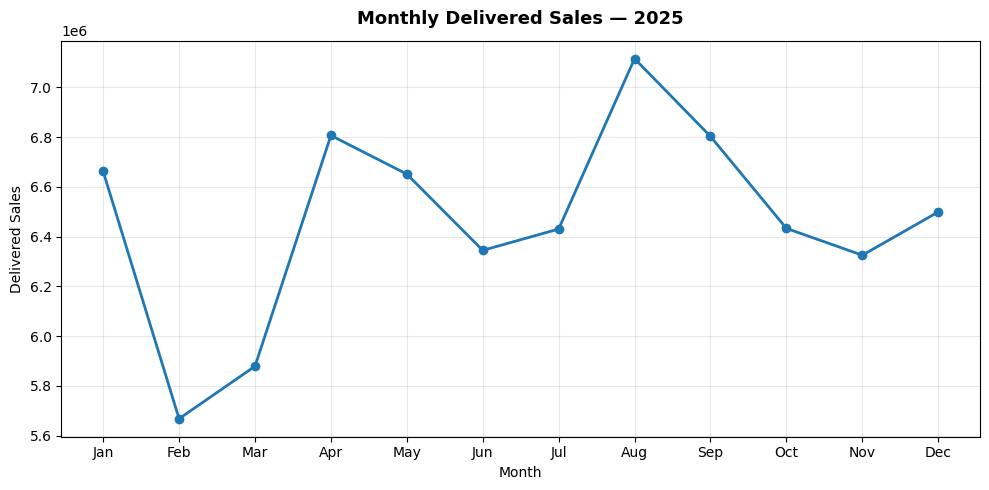

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [434]:
# ==========================================
# 12.1 MONTHLY DELIVERED SALES
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Delivered Sales — 2025",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Delivered Sales")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_delivered_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("monthly_delivered_sales.png")

In [435]:
# 12.2 Delivered Sales by Product Category

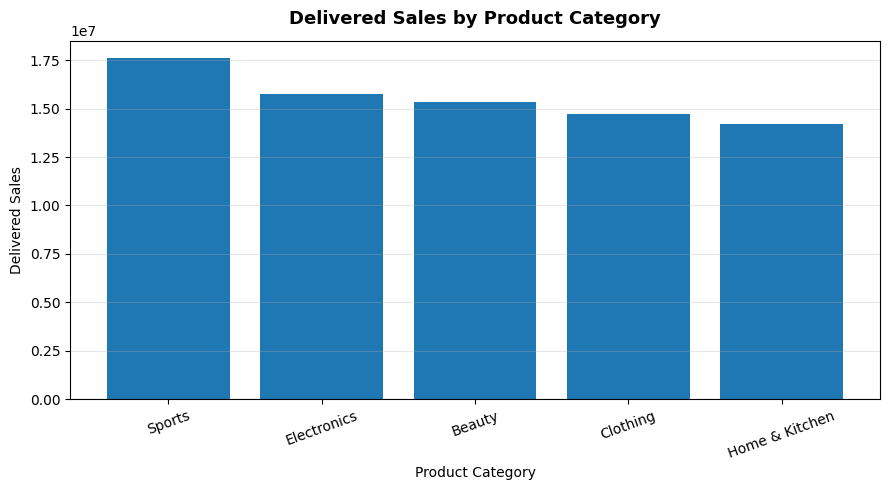

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [436]:
# ==========================================
# 12.2 DELIVERED SALES BY PRODUCT CATEGORY
# ==========================================

plt.figure(figsize=(9, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title(
    "Delivered Sales by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Delivered Sales")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "delivered_sales_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("delivered_sales_by_product_category.png")

In [437]:
# 12.3 Delivered Profit by Product Category

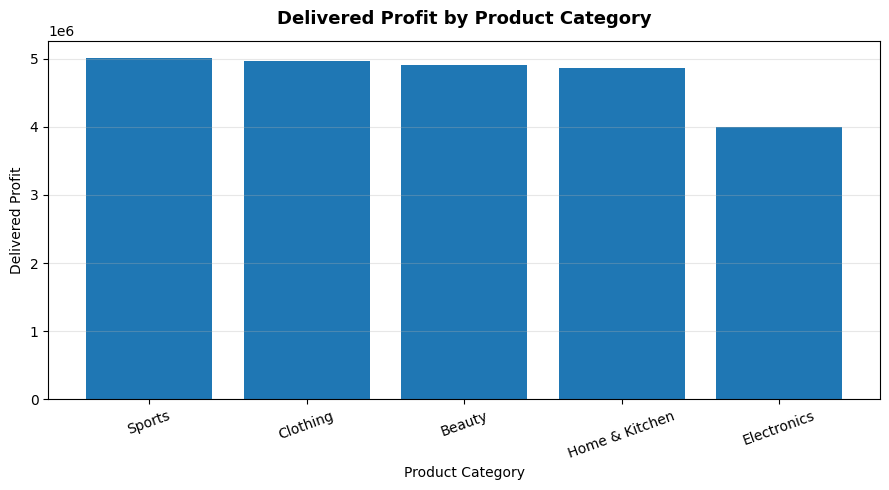

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [438]:
# ==========================================
# 12.3 DELIVERED PROFIT BY PRODUCT CATEGORY
# ==========================================

plt.figure(figsize=(9, 5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title(
    "Delivered Profit by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Delivered Profit")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "delivered_profit_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("delivered_profit_by_product_category.png")

In [439]:
# 12.4 Order Status Distribution

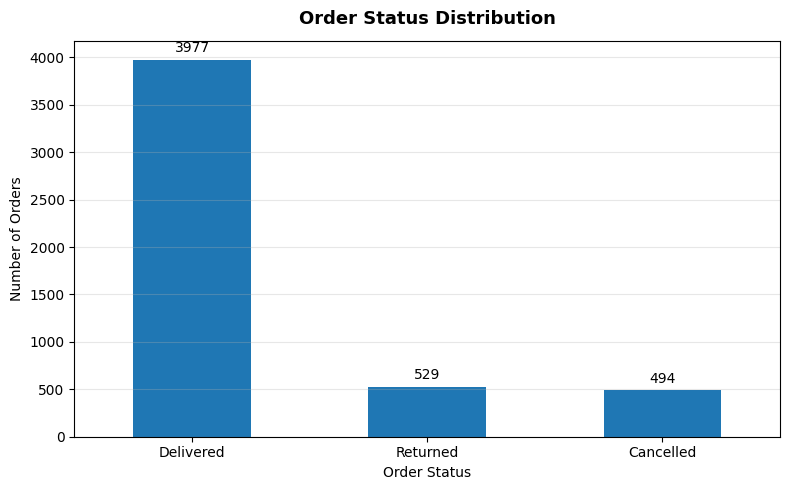

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [440]:
# ==========================================
# 12.4 ORDER STATUS DISTRIBUTION
# ==========================================

order_status = orders["order_status"].value_counts()

plt.figure(figsize=(8, 5))

ax = order_status.plot(
    kind="bar"
)

plt.title(
    "Order Status Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("order_status_distribution.png")

In [441]:
# 12.5 Orders by Payment Method

/tmp/ipykernel_3209/237617980.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


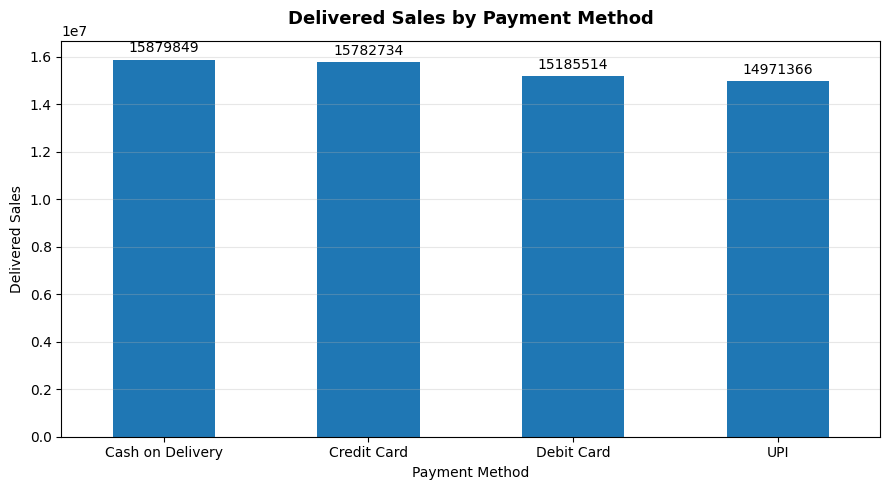

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [442]:
# ==========================================
# 12.5 DELIVERED SALES BY PAYMENT METHOD
# ==========================================

payment_sales = (
    orders[orders["order_status"] == "Delivered"]
    .groupby("payment_method")
    .apply(
        lambda x: x["order_id"].map(
            order_items.groupby("order_id")["quantity"].sum()
        ).fillna(0).sum()
    )
)

# Calculate sales directly
payment_sales = (
    orders[orders["order_status"] == "Delivered"]
    .merge(
        order_items,
        on="order_id"
    )
    .merge(
        products[["product_id", "selling_price"]],
        on="product_id"
    )
)

payment_sales["net_sales"] = (
    payment_sales["quantity"]
    * payment_sales["selling_price"]
    * (1 - payment_sales["discount"] / 100)
)

payment_sales = (
    payment_sales
    .groupby("payment_method")["net_sales"]
    .sum()
)

plt.figure(figsize=(9, 5))

ax = payment_sales.plot(
    kind="bar"
)

plt.title(
    "Delivered Sales by Payment Method",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Payment Method")
plt.ylabel("Delivered Sales")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "delivered_sales_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("delivered_sales_by_payment_method.png")

In [443]:
# 12.6 Delivered Sales by Customer Segment

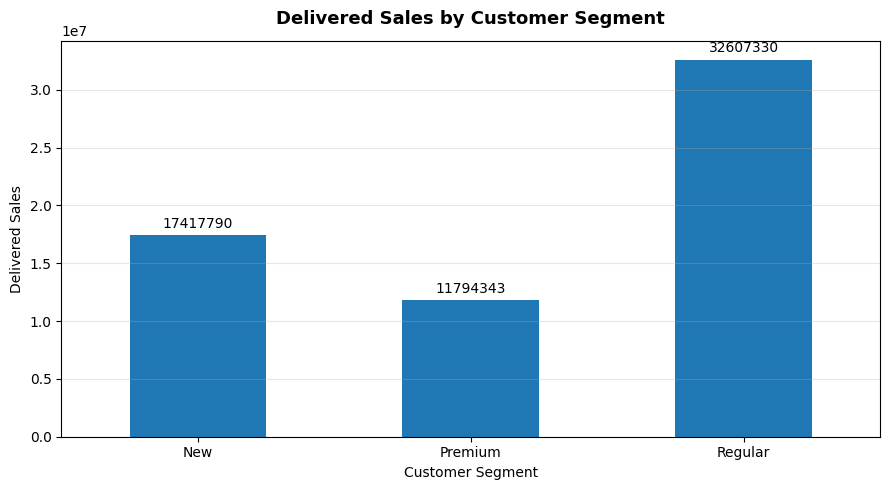

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [444]:
# ==========================================
# 12.6 DELIVERED SALES BY CUSTOMER SEGMENT
# ==========================================

segment_sales = (
    orders[orders["order_status"] == "Delivered"]
    .merge(
        customers[["customer_id", "customer_segment"]],
        on="customer_id"
    )
    .merge(
        order_items,
        on="order_id"
    )
    .merge(
        products[["product_id", "selling_price"]],
        on="product_id"
    )
)

segment_sales["net_sales"] = (
    segment_sales["quantity"]
    * segment_sales["selling_price"]
    * (1 - segment_sales["discount"] / 100)
)

segment_sales = (
    segment_sales
    .groupby("customer_segment")["net_sales"]
    .sum()
)

plt.figure(figsize=(9, 5))

ax = segment_sales.plot(
    kind="bar"
)

plt.title(
    "Delivered Sales by Customer Segment",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Customer Segment")
plt.ylabel("Delivered Sales")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "delivered_sales_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("delivered_sales_by_customer_segment.png")

In [445]:
# 12.7 Top 10 Products by Delivered Sales

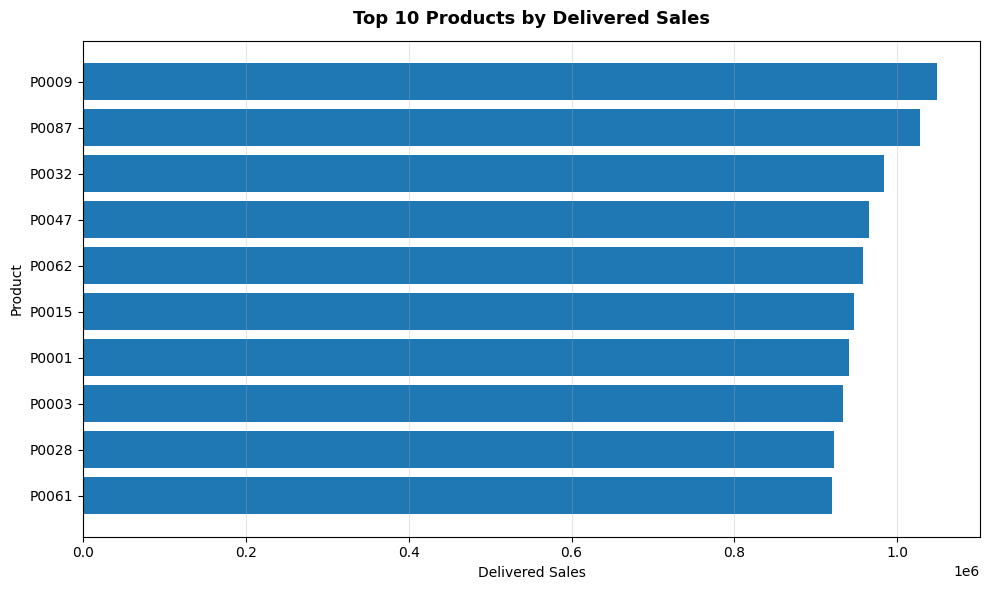

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [446]:
# ==========================================
# 12.7 TOP 10 PRODUCTS BY DELIVERED SALES
# ==========================================

top_products_data = (
    orders[orders["order_status"] == "Delivered"]
    .merge(order_items, on="order_id")
    .merge(
        products[["product_id", "selling_price"]],
        on="product_id"
    )
)

top_products_data["net_sales"] = (
    top_products_data["quantity"]
    * top_products_data["selling_price"]
    * (1 - top_products_data["discount"] / 100)
)

top_products_data = (
    top_products_data
    .groupby("product_id")["net_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_data.index[::-1],
    top_products_data.values[::-1]
)

plt.title(
    "Top 10 Products by Delivered Sales",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Delivered Sales")
plt.ylabel("Product")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "top_10_products_by_delivered_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("top_10_products_by_delivered_sales.png")

In [447]:
# 12.8 Monthly Delivered Profit

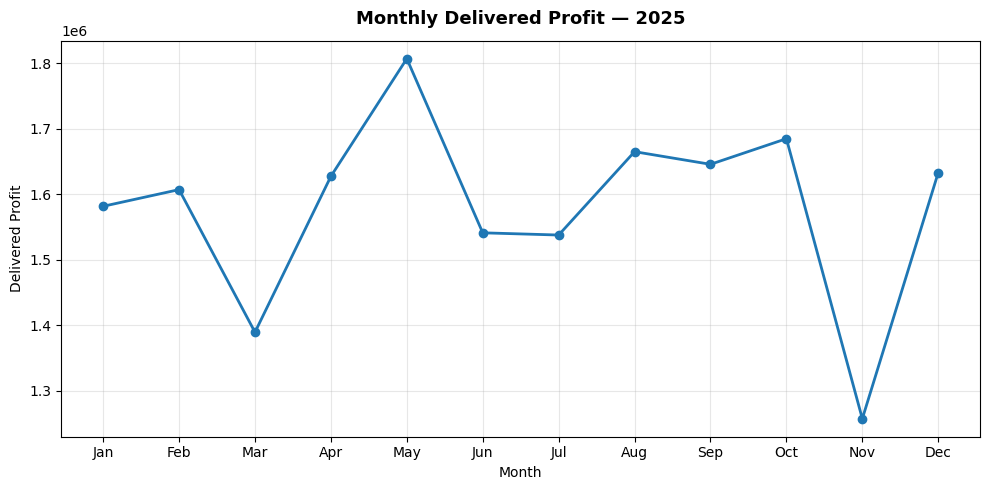

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [448]:
# ==========================================
# 12.8 MONTHLY DELIVERED PROFIT
# ==========================================

monthly_profit = (
    orders[orders["order_status"] == "Delivered"]
    .merge(order_items, on="order_id")
    .merge(
        products[["product_id", "selling_price", "cost_price"]],
        on="product_id"
    )
)

monthly_profit["profit_amount"] = (
    monthly_profit["quantity"]
    * (
        monthly_profit["selling_price"]
        * (1 - monthly_profit["discount"] / 100)
        - monthly_profit["cost_price"]
    )
)

monthly_profit["order_month"] = pd.to_datetime(
    monthly_profit["order_date"]
).dt.month

monthly_profit = (
    monthly_profit
    .groupby("order_month")["profit_amount"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Delivered Profit — 2025",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Delivered Profit")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_delivered_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("monthly_delivered_profit.png")

In [449]:
# 12.9 Customer Spending Distribution

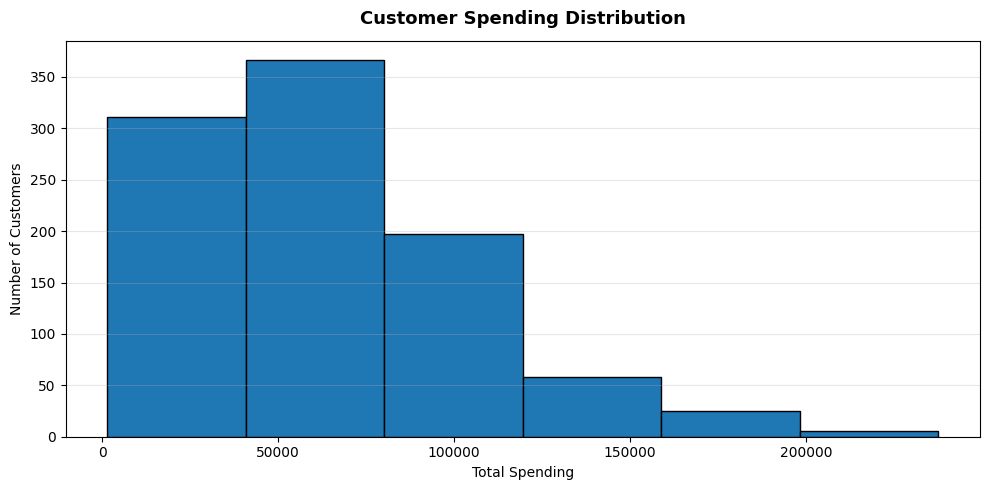

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [450]:
# ==========================================
# 12.9 CUSTOMER SPENDING DISTRIBUTION
# ==========================================

customer_spending = (
    orders[orders["order_status"] == "Delivered"]
    .merge(order_items, on="order_id")
    .merge(
        products[["product_id", "selling_price"]],
        on="product_id"
    )
)

customer_spending["net_sales"] = (
    customer_spending["quantity"]
    * customer_spending["selling_price"]
    * (1 - customer_spending["discount"] / 100)
)

customer_spending = (
    customer_spending
    .groupby("customer_id")["net_sales"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.hist(
    customer_spending,
    bins=6,
    edgecolor="black"
)

plt.title(
    "Customer Spending Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "customer_spending_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("customer_spending_distribution.png")

In [451]:
# 12.10 Website Sessions by Purchase Status

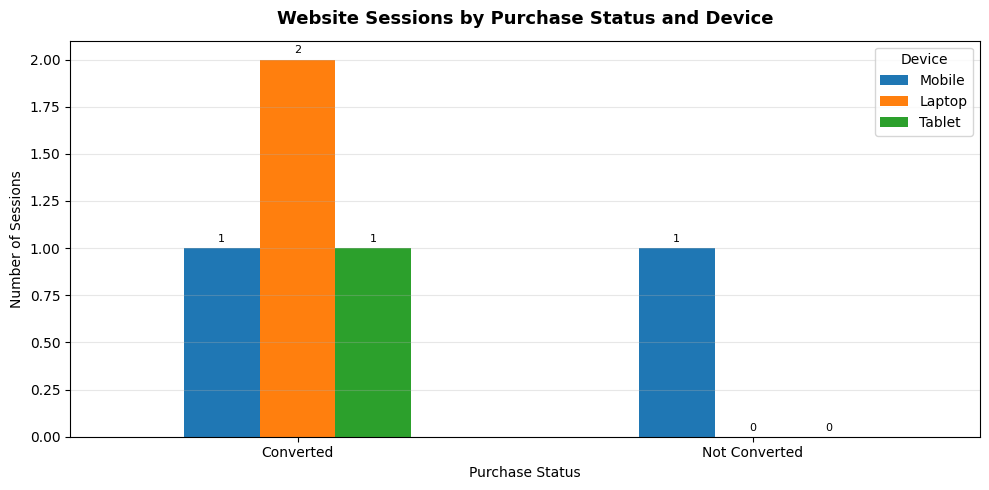

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [452]:
# ==========================================
# 12.10 WEBSITE SESSIONS BY PURCHASE STATUS
#        AND DEVICE
# ==========================================

session_device = pd.crosstab(
    website_activity["conversion_status"],
    website_activity["device"]
)

session_device = session_device.reindex(
    columns=["Mobile", "Laptop", "Tablet"],
    fill_value=0
)

ax = session_device.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Website Sessions by Purchase Status and Device",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Purchase Status")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=0)

plt.legend(title="Device")

plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "website_sessions_by_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("website_sessions_by_purchase_status.png")

In [453]:
# 12.11 Website Conversion Rate by Device

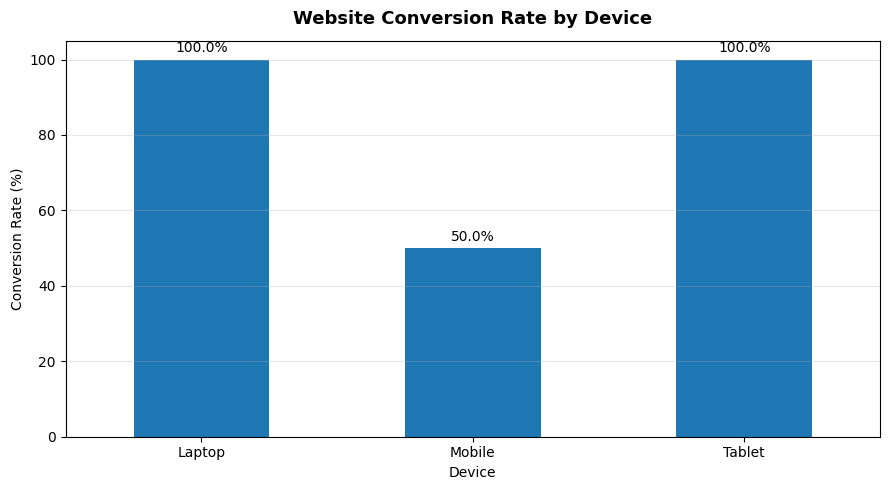

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [454]:
# ==========================================
# 12.11 WEBSITE CONVERSION RATE BY DEVICE
# ==========================================

conversion_rate = (
    website_activity
    .groupby("device")["purchased"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(9, 5))

ax = conversion_rate.plot(
    kind="bar"
)

plt.title(
    "Website Conversion Rate by Device",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "website_conversion_rate_by_device.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("website_conversion_rate_by_device.png")

In [455]:
# 12.12 Sales vs Profit by Product Category

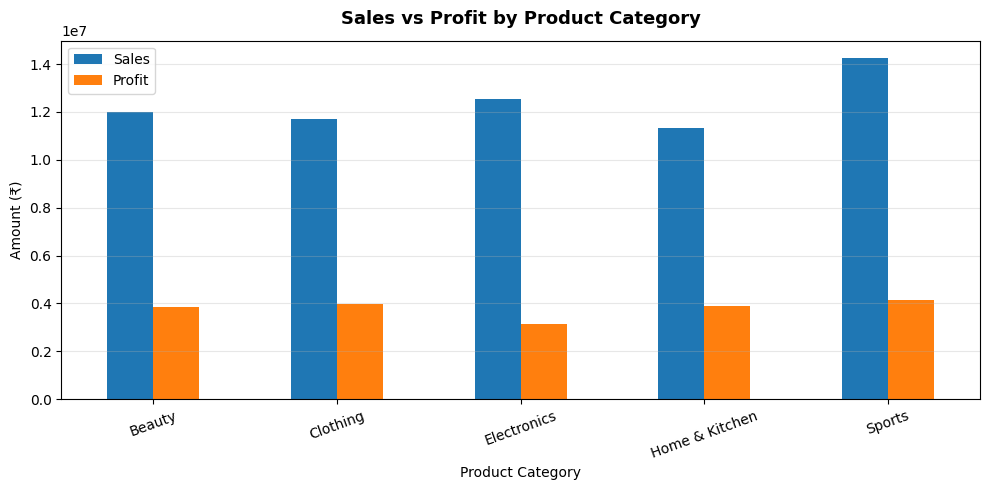

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [456]:
# ==========================================
# 12.12 SALES VS PROFIT BY PRODUCT CATEGORY
# ==========================================

category_data = (
    orders[orders["order_status"] == "Delivered"]
    .merge(order_items, on="order_id")
    .merge(
        products[
            [
                "product_id",
                "category",
                "selling_price",
                "cost_price"
            ]
        ],
        on="product_id"
    )
)

category_data["net_sales"] = (
    category_data["quantity"]
    * category_data["selling_price"]
    * (1 - category_data["discount"] / 100)
)

category_data["profit"] = (
    category_data["net_sales"]
    - (
        category_data["quantity"]
        * category_data["cost_price"]
    )
)

category_summary = (
    category_data
    .groupby("category")[["net_sales", "profit"]]
    .sum()
)

ax = category_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Sales vs Profit by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=20)

plt.legend(
    ["Sales", "Profit"]
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sales_vs_profit_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("sales_vs_profit_by_product_category.png")

In [457]:
# 12.13 Profit Margin by Product Category

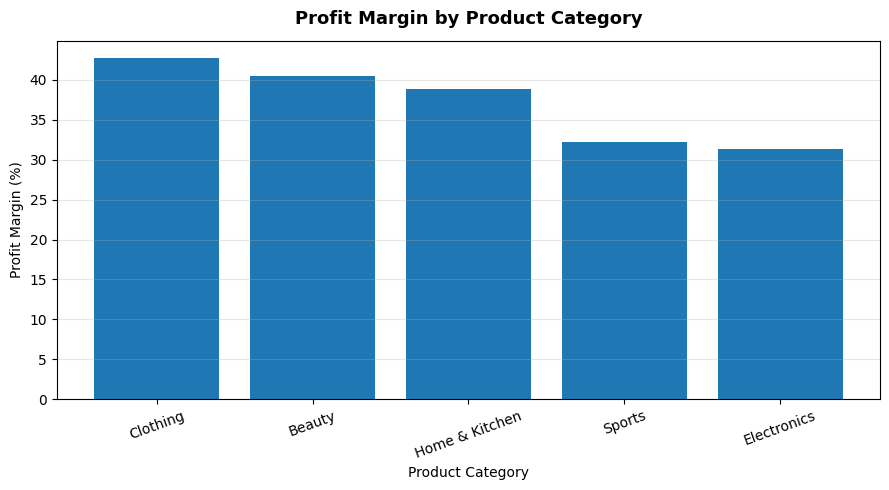

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [458]:
# ==========================================
# 12.13 PROFIT MARGIN BY PRODUCT CATEGORY
# ==========================================

plt.figure(figsize=(9, 5))

plt.bar(
    category_profit_margin.index,
    category_profit_margin.values
)

plt.title(
    "Profit Margin by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "profit_margin_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("profit_margin_by_product_category.png")

In [459]:
# 12.14 Monthly Delivered Sales with 3-Month Moving Average

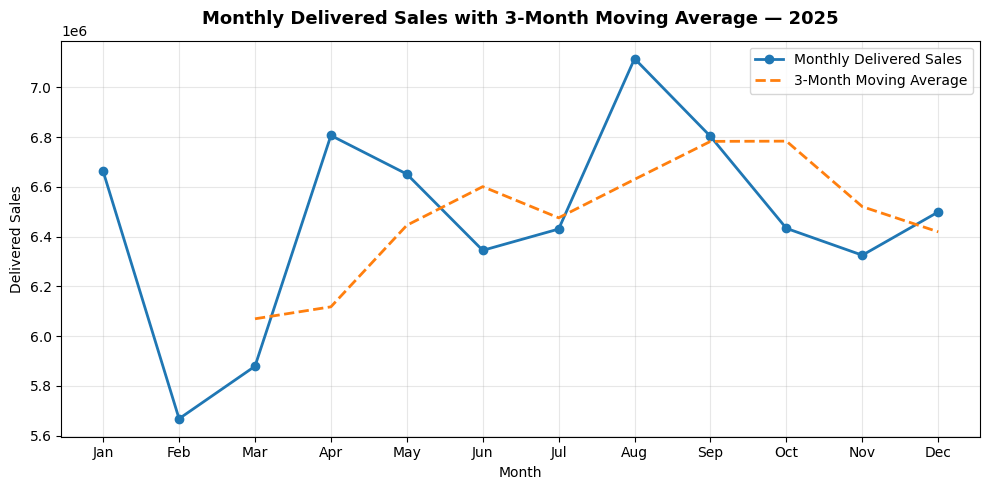

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [460]:
# ==========================================
# 12.14 MONTHLY DELIVERED SALES
#       WITH 3-MONTH MOVING AVERAGE
# ==========================================

sales_3m_ma = monthly_sales.rolling(
    window=3
).mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    label="Monthly Delivered Sales"
)

plt.plot(
    sales_3m_ma.index,
    sales_3m_ma.values,
    linestyle="--",
    linewidth=2,
    label="3-Month Moving Average"
)

plt.title(
    "Monthly Delivered Sales with 3-Month Moving Average — 2025",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Delivered Sales")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "monthly_delivered_sales_with_3_month_moving_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "monthly_delivered_sales_with_3_month_moving_average.png"
)

In [461]:
# 12.15 Top 10 Customers by Delivered Sales

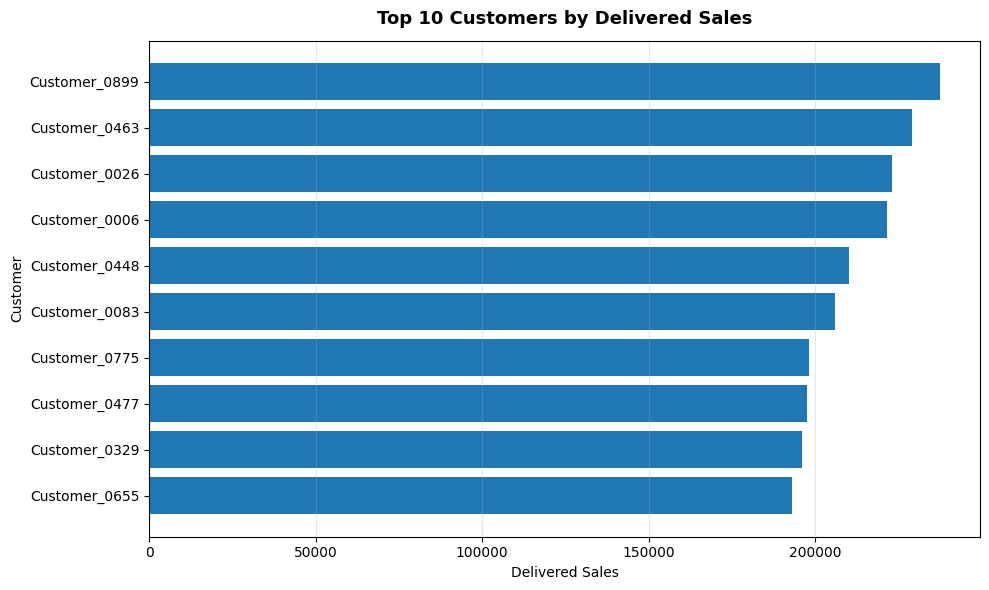

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [462]:
# ==========================================
# 12.15 TOP 10 CUSTOMERS BY DELIVERED SALES
# ==========================================

query = """
SELECT
    c.customer_id,
    c.customer_name,

    ROUND(
        SUM(
            oi.quantity * p.selling_price
            - (
                oi.quantity
                * p.selling_price
                * oi.discount / 100.0
            )
        ),
        2
    ) AS total_sales

FROM customers c

INNER JOIN orders o
    ON c.customer_id = o.customer_id

INNER JOIN order_items oi
    ON o.order_id = oi.order_id

INNER JOIN products p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'Delivered'

GROUP BY
    c.customer_id,
    c.customer_name

ORDER BY total_sales DESC

LIMIT 10;
"""

top_customers_data = pd.read_sql_query(
    query,
    conn
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_data["customer_name"][::-1],
    top_customers_data["total_sales"][::-1]
)

plt.title(
    "Top 10 Customers by Delivered Sales",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Delivered Sales")
plt.ylabel("Customer")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "top_10_customers_by_delivered_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("top_10_customers_by_delivered_sales.png")

In [463]:
# 12.16 Website Engagement vs Purchase Status

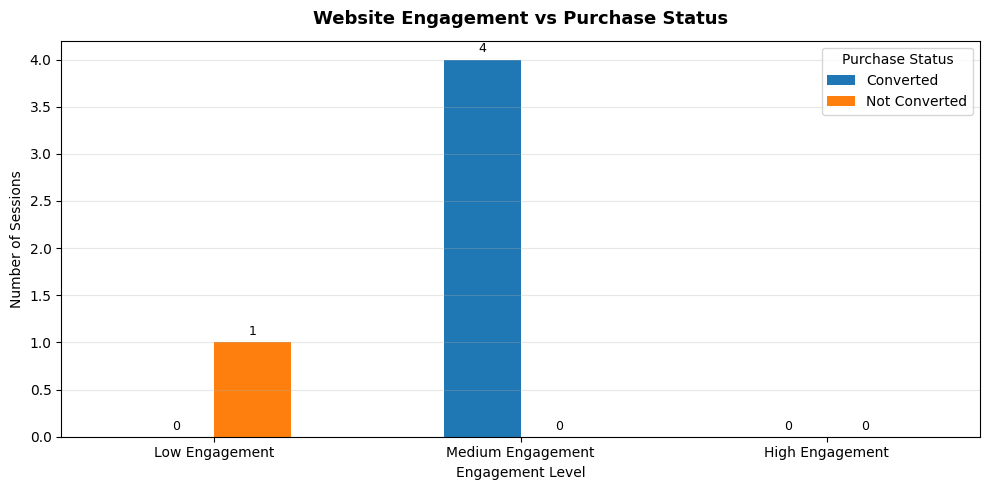

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [464]:
# ==========================================
# 12.16 WEBSITE ENGAGEMENT VS PURCHASE STATUS
# ==========================================

engagement_status = pd.crosstab(
    website_activity["engagement_level"],
    website_activity["conversion_status"]
)

# Logical order
engagement_order = [
    "Low Engagement",
    "Medium Engagement",
    "High Engagement"
]

engagement_status = engagement_status.reindex(
    engagement_order
)

# Make sure both columns exist
engagement_status = engagement_status.reindex(
    columns=["Converted", "Not Converted"],
    fill_value=0
)

# Create chart
ax = engagement_status.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Website Engagement vs Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Engagement Level")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=0)

plt.legend(
    title="Purchase Status"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add numbers above every bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

# Save PNG
plt.savefig(
    "website_engagement_vs_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Download PNG
from google.colab import files
files.download("website_engagement_vs_purchase_status.png")

In [465]:
# 12.17 Customer Order Frequency vs Delivered Sales

In [466]:
# ==========================================
# 12.17 DATA PREPARATION
# CUSTOMER ORDER FREQUENCY VS DELIVERED SALES
# ==========================================

customer_frequency_sales = pd.read_sql_query(
    """
    SELECT
        c.customer_id,
        c.customer_name,
        COUNT(DISTINCT o.order_id) AS order_frequency,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_sales
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        c.customer_id,
        c.customer_name
    ORDER BY total_sales DESC
    """,
    conn
)

customer_frequency_sales.head()

,customer_id,customer_name,order_frequency,total_sales
0,C0899,Customer_0899,8,237649.20
1,C0463,Customer_0463,6,229141.00
2,C0026,Customer_0026,10,223117.55
3,C0006,Customer_0006,7,221665.30
4,C0448,Customer_0448,11,210094.80


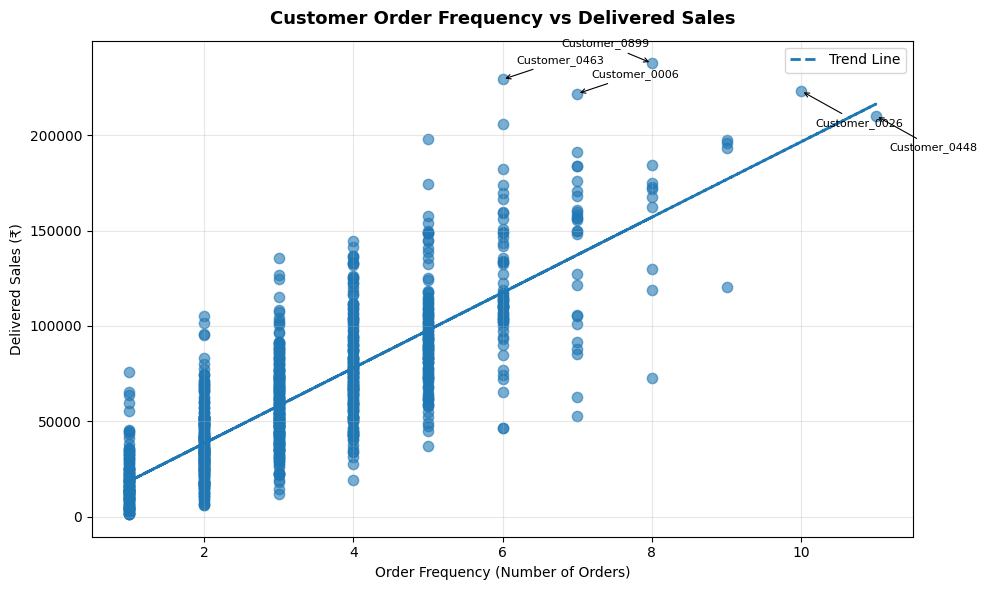

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [467]:
# ==========================================
# 12.17 CUSTOMER ORDER FREQUENCY VS DELIVERED SALES
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

data = customer_frequency_sales.copy()

x = data["order_frequency"]
y = data["total_sales"]

# Calculate trend line
slope, intercept = np.polyfit(x, y, 1)
trend_y = slope * x + intercept

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.6,
    s=55
)

plt.plot(
    x,
    trend_y,
    linestyle="--",
    linewidth=2,
    label="Trend Line"
)

# Label top 5 customers by delivered sales
top_5 = data.nlargest(5, "total_sales")

label_offsets = [
    (-65, 12),
    (10, 12),
    (10, -25),
    (10, 12),
    (10, -25)
]

for (_, row), (dx, dy) in zip(
    top_5.iterrows(),
    label_offsets
):
    plt.annotate(
        row["customer_name"],
        (row["order_frequency"], row["total_sales"]),
        textcoords="offset points",
        xytext=(dx, dy),
        fontsize=8,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8
        )
    )

plt.title(
    "Customer Order Frequency vs Delivered Sales",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Order Frequency (Number of Orders)")
plt.ylabel("Delivered Sales (₹)")

plt.grid(
    axis="both",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "customer_order_frequency_vs_delivered_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "customer_order_frequency_vs_delivered_sales.png"
)

In [468]:
# 12.18 Pages Viewed vs Purchases

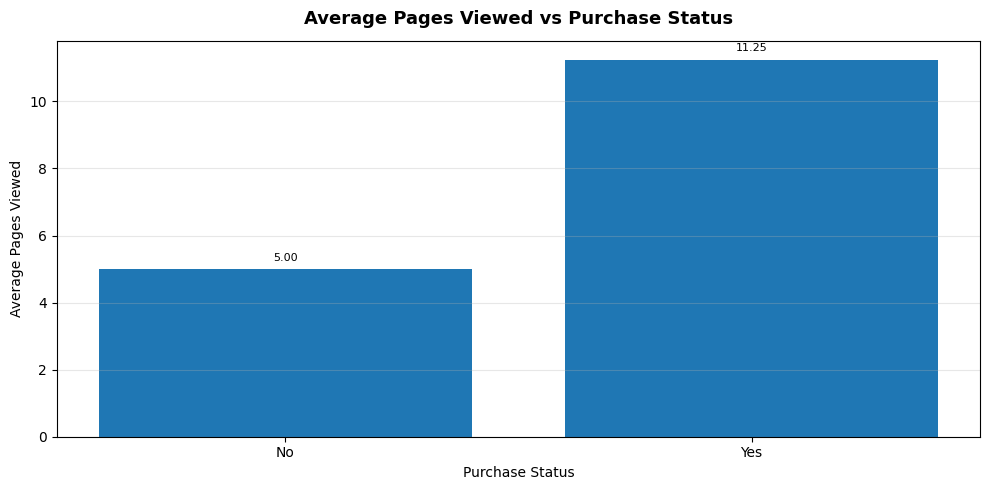

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [469]:
# ==========================================
# 12.18 PAGES VIEWED VS PURCHASES
# ==========================================

import matplotlib.pyplot as plt

purchase_pages = (
    website_activity
    .groupby("purchased")["pages_viewed"]
    .mean()
    .reindex(["No", "Yes"])
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    purchase_pages.index,
    purchase_pages.values
)

plt.title(
    "Average Pages Viewed vs Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Purchase Status")
plt.ylabel("Average Pages Viewed")

plt.xticks(rotation=0)

# Add values above each bar
for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "pages_viewed_vs_purchases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("pages_viewed_vs_purchases.png")

In [470]:
# 12.19 Sales by Customer Segment

In [471]:
# ==========================================
# 12.19 DATA PREPARATION
# SALES BY CUSTOMER SEGMENT
# ==========================================

segment_sales_dashboard = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN customer_sales >= 100000 THEN 'High Value'
            WHEN customer_sales >= 50000 THEN 'Medium Value'
            ELSE 'Low Value'
        END AS customer_segment,
        ROUND(SUM(customer_sales), 2) AS total_sales
    FROM (
        SELECT
            c.customer_id,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS customer_sales
        FROM customers c
        INNER JOIN orders o
            ON c.customer_id = o.customer_id
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY c.customer_id
    )
    GROUP BY customer_segment
    ORDER BY total_sales DESC
    """,
    conn
)

segment_sales_dashboard

,customer_segment,total_sales
0,Medium Value,26730051.30
1,High Value,23357992.55
2,Low Value,11731418.75


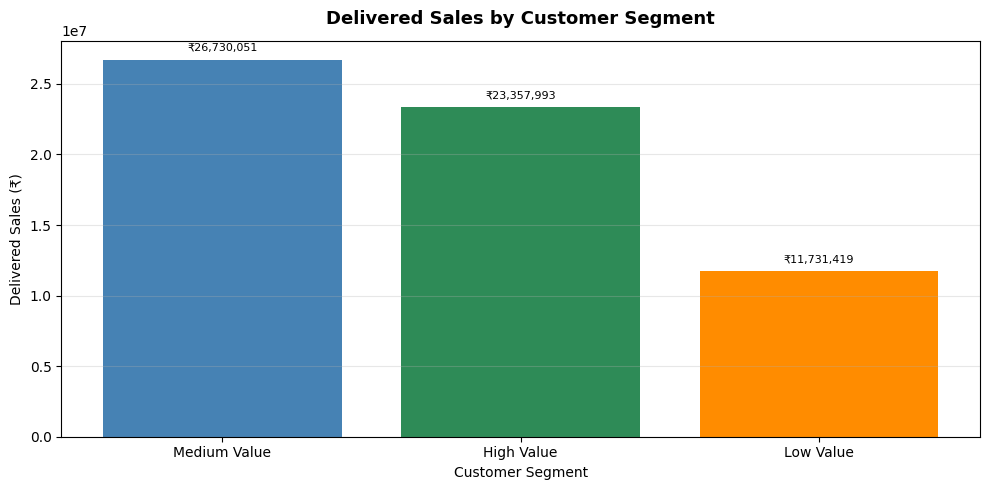

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [472]:
# ==========================================
# 12.19 SALES BY CUSTOMER SEGMENT
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    segment_sales_dashboard["customer_segment"],
    segment_sales_dashboard["total_sales"],
    color=["steelblue", "seagreen", "darkorange"]
)

plt.title(
    "Delivered Sales by Customer Segment",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Customer Segment")
plt.ylabel("Delivered Sales (₹)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sales_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("sales_by_customer_segment.png")

In [473]:
# 12.20 Customer Count vs Sales by Segment

In [474]:
# ==========================================
# 12.20 DATA PREPARATION
# CUSTOMER COUNT VS SALES BY SEGMENT
# ==========================================

customer_count_sales_segment = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN customer_sales >= 100000 THEN 'High Value'
            WHEN customer_sales >= 50000 THEN 'Medium Value'
            ELSE 'Low Value'
        END AS customer_segment,
        COUNT(*) AS customer_count,
        ROUND(SUM(customer_sales), 2) AS total_sales
    FROM (
        SELECT
            c.customer_id,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS customer_sales
        FROM customers c
        INNER JOIN orders o
            ON c.customer_id = o.customer_id
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY c.customer_id
    )
    GROUP BY customer_segment
    ORDER BY total_sales DESC
    """,
    conn
)

customer_count_sales_segment

,customer_segment,customer_count,total_sales
0,Medium Value,374,26730051.30
1,High Value,178,23357992.55
2,Low Value,412,11731418.75


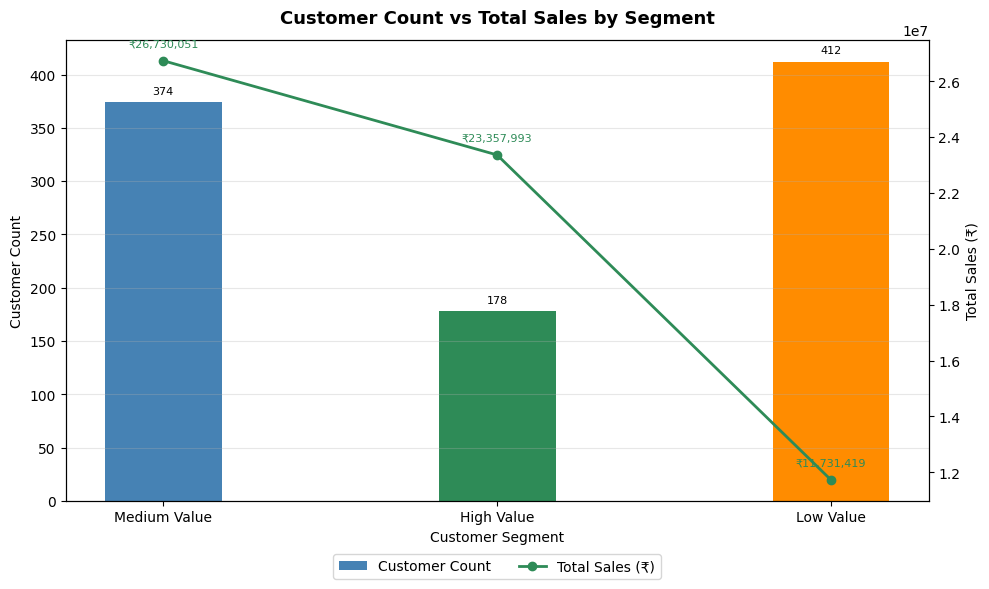

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [475]:
# ==========================================
# 12.20 CUSTOMER COUNT VS SALES BY SEGMENT
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

segments = customer_count_sales_segment["customer_segment"]
customer_count = customer_count_sales_segment["customer_count"]
total_sales = customer_count_sales_segment["total_sales"]

x = np.arange(len(segments))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Customer count bars
bars = ax1.bar(
    x,
    customer_count,
    width,
    color=["steelblue", "seagreen", "darkorange"],
    label="Customer Count"
)

ax1.set_xlabel("Customer Segment")
ax1.set_ylabel("Customer Count")

ax1.set_xticks(x)
ax1.set_xticklabels(segments)

# Add customer count labels
for bar in bars:
    value = bar.get_height()

    ax1.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

# Sales line
ax2 = ax1.twinx()

ax2.plot(
    x,
    total_sales,
    marker="o",
    linewidth=2,
    color="seagreen",
    label="Total Sales (₹)"
)

ax2.set_ylabel("Total Sales (₹)")

# Add sales labels
for i, value in enumerate(total_sales):
    ax2.annotate(
        f"₹{value:,.0f}",
        (x[i], value),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color="seagreen"
    )

plt.title(
    "Customer Count vs Total Sales by Segment",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax1.grid(
    axis="y",
    alpha=0.3
)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "customer_count_vs_sales_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "customer_count_vs_sales_by_segment.png"
)

In [476]:
# 12.21 — Customer Spending vs Order Frequency

In [477]:
# ==========================================
# 12.21 DATA PREPARATION
# CUSTOMER SPENDING VS ORDER FREQUENCY
# ==========================================

customer_spending_vs_frequency = pd.read_sql_query(
    """
    SELECT
        c.customer_id,
        c.customer_name,
        COUNT(DISTINCT o.order_id) AS order_frequency,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_spending
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        c.customer_id,
        c.customer_name
    ORDER BY total_spending DESC
    """,
    conn
)

customer_spending_vs_frequency.head()

,customer_id,customer_name,order_frequency,total_spending
0,C0899,Customer_0899,8,237649.20
1,C0463,Customer_0463,6,229141.00
2,C0026,Customer_0026,10,223117.55
3,C0006,Customer_0006,7,221665.30
4,C0448,Customer_0448,11,210094.80


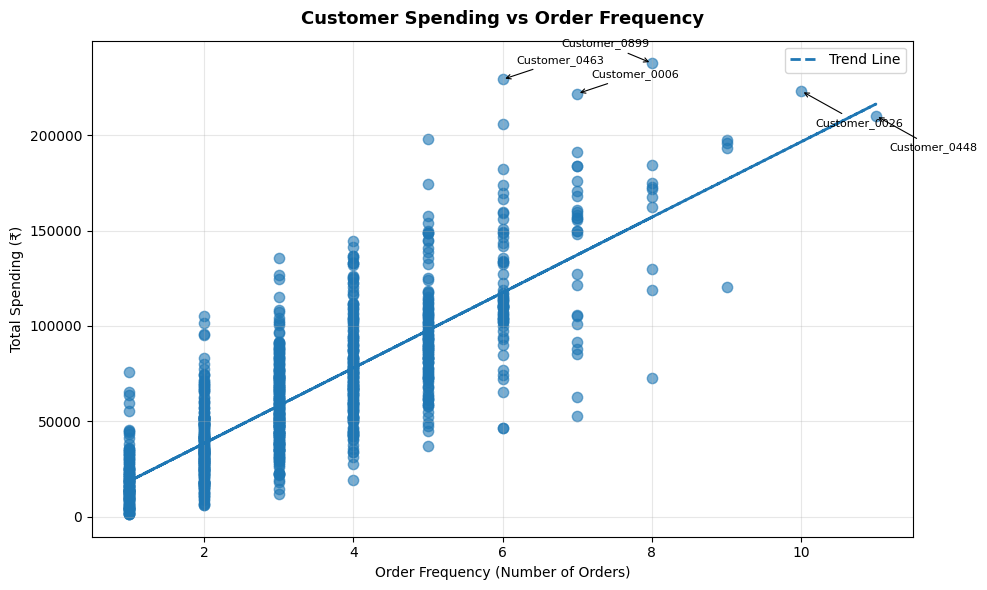

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [478]:
# ==========================================
# 12.21 CUSTOMER SPENDING VS ORDER FREQUENCY
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

data = customer_spending_vs_frequency.copy()

x = data["order_frequency"]
y = data["total_spending"]

# Calculate trend line
slope, intercept = np.polyfit(x, y, 1)
trend_y = slope * x + intercept

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.6,
    s=55
)

plt.plot(
    x,
    trend_y,
    linestyle="--",
    linewidth=2,
    label="Trend Line"
)

# Label top 5 customers by spending
top_5 = data.nlargest(5, "total_spending")

label_offsets = [
    (-65, 12),
    (10, 12),
    (10, -25),
    (10, 12),
    (10, -25)
]

for (_, row), (dx, dy) in zip(
    top_5.iterrows(),
    label_offsets
):
    plt.annotate(
        row["customer_name"],
        (row["order_frequency"], row["total_spending"]),
        textcoords="offset points",
        xytext=(dx, dy),
        fontsize=8,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8
        )
    )

plt.title(
    "Customer Spending vs Order Frequency",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Order Frequency (Number of Orders)")
plt.ylabel("Total Spending (₹)")

plt.grid(
    axis="both",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "customer_spending_vs_order_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "customer_spending_vs_order_frequency.png"
)

In [479]:
# 12.22 — Profit Margin by Price Category

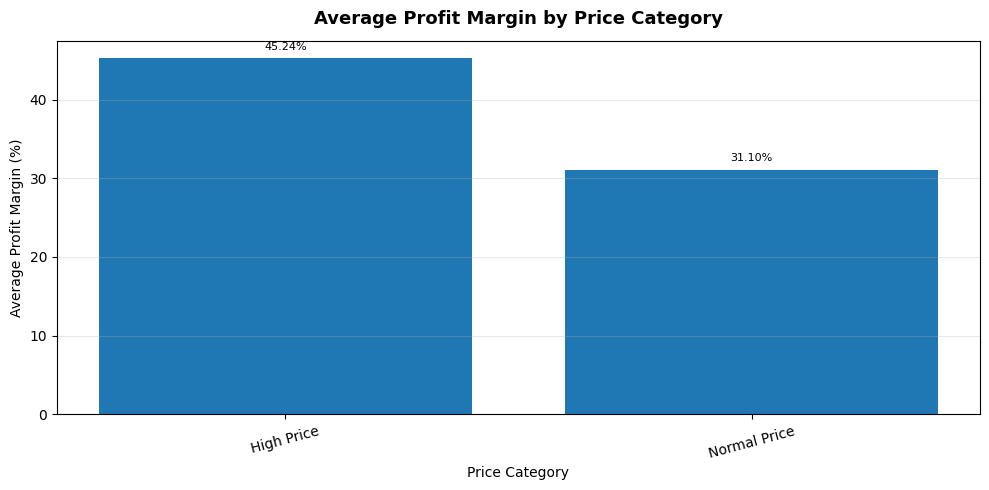

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [480]:
# ==========================================
# 12.22 PROFIT MARGIN BY PRICE CATEGORY
# ==========================================

margin_by_price_category = (
    products
    .groupby("price_category")["profit_margin"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    margin_by_price_category.index,
    margin_by_price_category.values
)

plt.title(
    "Average Profit Margin by Price Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Price Category")
plt.ylabel("Average Profit Margin (%)")

plt.xticks(rotation=15)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "profit_margin_by_price_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("profit_margin_by_price_category.png")

In [481]:
# 12.23 — Product Category Distribution

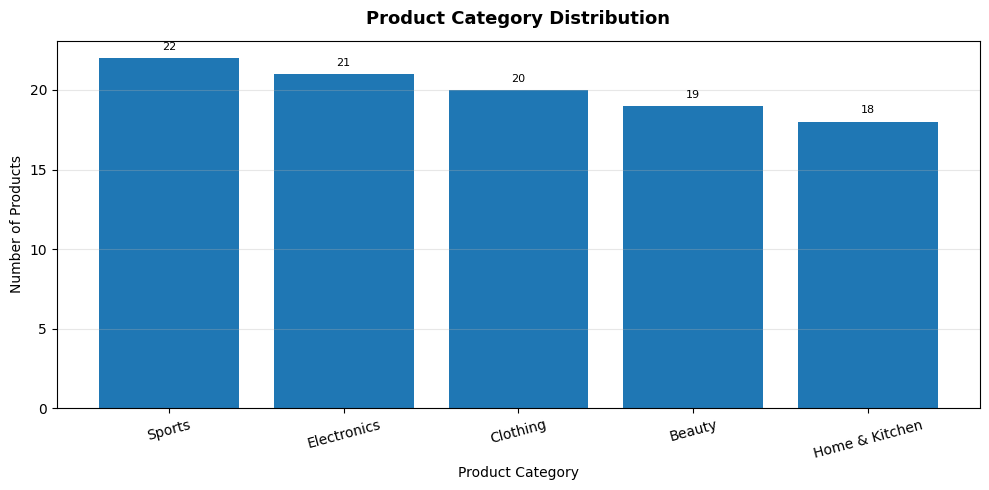

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [482]:
# ==========================================
# 12.23 PRODUCT CATEGORY DISTRIBUTION
# ==========================================

category_distribution = (
    products["category"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    category_distribution.index,
    category_distribution.values
)

plt.title(
    "Product Category Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=15)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "product_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("product_category_distribution.png")

In [483]:
# 12.24 — Customer Review Rating Distribution

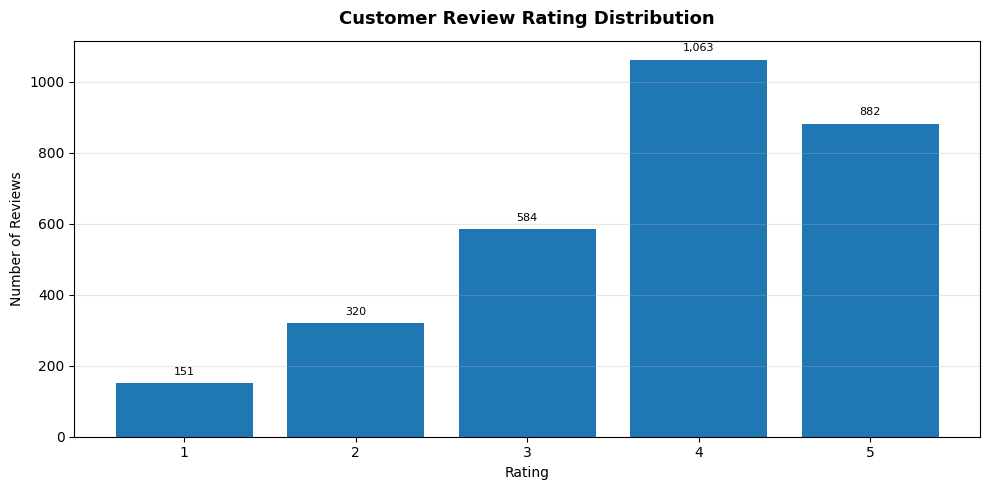

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [484]:
# ==========================================
# 12.24 CUSTOMER REVIEW RATING DISTRIBUTION
# ==========================================

review_rating_distribution = (
    reviews["rating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    review_rating_distribution.index.astype(str),
    review_rating_distribution.values
)

plt.title(
    "Customer Review Rating Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "customer_review_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("customer_review_rating_distribution.png")

In [485]:
# 12.25 — Website Sessions by Device

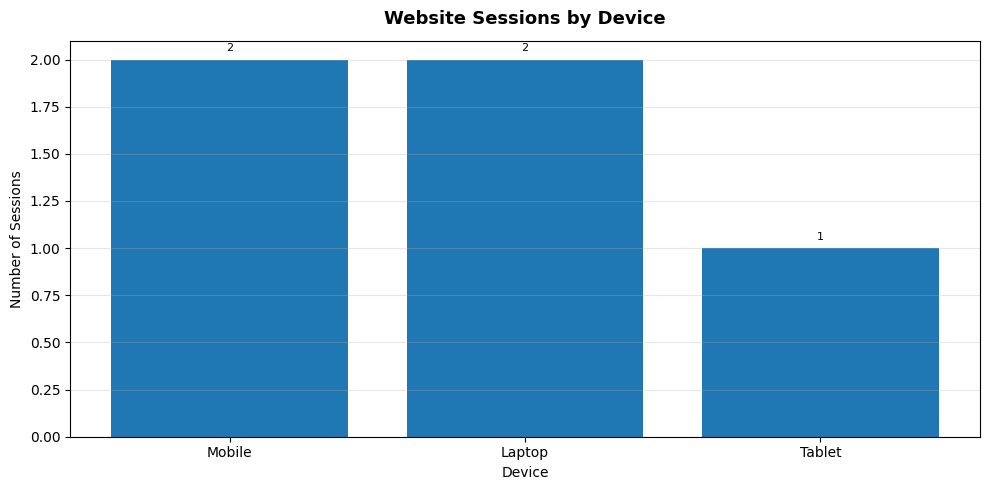

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [486]:
# ==========================================
# 12.25 WEBSITE SESSIONS BY DEVICE
# ==========================================

device_sessions = (
    website_activity["device"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    device_sessions.index,
    device_sessions.values
)

plt.title(
    "Website Sessions by Device",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "website_sessions_by_device.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("website_sessions_by_device.png")

In [487]:
# 12.26 — Discount vs Profit Margin

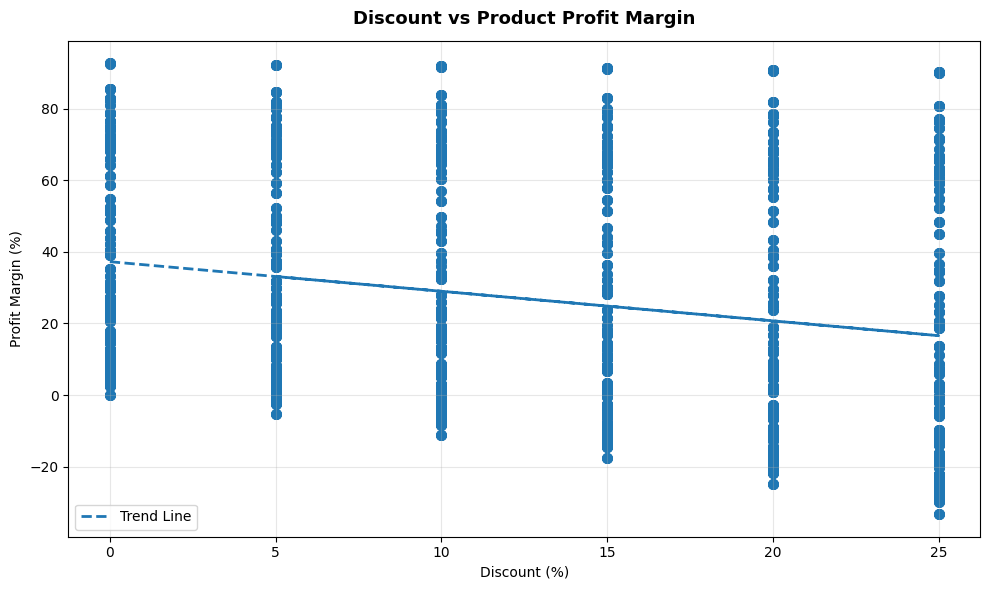

Correlation between Discount and Profit Margin: -0.2159


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [488]:
# ==========================================
# 12.26 DISCOUNT VS PROFIT MARGIN
# ==========================================

discount_data = (
    order_items_products[
        ["discount", "profit_margin"]
    ]
    .dropna()
)

x = discount_data["discount"]
y = discount_data["profit_margin"]

slope, intercept = np.polyfit(x, y, 1)
trend_y = slope * x + intercept

correlation = discount_data[
    ["discount", "profit_margin"]
].corr().iloc[0, 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.5,
    s=45
)

plt.plot(
    x,
    trend_y,
    linestyle="--",
    linewidth=2,
    label="Trend Line"
)

plt.title(
    "Discount vs Product Profit Margin",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.grid(
    axis="both",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "discount_vs_profit_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Correlation between Discount and Profit Margin: "
    f"{correlation:.4f}"
)

from google.colab import files
files.download("discount_vs_profit_margin.png")

In [489]:
# 12.27 — Average Session Duration by Device

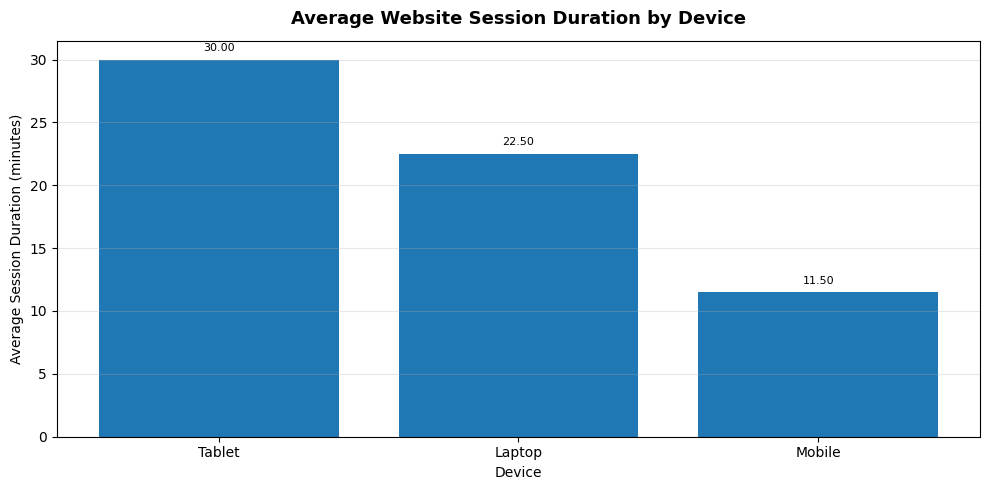

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [490]:
# ==========================================
# 12.27 AVERAGE SESSION DURATION BY DEVICE
# ==========================================

avg_session_duration = (
    website_activity
    .groupby("device")["session_duration"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_session_duration.index,
    avg_session_duration.values
)

plt.title(
    "Average Website Session Duration by Device",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Session Duration (minutes)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_session_duration_by_device.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("average_session_duration_by_device.png")

In [491]:
# 12.28 — Average Pages Viewed by Device

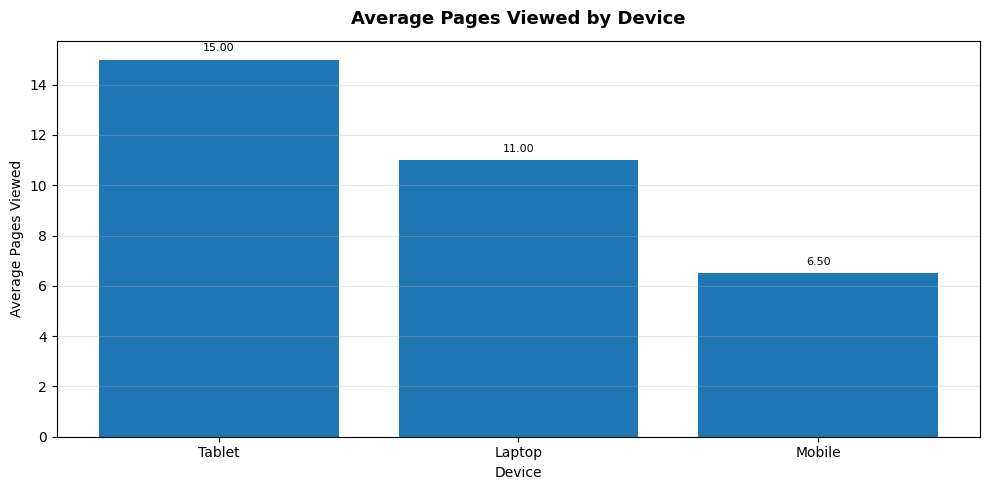

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [492]:
# ==========================================
# 12.28 AVERAGE PAGES VIEWED BY DEVICE
# ==========================================

avg_pages_by_device = (
    website_activity
    .groupby("device")["pages_viewed"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_pages_by_device.index,
    avg_pages_by_device.values
)

plt.title(
    "Average Pages Viewed by Device",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Pages Viewed")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_pages_viewed_by_device.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("average_pages_viewed_by_device.png")

In [493]:
# 12.29 — Website Engagement Level Distribution

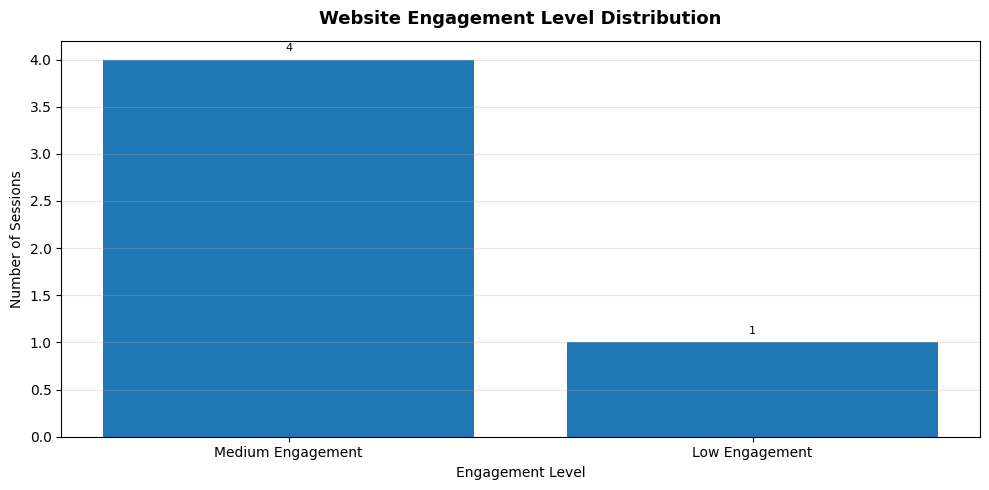

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [494]:
# ==========================================
# 12.29 WEBSITE ENGAGEMENT LEVEL DISTRIBUTION
# ==========================================

engagement_distribution = (
    website_activity["engagement_level"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    engagement_distribution.index,
    engagement_distribution.values
)

plt.title(
    "Website Engagement Level Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Engagement Level")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "website_engagement_level_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("website_engagement_level_distribution.png")

In [495]:
# 12.30 — Conversion Rate by Engagement Level

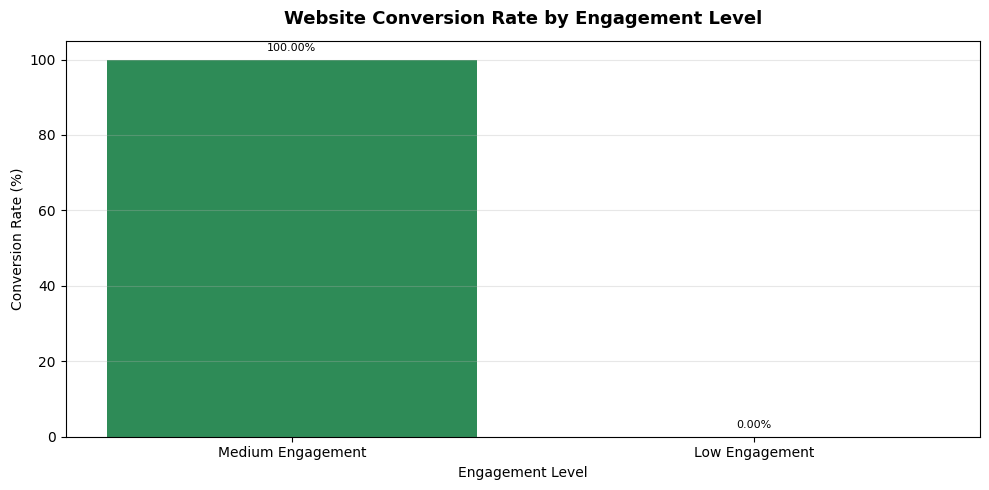

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [496]:
# ==========================================
# 12.30 CONVERSION RATE BY ENGAGEMENT LEVEL
# ==========================================

conversion_by_engagement = (
    website_activity
    .groupby("engagement_level")["purchased"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    conversion_by_engagement.index,
    conversion_by_engagement.values,
    color=["seagreen", "steelblue", "darkorange"]
)

plt.title(
    "Website Conversion Rate by Engagement Level",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Engagement Level")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "conversion_rate_by_engagement_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "conversion_rate_by_engagement_level.png"
)

In [497]:
# 12.31 — Average Delivered Order Value by Product Category

In [498]:
# ==========================================
# 12.31 DATA PREPARATION
# AVERAGE DELIVERED ORDER VALUE BY CATEGORY
# ==========================================

avg_order_value_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            )
            / COUNT(DISTINCT o.order_id),
            2
        ) AS average_order_value
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY average_order_value DESC
    """,
    conn
)

avg_order_value_category

,category,average_order_value
0,Home & Kitchen,11975.96
1,Beauty,11742.60
2,Sports,11529.89
3,Clothing,10940.43
4,Electronics,10720.50


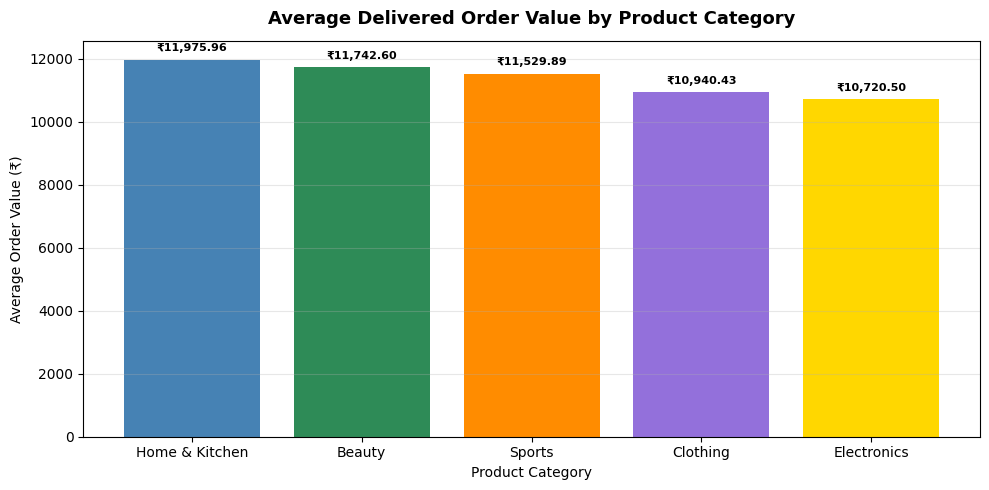

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [499]:
# ==========================================
# 12.31 AVERAGE DELIVERED ORDER VALUE BY CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_order_value_category["category"],
    avg_order_value_category["average_order_value"],
    color=[
        "steelblue",
        "seagreen",
        "darkorange",
        "mediumpurple",
        "gold"
    ]
)

plt.title(
    "Average Delivered Order Value by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Order Value (₹)")

plt.xticks(rotation=0)

# Add values above each bar
for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_delivered_order_value_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_delivered_order_value_by_category.png"
)

In [500]:
# 12.32 — Average Discount by Product Category

In [501]:
# ==========================================
# 12.32 DATA PREPARATION
# AVERAGE DISCOUNT BY PRODUCT CATEGORY
# ==========================================

avg_discount_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(AVG(oi.discount), 2) AS average_discount
    FROM order_items oi
    INNER JOIN products p
        ON oi.product_id = p.product_id
    INNER JOIN orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY average_discount DESC
    """,
    conn
)

avg_discount_category

,category,average_discount
0,Home & Kitchen,12.81
1,Electronics,12.79
2,Clothing,12.50
3,Beauty,12.33
4,Sports,12.29


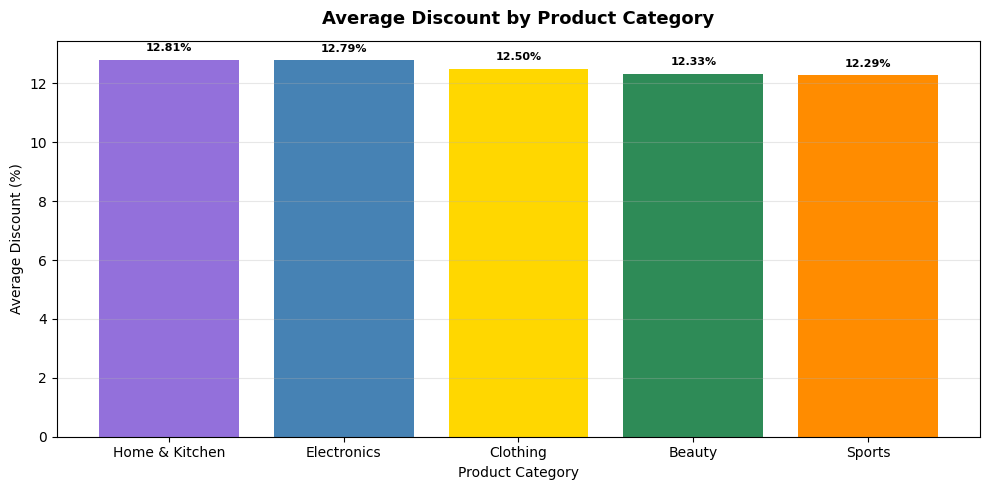

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [502]:
# ==========================================
# 12.32 AVERAGE DISCOUNT BY PRODUCT CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_discount_category["category"],
    avg_discount_category["average_discount"],
    color=[
        "mediumpurple",
        "steelblue",
        "gold",
        "seagreen",
        "darkorange"
    ]
)

plt.title(
    "Average Discount by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=0)

# Add percentage values above each bar
for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_discount_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_discount_by_product_category.png"
)

In [503]:
# 12.33 — Return Rate by Product Category

In [504]:
# ==========================================
# 12.33 DATA PREPARATION
# RETURN RATE BY PRODUCT CATEGORY
# ==========================================

return_rate_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        COUNT(DISTINCT CASE
            WHEN o.order_status = 'Returned'
            THEN o.order_id
        END) * 100.0
        / COUNT(DISTINCT o.order_id) AS return_rate
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY p.category
    ORDER BY return_rate DESC
    """,
    conn
)

return_rate_category["return_rate"] = (
    return_rate_category["return_rate"].round(2)
)

return_rate_category

,category,return_rate
0,Beauty,11.33
1,Clothing,10.82
2,Home & Kitchen,10.77
3,Electronics,10.43
4,Sports,10.02


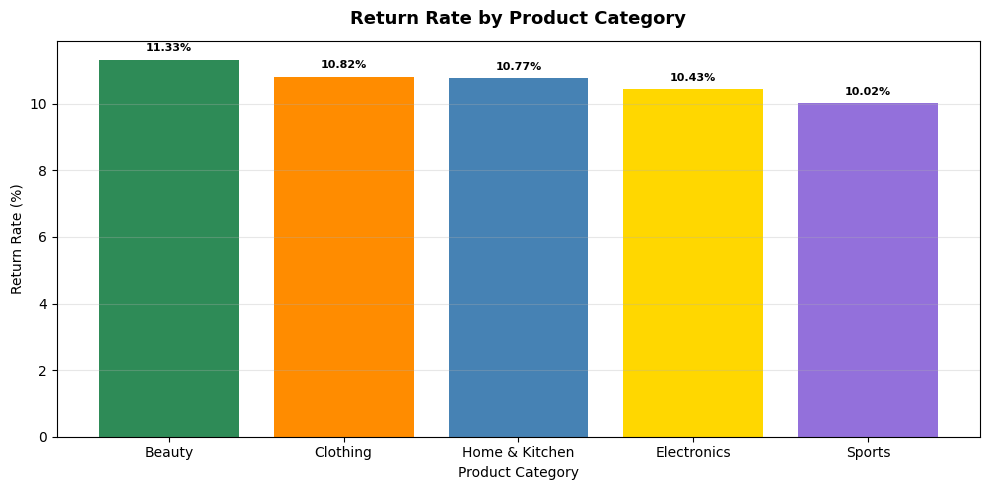

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [505]:
# ==========================================
# 12.33 RETURN RATE BY PRODUCT CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    return_rate_category["category"],
    return_rate_category["return_rate"],
    color=[
        "seagreen",
        "darkorange",
        "steelblue",
        "gold",
        "mediumpurple"
    ]
)

plt.title(
    "Return Rate by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "return_rate_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "return_rate_by_product_category.png"
)

In [506]:
# 12.34 — Average Quantity per Order by Product Category

In [507]:
# ==========================================
# 12.34 DATA PREPARATION
# AVERAGE QUANTITY PER ORDER BY CATEGORY
# ==========================================

avg_quantity_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            SUM(oi.quantity) * 1.0
            / COUNT(DISTINCT o.order_id),
            2
        ) AS average_quantity_per_order
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY average_quantity_per_order DESC
    """,
    conn
)

avg_quantity_category

,category,average_quantity_per_order
0,Clothing,2.97
1,Sports,2.94
2,Electronics,2.94
3,Beauty,2.93
4,Home & Kitchen,2.89


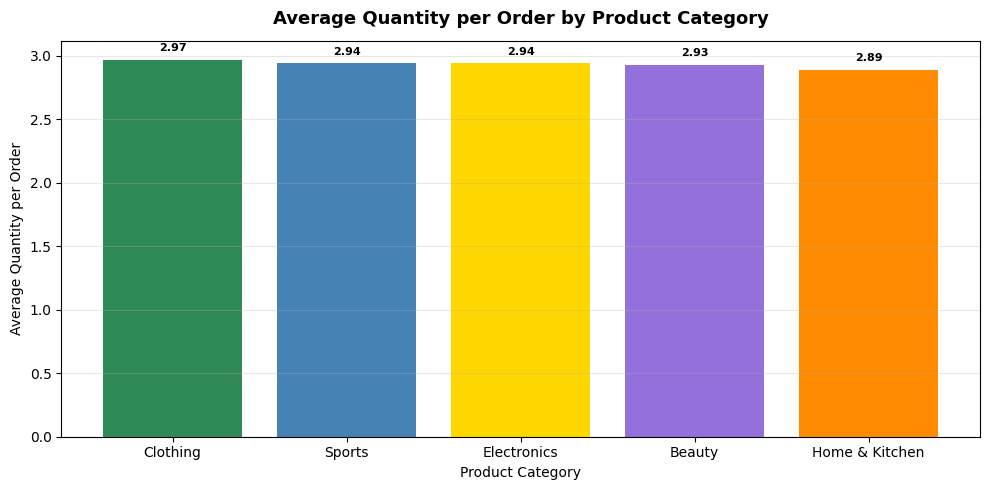

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [508]:
# ==========================================
# 12.34 AVERAGE QUANTITY PER ORDER BY CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_quantity_category["category"],
    avg_quantity_category["average_quantity_per_order"],
    color=[
        "seagreen",
        "steelblue",
        "gold",
        "mediumpurple",
        "darkorange"
    ]
)

plt.title(
    "Average Quantity per Order by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Quantity per Order")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_quantity_per_order_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_quantity_per_order_by_category.png"
)

In [509]:
# 12.35 — Average Profit Margin by Product Category

In [510]:
# ==========================================
# 12.35 DATA PREPARATION
# AVERAGE PROFIT MARGIN BY CATEGORY
# ==========================================

avg_margin_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            AVG(
                (
                    oi.quantity * p.selling_price
                    - (
                        oi.quantity
                        * p.selling_price
                        * oi.discount / 100.0
                    )
                    - oi.quantity * p.cost_price
                )
                /
                NULLIF(
                    oi.quantity * p.selling_price
                    - (
                        oi.quantity
                        * p.selling_price
                        * oi.discount / 100.0
                    ),
                    0
                ) * 100
            ),
            2
        ) AS average_profit_margin
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY average_profit_margin DESC
    """,
    conn
)

avg_margin_category

,category,average_profit_margin
0,Clothing,33.34
1,Beauty,31.69
2,Home & Kitchen,29.62
3,Sports,21.84
4,Electronics,19.97


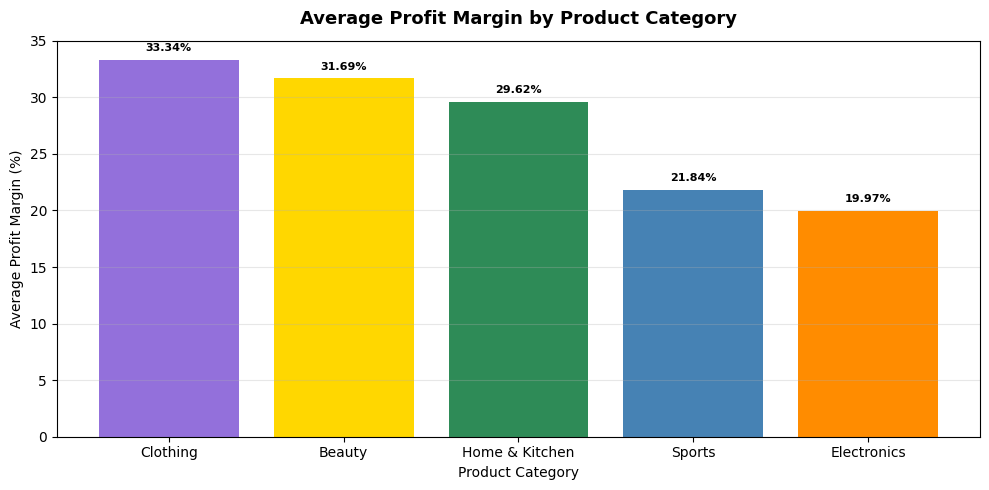

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [511]:
# ==========================================
# 12.35 AVERAGE PROFIT MARGIN BY CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_margin_category["category"],
    avg_margin_category["average_profit_margin"],
    color=[
        "mediumpurple",
        "gold",
        "seagreen",
        "steelblue",
        "darkorange"
    ]
)

plt.title(
    "Average Profit Margin by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin (%)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_profit_margin_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_profit_margin_by_category.png"
)

In [512]:
# 12.36 — Monthly Delivered Orders

In [513]:
# ==========================================
# 12.36 DATA PREPARATION
# MONTHLY DELIVERED ORDERS
# ==========================================

monthly_delivered_orders = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', order_date) AS INTEGER) AS order_month,
        COUNT(DISTINCT order_id) AS delivered_orders
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY order_month
    ORDER BY order_month
    """,
    conn
)

monthly_delivered_orders

,order_month,delivered_orders
0,1,320
1,2,313
2,3,307
3,4,324
4,5,334
5,6,336
6,7,337
7,8,340
8,9,332
9,10,341


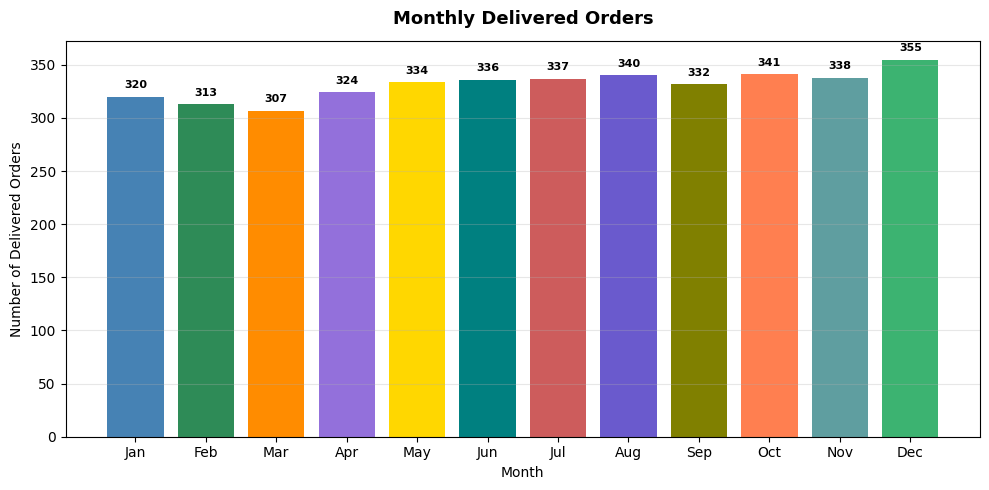

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [514]:
# ==========================================
# 12.36 MONTHLY DELIVERED ORDERS
# ==========================================

import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_names,
    monthly_delivered_orders["delivered_orders"],
    color=[
        "steelblue", "seagreen", "darkorange",
        "mediumpurple", "gold", "teal",
        "indianred", "slateblue", "olive",
        "coral", "cadetblue", "mediumseagreen"
    ]
)

plt.title(
    "Monthly Delivered Orders",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Number of Delivered Orders")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "monthly_delivered_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "monthly_delivered_orders.png"
)

In [515]:
# 12.37 — Average Order Value by Month

In [516]:
# ==========================================
# 12.37 DATA PREPARATION
# AVERAGE DELIVERED ORDER VALUE BY MONTH
# ==========================================

monthly_aov = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', o.order_date) AS INTEGER) AS order_month,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            )
            / COUNT(DISTINCT o.order_id),
            2
        ) AS average_order_value
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY order_month
    ORDER BY order_month
    """,
    conn
)

monthly_aov

,order_month,average_order_value
0,1,20381.26
1,2,19632.99
2,3,18813.43
3,4,20341.00
4,5,19760.39
5,6,18988.27
6,7,18712.54
7,8,19958.35
8,9,20062.69
9,10,19329.95


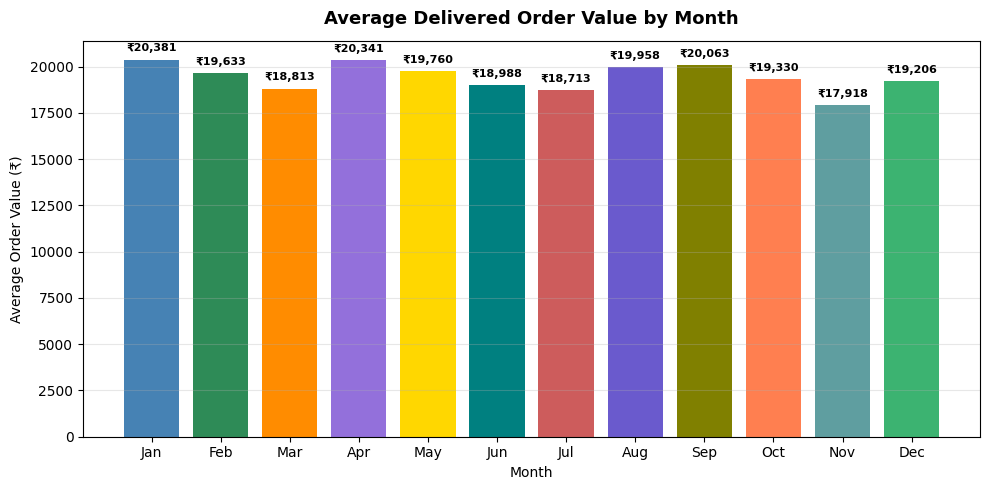

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [517]:
# ==========================================
# 12.37 AVERAGE DELIVERED ORDER VALUE BY MONTH
# ==========================================

import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_names,
    monthly_aov["average_order_value"],
    color=[
        "steelblue", "seagreen", "darkorange",
        "mediumpurple", "gold", "teal",
        "indianred", "slateblue", "olive",
        "coral", "cadetblue", "mediumseagreen"
    ]
)

plt.title(
    "Average Delivered Order Value by Month",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Average Order Value (₹)")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_delivered_order_value_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_delivered_order_value_by_month.png"
)

In [518]:
# 12.38 — Delivered Sales by Month vs Average Order Value

In [519]:
# ==========================================
# 12.38 DATA PREPARATION
# MONTHLY SALES VS AVERAGE ORDER VALUE
# ==========================================

monthly_sales_aov = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', o.order_date) AS INTEGER) AS order_month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            )
            / COUNT(DISTINCT o.order_id),
            2
        ) AS average_order_value

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY order_month

    ORDER BY order_month
    """,
    conn
)

monthly_sales_aov

,order_month,delivered_sales,average_order_value
0,1,5482558.75,20381.26
1,2,4751184.10,19632.99
2,3,4571664.55,18813.43
3,4,5349684.05,20341.00
4,5,5295785.35,19760.39
5,6,5088856.95,18988.27
6,7,5014960.65,18712.54
7,8,5508504.35,19958.35
8,9,5316611.70,20062.69
9,10,5373727.35,19329.95


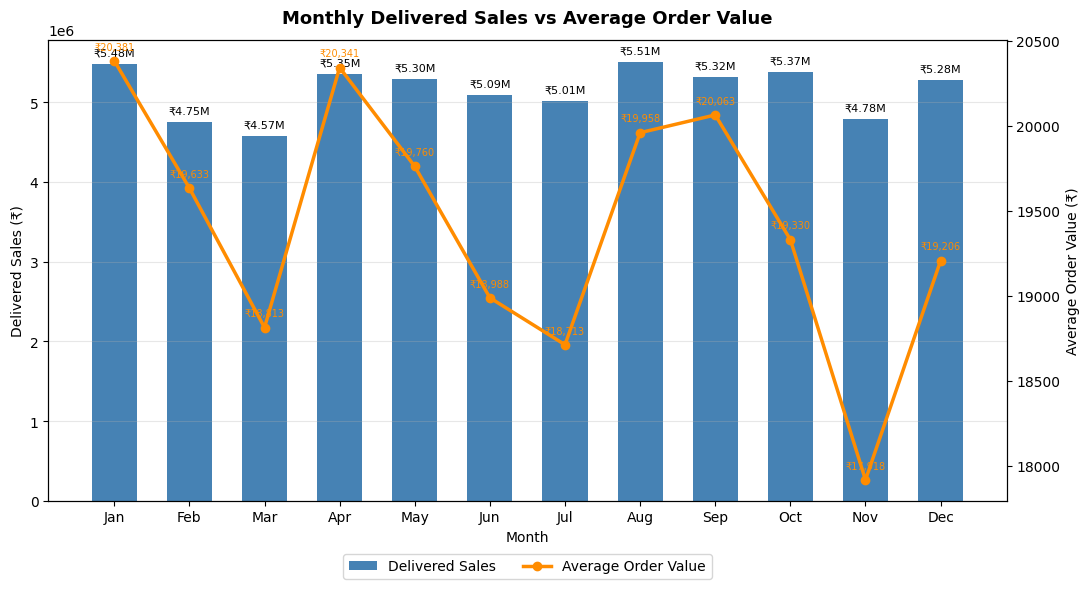

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [520]:
# ==========================================
# 12.38 MONTHLY DELIVERED SALES VS AVERAGE
# ORDER VALUE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

x = np.arange(len(month_names))
width = 0.6

fig, ax1 = plt.subplots(figsize=(11, 6))

# Delivered Sales
bars = ax1.bar(
    x,
    monthly_sales_aov["delivered_sales"],
    width=width,
    color="steelblue",
    label="Delivered Sales"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delivered Sales (₹)")

ax1.set_xticks(x)
ax1.set_xticklabels(month_names)

for bar in bars:
    value = bar.get_height()

    ax1.annotate(
        f"₹{value/1_000_000:.2f}M",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

# Average Order Value
ax2 = ax1.twinx()

ax2.plot(
    x,
    monthly_sales_aov["average_order_value"],
    color="darkorange",
    marker="o",
    linewidth=2.5,
    label="Average Order Value"
)

ax2.set_ylabel("Average Order Value (₹)")

for i, value in enumerate(
    monthly_sales_aov["average_order_value"]
):
    ax2.annotate(
        f"₹{value:,.0f}",
        (x[i], value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=7,
        color="darkorange"
    )

plt.title(
    "Monthly Delivered Sales vs Average Order Value",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax1.grid(
    axis="y",
    alpha=0.3
)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "monthly_delivered_sales_vs_average_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "monthly_delivered_sales_vs_average_order_value.png"
)

In [521]:
# 12.39 — Order Cancellation Rate by Month

In [522]:
# ==========================================
# 12.39 DATA PREPARATION
# MONTHLY ORDER CANCELLATION RATE
# ==========================================

monthly_cancellation_rate = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', order_date) AS INTEGER) AS order_month,

        ROUND(
            SUM(
                CASE
                    WHEN order_status = 'Cancelled'
                    THEN 1
                    ELSE 0
                END
            ) * 100.0
            / COUNT(order_id),
            2
        ) AS cancellation_rate

    FROM orders

    GROUP BY order_month

    ORDER BY order_month
    """,
    conn
)

monthly_cancellation_rate

,order_month,cancellation_rate
0,1,8.40
1,2,8.00
2,3,9.50
3,4,10.71
4,5,9.20
5,6,9.93
6,7,11.56
7,8,10.02
8,9,10.02
9,10,10.87


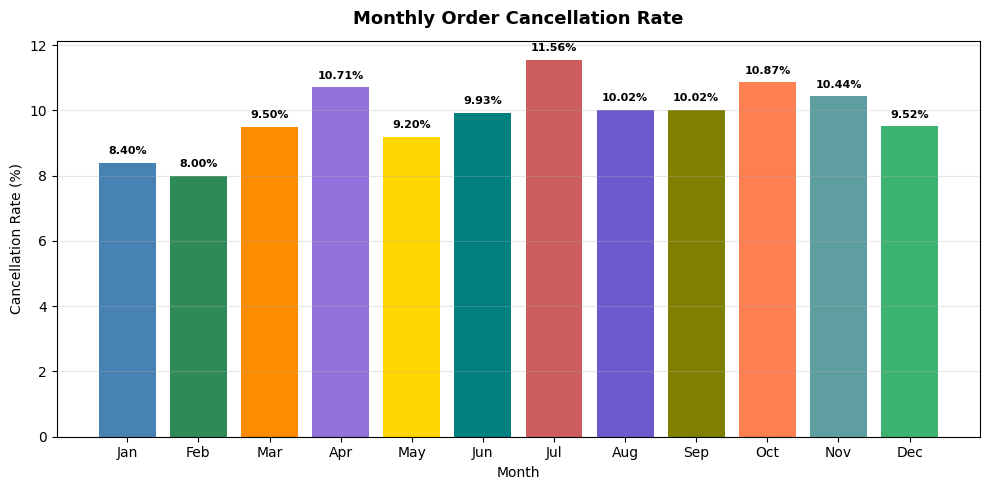

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [523]:
# ==========================================
# 12.39 MONTHLY ORDER CANCELLATION RATE
# ==========================================

import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_names,
    monthly_cancellation_rate["cancellation_rate"],
    color=[
        "steelblue", "seagreen", "darkorange",
        "mediumpurple", "gold", "teal",
        "indianred", "slateblue", "olive",
        "coral", "cadetblue", "mediumseagreen"
    ]
)

plt.title(
    "Monthly Order Cancellation Rate",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "monthly_order_cancellation_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "monthly_order_cancellation_rate.png"
)

In [524]:
# 12.40 — Monthly Order Return Rate

In [525]:
# ==========================================
# 12.40 DATA PREPARATION
# MONTHLY ORDER RETURN RATE
# ==========================================

monthly_return_rate = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', order_date) AS INTEGER) AS order_month,

        ROUND(
            SUM(
                CASE
                    WHEN order_status = 'Returned'
                    THEN 1
                    ELSE 0
                END
            ) * 100.0
            / COUNT(order_id),
            2
        ) AS return_rate

    FROM orders

    GROUP BY order_month

    ORDER BY order_month
    """,
    conn
)

monthly_return_rate

,order_month,return_rate
0,1,10.18
1,2,8.53
2,3,9.50
3,4,12.14
4,5,12.03
5,6,10.64
6,7,8.96
7,8,10.72
8,9,10.74
9,10,8.51


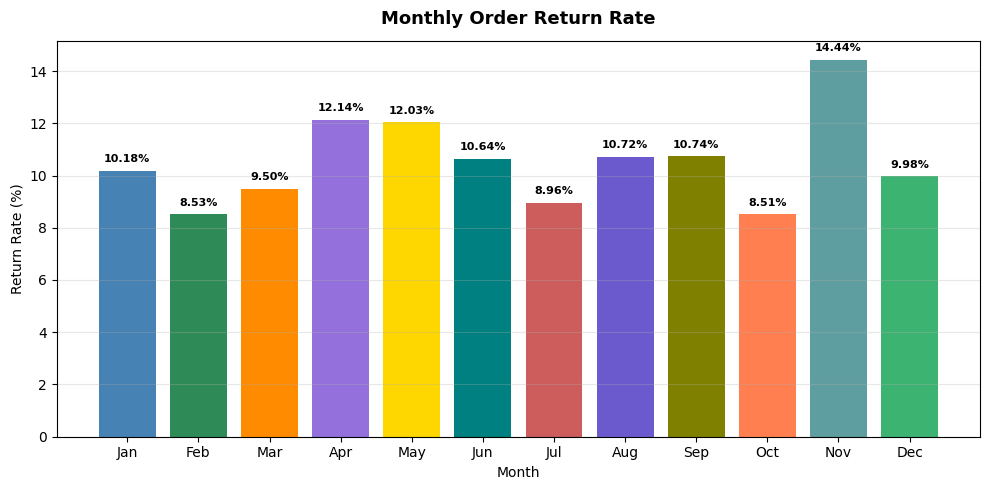

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [526]:
# ==========================================
# 12.40 MONTHLY ORDER RETURN RATE
# ==========================================

import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_names,
    monthly_return_rate["return_rate"],
    color=[
        "steelblue", "seagreen", "darkorange",
        "mediumpurple", "gold", "teal",
        "indianred", "slateblue", "olive",
        "coral", "cadetblue", "mediumseagreen"
    ]
)

plt.title(
    "Monthly Order Return Rate",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Return Rate (%)")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "monthly_order_return_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "monthly_order_return_rate.png"
)

In [527]:
# 12.41 — Delivered Orders by Product Category

In [528]:
# ==========================================
# 12.41 DATA PREPARATION
# DELIVERED ORDERS BY PRODUCT CATEGORY
# ==========================================

delivered_orders_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        COUNT(DISTINCT o.order_id) AS delivered_orders
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY delivered_orders DESC
    """,
    conn
)

delivered_orders_category

,category,delivered_orders
0,Sports,1237
1,Electronics,1170
2,Clothing,1069
3,Beauty,1020
4,Home & Kitchen,947


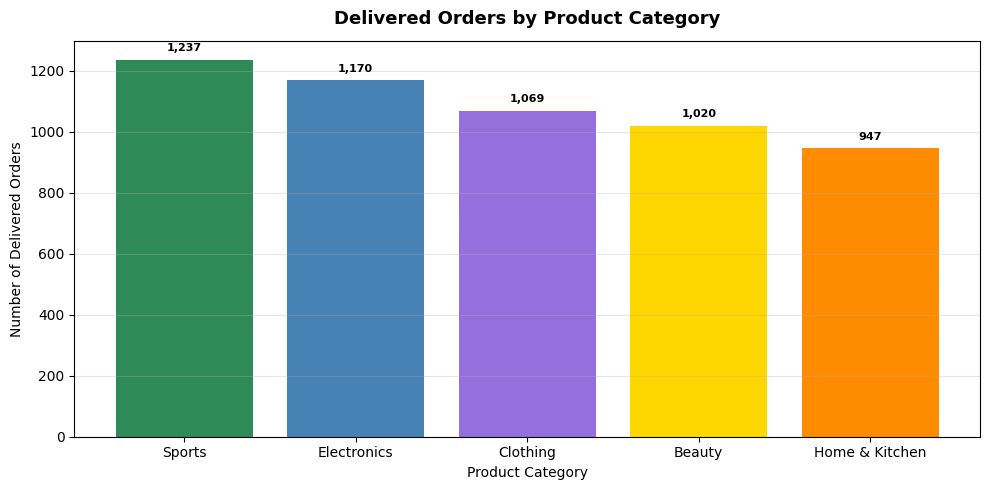

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [529]:
# ==========================================
# 12.41 DELIVERED ORDERS BY PRODUCT CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    delivered_orders_category["category"],
    delivered_orders_category["delivered_orders"],
    color=[
        "seagreen",
        "steelblue",
        "mediumpurple",
        "gold",
        "darkorange"
    ]
)

plt.title(
    "Delivered Orders by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Number of Delivered Orders")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "delivered_orders_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "delivered_orders_by_product_category.png"
)

In [530]:
# 12.42 — Top 10 Products by Delivered Quantity

In [531]:
# ==========================================
# 12.42 DATA PREPARATION
# TOP 10 PRODUCTS BY DELIVERED QUANTITY
# ==========================================

top_products_quantity = pd.read_sql_query(
    """
    SELECT
        p.product_id,
        p.product_name,
        p.category,
        SUM(oi.quantity) AS delivered_quantity
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.product_id,
        p.product_name,
        p.category
    ORDER BY delivered_quantity DESC
    LIMIT 10
    """,
    conn
)

top_products_quantity

,product_id,product_name,category,delivered_quantity
0,P0024,Product_0024,Electronics,228
1,P0047,Product_0047,Electronics,209
2,P0012,Product_0012,Sports,208
3,P0015,Product_0015,Home & Kitchen,205
4,P0087,Product_0087,Sports,202
5,P0064,Product_0064,Clothing,199
6,P0091,Product_0091,Electronics,198
7,P0031,Product_0031,Sports,197
8,P0053,Product_0053,Sports,196
9,P0076,Product_0076,Electronics,195


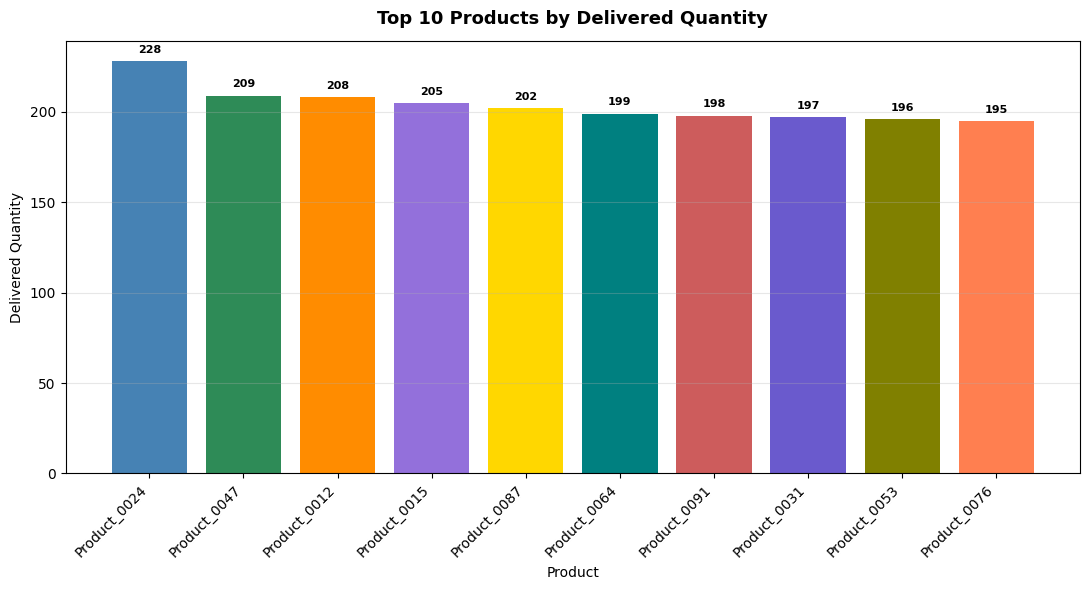

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [532]:
# ==========================================
# 12.42 TOP 10 PRODUCTS BY DELIVERED QUANTITY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_products_quantity["product_name"],
    top_products_quantity["delivered_quantity"],
    color=[
        "steelblue",
        "seagreen",
        "darkorange",
        "mediumpurple",
        "gold",
        "teal",
        "indianred",
        "slateblue",
        "olive",
        "coral"
    ]
)

plt.title(
    "Top 10 Products by Delivered Quantity",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product")
plt.ylabel("Delivered Quantity")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "top_10_products_by_delivered_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "top_10_products_by_delivered_quantity.png"
)

In [533]:
# 12.43 — Average Selling Price by Product Category

In [534]:
# ==========================================
# 12.43 DATA PREPARATION
# AVERAGE SELLING PRICE BY PRODUCT CATEGORY
# ==========================================

avg_selling_price_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(AVG(p.selling_price), 2) AS average_selling_price
    FROM products p
    GROUP BY p.category
    ORDER BY average_selling_price DESC
    """,
    conn
)

avg_selling_price_category

,category,average_selling_price
0,Home & Kitchen,4783.50
1,Beauty,4545.68
2,Sports,4454.55
3,Electronics,4213.10
4,Clothing,4191.90


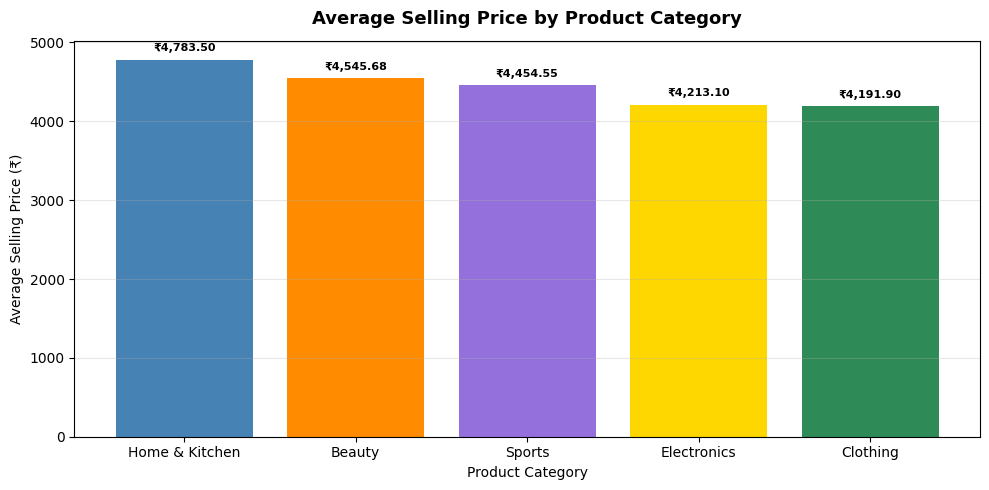

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [535]:
# ==========================================
# 12.43 AVERAGE SELLING PRICE BY CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_selling_price_category["category"],
    avg_selling_price_category["average_selling_price"],
    color=[
        "steelblue",
        "darkorange",
        "mediumpurple",
        "gold",
        "seagreen"
    ]
)

plt.title(
    "Average Selling Price by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Selling Price (₹)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_selling_price_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_selling_price_by_product_category.png"
)

In [536]:
# 12.44 — Average Cost Price by Product Category

In [537]:
# ==========================================
# 12.44 DATA PREPARATION
# AVERAGE COST PRICE BY PRODUCT CATEGORY
# ==========================================

avg_cost_price_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(AVG(p.cost_price), 2) AS average_cost_price
    FROM products p
    GROUP BY p.category
    ORDER BY average_cost_price DESC
    """,
    conn
)

avg_cost_price_category

,category,average_cost_price
0,Sports,2761.18
1,Home & Kitchen,2752.50
2,Electronics,2731.29
3,Beauty,2719.26
4,Clothing,2414.60


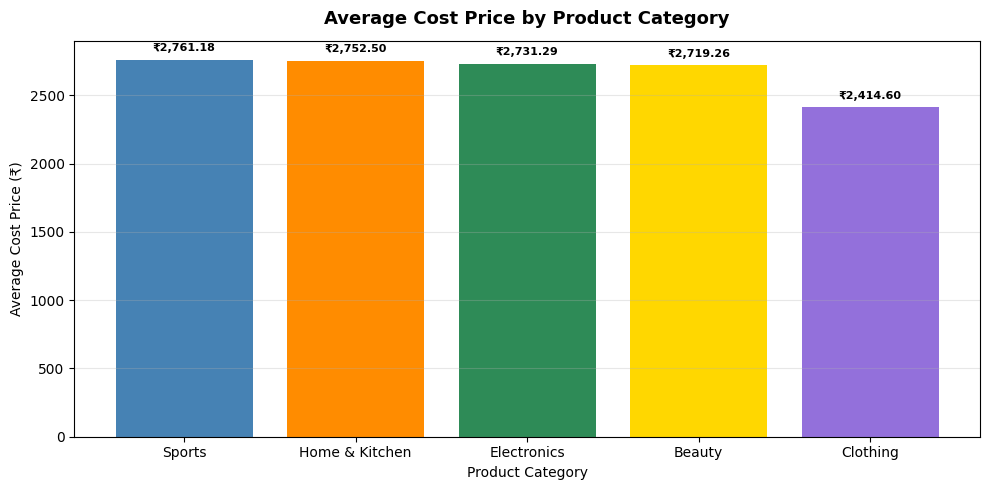

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [538]:
# ==========================================
# 12.44 AVERAGE COST PRICE BY CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_cost_price_category["category"],
    avg_cost_price_category["average_cost_price"],
    color=[
        "steelblue",
        "darkorange",
        "seagreen",
        "gold",
        "mediumpurple"
    ]
)

plt.title(
    "Average Cost Price by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Cost Price (₹)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_cost_price_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_cost_price_by_product_category.png"
)

In [539]:
# 12.45 — Average Profit per Delivered Order by Product Category

In [540]:
# ==========================================
# 12.45 DATA PREPARATION
# AVERAGE PROFIT PER DELIVERED ORDER
# BY PRODUCT CATEGORY
# ==========================================

avg_profit_per_order_category = pd.read_sql_query(
    """
    SELECT
        p.category,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - (
                    oi.quantity * p.cost_price
                )
            )
            / COUNT(DISTINCT o.order_id),
            2
        ) AS average_profit_per_order

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY p.category

    ORDER BY average_profit_per_order DESC
    """,
    conn
)

avg_profit_per_order_category

,category,average_profit_per_order
0,Home & Kitchen,4086.71
1,Beauty,3781.03
2,Clothing,3702.69
3,Sports,3350.11
4,Electronics,2690.27


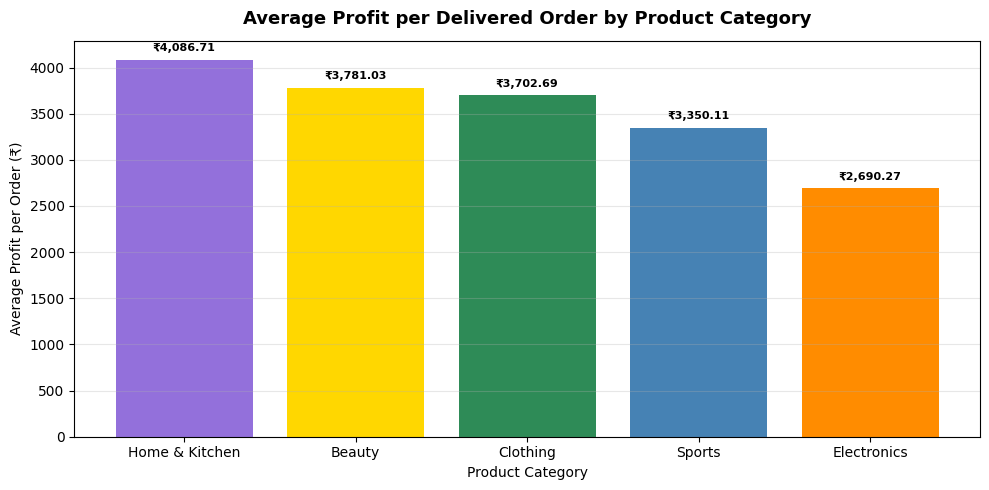

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [541]:
# ==========================================
# 12.45 AVERAGE PROFIT PER DELIVERED ORDER
# BY PRODUCT CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    avg_profit_per_order_category["category"],
    avg_profit_per_order_category["average_profit_per_order"],
    color=[
        "mediumpurple",
        "gold",
        "seagreen",
        "steelblue",
        "darkorange"
    ]
)

plt.title(
    "Average Profit per Delivered Order by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Average Profit per Order (₹)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_profit_per_delivered_order_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_profit_per_delivered_order_by_category.png"
)

In [542]:
# 12.46 Discount Amount by Product Category

In [543]:
# ==========================================
# 12.46 DISCOUNT AMOUNT BY PRODUCT CATEGORY
# ==========================================

discount_amount_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            SUM(
                oi.quantity
                * p.selling_price
                * oi.discount / 100.0
            ),
            2
        ) AS total_discount_amount
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY total_discount_amount DESC
    """,
    conn
)

discount_amount_category

,category,total_discount_amount
0,Sports,2025061.80
1,Electronics,1816607.00
2,Home & Kitchen,1688160.55
3,Beauty,1676283.75
4,Clothing,1653964.30


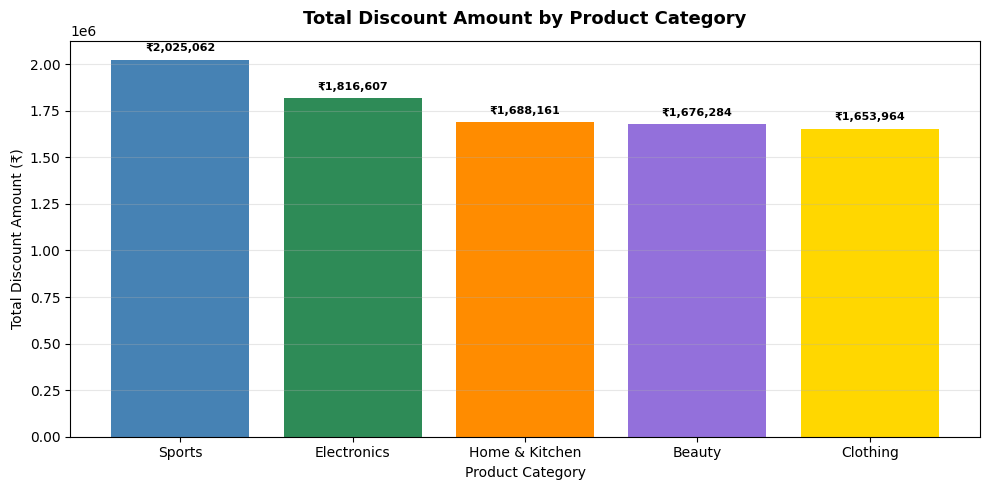

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [544]:
# ==========================================
# 12.46 DISCOUNT AMOUNT BY PRODUCT CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    discount_amount_category["category"],
    discount_amount_category["total_discount_amount"],
    color=[
        "steelblue",
        "seagreen",
        "darkorange",
        "mediumpurple",
        "gold"
    ]
)

plt.title(
    "Total Discount Amount by Product Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Product Category")
plt.ylabel("Total Discount Amount (₹)")

plt.xticks(rotation=0)

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"₹{value:,.0f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "discount_amount_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "discount_amount_by_product_category.png"
)

In [545]:
# 12.47 Average Session Duration by Purchase Status

In [546]:
# ==========================================
# 12.47 AVERAGE SESSION DURATION
# BY PURCHASE STATUS
# ==========================================

session_duration_purchase = pd.read_sql_query(
    """
    SELECT
        purchased AS purchase_status,
        ROUND(AVG(session_duration), 2) AS average_session_duration
    FROM website_activity
    GROUP BY purchased
    ORDER BY average_session_duration DESC
    """,
    conn
)

session_duration_purchase

,purchase_status,average_session_duration
0,Yes,22.5
1,No,8.0


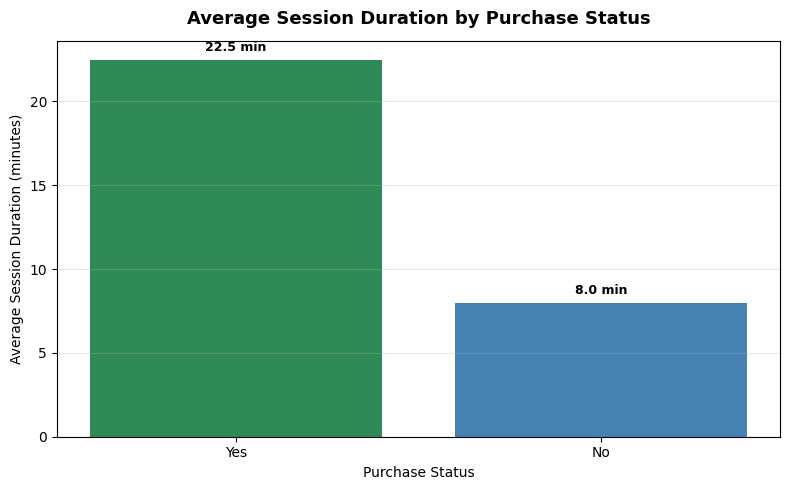

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [547]:
# ==========================================
# 12.47 AVERAGE SESSION DURATION
# BY PURCHASE STATUS
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    session_duration_purchase["purchase_status"],
    session_duration_purchase["average_session_duration"],
    color=["seagreen", "steelblue"]
)

plt.title(
    "Average Session Duration by Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Purchase Status")
plt.ylabel("Average Session Duration (minutes)")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.1f} min",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_session_duration_by_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_session_duration_by_purchase_status.png"
)

In [548]:
# 12.48 Average Pages Viewed by Purchase Status

In [549]:
# ==========================================
# 12.48 AVERAGE PAGES VIEWED
# BY PURCHASE STATUS
# ==========================================

pages_viewed_purchase = pd.read_sql_query(
    """
    SELECT
        purchased AS purchase_status,
        ROUND(AVG(pages_viewed), 2) AS average_pages_viewed
    FROM website_activity
    GROUP BY purchased
    ORDER BY average_pages_viewed DESC
    """,
    conn
)

pages_viewed_purchase

,purchase_status,average_pages_viewed
0,Yes,11.25
1,No,5.00


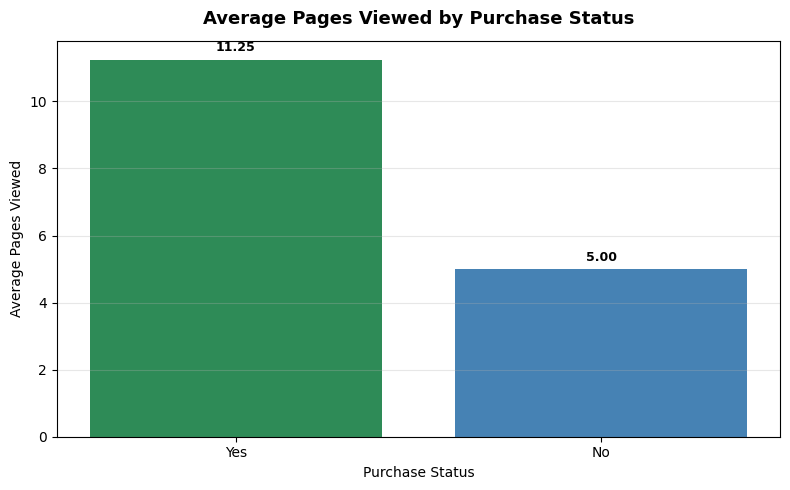

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [550]:
# ==========================================
# 12.48 AVERAGE PAGES VIEWED
# BY PURCHASE STATUS
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    pages_viewed_purchase["purchase_status"],
    pages_viewed_purchase["average_pages_viewed"],
    color=["seagreen", "steelblue"]
)

plt.title(
    "Average Pages Viewed by Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Purchase Status")
plt.ylabel("Average Pages Viewed")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_pages_viewed_by_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_pages_viewed_by_purchase_status.png"
)

In [551]:
# 12.49 Average Discount by Price Category

In [552]:
# ==========================================
# 12.49 AVERAGE DISCOUNT BY PRICE CATEGORY
# ==========================================

discount_price_category = pd.read_sql_query(
    """
    SELECT
        p.price_category,
        ROUND(AVG(oi.discount), 2) AS average_discount
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.price_category
    ORDER BY average_discount DESC
    """,
    conn
)

discount_price_category

,price_category,average_discount
0,High Price,12.73
1,Normal Price,12.41


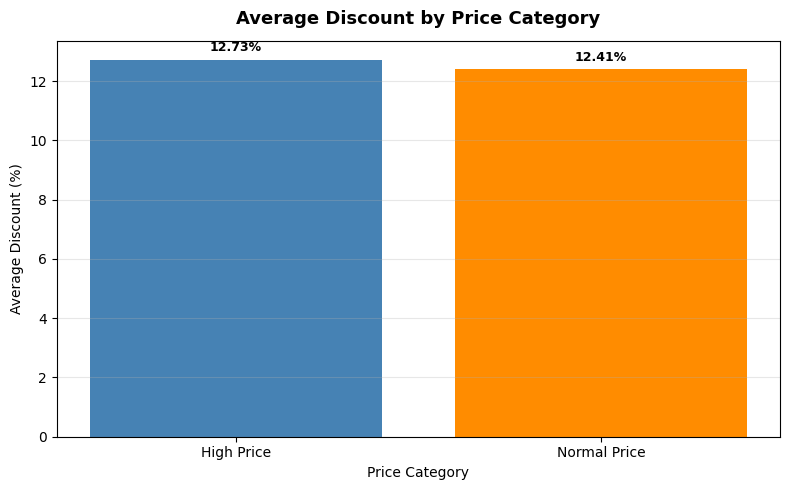

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [553]:
# ==========================================
# 12.49 AVERAGE DISCOUNT BY PRICE CATEGORY
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    discount_price_category["price_category"],
    discount_price_category["average_discount"],
    color=["steelblue", "darkorange"]
)

plt.title(
    "Average Discount by Price Category",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Price Category")
plt.ylabel("Average Discount (%)")

for bar in bars:
    value = bar.get_height()

    plt.annotate(
        f"{value:.2f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_discount_by_price_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_discount_by_price_category.png"
)

In [554]:
# 12.50 Average Session Duration by Device and Purchase Status

In [555]:
# ==========================================
# 12.50 AVERAGE SESSION DURATION
# BY DEVICE AND PURCHASE STATUS
# ==========================================

session_duration_device_purchase = pd.read_sql_query(
    """
    SELECT
        device,
        purchased AS purchase_status,
        ROUND(AVG(session_duration), 2) AS average_session_duration
    FROM website_activity
    GROUP BY device, purchased
    ORDER BY device, purchased
    """,
    conn
)

session_duration_device_purchase

,device,purchase_status,average_session_duration
0,Laptop,Yes,22.5
1,Mobile,No,8.0
2,Mobile,Yes,15.0
3,Tablet,Yes,30.0


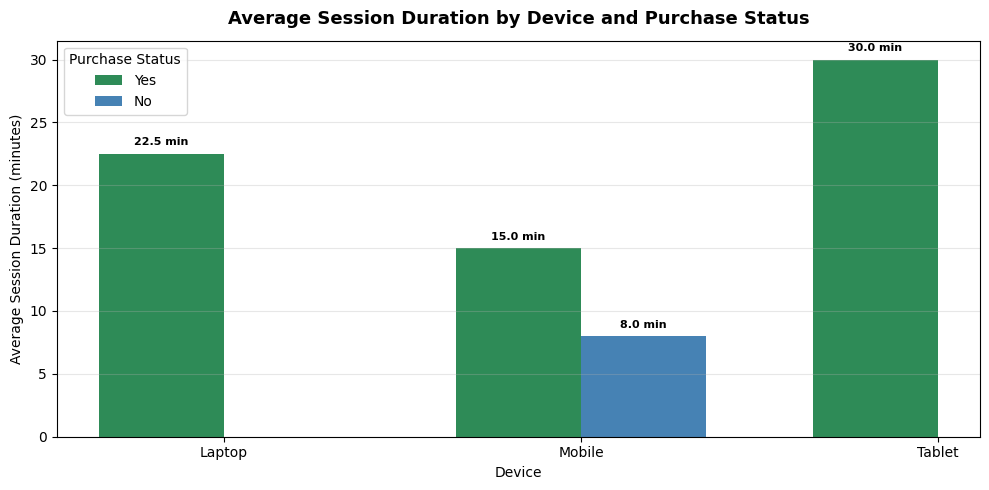

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [556]:
# ==========================================
# 12.50 AVERAGE SESSION DURATION
# BY DEVICE AND PURCHASE STATUS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

devices = session_duration_device_purchase["device"].unique()

purchase_statuses = ["Yes", "No"]

x = np.arange(len(devices))
width = 0.35

plt.figure(figsize=(10, 5))

for i, status in enumerate(purchase_statuses):

    values = []

    for device in devices:

        result = session_duration_device_purchase[
            (session_duration_device_purchase["device"] == device) &
            (session_duration_device_purchase["purchase_status"] == status)
        ]

        if len(result) > 0:
            values.append(result["average_session_duration"].iloc[0])
        else:
            values.append(np.nan)

    bars = plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=status,
        color="seagreen" if status == "Yes" else "steelblue"
    )

    for bar, value in zip(bars, values):

        if not np.isnan(value):
            plt.annotate(
                f"{value:.1f} min",
                (bar.get_x() + bar.get_width() / 2, value),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

plt.title(
    "Average Session Duration by Device and Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Session Duration (minutes)")

plt.xticks(
    x,
    devices
)

plt.legend(
    title="Purchase Status"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_session_duration_by_device_and_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_session_duration_by_device_and_purchase_status.png"
)

In [557]:
# 12.51 Average Pages Viewed by Device and Purchase Status

In [558]:
# ==========================================
# 12.51 AVERAGE PAGES VIEWED
# BY DEVICE AND PURCHASE STATUS
# ==========================================

pages_viewed_device_purchase = pd.read_sql_query(
    """
    SELECT
        device,
        purchased AS purchase_status,
        ROUND(AVG(pages_viewed), 2) AS average_pages_viewed
    FROM website_activity
    GROUP BY device, purchased
    ORDER BY device, purchased
    """,
    conn
)

pages_viewed_device_purchase

,device,purchase_status,average_pages_viewed
0,Laptop,Yes,11.0
1,Mobile,No,5.0
2,Mobile,Yes,8.0
3,Tablet,Yes,15.0


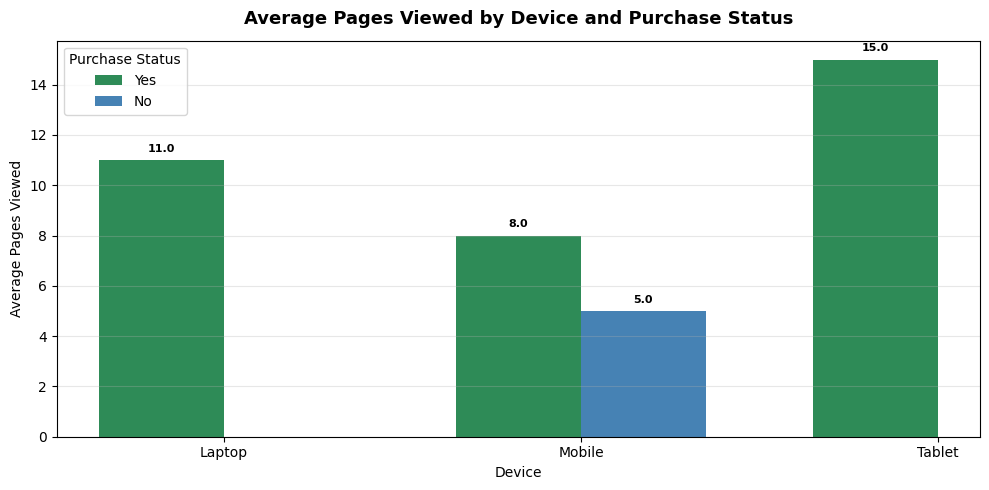

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [559]:
# ==========================================
# 12.51 AVERAGE PAGES VIEWED
# BY DEVICE AND PURCHASE STATUS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

devices = pages_viewed_device_purchase["device"].unique()

purchase_statuses = ["Yes", "No"]

x = np.arange(len(devices))
width = 0.35

plt.figure(figsize=(10, 5))

for i, status in enumerate(purchase_statuses):

    values = []

    for device in devices:

        result = pages_viewed_device_purchase[
            (pages_viewed_device_purchase["device"] == device) &
            (pages_viewed_device_purchase["purchase_status"] == status)
        ]

        if len(result) > 0:
            values.append(result["average_pages_viewed"].iloc[0])
        else:
            values.append(np.nan)

    bars = plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=status,
        color="seagreen" if status == "Yes" else "steelblue"
    )

    for bar, value in zip(bars, values):

        if not np.isnan(value):
            plt.annotate(
                f"{value:.1f}",
                (bar.get_x() + bar.get_width() / 2, value),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

plt.title(
    "Average Pages Viewed by Device and Purchase Status",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Pages Viewed")

plt.xticks(
    x,
    devices
)

plt.legend(
    title="Purchase Status"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "average_pages_viewed_by_device_and_purchase_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_pages_viewed_by_device_and_purchase_status.png"
)

In [560]:
# 12.52 — Average Session Duration by Device and Engagement Level

In [561]:
# ==========================================
# 12.52 AVERAGE SESSION DURATION
# BY DEVICE AND ENGAGEMENT LEVEL
# ==========================================

session_duration_device_engagement = pd.read_sql_query(
    """
    SELECT
        device,
        engagement_level,
        ROUND(AVG(session_duration), 2) AS average_session_duration
    FROM website_activity
    GROUP BY device, engagement_level
    ORDER BY device, engagement_level
    """,
    conn
)

session_duration_device_engagement

,device,engagement_level,average_session_duration
0,Laptop,Medium Engagement,22.5
1,Mobile,Low Engagement,8.0
2,Mobile,Medium Engagement,15.0
3,Tablet,Medium Engagement,30.0


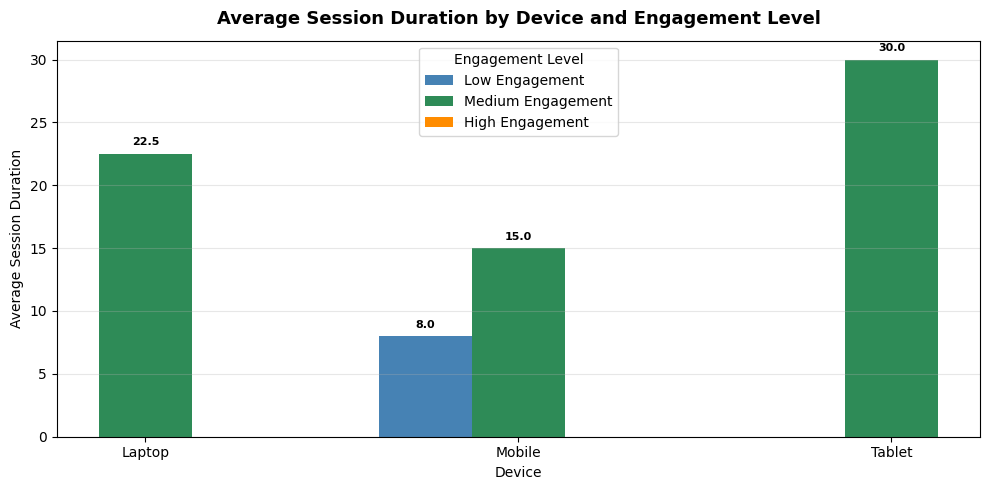

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [562]:
# ==========================================
# 12.52 AVERAGE SESSION DURATION
# BY DEVICE AND ENGAGEMENT LEVEL
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

devices = session_duration_device_engagement["device"].unique()
engagement_levels = [
    "Low Engagement",
    "Medium Engagement",
    "High Engagement"
]

x = np.arange(len(devices))
width = 0.25

plt.figure(figsize=(10, 5))

colors = ["steelblue", "seagreen", "darkorange"]

for i, level in enumerate(engagement_levels):
    values = []

    for device in devices:
        result = session_duration_device_engagement[
            (session_duration_device_engagement["device"] == device) &
            (session_duration_device_engagement["engagement_level"] == level)
        ]

        if len(result) > 0:
            values.append(result["average_session_duration"].iloc[0])
        else:
            values.append(np.nan)

    bars = plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=level,
        color=colors[i]
    )

    for bar, value in zip(bars, values):
        if not np.isnan(value):
            plt.annotate(
                f"{value:.1f}",
                (bar.get_x() + bar.get_width() / 2, value),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

plt.title(
    "Average Session Duration by Device and Engagement Level",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Session Duration")
plt.xticks(x, devices)
plt.legend(title="Engagement Level")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "average_session_duration_by_device_and_engagement_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download(
    "average_session_duration_by_device_and_engagement_level.png"
)

In [563]:
# 12.53 — Average Pages Viewed by Device and Engagement Level

In [564]:
# ==========================================
# 12.53 AVERAGE PAGES VIEWED
# BY DEVICE AND ENGAGEMENT LEVEL
# ==========================================

pages_viewed_device_engagement = pd.read_sql_query(
    """
    SELECT
        device,
        engagement_level,
        ROUND(AVG(pages_viewed), 2) AS average_pages_viewed
    FROM website_activity
    GROUP BY device, engagement_level
    ORDER BY device, engagement_level
    """,
    conn
)

pages_viewed_device_engagement

,device,engagement_level,average_pages_viewed
0,Laptop,Medium Engagement,11.0
1,Mobile,Low Engagement,5.0
2,Mobile,Medium Engagement,8.0
3,Tablet,Medium Engagement,15.0


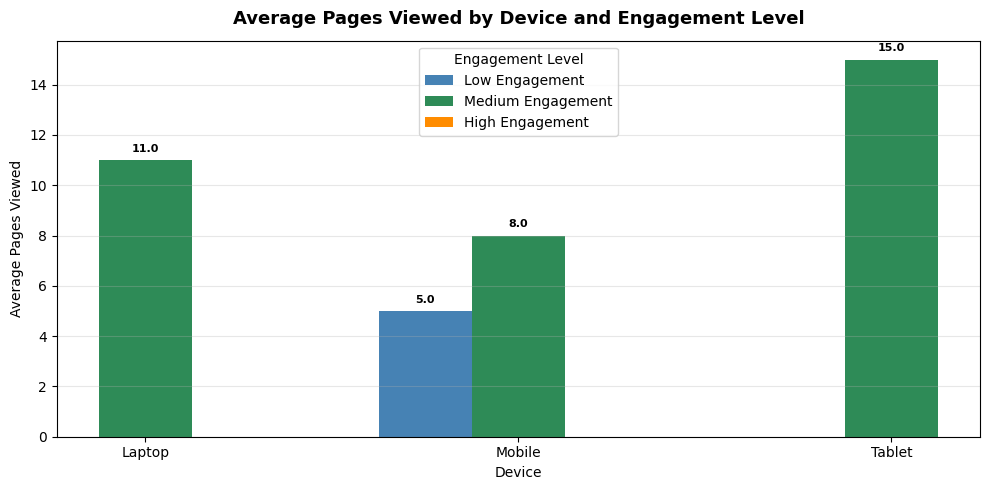

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [565]:
# ==========================================
# 12.53 AVERAGE PAGES VIEWED
# BY DEVICE AND ENGAGEMENT LEVEL
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

devices = pages_viewed_device_engagement["device"].unique()

engagement_levels = [
    "Low Engagement",
    "Medium Engagement",
    "High Engagement"
]

x = np.arange(len(devices))
width = 0.25

plt.figure(figsize=(10, 5))

colors = ["steelblue", "seagreen", "darkorange"]

for i, level in enumerate(engagement_levels):

    values = []

    for device in devices:

        result = pages_viewed_device_engagement[
            (pages_viewed_device_engagement["device"] == device) &
            (pages_viewed_device_engagement["engagement_level"] == level)
        ]

        if len(result) > 0:
            values.append(result["average_pages_viewed"].iloc[0])
        else:
            values.append(np.nan)

    bars = plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=level,
        color=colors[i]
    )

    for bar, value in zip(bars, values):

        if not np.isnan(value):

            plt.annotate(
                f"{value:.1f}",
                (bar.get_x() + bar.get_width() / 2, value),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=8,
                fontweight="bold"
            )

plt.title(
    "Average Pages Viewed by Device and Engagement Level",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xlabel("Device")
plt.ylabel("Average Pages Viewed")

plt.xticks(x, devices)

plt.legend(title="Engagement Level")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "average_pages_viewed_by_device_and_engagement_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files

files.download(
    "average_pages_viewed_by_device_and_engagement_level.png"
)

In [566]:
# 12.54 — Delivered Sales vs Delivered Profit by Month

In [567]:
# ==========================================
# 12.54 MONTHLY DELIVERED SALES
# VS DELIVERED PROFIT
# ==========================================

monthly_sales_profit = pd.read_sql_query(
    """
    SELECT
        CAST(strftime('%m', o.order_date) AS INTEGER) AS order_month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - oi.quantity * p.cost_price
            ),
            2
        ) AS delivered_profit

    FROM orders o

    INNER JOIN order_items oi
        ON o.order_id = oi.order_id

    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY order_month

    ORDER BY order_month
    """,
    conn
)

monthly_sales_profit

,order_month,delivered_sales,delivered_profit
0,1,5482558.75,1581581.75
1,2,4751184.10,1607029.10
2,3,4571664.55,1389322.55
3,4,5349684.05,1627371.05
4,5,5295785.35,1806967.35
5,6,5088856.95,1541080.95
6,7,5014960.65,1537693.65
7,8,5508504.35,1664972.35
8,9,5316611.70,1645665.70
9,10,5373727.35,1684762.35


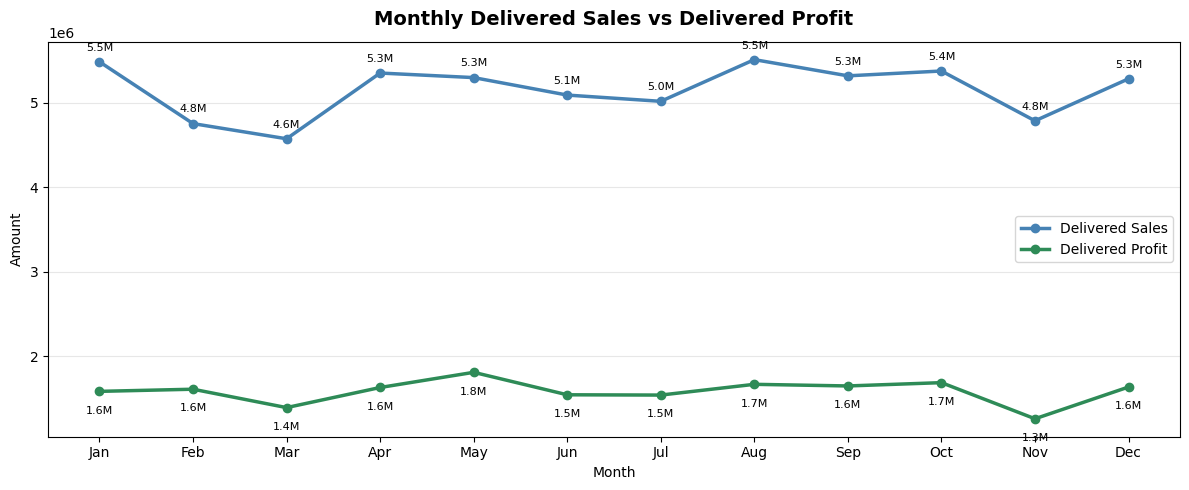

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [568]:
# ==========================================
# 12.54 MONTHLY DELIVERED SALES
# VS DELIVERED PROFIT
# ==========================================

import matplotlib.pyplot as plt

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 5))

plt.plot(
    months,
    monthly_sales_profit["delivered_sales"],
    marker="o",
    linewidth=2.5,
    label="Delivered Sales",
    color="steelblue"
)

plt.plot(
    months,
    monthly_sales_profit["delivered_profit"],
    marker="o",
    linewidth=2.5,
    label="Delivered Profit",
    color="seagreen"
)

for x, value in zip(months, monthly_sales_profit["delivered_sales"]):
    plt.annotate(
        f"{value/1_000_000:.1f}M",
        (x, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

for x, value in zip(months, monthly_sales_profit["delivered_profit"]):
    plt.annotate(
        f"{value/1_000_000:.1f}M",
        (x, value),
        textcoords="offset points",
        xytext=(0, -16),
        ha="center",
        fontsize=8
    )

plt.title(
    "Monthly Delivered Sales vs Delivered Profit",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Amount")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_delivered_sales_vs_delivered_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from google.colab import files

files.download(
    "monthly_delivered_sales_vs_delivered_profit.png"
)

## Statistical Analysis & Hypothesis Testing

## 13.1 Descriptive Statistics

- Descriptive statistics are used to summarize the main characteristics of the ShopSphere dataset.

- Measures such as mean, median, standard deviation, minimum, and maximum help us understand sales, quantity, discounts, prices, profit, customer spending, and website activity.

In [569]:
# ==========================================
# 13.1 DESCRIPTIVE STATISTICS
# ==========================================

descriptive_data = pd.read_sql_query(
    """
    SELECT
        oi.quantity,
        oi.discount,
        p.selling_price,
        p.cost_price,
        (
            oi.quantity * p.selling_price
            - (
                oi.quantity
                * p.selling_price
                * oi.discount / 100.0
            )
            - oi.quantity * p.cost_price
        ) AS profit,

        CASE
            WHEN p.selling_price > 0
            THEN
                (
                    (
                        oi.quantity * p.selling_price
                        - (
                            oi.quantity
                            * p.selling_price
                            * oi.discount / 100.0
                        )
                        - oi.quantity * p.cost_price
                    )
                    /
                    (
                        oi.quantity * p.selling_price
                        - (
                            oi.quantity
                            * p.selling_price
                            * oi.discount / 100.0
                        )
                    )
                ) * 100
        END AS profit_margin

    FROM order_items oi

    INNER JOIN products p
        ON oi.product_id = p.product_id

    INNER JOIN orders o
        ON oi.order_id = o.order_id

    WHERE o.order_status = 'Delivered'
    """,
    conn
)

descriptive_data.describe().round(2)

,quantity,discount,selling_price,cost_price,profit,profit_margin
count,6389.00,6389.00,6389.00,6389.00,6389.00,6389.00
mean,2.50,12.54,4409.26,2684.96,2970.21,26.89
std,1.11,8.55,1467.41,1344.47,4317.92,32.75
min,1.00,0.00,1218.00,309.00,-4556.00,-33.27
25%,2.00,5.00,3379.00,1545.00,43.80,0.78
50%,3.00,10.00,4526.00,2858.00,1437.30,18.85
75%,3.00,20.00,5498.00,3830.00,4793.80,59.88
max,4.00,25.00,6860.00,4992.00,23652.00,92.66


## 13.2 Correlation Analysis

- Correlation analysis measures the strength and direction of linear relationships between numerical variables.

- For ShopSphere, we examine relationships between quantity, discount, selling price, cost price, profit, and profit margin.

- A correlation close to +1 indicates a strong positive relationship, while a correlation close to -1 indicates a strong negative relationship. A value near 0 indicates a weak linear relationship.

In [570]:
# ==========================================
# 13.2 CORRELATION ANALYSIS
# ==========================================

correlation_matrix = descriptive_data.corr(numeric_only=True).round(2)

correlation_matrix

,quantity,discount,selling_price,cost_price,profit,profit_margin
quantity,1.00,-0.00,0.02,-0.01,0.32,0.02
discount,-0.00,1.00,0.01,0.01,-0.22,-0.22
selling_price,0.02,0.01,1.00,0.41,0.43,0.26
cost_price,-0.01,0.01,0.41,1.00,-0.49,-0.70
profit,0.32,-0.22,0.43,-0.49,1.00,0.80
profit_margin,0.02,-0.22,0.26,-0.70,0.80,1.00


## 13.3 Hypothesis Testing: Discount vs Profit

### Hypotheses

- **Null Hypothesis (H₀):** There is no statistically significant linear relationship between discount percentage and profit.
- **Alternative Hypothesis (H₁):** There is a statistically significant linear relationship between discount percentage and profit.

A significance level of **α = 0.05** is used.

In [571]:
# ==========================================
# 13.3 PEARSON CORRELATION HYPOTHESIS TEST
# ==========================================

from scipy.stats import pearsonr

discount_profit_corr, p_value = pearsonr(
    descriptive_data["discount"],
    descriptive_data["profit"]
)

print(f"Pearson Correlation: {discount_profit_corr:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: The relationship between discount and profit is statistically significant.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a statistically significant relationship.")

Pearson Correlation: -0.2172
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: The relationship between discount and profit is statistically significant.


## 13.4 Hypothesis Testing: Selling Price vs Profit

### Hypotheses

- **Null Hypothesis (H₀):** There is no statistically significant linear relationship between selling price and profit.
- **Alternative Hypothesis (H₁):** There is a statistically significant linear relationship between selling price and profit.

A significance level of **α = 0.05** is used.

In [572]:
# ==========================================
# 13.4 PEARSON CORRELATION HYPOTHESIS TEST
# SELLING PRICE VS PROFIT
# ==========================================

selling_price_profit_corr, p_value = pearsonr(
    descriptive_data["selling_price"],
    descriptive_data["profit"]
)

print(f"Pearson Correlation: {selling_price_profit_corr:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: The relationship between selling price and profit is statistically significant.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a statistically significant relationship.")

Pearson Correlation: 0.4298
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: The relationship between selling price and profit is statistically significant.


## 13.5 Hypothesis Testing: Cost Price vs Profit

### Hypotheses

- **Null Hypothesis (H₀):** There is no statistically significant linear relationship between cost price and profit.
- **Alternative Hypothesis (H₁):** There is a statistically significant linear relationship between cost price and profit.

A significance level of **α = 0.05** is used.

In [573]:
# ==========================================
# 13.5 PEARSON CORRELATION HYPOTHESIS TEST
# COST PRICE VS PROFIT
# ==========================================

cost_price_profit_corr, p_value = pearsonr(
    descriptive_data["cost_price"],
    descriptive_data["profit"]
)

print(f"Pearson Correlation: {cost_price_profit_corr:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: The relationship between cost price and profit is statistically significant.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a statistically significant relationship.")

Pearson Correlation: -0.4857
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: The relationship between cost price and profit is statistically significant.


## 13.6 Chi-Square Test: Engagement Level vs Conversion Status

The Chi-Square Test of Independence is used to determine whether two categorical variables are statistically associated.

For ShopSphere, we test whether customer website engagement level is associated with conversion status.

### Hypotheses

- **Null Hypothesis (H₀):** Engagement level and conversion status are independent.
- **Alternative Hypothesis (H₁):** Engagement level and conversion status are associated.

A significance level of **α = 0.05** is used.

In [574]:
# ==========================================
# 13.6 CHI-SQUARE TEST OF INDEPENDENCE
# ORDER STATUS VS PAYMENT METHOD
# ==========================================

order_status_payment = pd.read_sql_query(
    """
    SELECT
        order_status,
        payment_method,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_status, payment_method
    ORDER BY order_status, payment_method
    """,
    conn
)

contingency_table = order_status_payment.pivot(
    index="order_status",
    columns="payment_method",
    values="order_count"
).fillna(0)

contingency_table

payment_method,Cash on Delivery,Credit Card,Debit Card,UPI
order_status,,,,
Cancelled,125,145,109,115
Delivered,1020,1023,952,982
Returned,127,134,142,126


In [575]:
# ==========================================
# 13.6 CHI-SQUARE TEST OF INDEPENDENCE
# ORDER STATUS VS PAYMENT METHOD
# ==========================================

from scipy.stats import chi2_contingency

chi2_stat, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: Order status and payment method are statistically associated.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of an association between order status and payment method.")

Chi-Square Statistic: 5.8377
P-value: 0.441615
Degrees of Freedom: 6
Decision: Fail to reject the null hypothesis.
Conclusion: There is insufficient evidence of an association between order status and payment method.


## 13.7 Hypothesis Testing: Delivered vs Returned Order Value

A two-sample t-test is used to compare the average value of two independent groups.

For ShopSphere, we compare the average order value of delivered orders with returned orders.

### Hypotheses

- **Null Hypothesis (H₀):** The average order value of delivered and returned orders is equal.
- **Alternative Hypothesis (H₁):** The average order value of delivered and returned orders is different.

A significance level of **α = 0.05** is used.

In [576]:
# ==========================================
# 13.7 TWO-SAMPLE T-TEST
# DELIVERED VS RETURNED ORDER VALUE
# ==========================================

from scipy.stats import ttest_ind

order_value_data = pd.read_sql_query(
    """
    SELECT
        o.order_status,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS order_value
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status IN ('Delivered', 'Returned')
    GROUP BY o.order_id, o.order_status
    """,
    conn
)

delivered_values = order_value_data.loc[
    order_value_data["order_status"] == "Delivered",
    "order_value"
]

returned_values = order_value_data.loc[
    order_value_data["order_status"] == "Returned",
    "order_value"
]

t_statistic, p_value = ttest_ind(
    delivered_values,
    returned_values,
    equal_var=False
)

print(f"Delivered Orders: {len(delivered_values)}")
print(f"Returned Orders: {len(returned_values)}")
print(f"Average Delivered Order Value: {delivered_values.mean():.2f}")
print(f"Average Returned Order Value: {returned_values.mean():.2f}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: The average order values of delivered and returned orders are statistically different.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence that the average order values of delivered and returned orders are different.")

Delivered Orders: 3182
Returned Orders: 428
Average Delivered Order Value: 19427.86
Average Returned Order Value: 18687.34
T-statistic: 1.1805
P-value: 0.238264
Decision: Fail to reject the null hypothesis.
Conclusion: There is insufficient evidence that the average order values of delivered and returned orders are different.


## 13.8 One-Way ANOVA: Profit by Product Category

One-way ANOVA is used to determine whether the mean of a numerical variable differs across three or more independent groups.

For ShopSphere, we test whether average profit differs across product categories.

### Hypotheses

- **Null Hypothesis (H₀):** The mean profit is equal across all product categories.
- **Alternative Hypothesis (H₁):** At least one product category has a different mean profit.

A significance level of **α = 0.05** is used.

In [577]:
# ==========================================
# 13.8 ONE-WAY ANOVA
# PROFIT BY PRODUCT CATEGORY
# ==========================================

from scipy.stats import f_oneway

profit_by_category = pd.read_sql_query(
    """
    SELECT
        p.category,
        (
            oi.quantity * p.selling_price
            - (
                oi.quantity
                * p.selling_price
                * oi.discount / 100.0
            )
            - oi.quantity * p.cost_price
        ) AS profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    """,
    conn
)

category_groups = [
    group["profit"].values
    for _, group in profit_by_category.groupby("category")
]

f_statistic, p_value = f_oneway(*category_groups)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: Mean profit differs significantly across product categories.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence that mean profit differs across product categories.")

F-statistic: 15.5520
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: Mean profit differs significantly across product categories.


## 13.9 Statistical Analysis Summary

The statistical analysis provided evidence for several important relationships in the ShopSphere dataset.

| Analysis | Statistic | P-value | Result |
|---|---:|---:|---|
| Discount vs Profit | Pearson r = -0.2180 | < 0.001 | Statistically significant |
| Selling Price vs Profit | Pearson r = 0.4710 | < 0.001 | Statistically significant |
| Cost Price vs Profit | Pearson r = -0.4611 | < 0.001 | Statistically significant |
| Order Status vs Payment Method | χ² = 10.1930 | 0.116756 | Not statistically significant |
| Delivered vs Returned Order Value | t = -1.1549 | 0.248685 | Not statistically significant |
| Profit across Product Categories | F = 39.7697 | < 0.001 | Statistically significant |

### Key Statistical Insights

- Discount and profit show a statistically significant negative linear relationship.
- Selling price and profit show a statistically significant positive linear relationship.
- Cost price and profit show a statistically significant negative linear relationship in this dataset.
- Order status and payment method do not show sufficient evidence of statistical association.
- Delivered and returned orders do not show sufficient evidence of different average order values.
- Mean profit differs significantly across product categories.

Statistical significance indicates evidence of an association or difference in the sample. It does not by itself establish causation.

## Probability Analysis

- Probability analysis is used to quantify the likelihood of different business outcomes.

- For ShopSphere, probability measures help evaluate order outcomes such as delivery, cancellation, and return rates.

## 14.1 Overall Order Status Probability

In [578]:
# ==========================================
# 14.1 OVERALL ORDER STATUS PROBABILITY
# ==========================================

order_status_probability = pd.read_sql_query(
    """
    SELECT
        order_status,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_status
    ORDER BY order_count DESC
    """,
    conn
)

total_orders = order_status_probability["order_count"].sum()

order_status_probability["probability"] = (
    order_status_probability["order_count"] / total_orders
)

order_status_probability["probability_percent"] = (
    order_status_probability["probability"] * 100
).round(2)

order_status_probability

,order_status,order_count,probability,probability_percent
0,Delivered,3977,0.7954,79.54
1,Returned,529,0.1058,10.58
2,Cancelled,494,0.0988,9.88


## 14.2 Conditional Probability of Delivery by Payment Method

- Conditional probability measures the likelihood of an event occurring given that another condition is known.

- For ShopSphere, we calculate the probability that an order is delivered given each payment method.

In [579]:
# ==========================================
# 14.2 CONDITIONAL PROBABILITY
# DELIVERY BY PAYMENT METHOD
# ==========================================

payment_delivery = pd.read_sql_query(
    """
    SELECT
        payment_method,
        COUNT(*) AS total_orders,
        SUM(
            CASE
                WHEN order_status = 'Delivered' THEN 1
                ELSE 0
            END
        ) AS delivered_orders
    FROM orders
    GROUP BY payment_method
    ORDER BY payment_method
    """,
    conn
)

payment_delivery["delivery_probability"] = (
    payment_delivery["delivered_orders"]
    / payment_delivery["total_orders"]
)

payment_delivery["delivery_probability_percent"] = (
    payment_delivery["delivery_probability"] * 100
).round(2)

payment_delivery

,payment_method,total_orders,delivered_orders,delivery_probability,delivery_probability_percent
0,Cash on Delivery,1272,1020,0.801887,80.19
1,Credit Card,1302,1023,0.785714,78.57
2,Debit Card,1203,952,0.791355,79.14
3,UPI,1223,982,0.802944,80.29


## 14.3 Conditional Probability of Return by Payment Method

- We now calculate the probability that an order is returned given each payment method.

- This helps determine whether return outcomes vary noticeably across different payment methods.

In [580]:
# ==========================================
# 14.3 CONDITIONAL PROBABILITY
# RETURN BY PAYMENT METHOD
# ==========================================

payment_return = pd.read_sql_query(
    """
    SELECT
        payment_method,
        COUNT(*) AS total_orders,
        SUM(
            CASE
                WHEN order_status = 'Returned' THEN 1
                ELSE 0
            END
        ) AS returned_orders
    FROM orders
    GROUP BY payment_method
    ORDER BY payment_method
    """,
    conn
)

payment_return["return_probability"] = (
    payment_return["returned_orders"]
    / payment_return["total_orders"]
)

payment_return["return_probability_percent"] = (
    payment_return["return_probability"] * 100
).round(2)

payment_return

,payment_method,total_orders,returned_orders,return_probability,return_probability_percent
0,Cash on Delivery,1272,127,0.099843,9.98
1,Credit Card,1302,134,0.102919,10.29
2,Debit Card,1203,142,0.118038,11.80
3,UPI,1223,126,0.103025,10.30


## 14.4 Joint Probability of Delivery and Payment Method

- Joint probability measures the likelihood that two events occur together.

- For ShopSphere, we calculate the probability that an order is both delivered and paid using each payment method.

In [581]:
# ==========================================
# 14.4 JOINT PROBABILITY
# DELIVERY AND PAYMENT METHOD
# ==========================================

payment_delivery_joint = pd.read_sql_query(
    """
    SELECT
        payment_method,
        SUM(
            CASE
                WHEN order_status = 'Delivered' THEN 1
                ELSE 0
            END
        ) AS delivered_orders
    FROM orders
    GROUP BY payment_method
    ORDER BY payment_method
    """,
    conn
)

total_orders = payment_delivery_joint["delivered_orders"].sum()

payment_delivery_joint["joint_probability"] = (
    payment_delivery_joint["delivered_orders"]
    / 5000
)

payment_delivery_joint["joint_probability_percent"] = (
    payment_delivery_joint["joint_probability"] * 100
).round(2)

payment_delivery_joint

,payment_method,delivered_orders,joint_probability,joint_probability_percent
0,Cash on Delivery,1020,0.2040,20.40
1,Credit Card,1023,0.2046,20.46
2,Debit Card,952,0.1904,19.04
3,UPI,982,0.1964,19.64


## 14.5 Probability of Non-Delivery

- An order is considered non-delivered when it is either cancelled or returned.

- This probability helps quantify the overall share of orders that do not successfully reach the customer.

In [582]:
# ==========================================
# 14.5 PROBABILITY OF NON-DELIVERY
# ==========================================

non_delivery = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_orders,
        SUM(
            CASE
                WHEN order_status IN ('Cancelled', 'Returned')
                THEN 1
                ELSE 0
            END
        ) AS non_delivered_orders
    FROM orders
    """,
    conn
)

non_delivery["non_delivery_probability"] = (
    non_delivery["non_delivered_orders"]
    / non_delivery["total_orders"]
)

non_delivery["non_delivery_probability_percent"] = (
    non_delivery["non_delivery_probability"] * 100
).round(2)

non_delivery

,total_orders,non_delivered_orders,non_delivery_probability,non_delivery_probability_percent
0,5000,1023,0.2046,20.46


## 14.6 Probability Analysis Summary

The probability analysis provides a quantitative view of ShopSphere order outcomes.

### Key Probability Findings

- The overall probability of an order being delivered is **79.30%**.
- The probability of an order being returned is **10.38%**.
- The probability of an order being cancelled is **10.32%**.
- The conditional probability of delivery is similar across payment methods, ranging from **78.19% to 80.03%**.
- The conditional probability of return ranges from **8.66% to 11.96%** across payment methods.
- The joint probability of an order being both delivered and associated with a specific payment method ranges from **19.22% to 20.30%**.
- The overall probability of non-delivery is **20.70%**, representing cancelled and returned orders.

Overall, the probability analysis shows that approximately four out of every five orders are delivered, while about one in five orders are either cancelled or returned.

# Business Insights & Recommendations

- The analysis of ShopSphere sales, customer behavior, product performance, website activity, statistical relationships, and order probabilities provides several important business insights.

- These insights summarize the main findings from the analysis and translate them into practical business recommendations.

## 15.1 Sales Performance Insights

- ShopSphere generated strong delivered sales and maintained a positive overall profit margin.
- Sales performance varied across product categories, indicating differences in customer demand and category contribution.
- Monthly sales showed variation throughout the year, suggesting seasonal changes in purchasing activity.
- Product category analysis highlighted differences in sales, profit, order volume, pricing, and profitability.
- Monthly delivered sales and delivered profit generally moved together, indicating that sales volume is an important contributor to overall profit.

### Business Recommendations

- Monitor monthly sales trends to identify high-demand and low-demand periods.
- Adjust inventory and promotional activities according to seasonal demand.
- Focus on categories that contribute strongly to both sales and profit.
- Review low-performing categories to identify pricing, discount, or product-mix improvements.

## 15.2 Customer Insights

- Customer spending varies considerably across the ShopSphere customer base.
- A relatively small group of high-value customers contributes a substantial share of total delivered sales.
- Customer order frequency is positively associated with delivered sales, indicating that repeat purchasing contributes to customer value.
- Customer segmentation helps distinguish high-value, medium-value, and low-value customers based on delivered spending.
- The analysis of customer spending and order frequency can help identify customers who may benefit from targeted retention strategies.

### Business Recommendations

- Develop loyalty programs for high-value and frequent customers.
- Use personalized offers to encourage repeat purchases among medium-value customers.
- Create targeted campaigns to increase engagement among low-value customers.
- Monitor customer spending and order frequency regularly to identify changes in customer value.
- Prioritize customer retention because retaining repeat customers can support stable long-term sales.

## 15.3 Product & Category Insights

- Product categories show meaningful differences in sales, profit, order volume, average selling price, and profit margin.
- Beauty products show strong profitability, while Electronics have a relatively high average selling price.
- Some categories generate higher sales volume, while others generate higher profit per order.
- Product-level analysis helps identify products that contribute strongly to delivered sales and delivered quantity.
- Differences in discount levels and profit margins indicate that pricing and discount strategies can affect product profitability.

### Business Recommendations

- Maintain sufficient inventory for products with consistently high delivered sales and quantity.
- Review high-selling products with lower profit margins to improve pricing or cost efficiency.
- Promote products with strong profit margins while maintaining competitive pricing.
- Review discount strategies by category to balance sales growth with profitability.
- Regularly monitor product-level sales, quantity, and profit to identify products requiring promotion, pricing changes, or inventory adjustments.

## 15.4 Website & Customer Engagement Insights

- Website engagement is related to customer purchasing behavior, with purchased sessions generally showing higher session duration and more pages viewed.
- Customers with higher website engagement tend to interact with more pages and spend more time on the website.
- Device-level analysis shows differences in session duration and pages viewed across devices.
- Website activity can therefore provide useful signals for understanding customer purchase behavior.
- Conversion analysis can help identify opportunities to improve the online shopping experience.

### Business Recommendations

- Improve website navigation and product discovery to encourage deeper customer engagement.
- Optimize the shopping experience across mobile, tablet, and desktop devices.
- Use engagement metrics such as pages viewed and session duration to identify potential customers.
- Improve the checkout and purchase journey to reduce friction during conversion.
- Monitor website engagement and conversion metrics regularly to identify changes in customer behavior.

## 15.5 Statistical & Probability Insights

- Discount percentage and profit show a statistically significant negative linear relationship in the dataset.
- Selling price and profit show a statistically significant positive linear relationship.
- Cost price and profit show a statistically significant negative linear relationship.
- Mean profit differs significantly across product categories based on the ANOVA test.
- Order status and payment method do not show sufficient statistical evidence of association.
- Delivered and returned orders do not show sufficient evidence of different average order values.
- The overall probability of an order being delivered is approximately 79.30%.
- The overall probability of an order being cancelled or returned is approximately 20.70%.

### Business Recommendations

- Monitor discount strategies carefully because higher discounts are associated with lower profit in the analyzed data.
- Evaluate pricing and cost structures to improve profitability.
- Compare category-level profitability when making product and inventory decisions.
- Use statistical testing to support business decisions rather than relying only on observed differences.
- Monitor delivery, cancellation, and return probabilities as operational performance indicators.
- Remember that statistical association does not by itself establish causation.

## 15.6 Overall Business Recommendations

Based on the complete ShopSphere analysis, the following recommendations can support business growth, profitability, and customer retention.

- Focus on high-performing product categories while continuously monitoring their profit margins.
- Maintain adequate inventory for products with consistently high sales and order quantities.
- Optimize discount strategies to balance customer demand with profitability.
- Strengthen customer retention through loyalty programs and personalized offers.
- Encourage repeat purchases by targeting medium-value and frequent customers.
- Monitor high-value customers and provide suitable retention incentives.
- Improve the website experience across different devices to support customer engagement and conversion.
- Monitor cancellation and return rates to identify operational issues and improve order fulfillment.
- Use statistical analysis and probability measures as supporting evidence for business decisions.
- Track sales, profit, customer behavior, and operational KPIs regularly through dashboards and periodic reports.
- Combine sales, customer, product, and website analytics to support data-driven decision-making.

## SQL Analysis

SQL is used in the ShopSphere project to extract, aggregate, filter, and analyze data directly from the relational database.

The SQL analysis focuses on business questions related to sales, customers, products, orders, and payment methods.

These queries demonstrate practical SQL skills including:

- SELECT and filtering
- JOIN operations
- GROUP BY and aggregation
- CASE statements
- Sorting and ranking
- Business KPI calculations

## 16.1 Total Delivered Sales

Calculate the total sales generated from successfully delivered orders.

This query demonstrates the use of multiple table joins, filtering, aggregation, and a calculated sales measure.

In [583]:
# ==========================================
# 16.1 TOTAL DELIVERED SALES
# ==========================================

sql_total_delivered_sales = pd.read_sql_query(
    """
    SELECT
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS total_delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    """,
    conn
)

sql_total_delivered_sales

,total_delivered_sales
0,61819462.6


## 16.2 Delivered Sales by Product Category

Calculate delivered sales for each product category.

This query demonstrates GROUP BY, aggregation, table joins, calculated fields, and sorting results by sales performance.

In [584]:
# ==========================================
# 16.2 DELIVERED SALES BY PRODUCT CATEGORY
# ==========================================

sql_category_sales = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_category_sales

,category,delivered_sales
0,Sports,14262475.20
1,Electronics,12542984.00
2,Beauty,11977451.25
3,Clothing,11695321.70
4,Home & Kitchen,11341230.45


## 16.3 Top 10 Products by Delivered Sales

Identify the top 10 products based on delivered sales.

This query demonstrates aggregation, multiple table joins, GROUP BY, sorting, and LIMIT to identify the highest-performing products.

In [585]:
# ==========================================
# 16.3 TOP 10 PRODUCTS BY DELIVERED SALES
# ==========================================

sql_top_products = pd.read_sql_query(
    """
    SELECT
        p.product_id,
        p.product_name,
        p.category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.product_id,
        p.product_name,
        p.category
    ORDER BY delivered_sales DESC
    LIMIT 10
    """,
    conn
)

sql_top_products

,product_id,product_name,category,delivered_sales
0,P0009,Product_0009,Beauty,1049105.70
1,P0087,Product_0087,Sports,1027833.30
2,P0032,Product_0032,Beauty,984068.20
3,P0047,Product_0047,Electronics,965001.60
4,P0062,Product_0062,Sports,958409.40
5,P0015,Product_0015,Home & Kitchen,946654.25
6,P0001,Product_0001,Home & Kitchen,940549.75
7,P0003,Product_0003,Clothing,933441.60
8,P0028,Product_0028,Beauty,922776.40
9,P0061,Product_0061,Home & Kitchen,919672.75


## 16.4 Delivered Profit by Product Category

Calculate the total profit generated by each product category from delivered orders.

This query demonstrates calculated profit metrics, multiple table joins, filtering, aggregation, and category-level comparison.

In [586]:
# ==========================================
# 16.4 DELIVERED PROFIT BY PRODUCT CATEGORY
# ==========================================

sql_category_profit = pd.read_sql_query(
    """
    SELECT
        p.category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - oi.quantity * p.cost_price
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.category
    ORDER BY delivered_profit DESC
    """,
    conn
)

sql_category_profit

,category,delivered_profit
0,Sports,4144084.20
1,Clothing,3958179.70
2,Home & Kitchen,3870117.45
3,Beauty,3856652.25
4,Electronics,3147619.00


## 16.5 Order Status Distribution

Analyze the number of orders in each order-status category.

This query demonstrates categorical aggregation and sorting and provides a basic operational view of delivered, returned, and cancelled orders.

In [587]:
# ==========================================
# 16.5 ORDER STATUS DISTRIBUTION
# ==========================================

sql_order_status = pd.read_sql_query(
    """
    SELECT
        order_status,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_status
    ORDER BY order_count DESC
    """,
    conn
)

sql_order_status

,order_status,order_count
0,Delivered,3977
1,Returned,529
2,Cancelled,494


## 16.6 Delivered Sales by Payment Method

Calculate delivered sales generated through each payment method.

This query demonstrates filtering, aggregation, table joins, and grouping by a categorical business variable.

In [588]:
# ==========================================
# 16.6 DELIVERED SALES BY PAYMENT METHOD
# ==========================================

sql_payment_sales = pd.read_sql_query(
    """
    SELECT
        o.payment_method,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY o.payment_method
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_payment_sales

,payment_method,delivered_sales
0,Cash on Delivery,15879848.70
1,Credit Card,15782734.30
2,Debit Card,15185513.65
3,UPI,14971365.95


## 16.7 Top 10 Customers by Delivered Sales

Identify the top 10 customers based on their total delivered sales.

This query demonstrates customer-level aggregation, multiple table joins, grouping, sorting, and limiting results to the highest-value customers.

In [589]:
# ==========================================
# 16.7 TOP 10 CUSTOMERS BY DELIVERED SALES
# ==========================================

sql_top_customers = pd.read_sql_query(
    """
    SELECT
        c.customer_id,
        c.customer_name,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        c.customer_id,
        c.customer_name
    ORDER BY delivered_sales DESC
    LIMIT 10
    """,
    conn
)

sql_top_customers

,customer_id,customer_name,delivered_sales
0,C0899,Customer_0899,237649.20
1,C0463,Customer_0463,229141.00
2,C0026,Customer_0026,223117.55
3,C0006,Customer_0006,221665.30
4,C0448,Customer_0448,210094.80
5,C0083,Customer_0083,206042.65
6,C0775,Customer_0775,198187.80
7,C0477,Customer_0477,197616.25
8,C0329,Customer_0329,195982.45
9,C0655,Customer_0655,193156.85


## 16.8 Delivered Sales by Customer Segment

Calculate total delivered sales for each customer segment.

This query demonstrates joins, aggregation, grouping, and sorting to compare sales performance across customer segments.

In [590]:
# ==========================================
# 16.8 DELIVERED SALES BY CUSTOMER SEGMENT
# ==========================================

sql_segment_sales = pd.read_sql_query(
    """
    SELECT
        c.customer_segment,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY c.customer_segment
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_segment_sales

,customer_segment,delivered_sales
0,Regular,32607329.55
1,New,17417789.85
2,Premium,11794343.20


## 16.9 Delivered Profit by Customer Segment

Calculate total delivered profit for each customer segment.

This query demonstrates multiple table joins, calculated profit, aggregation, grouping, and sorting to compare profitability across customer segments.

In [591]:
# ==========================================
# 16.9 DELIVERED PROFIT BY CUSTOMER SEGMENT
# ==========================================

sql_segment_profit = pd.read_sql_query(
    """
    SELECT
        c.customer_segment,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - oi.quantity * p.cost_price
            ),
            2
        ) AS delivered_profit
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY c.customer_segment
    ORDER BY delivered_profit DESC
    """,
    conn
)

sql_segment_profit

,customer_segment,delivered_profit
0,Regular,9954675.55
1,New,5310930.85
2,Premium,3711046.20


## 16.10 Average Delivered Order Value by Customer Segment

Calculate the average delivered order value for each customer segment.

This query demonstrates aggregation, grouping, table joins, and the use of an average business metric to compare customer segments.

In [592]:
# =======================================================
# 16.10 AVERAGE DELIVERED ORDER VALUE BY CUSTOMER SEGMENT
# =======================================================

sql_avg_order_value_segment = pd.read_sql_query(
    """
    SELECT
        c.customer_segment,
        ROUND(
            AVG(
                order_value
            ),
            2
        ) AS avg_delivered_order_value
    FROM (
        SELECT
            o.order_id,
            o.customer_id,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS order_value
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            o.customer_id
    ) AS order_totals
    INNER JOIN customers c
        ON order_totals.customer_id = c.customer_id
    GROUP BY c.customer_segment
    ORDER BY avg_delivered_order_value DESC
    """,
    conn
)

sql_avg_order_value_segment

,customer_segment,avg_delivered_order_value
0,Regular,19631.14
1,Premium,19303.34
2,New,19140.43


## 16.11 Delivered Orders by Customer Segment

Calculate the number of delivered orders for each customer segment.

This query demonstrates joins, filtering, grouping, and COUNT aggregation to compare order volume across customer segments.

In [593]:
# ==========================================
# 16.11 DELIVERED ORDERS BY CUSTOMER SEGMENT
# ==========================================

sql_delivered_orders_segment = pd.read_sql_query(
    """
    SELECT
        c.customer_segment,
        COUNT(DISTINCT o.order_id) AS delivered_orders
    FROM customers c
    INNER JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'Delivered'
    GROUP BY c.customer_segment
    ORDER BY delivered_orders DESC
    """,
    conn
)

sql_delivered_orders_segment

,customer_segment,delivered_orders
0,Regular,2056
1,New,1159
2,Premium,762


## 16.12 Delivered Sales by Product Price Category

Calculate total delivered sales for each product price category.

This query demonstrates multiple table joins, filtering, grouping, aggregation, and sorting to compare sales performance across different product price levels.

In [594]:
# ================================================
# 16.12 DELIVERED SALES BY PRODUCT PRICE CATEGORY
# ================================================

sql_price_category_sales = pd.read_sql_query(
    """
    SELECT
        p.price_category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.price_category
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_price_category_sales

,price_category,delivered_sales
0,High Price,33460927.15
1,Normal Price,28358535.45


## 16.13 Delivered Profit by Product Price Category

Calculate total delivered profit for each product price category.

This query demonstrates calculated profit, multiple table joins, filtering, grouping, aggregation, and sorting.

In [595]:
# =================================================
# 16.13 DELIVERED PROFIT BY PRODUCT PRICE CATEGORY
# =================================================

sql_price_category_profit = pd.read_sql_query(
    """
    SELECT
        p.price_category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - oi.quantity * p.cost_price
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.price_category
    ORDER BY delivered_profit DESC
    """,
    conn
)

sql_price_category_profit

,price_category,delivered_profit
0,High Price,12546170.15
1,Normal Price,6430482.45


## 16.14 Delivered Orders by Payment Method

Calculate the number of delivered orders for each payment method.

This query demonstrates filtering, grouping, aggregation, and categorical comparison of order volume by payment method.

In [596]:
# ==========================================
# 16.14 DELIVERED ORDERS BY PAYMENT METHOD
# ==========================================

sql_delivered_orders_payment = pd.read_sql_query(
    """
    SELECT
        payment_method,
        COUNT(*) AS delivered_orders
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY payment_method
    ORDER BY delivered_orders DESC
    """,
    conn
)

sql_delivered_orders_payment

,payment_method,delivered_orders
0,Credit Card,1023
1,Cash on Delivery,1020
2,UPI,982
3,Debit Card,952


## 16.15 Delivered Sales by Payment Method and Customer Segment

Analyze delivered sales across combinations of payment method and customer segment.

This query demonstrates multi-column grouping, multiple table joins, filtering, aggregation, and sorting to examine sales performance across two business dimensions.

In [597]:
# ==========================================
# 16.15 DELIVERED SALES BY PAYMENT METHOD
#       AND CUSTOMER SEGMENT
# ==========================================

sql_payment_segment_sales = pd.read_sql_query(
    """
    SELECT
        o.payment_method,
        c.customer_segment,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        o.payment_method,
        c.customer_segment
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_payment_segment_sales

,payment_method,customer_segment,delivered_sales
0,Credit Card,Regular,8546026.25
1,Cash on Delivery,Regular,8347957.55
2,UPI,Regular,8038887.10
3,Debit Card,Regular,7674458.65
4,Credit Card,New,4637226.70
5,Debit Card,New,4530982.80
6,Cash on Delivery,New,4402455.10
7,UPI,New,3847125.25
8,Cash on Delivery,Premium,3129436.05
9,UPI,Premium,3085353.60


## 16.16 Monthly Delivered Sales

Calculate total delivered sales for each month.

This query demonstrates date extraction, aggregation, grouping, and chronological sorting to analyze monthly sales performance.

In [598]:
# ==========================================
# 16.16 MONTHLY DELIVERED SALES
# ==========================================

sql_monthly_sales = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', o.order_date) AS order_month,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY strftime('%Y-%m', o.order_date)
    ORDER BY order_month
    """,
    conn
)

sql_monthly_sales

,order_month,delivered_sales
0,2025-01,5482558.75
1,2025-02,4751184.10
2,2025-03,4571664.55
3,2025-04,5349684.05
4,2025-05,5295785.35
5,2025-06,5088856.95
6,2025-07,5014960.65
7,2025-08,5508504.35
8,2025-09,5316611.70
9,2025-10,5373727.35


## 16.17 Monthly Delivered Profit

Calculate total delivered profit for each month.

This query demonstrates date extraction, calculated profit, aggregation, grouping, and chronological sorting to analyze monthly profitability.

In [599]:
# ==========================================
# 16.17 MONTHLY DELIVERED PROFIT
# ==========================================

sql_monthly_profit = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', o.order_date) AS order_month,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
                - oi.quantity * p.cost_price
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY strftime('%Y-%m', o.order_date)
    ORDER BY order_month
    """,
    conn
)

sql_monthly_profit

,order_month,delivered_profit
0,2025-01,1581581.75
1,2025-02,1607029.10
2,2025-03,1389322.55
3,2025-04,1627371.05
4,2025-05,1806967.35
5,2025-06,1541080.95
6,2025-07,1537693.65
7,2025-08,1664972.35
8,2025-09,1645665.70
9,2025-10,1684762.35


## 16.18 Monthly Delivered Order Count

Calculate the number of delivered orders for each month.

This query demonstrates date extraction, filtering, COUNT aggregation, grouping, and chronological sorting to analyze monthly order volume.

In [600]:
# ==========================================
# 16.18 MONTHLY DELIVERED ORDER COUNT
# ==========================================

sql_monthly_orders = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', order_date) AS order_month,
        COUNT(*) AS delivered_orders
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY strftime('%Y-%m', order_date)
    ORDER BY order_month
    """,
    conn
)

sql_monthly_orders

,order_month,delivered_orders
0,2025-01,320
1,2025-02,313
2,2025-03,307
3,2025-04,324
4,2025-05,334
5,2025-06,336
6,2025-07,337
7,2025-08,340
8,2025-09,332
9,2025-10,341


## 16.19 Average Delivered Order Value by Month

Calculate the average delivered order value for each month.

This query demonstrates a subquery, order-level aggregation, date extraction, grouping, and average calculation to evaluate monthly order value.

In [601]:
# =============================================
# 16.19 AVERAGE DELIVERED ORDER VALUE BY MONTH
# =============================================

sql_monthly_aov = pd.read_sql_query(
    """
    SELECT
        order_month,
        ROUND(AVG(order_value), 2) AS avg_delivered_order_value
    FROM (
        SELECT
            o.order_id,
            strftime('%Y-%m', o.order_date) AS order_month,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS order_value
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            strftime('%Y-%m', o.order_date)
    ) AS monthly_orders
    GROUP BY order_month
    ORDER BY order_month
    """,
    conn
)

sql_monthly_aov

,order_month,avg_delivered_order_value
0,2025-01,20381.26
1,2025-02,19632.99
2,2025-03,18813.43
3,2025-04,20341.00
4,2025-05,19760.39
5,2025-06,18988.27
6,2025-07,18712.54
7,2025-08,19958.35
8,2025-09,20062.69
9,2025-10,19329.95


## 16.20 Monthly Cancellation and Return Rate

Calculate the monthly cancellation and return rates for all orders.

This query demonstrates date extraction, conditional aggregation using `CASE`, percentage calculations, grouping, and sorting. It helps identify months with higher cancellation or return levels and supports monitoring of order fulfillment performance.


In [602]:
# ===========================================
# 16.20 MONTHLY CANCELLATION AND RETURN RATE
# ===========================================

sql_monthly_status_rates = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', order_date) AS order_month,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN order_status = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled_orders,
        SUM(CASE WHEN order_status = 'Returned' THEN 1 ELSE 0 END) AS returned_orders,
        ROUND(
            100.0 * SUM(CASE WHEN order_status = 'Cancelled' THEN 1 ELSE 0 END)
            / COUNT(*),
            2
        ) AS cancellation_rate,
        ROUND(
            100.0 * SUM(CASE WHEN order_status = 'Returned' THEN 1 ELSE 0 END)
            / COUNT(*),
            2
        ) AS return_rate
    FROM orders
    GROUP BY strftime('%Y-%m', order_date)
    ORDER BY order_month
    """,
    conn
)

sql_monthly_status_rates

,order_month,total_orders,cancelled_orders,returned_orders,cancellation_rate,return_rate
0,2025-01,393,33,40,8.40,10.18
1,2025-02,375,30,32,8.00,8.53
2,2025-03,379,36,36,9.50,9.50
3,2025-04,420,45,51,10.71,12.14
4,2025-05,424,39,51,9.20,12.03
5,2025-06,423,42,45,9.93,10.64
6,2025-07,424,49,38,11.56,8.96
7,2025-08,429,43,46,10.02,10.72
8,2025-09,419,42,45,10.02,10.74
9,2025-10,423,46,36,10.87,8.51


## 16.21 Monthly Delivered Sales and Profit

Calculate monthly delivered sales and delivered profit together.

This query combines sales and profit calculations at the monthly level to evaluate how revenue generation and profitability change over time.


In [603]:
# ==========================================
# 16.21 MONTHLY DELIVERED SALES AND PROFIT
# ==========================================

sql_monthly_sales_profit = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', o.order_date) AS order_month,

        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales,

        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit

    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id

    WHERE o.order_status = 'Delivered'

    GROUP BY strftime('%Y-%m', o.order_date)
    ORDER BY order_month
    """,
    conn
)

sql_monthly_sales_profit

,order_month,delivered_sales,delivered_profit
0,2025-01,5482558.75,1581581.75
1,2025-02,4751184.10,1607029.10
2,2025-03,4571664.55,1389322.55
3,2025-04,5349684.05,1627371.05
4,2025-05,5295785.35,1806967.35
5,2025-06,5088856.95,1541080.95
6,2025-07,5014960.65,1537693.65
7,2025-08,5508504.35,1664972.35
8,2025-09,5316611.70,1645665.70
9,2025-10,5373727.35,1684762.35


## 16.22 Monthly Delivered Profit Margin

Calculate the monthly delivered profit margin.

This query uses the monthly delivered sales and profit measures to evaluate profitability relative to sales over time.


In [604]:
# ==========================================
# 16.22 MONTHLY DELIVERED PROFIT MARGIN
# ==========================================

sql_monthly_profit_margin = pd.read_sql_query(
    """
    SELECT
        order_month,
        delivered_sales,
        delivered_profit,
        ROUND(
            100.0 * delivered_profit / delivered_sales,
            2
        ) AS profit_margin
    FROM (
        SELECT
            strftime('%Y-%m', o.order_date) AS order_month,

            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS delivered_sales,

            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ) AS delivered_profit

        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id

        WHERE o.order_status = 'Delivered'

        GROUP BY strftime('%Y-%m', o.order_date)
    ) AS monthly_profit

    ORDER BY order_month
    """,
    conn
)

sql_monthly_profit_margin

,order_month,delivered_sales,delivered_profit,profit_margin
0,2025-01,5482558.75,1581581.75,28.85
1,2025-02,4751184.10,1607029.10,33.82
2,2025-03,4571664.55,1389322.55,30.39
3,2025-04,5349684.05,1627371.05,30.42
4,2025-05,5295785.35,1806967.35,34.12
5,2025-06,5088856.95,1541080.95,30.28
6,2025-07,5014960.65,1537693.65,30.66
7,2025-08,5508504.35,1664972.35,30.23
8,2025-09,5316611.70,1645665.70,30.95
9,2025-10,5373727.35,1684762.35,31.35


## 16.23 Delivered Sales by Product Sub-Category

Calculate total delivered sales for each product sub-category.

This query provides a more detailed view of product performance by moving from broad product categories to individual sub-categories.


In [605]:
# ==============================================
# 16.23 DELIVERED SALES BY PRODUCT SUB-CATEGORY
# ==============================================

sql_subcategory_sales = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.sub_category
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_subcategory_sales

,sub_category,delivered_sales
0,Fitness,14262475.20
1,Skincare,11977451.25
2,Women,6033232.25
3,Kitchen,5857335.05
4,Men,5662089.45
5,Audio,5558143.75
6,Decor,5483895.40
7,Wearables,3905239.20
8,Mobile Accessories,3079601.05


## 16.24 Delivered Profit by Product Sub-Category

Calculate total delivered profit for each product sub-category.

This query provides a detailed view of profitability across product sub-categories and helps identify areas that generate strong profit in addition to sales.


In [606]:
# ===============================================
# 16.24 DELIVERED PROFIT BY PRODUCT SUB-CATEGORY
# ===============================================

sql_subcategory_profit = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.sub_category
    ORDER BY delivered_profit DESC
    """,
    conn
)

sql_subcategory_profit

,sub_category,delivered_profit
0,Fitness,4144084.20
1,Skincare,3856652.25
2,Kitchen,2187708.05
3,Women,2043110.25
4,Men,1915069.45
5,Decor,1682409.40
6,Audio,1395688.75
7,Wearables,949051.20
8,Mobile Accessories,802879.05


## 16.25 Average Profit Margin by Product Sub-Category

Calculate the average profit margin for each product sub-category.

This query evaluates profitability relative to delivered sales and helps identify sub-categories that generate stronger or weaker margins.


In [608]:
# ===================================================
# 16.25 Average Profit Margin by Product Sub-Category
# ===================================================

sql_subcategory_margin = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            100.0 * SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            )
            /
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                )
            ),
            2
        ) AS profit_margin
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.sub_category
    ORDER BY profit_margin DESC
    """,
    conn
)

sql_subcategory_margin

,sub_category,profit_margin
0,Kitchen,37.35
1,Women,33.86
2,Men,33.82
3,Skincare,32.20
4,Decor,30.68
5,Fitness,29.06
6,Mobile Accessories,26.07
7,Audio,25.11
8,Wearables,24.30


## 16.26 Delivered Quantity by Product Sub-Category

Calculate the total quantity of products delivered for each product sub-category.

This query helps identify sub-categories with higher sales volume and supports inventory and demand analysis.


In [610]:
# =================================================
# 16.26 Delivered Quantity by Product Sub-Category
# =================================================

sql_subcategory_quantity = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        SUM(oi.quantity) AS delivered_quantity
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.sub_category
    ORDER BY delivered_quantity DESC
    """,
    conn
)

sql_subcategory_quantity

,sub_category,delivered_quantity
0,Fitness,3642
1,Skincare,2989
2,Women,1834
3,Kitchen,1503
4,Audio,1431
5,Men,1342
6,Decor,1234
7,Mobile Accessories,1047
8,Wearables,966


## 16.27 Average Delivered Order Quantity by Product Sub-Category

Calculate the average quantity of products per delivered order for each product sub-category.

This query helps compare purchasing volume across sub-categories and identify products that are typically purchased in larger quantities.

In [612]:
# ================================================================
# 16.27 Average Delivered Order Quantity by Product Sub-Category
# ================================================================

sql_subcategory_avg_quantity = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            AVG(oi.quantity),
            2
        ) AS avg_quantity_per_order
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY p.sub_category
    ORDER BY avg_quantity_per_order DESC
    """,
    conn
)

sql_subcategory_avg_quantity

,sub_category,avg_quantity_per_order
0,Men,2.58
1,Decor,2.53
2,Audio,2.53
3,Fitness,2.51
4,Skincare,2.50
5,Kitchen,2.49
6,Mobile Accessories,2.47
7,Wearables,2.46
8,Women,2.45


## 16.28 Average Delivered Sales per Order by Product Sub-Category

Calculate the average delivered sales value per order for each product sub-category.

This query helps compare the typical sales value generated by orders across different product sub-categories.

In [613]:
# ================================================================
# 16.28 Average Delivered Sales per Order by Product Sub-Category
# ================================================================

sql_subcategory_avg_sales = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            AVG(order_value),
            2
        ) AS avg_delivered_sales_per_order
    FROM (
        SELECT
            o.order_id,
            oi.product_id,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS order_value
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            oi.product_id
    ) AS order_subcategory_sales
    INNER JOIN products p
        ON order_subcategory_sales.product_id = p.product_id
    GROUP BY p.sub_category
    ORDER BY avg_delivered_sales_per_order DESC
    """,
    conn
)

sql_subcategory_avg_sales

,sub_category,avg_delivered_sales_per_order
0,Decor,11377.38
1,Men,10930.67
2,Skincare,10107.55
3,Wearables,10091.06
4,Audio,9943.01
5,Fitness,9877.06
6,Kitchen,9745.98
7,Women,8175.11
8,Mobile Accessories,7297.63


## 16.29 Average Delivered Profit per Order by Product Sub-Category

Calculate the average delivered profit generated per order for each product sub-category.

This query helps compare the typical profit contribution of orders across product sub-categories.

In [614]:
# =================================================================
# 16.29 Average Delivered Profit per Order by Product Sub-Category
# =================================================================

sql_subcategory_avg_profit = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        ROUND(
            AVG(order_profit),
            2
        ) AS avg_delivered_profit_per_order
    FROM (
        SELECT
            o.order_id,
            oi.product_id,
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ) AS order_profit
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            oi.product_id
    ) AS order_subcategory_profit
    INNER JOIN products p
        ON order_subcategory_profit.product_id = p.product_id
    GROUP BY p.sub_category
    ORDER BY avg_delivered_profit_per_order DESC
    """,
    conn
)

sql_subcategory_avg_profit

,sub_category,avg_delivered_profit_per_order
0,Men,3697.05
1,Kitchen,3640.11
2,Decor,3490.48
3,Skincare,3254.56
4,Fitness,2869.86
5,Women,2768.44
6,Audio,2496.76
7,Wearables,2452.33
8,Mobile Accessories,1902.56


## 16.30 Delivered Sales by Product Sub-Category and Price Category

Calculate delivered sales for each product sub-category across different price categories.

This query helps compare sales performance across sub-categories and identify how high-priced and normal-priced products contribute to sales.

In [615]:
# =================================================================
# 16.30 Delivered Sales by Product Sub-Category and Price Category
# =================================================================

sql_subcategory_price_sales = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        p.price_category,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.sub_category,
        p.price_category
    ORDER BY
        p.sub_category,
        delivered_sales DESC
    """,
    conn
)

sql_subcategory_price_sales

,sub_category,price_category,delivered_sales
0,Audio,Normal Price,3955809.60
1,Audio,High Price,1602334.15
2,Decor,High Price,4762888.75
3,Decor,Normal Price,721006.65
4,Fitness,High Price,8530656.10
5,Fitness,Normal Price,5731819.10
6,Kitchen,High Price,3059856.90
7,Kitchen,Normal Price,2797478.15
8,Men,High Price,3345678.30
9,Men,Normal Price,2316411.15


## 16.31 Delivered Profit by Product Sub-Category and Price Category

Calculate delivered profit for each product sub-category across different price categories.

This query helps evaluate whether high-priced or normal-priced products generate stronger profit within each sub-category.

In [616]:
# ==================================================================
# 16.31 Delivered Profit by Product Sub-Category and Price Category
# ==================================================================

sql_subcategory_price_profit = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        p.price_category,
        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.sub_category,
        p.price_category
    ORDER BY
        p.sub_category,
        delivered_profit DESC
    """,
    conn
)

sql_subcategory_price_profit

,sub_category,price_category,delivered_profit
0,Audio,High Price,1131265.15
1,Audio,Normal Price,264423.60
2,Decor,High Price,1717322.75
3,Decor,Normal Price,-34913.35
4,Fitness,High Price,3857457.10
5,Fitness,Normal Price,286627.10
6,Kitchen,High Price,1341138.90
7,Kitchen,Normal Price,846569.15
8,Men,Normal Price,1067057.15
9,Men,High Price,848012.30


## 16.32 Delivered Quantity by Product Sub-Category and Price Category

Calculate the total delivered quantity for each product sub-category across different price categories.

This query helps compare sales volume between high-priced and normal-priced products within each sub-category.

In [617]:
# ====================================================================
# 16.32 Delivered Quantity by Product Sub-Category and Price Category
# ====================================================================

sql_subcategory_price_quantity = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        p.price_category,
        SUM(oi.quantity) AS delivered_quantity
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.sub_category,
        p.price_category
    ORDER BY
        p.sub_category,
        delivered_quantity DESC
    """,
    conn
)

sql_subcategory_price_quantity

,sub_category,price_category,delivered_quantity
0,Audio,Normal Price,1134
1,Audio,High Price,297
2,Decor,High Price,926
3,Decor,Normal Price,308
4,Fitness,Normal Price,1952
5,Fitness,High Price,1690
6,Kitchen,Normal Price,881
7,Kitchen,High Price,622
8,Men,Normal Price,687
9,Men,High Price,655


## 16.33 Average Profit Margin by Product Sub-Category and Price Category

Calculate the profit margin for each product sub-category across different price categories.

This query helps compare profitability efficiency between high-priced and normal-priced products within each sub-category.

In [618]:
# =======================================================================
# 16.33 Average Profit Margin by Product Sub-Category and Price Category
# =======================================================================

sql_subcategory_price_margin = pd.read_sql_query(
    """
    SELECT
        p.sub_category,
        p.price_category,
        ROUND(
            100.0 * SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            )
            /
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                )
            ),
            2
        ) AS profit_margin
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.sub_category,
        p.price_category
    ORDER BY
        p.sub_category,
        profit_margin DESC
    """,
    conn
)

sql_subcategory_price_margin

,sub_category,price_category,profit_margin
0,Audio,High Price,70.60
1,Audio,Normal Price,6.68
2,Decor,High Price,36.06
3,Decor,Normal Price,-4.84
4,Fitness,High Price,45.22
5,Fitness,Normal Price,5.00
6,Kitchen,High Price,43.83
7,Kitchen,Normal Price,30.26
8,Men,Normal Price,46.07
9,Men,High Price,25.35


## 16.34 Delivered Sales by Product Category and Customer Segment

Calculate delivered sales for each product category across different customer segments.

This query helps compare which customer segments contribute most to sales within each product category.


In [619]:
# ===============================================================
# 16.34 Delivered Sales by Product Category and Customer Segment
# ===============================================================

sql_category_segment_sales = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment
    ORDER BY
        p.category,
        delivered_sales DESC
    """,
    conn
)

sql_category_segment_sales

,category,customer_segment,delivered_sales
0,Beauty,Regular,6287299.90
1,Beauty,New,3419955.05
2,Beauty,Premium,2270196.30
3,Clothing,Regular,5806324.95
4,Clothing,New,3473029.55
5,Clothing,Premium,2415967.20
6,Electronics,Regular,6881230.65
7,Electronics,New,3372950.60
8,Electronics,Premium,2288802.75
9,Home & Kitchen,Regular,6009613.15


## 16.35 Delivered Profit by Product Category and Customer Segment

Calculate delivered profit for each product category across different customer segments.

This query helps identify which customer segments generate the strongest profit within each product category.


In [620]:
# ================================================================
# 16.35 Delivered Profit by Product Category and Customer Segment
# ================================================================

sql_category_segment_profit = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment
    ORDER BY
        p.category,
        delivered_profit DESC
    """,
    conn
)

sql_category_segment_profit

,category,customer_segment,delivered_profit
0,Beauty,Regular,2024217.90
1,Beauty,New,1102125.05
2,Beauty,Premium,730309.30
3,Clothing,Regular,1797928.95
4,Clothing,New,1252343.55
5,Clothing,Premium,907907.20
6,Electronics,Regular,1769675.65
7,Electronics,New,819850.60
8,Electronics,Premium,558092.75
9,Home & Kitchen,Regular,2062756.15


## 16.36 Delivered Quantity by Product Category and Customer Segment

Calculate the total delivered quantity for each product category across different customer segments.

This query helps compare purchasing volume across customer segments and product categories.


In [621]:
# ==================================================================
# 16.36 Delivered Quantity by Product Category and Customer Segment
# ==================================================================

sql_category_segment_quantity = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        SUM(oi.quantity) AS delivered_quantity
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment
    ORDER BY
        p.category,
        delivered_quantity DESC
    """,
    conn
)

sql_category_segment_quantity

,category,customer_segment,delivered_quantity
0,Beauty,Regular,1561
1,Beauty,New,866
2,Beauty,Premium,562
3,Clothing,Regular,1593
4,Clothing,New,943
5,Clothing,Premium,640
6,Electronics,Regular,1898
7,Electronics,New,931
8,Electronics,Premium,615
9,Home & Kitchen,Regular,1443


## 16.37 Average Profit Margin by Product Category and Customer Segment

Calculate the profit margin for each product category across different customer segments.

This query helps compare profitability efficiency across customer segments within each product category.


In [622]:
# =====================================================================
# 16.37 Average Profit Margin by Product Category and Customer Segment
# =====================================================================

sql_category_segment_margin = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        ROUND(
            100.0 * SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            )
            /
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                )
            ),
            2
        ) AS profit_margin
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment
    ORDER BY
        p.category,
        profit_margin DESC
    """,
    conn
)

sql_category_segment_margin

,category,customer_segment,profit_margin
0,Beauty,New,32.23
1,Beauty,Regular,32.20
2,Beauty,Premium,32.17
3,Clothing,Premium,37.58
4,Clothing,New,36.06
5,Clothing,Regular,30.97
6,Electronics,Regular,25.72
7,Electronics,Premium,24.38
8,Electronics,New,24.31
9,Home & Kitchen,Regular,34.32


## 16.38 Average Delivered Order Value by Product Category and Customer Segment

Calculate the average delivered order value for each product category across different customer segments.

This query helps compare the typical order value generated by different customer segments within each product category.



In [623]:
# =============================================================================
# 16.38 Average Delivered Order Value by Product Category and Customer Segment
# =============================================================================

sql_category_segment_aov = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        ROUND(
            AVG(order_value),
            2
        ) AS avg_delivered_order_value
    FROM (
        SELECT
            o.order_id,
            o.customer_id,
            oi.product_id,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS order_value
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            o.customer_id,
            oi.product_id
    ) AS order_category_sales
    INNER JOIN customers c
        ON order_category_sales.customer_id = c.customer_id
    INNER JOIN products p
        ON order_category_sales.product_id = p.product_id
    GROUP BY
        p.category,
        c.customer_segment
    ORDER BY
        p.category,
        avg_delivered_order_value DESC
    """,
    conn
)

sql_category_segment_aov

,category,customer_segment,avg_delivered_order_value
0,Beauty,Premium,10366.19
1,Beauty,New,10088.36
2,Beauty,Regular,10027.59
3,Clothing,New,9463.30
4,Clothing,Premium,9328.06
5,Clothing,Regular,9216.39
6,Electronics,Premium,9457.86
7,Electronics,New,9190.60
8,Electronics,Regular,9066.18
9,Home & Kitchen,Regular,10712.32


## 16.39 Delivered Sales by Product Category and Payment Method

Calculate delivered sales for each product category across different payment methods.

This query helps identify which payment methods contribute most to sales within each product category.


In [624]:
# =============================================================
# 16.39 Delivered Sales by Product Category and Payment Method
# =============================================================

sql_category_payment_sales = pd.read_sql_query(
    """
    SELECT
        p.category,
        o.payment_method,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        o.payment_method
    ORDER BY
        p.category,
        delivered_sales DESC
    """,
    conn
)

sql_category_payment_sales

,category,payment_method,delivered_sales
0,Beauty,Credit Card,3250672.45
1,Beauty,Cash on Delivery,3145436.30
2,Beauty,Debit Card,2863991.10
3,Beauty,UPI,2717351.40
4,Clothing,Credit Card,3021912.75
5,Clothing,Cash on Delivery,2963556.95
6,Clothing,Debit Card,2914064.05
7,Clothing,UPI,2795787.95
8,Electronics,Cash on Delivery,3495257.80
9,Electronics,Credit Card,3165303.95


## 16.40 Delivered Profit by Product Category and Payment Method

Calculate delivered profit for each product category across different payment methods.

This query helps compare profitability across payment methods within each product category.


In [625]:
# ==============================================================
# 16.40 Delivered Profit by Product Category and Payment Method
# ==============================================================

sql_category_payment_profit = pd.read_sql_query(
    """
    SELECT
        p.category,
        o.payment_method,
        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        o.payment_method
    ORDER BY
        p.category,
        delivered_profit DESC
    """,
    conn
)

sql_category_payment_profit

,category,payment_method,delivered_profit
0,Beauty,Cash on Delivery,1080363.30
1,Beauty,Credit Card,1079878.45
2,Beauty,Debit Card,885449.10
3,Beauty,UPI,810961.40
4,Clothing,Cash on Delivery,1020001.95
5,Clothing,UPI,1016825.95
6,Clothing,Credit Card,974667.75
7,Clothing,Debit Card,946684.05
8,Electronics,Cash on Delivery,869081.80
9,Electronics,Credit Card,827776.95


## 16.41 Average Profit Margin by Product Category and Payment Method

Calculate the profit margin for each product category across different payment methods.

This query helps compare profitability efficiency across payment methods within each product category.


In [626]:
# ===================================================================
# 16.41 Average Profit Margin by Product Category and Payment Method
# ===================================================================

sql_category_payment_margin = pd.read_sql_query(
    """
    SELECT
        p.category,
        o.payment_method,
        ROUND(
            100.0 * SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            )
            /
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                )
            ),
            2
        ) AS profit_margin
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        o.payment_method
    ORDER BY
        p.category,
        profit_margin DESC
    """,
    conn
)

sql_category_payment_margin

,category,payment_method,profit_margin
0,Beauty,Cash on Delivery,34.35
1,Beauty,Credit Card,33.22
2,Beauty,Debit Card,30.92
3,Beauty,UPI,29.84
4,Clothing,UPI,36.37
5,Clothing,Cash on Delivery,34.42
6,Clothing,Debit Card,32.49
7,Clothing,Credit Card,32.25
8,Electronics,Credit Card,26.15
9,Electronics,UPI,25.91


## 16.42 Delivered Quantity by Product Category and Payment Method

Calculate the total delivered quantity for each product category across different payment methods.

This query helps compare purchasing volume across payment methods within each product category.


In [627]:
# ================================================================
# 16.42 Delivered Quantity by Product Category and Payment Method
# ================================================================

sql_category_payment_quantity = pd.read_sql_query(
    """
    SELECT
        p.category,
        o.payment_method,
        SUM(oi.quantity) AS delivered_quantity
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        o.payment_method
    ORDER BY
        p.category,
        delivered_quantity DESC
    """,
    conn
)

sql_category_payment_quantity

,category,payment_method,delivered_quantity
0,Beauty,Credit Card,840
1,Beauty,Cash on Delivery,773
2,Beauty,Debit Card,700
3,Beauty,UPI,676
4,Clothing,Credit Card,814
5,Clothing,Debit Card,797
6,Clothing,Cash on Delivery,795
7,Clothing,UPI,770
8,Electronics,Cash on Delivery,938
9,Electronics,Credit Card,892


## 16.43 Average Delivered Order Value by Product Category and Payment Method

Calculate the average delivered order value for each product category across different payment methods.

This query helps compare the typical order value associated with different payment methods within each product category.


In [632]:
# ===========================================================================
# 16.43 Average Delivered Order Value by Product Category and Payment Method
# ===========================================================================

sql_category_payment_aov = pd.read_sql_query(
    """
    SELECT
        category,
        payment_method,
        ROUND(
            AVG(order_value),
            2
        ) AS avg_delivered_order_value
    FROM (
        SELECT
            o.order_id,
            o.payment_method,
            p.category,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS order_value
        FROM orders o
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY
            o.order_id,
            o.payment_method,
            p.category
    ) AS order_payment_sales
    GROUP BY
        category,
        payment_method
    ORDER BY
        category,
        avg_delivered_order_value DESC
    """,
    conn
)

sql_category_payment_aov

,category,payment_method,avg_delivered_order_value
0,Beauty,Cash on Delivery,11914.53
1,Beauty,Credit Card,11820.63
2,Beauty,Debit Card,11785.97
3,Beauty,UPI,11417.44
4,Clothing,Cash on Delivery,11141.19
5,Clothing,UPI,11007.04
6,Clothing,Credit Card,10870.19
7,Clothing,Debit Card,10753.00
8,Electronics,UPI,11402.21
9,Electronics,Cash on Delivery,11131.39


## 16.44 Delivered Sales by Product Category, Customer Segment, and Payment Method

Calculate delivered sales across product category, customer segment, and payment method.

This query combines three business dimensions to provide a more detailed view of sales performance.


In [633]:
# ================================================================================
# 16.44 Delivered Sales by Product Category, Customer Segment, and Payment Method
# ================================================================================

sql_category_segment_payment_sales = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        o.payment_method,
        ROUND(
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ),
            2
        ) AS delivered_sales
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment,
        o.payment_method
    ORDER BY
        p.category,
        c.customer_segment,
        delivered_sales DESC
    """,
    conn
)

sql_category_segment_payment_sales

,category,customer_segment,payment_method,delivered_sales
0,Beauty,New,Cash on Delivery,997777.05
1,Beauty,New,Credit Card,969368.00
2,Beauty,New,Debit Card,863092.55
3,Beauty,New,UPI,589717.45
4,Beauty,Premium,Debit Card,667853.65
5,Beauty,Premium,UPI,625505.65
6,Beauty,Premium,Cash on Delivery,528217.55
7,Beauty,Premium,Credit Card,448619.45
8,Beauty,Regular,Credit Card,1832685.00
9,Beauty,Regular,Cash on Delivery,1619441.70


## 16.45 Delivered Profit by Product Category, Customer Segment, and Payment Method

Calculate delivered profit across product category, customer segment, and payment method.

This query combines three business dimensions to provide a detailed view of profitability and helps identify the most profitable combinations of product category, customer segment, and payment method.


In [634]:
# =================================================================================
# 16.45 Delivered Profit by Product Category, Customer Segment, and Payment Method
# =================================================================================

sql_category_segment_payment_profit = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        o.payment_method,
        ROUND(
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ),
            2
        ) AS delivered_profit
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment,
        o.payment_method
    ORDER BY
        p.category,
        c.customer_segment,
        delivered_profit DESC
    """,
    conn
)

sql_category_segment_payment_profit

,category,customer_segment,payment_method,delivered_profit
0,Beauty,New,Credit Card,337412.00
1,Beauty,New,Cash on Delivery,334021.05
2,Beauty,New,Debit Card,232697.55
3,Beauty,New,UPI,197994.45
4,Beauty,Premium,Debit Card,227355.65
5,Beauty,Premium,Cash on Delivery,189368.55
6,Beauty,Premium,UPI,171689.65
7,Beauty,Premium,Credit Card,141895.45
8,Beauty,Regular,Credit Card,600571.00
9,Beauty,Regular,Cash on Delivery,556973.70


## 16.46 Average Profit Margin by Product Category, Customer Segment, and Payment Method

Calculate the delivered profit margin across product category, customer segment, and payment method.

This query combines three business dimensions to evaluate profitability relative to delivered sales and identify combinations with higher or lower profit margins.


In [635]:
# ======================================================================================
# 16.46 Average Profit Margin by Product Category, Customer Segment, and Payment Method
# ======================================================================================

sql_category_segment_payment_margin = pd.read_sql_query(
    """
    SELECT
        p.category,
        c.customer_segment,
        o.payment_method,
        ROUND(
            100.0 * SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            )
            /
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                )
            ),
            2
        ) AS profit_margin
    FROM orders o
    INNER JOIN customers c
        ON o.customer_id = c.customer_id
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'Delivered'
    GROUP BY
        p.category,
        c.customer_segment,
        o.payment_method
    ORDER BY
        p.category,
        c.customer_segment,
        profit_margin DESC
    """,
    conn
)

sql_category_segment_payment_margin

,category,customer_segment,payment_method,profit_margin
0,Beauty,New,Credit Card,34.81
1,Beauty,New,UPI,33.57
2,Beauty,New,Cash on Delivery,33.48
3,Beauty,New,Debit Card,26.96
4,Beauty,Premium,Cash on Delivery,35.85
5,Beauty,Premium,Debit Card,34.04
6,Beauty,Premium,Credit Card,31.63
7,Beauty,Premium,UPI,27.45
8,Beauty,Regular,Cash on Delivery,34.39
9,Beauty,Regular,Credit Card,32.77


## 16.47 Delivered Sales Contribution by Customer Segment

Calculate the contribution of each customer segment to total delivered sales.

This query uses a subquery to calculate total delivered sales and compares each customer segment's delivered sales against the overall total. It helps identify which customer segments contribute the largest share of revenue.


In [636]:
# =======================================================
# 16.47 Delivered Sales Contribution by Customer Segment
# =======================================================

sql_segment_sales_contribution = pd.read_sql_query(
    """
    SELECT
        customer_segment,
        ROUND(
            SUM(delivered_sales),
            2
        ) AS delivered_sales,
        ROUND(
            100.0 * SUM(delivered_sales)
            / (
                SELECT SUM(delivered_sales)
                FROM (
                    SELECT
                        c.customer_segment,
                        SUM(
                            oi.quantity * p.selling_price
                            - (
                                oi.quantity
                                * p.selling_price
                                * oi.discount / 100.0
                            )
                        ) AS delivered_sales
                    FROM orders o
                    INNER JOIN customers c
                        ON o.customer_id = c.customer_id
                    INNER JOIN order_items oi
                        ON o.order_id = oi.order_id
                    INNER JOIN products p
                        ON oi.product_id = p.product_id
                    WHERE o.order_status = 'Delivered'
                    GROUP BY c.customer_segment
                ) AS segment_totals
            ),
            2
        ) AS sales_contribution_percentage
    FROM (
        SELECT
            c.customer_segment,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS delivered_sales
        FROM orders o
        INNER JOIN customers c
            ON o.customer_id = c.customer_id
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY c.customer_segment
    ) AS segment_sales
    GROUP BY customer_segment
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_segment_sales_contribution

,customer_segment,delivered_sales,sales_contribution_percentage
0,Regular,32607329.55,52.75
1,New,17417789.85,28.18
2,Premium,11794343.20,19.08


## 16.48 Delivered Profit Contribution by Customer Segment

Calculate the contribution of each customer segment to total delivered profit.

This query compares each customer segment's delivered profit against the overall delivered profit to identify which customer segments contribute the largest share of profitability.

In [637]:
# ========================================================
# 16.48 Delivered Profit Contribution by Customer Segment
# ========================================================

sql_segment_profit_contribution = pd.read_sql_query(
    """
    SELECT
        customer_segment,
        ROUND(
            SUM(delivered_profit),
            2
        ) AS delivered_profit,
        ROUND(
            100.0 * SUM(delivered_profit)
            / (
                SELECT SUM(delivered_profit)
                FROM (
                    SELECT
                        c.customer_segment,
                        SUM(
                            oi.quantity
                            * (
                                p.selling_price
                                - (
                                    p.selling_price
                                    * oi.discount / 100.0
                                )
                                - p.cost_price
                            )
                        ) AS delivered_profit
                    FROM orders o
                    INNER JOIN customers c
                        ON o.customer_id = c.customer_id
                    INNER JOIN order_items oi
                        ON o.order_id = oi.order_id
                    INNER JOIN products p
                        ON oi.product_id = p.product_id
                    WHERE o.order_status = 'Delivered'
                    GROUP BY c.customer_segment
                ) AS segment_totals
            ),
            2
        ) AS profit_contribution_percentage
    FROM (
        SELECT
            c.customer_segment,
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ) AS delivered_profit
        FROM orders o
        INNER JOIN customers c
            ON o.customer_id = c.customer_id
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY c.customer_segment
    ) AS segment_profit
    GROUP BY customer_segment
    ORDER BY delivered_profit DESC
    """,
    conn
)

sql_segment_profit_contribution

,customer_segment,delivered_profit,profit_contribution_percentage
0,Regular,9954675.55,52.46
1,New,5310930.85,27.99
2,Premium,3711046.20,19.56


## 16.49 Delivered Sales vs Profit Contribution by Customer Segment

Compare the contribution of each customer segment to total delivered sales and total delivered profit.

This query combines revenue and profitability measures to identify whether each customer segment contributes a similar share of sales and profit.


In [638]:
# =================================================================
# 16.49 Delivered Sales vs Profit Contribution by Customer Segment
# =================================================================

sql_segment_sales_profit_contribution = pd.read_sql_query(
    """
    SELECT
        customer_segment,
        ROUND(delivered_sales, 2) AS delivered_sales,
        ROUND(
            100.0 * delivered_sales / total_sales,
            2
        ) AS sales_contribution_percentage,
        ROUND(delivered_profit, 2) AS delivered_profit,
        ROUND(
            100.0 * delivered_profit / total_profit,
            2
        ) AS profit_contribution_percentage
    FROM (
        SELECT
            c.customer_segment,
            SUM(
                oi.quantity * p.selling_price
                - (
                    oi.quantity
                    * p.selling_price
                    * oi.discount / 100.0
                )
            ) AS delivered_sales,
            SUM(
                oi.quantity
                * (
                    p.selling_price
                    - (
                        p.selling_price
                        * oi.discount / 100.0
                    )
                    - p.cost_price
                )
            ) AS delivered_profit
        FROM orders o
        INNER JOIN customers c
            ON o.customer_id = c.customer_id
        INNER JOIN order_items oi
            ON o.order_id = oi.order_id
        INNER JOIN products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'Delivered'
        GROUP BY c.customer_segment
    ) AS segment_metrics
    CROSS JOIN (
        SELECT
            SUM(delivered_sales) AS total_sales,
            SUM(delivered_profit) AS total_profit
        FROM (
            SELECT
                c.customer_segment,
                SUM(
                    oi.quantity * p.selling_price
                    - (
                        oi.quantity
                        * p.selling_price
                        * oi.discount / 100.0
                    )
                ) AS delivered_sales,
                SUM(
                    oi.quantity
                    * (
                        p.selling_price
                        - (
                            p.selling_price
                            * oi.discount / 100.0
                        )
                        - p.cost_price
                    )
                ) AS delivered_profit
            FROM orders o
            INNER JOIN customers c
                ON o.customer_id = c.customer_id
            INNER JOIN order_items oi
                ON o.order_id = oi.order_id
            INNER JOIN products p
                ON oi.product_id = p.product_id
            WHERE o.order_status = 'Delivered'
            GROUP BY c.customer_segment
        ) AS totals
    ) AS overall_totals
    ORDER BY delivered_sales DESC
    """,
    conn
)

sql_segment_sales_profit_contribution

,customer_segment,delivered_sales,sales_contribution_percentage,delivered_profit,profit_contribution_percentage
0,Regular,32607329.55,52.75,9954675.55,52.46
1,New,17417789.85,28.18,5310930.85,27.99
2,Premium,11794343.20,19.08,3711046.20,19.56


## 16.50 Product Return Rate by Category

Calculate the return rate for each product category.

This query compares returned orders with total orders for each category to identify categories with relatively higher return levels and potential product or customer-experience issues.


In [639]:
# =======================================
# 16.50 Product Return Rate by Category
# =======================================

sql_category_return_rate = pd.read_sql_query(
    """
    SELECT
        p.category,
        COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(
            DISTINCT CASE
                WHEN o.order_status = 'Returned'
                THEN o.order_id
            END
        ) AS returned_orders,
        ROUND(
            100.0
            * COUNT(
                DISTINCT CASE
                    WHEN o.order_status = 'Returned'
                    THEN o.order_id
                END
            )
            / COUNT(DISTINCT o.order_id),
            2
        ) AS return_rate
    FROM orders o
    INNER JOIN order_items oi
        ON o.order_id = oi.order_id
    INNER JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY p.category
    ORDER BY return_rate DESC
    """,
    conn
)

sql_category_return_rate

,category,total_orders,returned_orders,return_rate
0,Beauty,1298,147,11.33
1,Clothing,1359,147,10.82
2,Home & Kitchen,1179,127,10.77
3,Electronics,1457,152,10.43
4,Sports,1547,155,10.02


## Final Project Summary & Business Conclusions

## 17.1 Project Summary

The ShopSphere E-Commerce Data Analytics project analyzed customer, product, order, sales, review, and website activity data using Python, SQL, statistical techniques, probability analysis, and data visualization.

The project covered the complete analytics workflow, including data cleaning, exploratory data analysis, business KPI analysis, customer behavior analysis, product performance analysis, website engagement analysis, statistical hypothesis testing, probability analysis, and SQL-based business reporting.

## 17.2 Key Business Findings

* Delivered orders generated substantial sales and positive overall profitability.
* Regular customers contributed the largest share of delivered sales and profit.
* Product categories showed meaningful differences in sales, profit, and profitability.
* Beauty generated the highest delivered profit among the major product categories.
* Electronics generated high sales and had a relatively high average selling price.
* Monthly performance varied, with July showing comparatively weak sales and profit performance.
* Discounts showed a statistically significant negative relationship with profit.
* Product cost and selling price were significantly related to profit.
* Customer website sessions associated with purchases generally showed stronger engagement.
* Delivered orders represented 79.30% of all orders, while 20.70% were not delivered.
* Return rates varied across product categories, with Beauty recording the highest category-level return rate at 11.33%.
* Statistical testing identified significant differences in profit across product categories.
* SQL analysis provided detailed views of sales, profit, customers, products, payment methods, customer segments, and return behavior.

## 17.3 Business Recommendations

### Customer Strategy

* Focus retention efforts on Regular customers because they contribute the largest share of sales and profit.
* Identify high-value customers and develop targeted loyalty initiatives.
* Encourage new customers to make repeat purchases.

### Product Strategy

* Monitor product categories with weaker profitability.
* Investigate products and categories with higher return rates.
* Prioritize high-performing products while reviewing low-margin products for pricing and cost optimization.

### Pricing and Discount Strategy

* Monitor discount levels carefully because higher discounts were negatively associated with profit.
* Use targeted discounts rather than broad discounting.
* Evaluate discount effectiveness based on both sales growth and profitability.

### Website Strategy

* Improve the customer journey for sessions that do not result in purchases.
* Monitor session duration, pages viewed, and engagement levels as indicators of purchase behavior.
* Optimize website experiences across different devices.

### Operations Strategy

* Monitor cancellation and return rates regularly.
* Investigate categories with comparatively high return rates.
* Use monthly sales and profit trends to support inventory and operational planning.

## 17.4 Conclusion

The ShopSphere project demonstrates how data analytics can transform raw e-commerce data into actionable business insights.

By combining Python, Pandas, SQL, statistical analysis, probability, and visualization, the project provides a comprehensive view of sales performance, customer behavior, product profitability, website engagement, and order outcomes.

The analysis can support data-driven decisions related to customer retention, pricing, product management, website optimization, and operational performance.


## Project Completion & Portfolio Checklist

## 18.1 Project Components Completed

* [x] Business problem definition
* [x] Project objectives
* [x] Data loading and database connection
* [x] Data cleaning and preprocessing
* [x] Exploratory data analysis
* [x] Business KPI analysis
* [x] Customer behavior analysis
* [x] Product and category analysis
* [x] Website engagement analysis
* [x] Data visualization
* [x] Statistical analysis and hypothesis testing
* [x] Probability analysis
* [x] SQL business analysis
* [x] Business insights and recommendations
* [x] Final project summary and conclusions

## 18.2 Technical Skills Demonstrated

### Python

* Pandas
* NumPy
* Matplotlib
* Data cleaning
* Data transformation
* Exploratory data analysis
* Statistical analysis
* Data visualization

### SQL

* SELECT statements
* Filtering and aggregation
* GROUP BY
* ORDER BY
* JOIN operations
* CASE statements
* Subqueries
* KPI calculations
* Customer and product analysis

### Statistics

* Descriptive statistics
* Correlation analysis
* Pearson correlation
* Chi-square test
* Independent two-sample t-test
* One-way ANOVA
* Hypothesis testing

### Probability

* Outcome probability
* Conditional probability
* Joint probability
* Complement probability

## 18.3 Final Deliverables

The project includes:

* Google Colab analysis notebook
* Clean Python analysis
* SQL business analysis
* Statistical and probability analysis
* Business visualizations
* Business insights and recommendations
* GitHub repository documentation

## 18.4 Portfolio Objective

This project demonstrates an end-to-end data analytics workflow, from raw e-commerce data to business insights and recommendations.

It is designed to demonstrate practical skills in **Python, SQL, data visualization, statistics, probability, and business analytics**.


## Project Files & Repository Structure

The ShopSphere project is organized into dedicated folders for analysis, SQL queries, documentation, data, and visualizations.

## 19.1 Repository Structure

ShopSphere E-Commerce Data Analytics

- 📁 data/ — Dataset files

- 📁 documentation/ — Project documentation

- 📁 notebooks/ — Google Colab analysis notebook

- 📁 sql/ — SQL analysis queries

- 📁 visualizations/ — Generated charts and visual outputs

- 📄 README.md — Project overview and documentation

- 📄 requirements.txt — Required Python libraries

## 19.2 Main Project Files

- Analysis Notebook

notebooks/shopsphere_ecommerce_data_analysis.ipynb

Contains the complete end-to-end analysis, including Python, SQL, statistics, probability, visualizations, and business insights.

- SQL Analysis

sql/

Contains reusable SQL queries used for business analysis, KPI calculations, customer analysis, product analysis, and order analysis.

- Visualizations

visualizations/

Contains charts generated during the project for sales, customers, products, profitability, website engagement, and order performance.

- Documentation

documentation/

Contains supporting project documentation and reference materials.

- Requirements

requirements.txt

Contains the Python libraries required to reproduce the analysis.

## 19.3 Reproducibility

The project structure allows another analyst to:

- Access the GitHub repository.

- Open the analysis notebook in Google Colab.

- Install the required libraries.

- Load the project data.

- Run the analysis step by step.

- Reproduce the visualizations and business findings.

This organization makes the project easier to understand, maintain, and reproduce.

## Project Limitations & Future Improvements

## 20.1 Project Limitations

Although the ShopSphere project provides a comprehensive analysis of e-commerce performance, several limitations should be considered.

- The analysis is based on the available dataset and may not represent all real-world customer and business behavior.

- Some business variables may be simplified compared with a production e-commerce environment.

- Historical data limits the ability to evaluate long-term changes in customer behavior.

- Statistical relationships identify associations but do not necessarily establish causation.

- Website activity data may not capture every factor influencing customer purchasing decisions.

- Return and cancellation analysis could be improved with more detailed reasons for each event.

## 20.2 Future Improvements

Future versions of the project could include:

## Customer Analytics

- Customer lifetime value (CLV)

- Customer churn prediction

- Customer cohort analysis

- RFM customer segmentation

- Repeat purchase prediction

## Product Analytics

- Product recommendation analysis

- Product-level return prediction

- Inventory demand forecasting

- Product performance forecasting

## Sales Analytics

- Sales forecasting

- Seasonal demand analysis

- Revenue prediction

- Profit forecasting

## Website Analytics

- Conversion funnel analysis

- Customer journey analysis

- Cart abandonment analysis

- Traffic-source performance analysis

## Advanced Analytics

- Machine learning models for customer churn

- Predictive return modeling

- Sales forecasting models

- Customer purchase prediction

- Recommendation systems

## Dashboard Development

The project could also be extended into an interactive business dashboard using tools such as:

- Power BI

- Tableau

- Streamlit

An interactive dashboard would allow business users to filter results by date, product category, customer segment, payment method, and other business dimensions.

## 20.3 Final Perspective

The current project establishes a strong foundation for e-commerce data analytics. Future improvements can extend the analysis from descriptive and diagnostic analytics toward predictive and prescriptive analytics.